In [1]:
import math, mpmath
import statsmodels.graphics.tsaplots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.special import gammaln, digamma, gammainc, gamma, betainc
from scipy.special import beta as beta_
from scipy.stats import beta, norm


## Produce plots for prior properties

In [22]:
def dbinom(x, n, p):
    out = math.comb(n, x) * p**x * (1-p)**(n-x)
    return out

def dp_clusters(n, alpha):
    # out = sum((alpha / (alpha + j -1 )) for j in range(1, n+1))
    out = alpha * (digamma(alpha + n) - digamma(alpha))
    return out

def dp_var_clusters(n, alpha):
    i = np.arange(1, n+1, 1)
    return np.sum(alpha*(i-1) / ((alpha + i - 1)**2))
    # return dp_clusters(n, alpha) - alpha*alpha*np.sum((1.0/(alpha + np.arange(n))**2))

def dp_ppm_expected_clusters(N, q, alpha):
    if alpha <= 0:
        raise ValueError('alpha must be greater than zero')
    out = sum(dp_clusters(j, alpha)*dbinom(j-1, N-1, q) for j in range(1, N+1))
    return out

def dp_ppm_expected_clusters_squared(N, q, alpha):
    if alpha <= 0:
        raise ValueError('alpha must be greater than zero')
    out = sum((dp_clusters(j, alpha)**2 + dp_var_clusters(j, alpha))*dbinom(j-1, N-1, q) for j in range(1, N+1))
    return out

def dp_ppm_var_clusters(N, q, alpha):
    out = dp_ppm_expected_clusters_squared(N, q, alpha) - dp_ppm_expected_clusters(N, q, alpha)**2
    return out

def dp_ppm_var_clusters(N, q, alpha):
    out = dp_ppm_expected_clusters(N, q, alpha) - dp_ppm_expected_clusters(N, q, alpha)**2
    for t in range(1, N+1):
        temp = alpha / (alpha + np.arange(1, t+1) - 1)
        out += dbinom(t-1, N-1, q) * (np.sum(temp)**2 - np.sum(temp**2))
    return out

def transition_probs(alpha: float, n: np.array) -> np.array:
    #DP polya urn scheme

    probs = np.zeros(n.size + 1, dtype=np.float64)
    probs[:n.size] = n
    probs[-1] = alpha
    
    probs /= np.sum(probs)

    return probs

def sim_dp_ppm_states(T_, cp_prob, alpha, seed=None):

    RNG = np.random.default_rng(seed=seed)
    
    states = [0]
    n0 = np.ones(1, dtype=np.float64)
    for i in range(T_):
        prev_state = states[-1]
        K = n0.size
        probs = transition_probs(alpha, n0)
        
        cp = False
        if RNG.uniform(0, 1) < cp_prob:
            cp = True 
            new_state = RNG.choice(len(probs), p=probs)
        else:
            cp = False
            new_state = prev_state 

        if new_state == K:
            n0 = np.append(n0, np.zeros(1, dtype=np.float64))
        
        if cp:
            n0[new_state] += 1
        
        states.append(new_state)
    # print(n)
    return states

In [3]:
alpha = 2.3
q = 0.1
T_ = 250
print(dp_ppm_expected_clusters(T_, q, alpha))
print(dp_ppm_expected_clusters_squared(T_, q, alpha))
print(dp_ppm_var_clusters(T_, q, alpha))

6.224884369626302
42.4627055378136
3.713520122595726


In [11]:
N = 20000
Es = []
E2s = []
for i in range(N):
    states = sim_dp_ppm_states(T_, q, alpha)
    Es.append(len(set(states)))
    E2s.append(len(set(states))**2)
print(np.mean(Es))
print(np.mean(E2s))
print(np.var(Es))
# plt.plot(states)

6.212
42.3039
3.7149560000000004


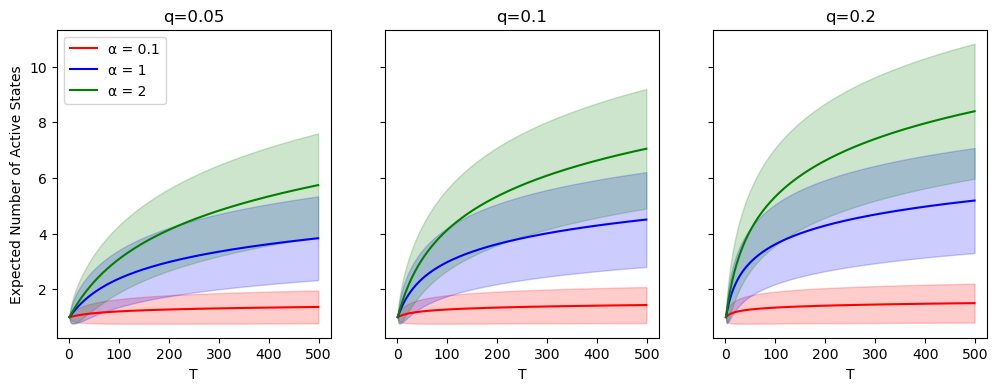

In [12]:

qs = [0.05, 0.1, 0.2]
alphas = [0.1, 1, 2]

fig, axs = plt.subplots(1, len(qs), sharey=True, figsize=(12, 4))
cols = ['red', 'blue', 'green']
x = np.arange(1, 500, 1)
for col, q in enumerate(qs):
    out = []
    vars = []
    for j, alpha in enumerate(alphas):
        out.append([])
        vars.append([])
        for i in range(1, 500):
            
            out[j].append(dp_ppm_expected_clusters(i, q=q, alpha=alpha))
            vars[j].append(dp_ppm_var_clusters(i, q, alpha))
        
        vars[j] = np.array(vars[j])
        out[j] = np.array(out[j])
    
    for j, alpha in enumerate(alphas):
        axs[col].plot(x, out[j], label=f'\u03B1 = {alpha}', color=cols[j])
        axs[col].fill_between(x, out[j] + np.sqrt(vars[j]), out[j] - np.sqrt(vars[j]), color=cols[j], alpha=0.2)
    
    axs[col].set_xlabel('T')
    if col == 0:
        axs[col].set_ylabel('Expected Number of Active States')
        axs[col].legend(loc='upper left')
    axs[col].set_title(f'q={q}')

plt.show()

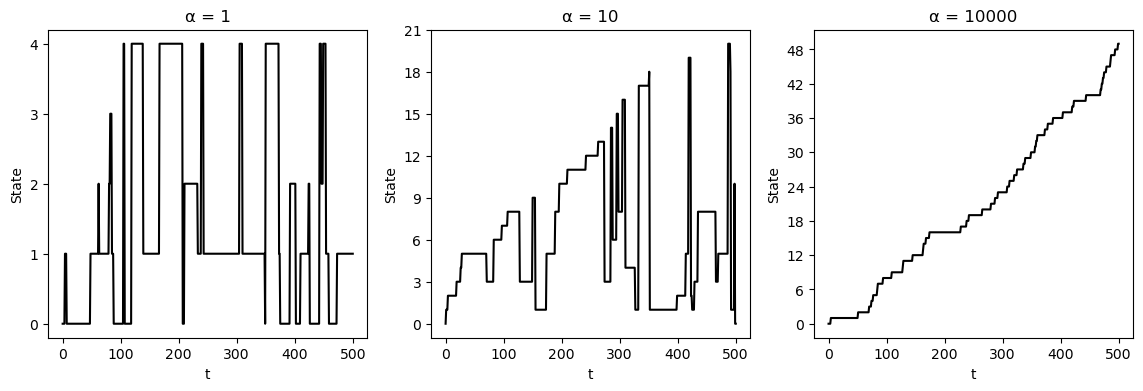

In [93]:
alphas = [1, 10, 10000]
q = 0.1
T_ = 500

fig, axs = plt.subplots(1, len(alphas), figsize=(14, 4))
for i, alpha in enumerate(alphas):
    states = sim_dp_ppm_states(T_, q, alpha, seed=2+i)
    axs[i].plot(states, color='black')
    axs[i].yaxis.set_major_locator(MaxNLocator(integer=True))
    axs[i].set_ylabel('State')
    axs[i].set_xlabel('t')
    axs[i].set_title(f'\u03B1 = {alpha}')
plt.show()

In [25]:
def dgamma(x, a, b):
    return b**a * x**(a-1) * np.exp(-b*x) / gamma(a)

In [26]:
def log_special(nu, mu, beta):
    log_val = (nu-1)*np.log(beta) + beta*mu + gammaln(nu) + np.log(float(mpmath.gammainc(1-nu, beta*mu).real))
    return log_val

def integral(a, b, t):
    if t == 1:
        log_val = 0.0
    else:
        log_val = a * np.log(b) - gammaln(a) + log_special(nu=a+1, mu=b, beta=t-1)
    return np.exp(log_val)

def f(x, a, b, t):
    return b**a / gamma(a) * x / (x+t-1) * x**(a-1) * np.exp(-b*x)

def integral_approx(a, b, t):
    n = 1_000_000
    upper = 100
    dx = upper / n
    x = np.arange(0.0000001, upper, dx)
    return dx*np.sum(f(x, a, b, t))

a, b, t = 2.3, 2.3, 7
# print(integral_approx(a, b, t))
# print(integral(a, b, t))

def integral_p(u, x, n):
    a = x + 1
    b = n - x + 1
    # betainc gives the regularized incomplete beta
    return beta_(a, b) * betainc(a, b, u)

def dbinom_marginal(x, n, u):
    return math.comb(n, x) * integral_p(u, x, n) * (1.0/u)

def binom_integral(x, n, u):
    dx = 0.0000001
    q = np.arange(0.00000001, u, dx)
    return dx*np.sum(dbinom(x, n, q) * (1.0/u))

x, n, u = 1, 2, 0.1
# print(dbinom_marginal(x, n, u))
# print(binom_integral(x, n, u))

def dp_ppm_n_clusters_gamma_prior(T_, a, b, u):
    out = 0.0
    store_integral_cumsums = np.arange(T_, dtype=np.float64)
    store_integral_cumsums[0] = integral(a, b, 1.0)
    for j in range(1, int(T_)):
        store_integral_cumsums[j] = store_integral_cumsums[j-1] + integral(a, b, float(j)+1.0)
        
    for t in range(1, int(T_)+1):
        # out += store_integral_cumsums[t-1] * dbinom(t-1, int(T_)-1, u)
        # print((t-1, int(T_)-1, u))
        # print(dbinom_marginal(t-1, int(T_)-1, u))
        out += store_integral_cumsums[t-1] * dbinom_marginal(t-1, int(T_)-1, u)
    
    return out

def dp_ppm_n_clusters_gamma_prior_2(T_, a, b, u):
    out = 0.0
    
    for t in range(1, T_+1):
        val = 0.0
        const = (1/u) * math.comb(T_-1, t-1) * beta_(t, T_-t+1)*betainc(t, T_-t+1, u)
        for j in range(1, t+1):
            if j == 1:
                val += 1
            else:
                val += b**a * np.exp(gammaln(a+1) - gammaln(a)) * (j-1)**a * np.exp((j-1)*b) * float(mpmath.gammainc(-a, (j-1)*b).real)
        out += const*val
        # print(const)
    return out

T_, a, b, u = 20, 2.1, 2.4, 0.2
print(dp_ppm_n_clusters_gamma_prior(T_, a, b, u))
print(dp_ppm_n_clusters_gamma_prior_2(T_, a, b, u))

1.573302246072791
1.573302246072791


C:\Users\k2259011\AppData\Local\Temp\ipykernel_34068\597400666.py:2: RuntimeWarning: divide by zero encountered in log
  log_val = (nu-1)*np.log(beta) + beta*mu + gammaln(nu) + np.log(float(mpmath.gammainc(1-nu, beta*mu).real))


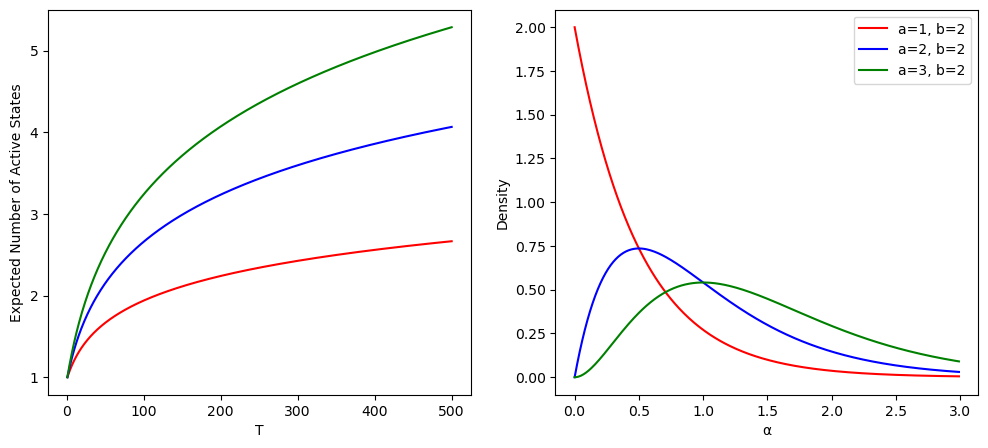

In [27]:
N = 500
t_vals = np.arange(1, N+1, dtype=np.float64)
E_vals = []

abs = [(1, 2), (2, 2), (3, 2)]

u = 0.2
cols = ['red', 'blue', 'green', 'orange', 'black']
for i, (a, b) in enumerate(abs):
    E_vals.append(np.arange(1, N+1, dtype=np.float64))
    for j in range(len(t_vals)):
        v = t_vals[j]
        E_vals[i][j] = dp_ppm_n_clusters_gamma_prior(v, a, b, u)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, (a, b) in enumerate(abs):
    
    ax[0].plot(t_vals, E_vals[i], label = f"a={a}, b={b}", color=cols[i])
    ax[0].set_ylabel(r'$\mathbb{E}[K_T]$')
    ax[0].set_ylabel("Expected Number of Active States")
    ax[0].set_xlabel('T')
    x = np.arange(0.00001, 3, 0.01)
    y = dgamma(x, a=a, b=b)
    ax[1].plot(x, y, color=cols[i], label = f"a={a}, b={b}")
    ax[1].set_ylabel('Density')
    ax[1].set_xlabel('\u03B1')
    ax[1].legend(loc='upper right')

path = "C:/Users/k2259011/OneDrive - King's College London/Documents/univariate_models/Figs"
fig.savefig(
    f"{path}/prior_active_states.pdf",
    format="pdf",        # explicitly set format
    bbox_inches="tight" # trims extra whitespace
)
plt.show()


## Plot simumlation study results

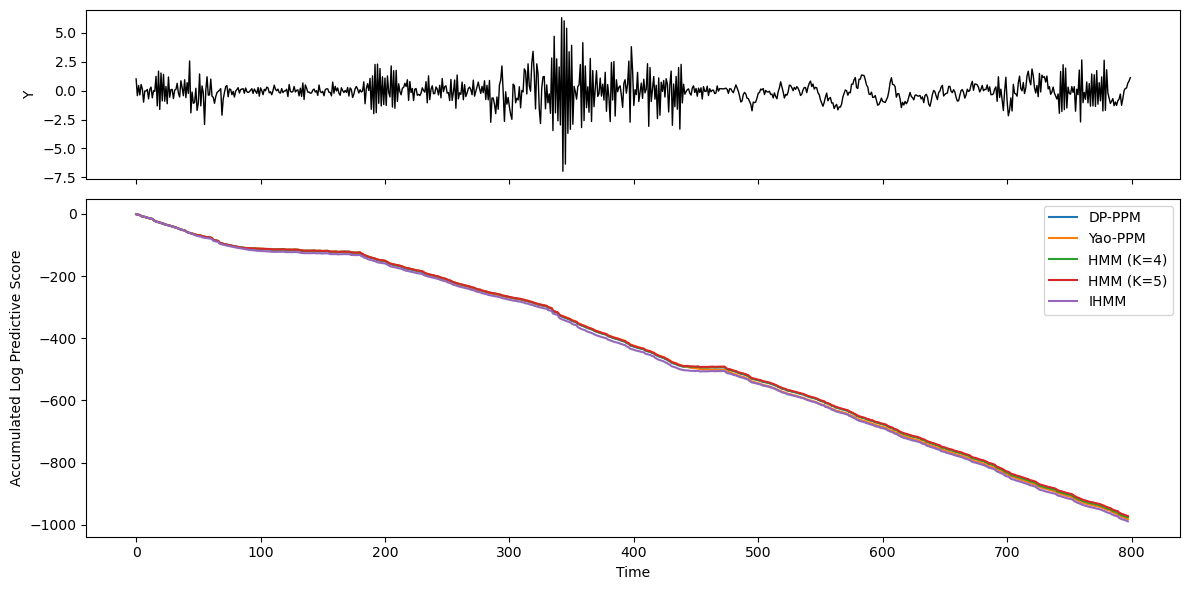

npcp:  0.0
ppm:  -8.934027295229725
hmm4:  -3.098033974097916
hmm5:  1.4831445642208791
ihmm:  -15.397551165372192


In [3]:
likelihood = 'ar'
scenario = 1
dataset = 30
full_path = f'data/{likelihood}/{scenario}_{dataset}.csv'
y = np.loadtxt(full_path, delimiter=',')

zoom = (0, 800)
models = ['npcp', 'ppm', 'hmm4', 'hmm5', 'ihmm']
names = ['DP-PPM', 'Yao-PPM', 'HMM (K=4)', 'HMM (K=5)', 'IHMM']
res = dict()
for model, model_name in zip(models, names):
    res[model] = np.loadtxt(f"results_clean/results_clean/{likelihood}/{model}_{scenario}_{dataset}.csv", delimiter=',').flatten()

fig, ax=plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [1, 2]}, sharex=True)
ax[0].plot(y[zoom[0]:zoom[1]], color='black', linewidth=1)
ax[0].set_ylabel('Y')
for model, model_name in zip(res.keys(), names):
    ax[1].plot(res[model][zoom[0]:zoom[1]], label=model_name, linewidth=1.5)
ax[1].legend()
ax[1].set_ylabel('Accumulated Log Predictive Score')
ax[1].set_xlabel('Time')
fig.tight_layout()
plt.show()

ref = res['npcp'][-1]
print('npcp: ', res['npcp'][-1] - ref)
print('ppm: ', res['ppm'][-1] -ref)
print('hmm4: ', res['hmm4'][-1] -ref)
print('hmm5: ', res['hmm5'][-1] -ref)
print('ihmm: ', res['ihmm'][-1] -ref)

In [87]:
likelihood = 'ar'
models = ['npcp', 'ihmm', 'sticky_ihmm', 'ppm', 'hmm4', 'hmm5']
scenarios = [0, 1, 2, 3]
ref_model = 'npcp'
alpha = 0.05
for model in models:
    out = f'{model} & '
    for scenario in scenarios:
        BFs = []
        for dataset in range(50):
            ref_ev = np.loadtxt(f'results_clean/{likelihood}/{ref_model}_{scenario}_{dataset}.csv', delimiter=',')[-1]
            model_ev = np.loadtxt(f'results_clean/{likelihood}/{model}_{scenario}_{dataset}.csv', delimiter=',')[-1]
            BF = model_ev - ref_ev
            BFs.append(BF)
        m = np.mean(BFs)
        l, u = np.quantile(BFs, [alpha/2, 1-alpha/2])
        out = out + f'{round(m, 2)}, ({round(l, 2)}, {round(u, 2)}) & '
    print(out)

npcp & 0.0, (0.0, 0.0) & 0.0, (0.0, 0.0) & 0.0, (0.0, 0.0) & 0.0, (0.0, 0.0) & 
ihmm & -19.18, (-30.21, -9.58) & -13.43, (-22.89, -5.1) & -9.0, (-13.84, -3.43) & -10.78, (-17.85, -3.04) & 
sticky_ihmm & 1.54, (-1.23, 4.17) & 0.53, (-2.51, 3.15) & 0.31, (-1.5, 1.74) & 0.55, (-1.32, 2.98) & 
ppm & 1.93, (-10.82, 9.29) & -7.68, (-26.3, 3.42) & -14.29, (-30.93, -0.14) & -14.12, (-30.31, 0.41) & 
hmm4 & -11.09, (-33.5, 1.33) & -1.83, (-14.05, 3.0) & 2.64, (0.18, 6.25) & 1.33, (-3.98, 4.6) & 
hmm5 & -2.67, (-14.55, 2.48) & 1.58, (-2.4, 3.21) & 2.56, (-0.42, 5.78) & 2.58, (-0.11, 5.17) & 


## Real Data (Well Log)

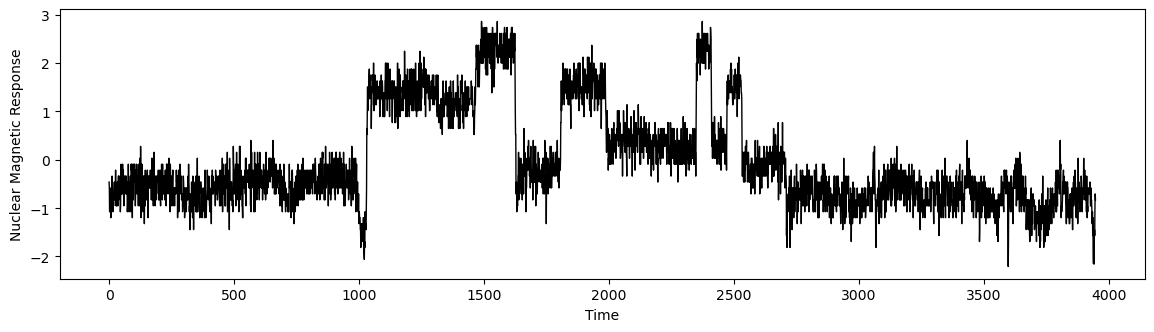

In [5]:
well_log = pd.read_csv("well_log_clean.csv", header=None).to_numpy().flatten()
well_log = (well_log - np.mean(well_log)) / np.sqrt(np.var(well_log))
fig, ax = plt.subplots(1, 1, figsize=(14, 3.5), sharex=True)
ax.plot(well_log, color='black', linewidth=1)
ax.set_ylabel('Nuclear Magnetic Response')
ax.set_xlabel('Time')
plt.show()

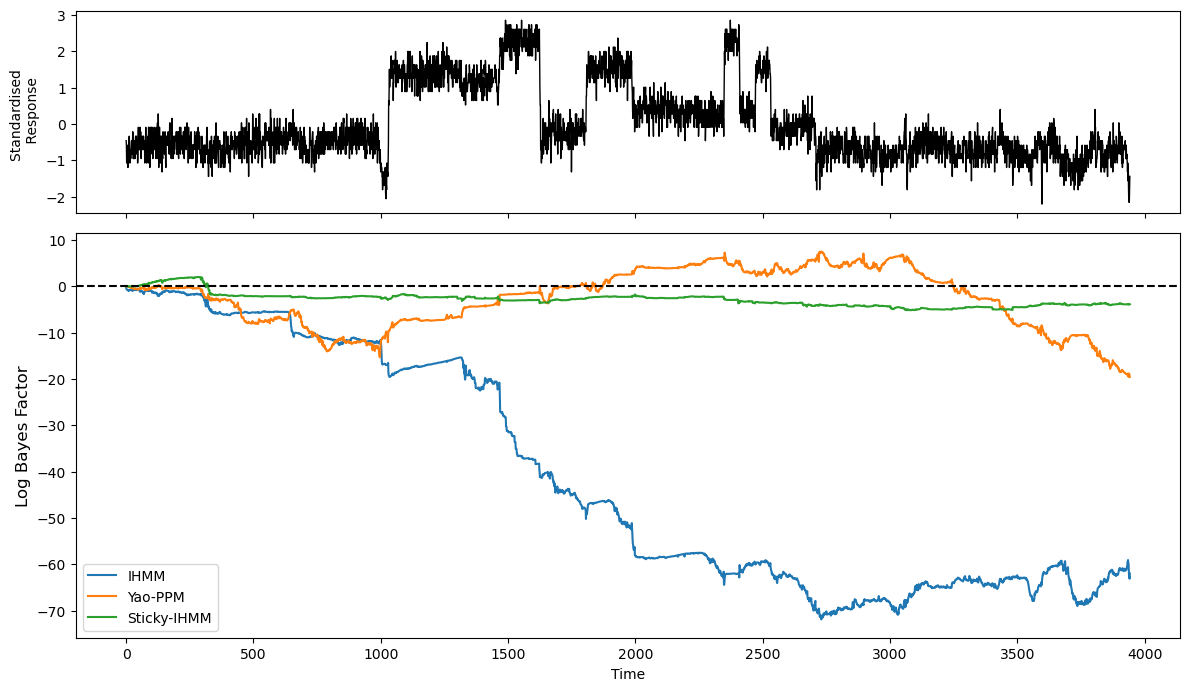

Sticky-IHMM - DPCP: -3.913823461374818
IHMM - DPCP: -60.76157612640327
PPM - DPCP: -19.81170902064582


In [6]:

# XXX plot new values!
well_log_ihmm = [-1.4175035109153737, -1.8413959446929755, -2.367578401332236, -2.2408270622338096, -1.9906655449671342, -2.482788813884979, -2.2976130167203803, -1.8511803553932862, -2.5073316978930946, -3.664667835162809, -5.1390944596750625, -4.878600788064903, -4.533409039563164, -4.6277363340878646, -4.370256141561885, -3.9544197942435635, -3.63542119501133, -3.320132860801209, -3.3654120013408306, -3.9714121623653056, -3.520729486318162, -3.1162053107819028, -2.6870720792876863, -3.17645245272861, -5.32056281058921, -5.5616488434494755, -5.491432089894642, -5.102532862952962, -4.957803499542184, -4.786776531290331, -5.117768555121145, -5.386067257608922, -4.989015230413448, -4.848969059091854, -5.117552447588071, -6.022947713406079, -6.789485247826048, -6.4578902318246625, -7.200843455291997, -7.26808286682974, -6.854615519002362, -6.427634010433647, -6.117733650239334, -6.720214988015224, -6.683214627913959, -7.41208565352566, -9.812670497426328, -9.446388796554965, -9.057751143590904, -9.610643502977807, -10.788256418640755, -10.430126372306434, -12.433216495439913, -12.14360441657186, -12.081761690534975, -13.021198204445305, -12.695706872090462, -12.884712229794365, -12.591566552393788, -12.504800127386408, -12.799345562147733, -12.653747264158687, -12.317419668587835, -12.175134267709035, -12.386125544241931, -12.026230785947584, -12.217072834472123, -11.998530796428101, -11.682580271975173, -11.471551480527065, -11.185020834152532, -12.359738839227555, -12.529581025412794, -12.227560469404441, -11.885600248234791, -13.661389980870753, -13.577345154773235, -13.236817851042325, -14.106552961775545, -14.055392749992079, -13.704426842405017, -13.546486303608592, -13.171296948414614, -13.377619294857968, -12.992282960924777, -13.97315026328724, -15.708378679147687, -16.50406414564314, -18.038555481935383, -17.988873229509377, -18.173135819768355, -19.952844285484115, -19.81401104185, -21.27163380699154, -21.436840103009036, -21.38803076618221, -21.103070841225378, -22.520787278178137, -22.331366670831116, -22.459362910711178, -23.75080386535455, -23.849005230732875, -24.38746283354988, -24.857459947030403, -24.635950106758468, -25.225937539657373, -25.004706032709592, -24.692505042033815, -25.88920342206958, -26.35357212418219, -26.165919301835135, -25.952346142298595, -26.00321420110153, -25.796461978166022, -25.576680899435853, -26.05829019110879, -27.271070147132622, -26.955985335273564, -27.438234543728623, -27.454469275304564, -27.990228930102322, -29.988832170817822, -29.763261066733364, -29.4652331958593, -33.38669906213379, -33.763793553274866, -35.78509601656517, -36.769888880270905, -36.515474921555, -37.45485354535047, -37.31499473304857, -37.83244598868752, -37.6370044390818, -38.72635152123246, -38.775086904157014, -38.79913562045106, -38.59279266593399, -38.69972541831099, -38.735355188951736, -41.48019442362922, -41.56359559422607, -42.0077887523219, -42.4483609582415, -42.931724626471, -42.78211542988001, -42.613882712542356, -42.658311983998665, -42.71415578282959, -42.806390795731055, -42.854460734365006, -42.880580901574305, -43.28169957132318, -43.13157852217556, -44.17279189029531, -45.84172695482221, -45.933763329706814, -45.99312708303477, -45.758498335010145, -45.57765313908692, -45.62775685571279, -45.38385938512913, -45.14988860741848, -44.94875933393164, -45.345823465521974, -45.13711132265312, -44.882033677267515, -44.660620622779746, -44.8013380166583, -44.60190950079569, -46.32939553760189, -48.00488141659227, -48.148368223045914, -47.95401534123699, -48.09421329110221, -47.84075748803952, -48.35814253508973, -48.10665675777277, -47.94584442350632, -50.515372387701646, -50.53313928381084, -50.649489590429354, -50.399366328596216, -50.91496198668829, -50.94836256258828, -50.79173468582503, -50.59342777654934, -50.700253086743594, -50.73015102806233, -50.578098841662346, -50.37633957707231, -50.16946155092306, -50.15307508839452, -50.170624390414204, -50.17616293456135, -49.95206445182495, -50.33418500046808, -50.44349596940903, -50.171187636829714, -50.17342230699616, -50.29913020552326, -50.02179674164334, -50.42564124424815, -50.144751795061616, -50.271915270925874, -50.81657444201344, -50.54656291313246, -50.94666030233882, -50.72311833243657, -51.68963493516416, -51.67511516576596, -51.64605152556718, -51.7840849319742, -52.72051333942917, -52.56407588892008, -52.283153554513575, -52.26519120606431, -52.215363900872816, -52.05666076282427, -52.03629251402129, -51.797332156126394, -51.66820504315522, -51.80592912335688, -51.56285166400978, -51.94282667789408, -52.087962998681384, -51.84106872125721, -52.456953031481625, -52.29054365906946, -53.25895473632867, -53.61463024100191, -54.55180996131695, -55.462420159945204, -55.21933563343089, -55.55331029035827, -55.41085891368656, -55.15515102061057, -55.107527977411344, -56.72167316555665, -56.46523626344722, -57.32287798185017, -57.05243533390874, -56.79291828105303, -58.10437638238661, -58.99733246484784, -58.919922252746574, -58.64136206816602, -58.36155581732132, -59.024811005733305, -58.98081721508608, -58.699937806056624, -58.56002862420451, -58.27355222804702, -58.21980325463267, -58.527828545977094, -59.20258882563442, -59.07290258061609, -58.935477811680926, -58.64730560263232, -58.49801261579277, -58.20811516726655, -58.856737215174185, -58.56546887564497, -58.40408569750237, -58.10882485355995, -57.81378265688073, -57.652400784273375, -57.34965867155186, -57.70971301241344, -57.44522425633171, -57.39457290898028, -57.118794027581224, -57.06202034630997, -59.31356357277174, -59.053984994260006, -58.78770455980044, -58.4829502564303, -58.8365563954194, -60.16573169520474, -59.87400044035596, -59.61173965612739, -59.33831361834485, -60.26031821094327, -60.199857753551115, -60.53418817134258, -60.23107008958548, -60.07387890682554, -59.76719444461513, -59.696430952144304, -59.87109907483312, -59.70485537820944, -59.54032366515018, -59.37980651019352, -60.72775502483251, -61.3086066660049, -61.41571844543165, -61.434271862053286, -61.16392638829243, -60.99801722660129, -60.68719091946576, -60.83790907925846, -62.9531066152694, -64.17200733134072, -64.00901937527142, -63.72456735926897, -63.432866445597405, -63.12166190295167, -63.23314226582924, -64.4278319418642, -64.12393704570566, -63.819200295281945, -63.62642435531779, -63.66599624362783, -63.46700240862257, -63.52303919319362, -63.68790666261277, -63.37097513365848, -64.50347014272995, -64.23720101193206, -63.92072239601307, -65.17471169592945, -65.73052387820772, -69.83454196233576, -73.34688755173167, -73.3607542305382, -73.35752770283622, -73.92135403313858, -74.17172646965759, -74.06315333421111, -74.53909989733458, -75.11841944553198, -75.08134434479418, -74.87956070187387, -76.01786455334103, -76.57200584013853, -76.35471340050991, -76.13171443861772, -79.40322427420556, -79.32025997580108, -79.31105528451388, -79.02280381820593, -78.73924230422915, -78.53410239293194, -78.7227902971339, -78.74150057851438, -78.60140804967449, -79.16069738659287, -79.81094743110185, -79.65149689605387, -80.07516134021371, -79.76684537239551, -79.61077828838847, -82.62044847708613, -83.48652821436747, -83.98211724615346, -83.72947573162938, -83.5866549060349, -83.28978133827384, -83.44575287987195, -83.98500185330877, -83.7605009623371, -83.65531385172736, -84.84264920583308, -84.98443804559037, -85.06468601167195, -85.06462308889355, -84.96746813562106, -84.83388326878286, -84.55881059039206, -84.34115335277149, -84.06433427154029, -85.76787498149355, -85.48600810444896, -85.63148967981326, -85.64736941335318, -85.34174548657438, -85.31691146049023, -85.12686214839356, -84.92953467520509, -85.38923568844977, -85.04819737841544, -86.05203534367526, -85.73991179983257, -87.19546452940043, -87.1970357237867, -87.63160490028208, -88.56678178677454, -88.86616115992516, -89.15364481277969, -88.84640439355839, -88.52730074450004, -88.38199430243759, -89.80748108523585, -89.86211889567166, -89.65513917659472, -89.3881901385037, -89.22234254110927, -88.92009759159853, -89.44825854792576, -89.16983255394462, -88.9466824584324, -89.08306977762064, -88.87856806603983, -89.3897726603359, -89.34071495827156, -89.0387708483386, -88.72901193246697, -88.38087399131467, -90.17247335616793, -90.93365096031721, -91.51348359445723, -91.19515104164321, -92.44623175760924, -92.4378977778977, -92.67691984114828, -92.46199220340803, -92.23791056740895, -91.97975835879934, -91.83659999454898, -91.55078528958757, -91.26139105584342, -90.96913352298938, -90.75084960129716, -90.43957551290062, -91.01453407811422, -91.60204552079637, -91.5547022879687, -91.25028706357962, -91.09397795110088, -91.01178652011838, -90.69459646718607, -90.36404568326716, -90.5847590545596, -90.73838259280683, -90.56445569397002, -90.25542651207157, -90.24330537057709, -89.95044203256559, -89.632906305642, -89.52601675280947, -89.19112599042116, -89.97924983988547, -90.62826980192013, -91.1484010783314, -90.81688647743273, -90.50457137405711, -91.24573163581533, -91.38031871791871, -91.40041562942919, -91.06959707078205, -91.4299369144581, -91.09656129706829, -92.81387716993663, -94.35681376576815, -94.28554337632794, -94.59289810319416, -94.2683834611572, -95.13658124504758, -94.99465036441312, -94.87484551252452, -94.54126123331818, -94.40440845660046, -95.20439911899958, -95.94641834124799, -96.55493650527714, -96.95458267495404, -98.22506590061325, -99.20903398672735, -98.8864777239633, -98.57730656016373, -98.25202031578188, -97.95882049039685, -100.6230359581637, -102.14979186095317, -102.0101209855101, -102.35792538783303, -102.25348602660007, -102.48530046109808, -102.33935326096737, -102.02612663455028, -106.6196873884533, -108.59067391131218, -108.51508510189495, -108.72069248669744, -108.45019830065262, -108.63437571574963, -108.3738203860988, -108.07036933426181, -107.79409798795602, -107.50578461892087, -107.63983751477494, -107.3345052303296, -107.99875070946167, -108.10030821320107, -109.15838044592394, -108.8959479339921, -113.03391343063794, -113.92014207802512, -114.21308910934123, -114.08193160879655, -114.38134699335765, -114.0941440808277, -114.00161846958828, -113.87002590371229, -113.58766263284963, -114.43570008076381, -115.17707950390022, -114.90445900739869, -114.7618081792411, -117.30916902192456, -117.18087101506634, -117.35678418521567, -117.27153590535696, -116.97512268294062, -117.8145411706418, -117.51774148044257, -117.24345929437551, -117.14448054305849, -118.49622613432936, -119.19866958177765, -118.92684129052986, -122.53184008803848, -122.75396904144057, -126.32218572223098, -126.21058481300308, -125.93257217211607, -126.20879669838774, -126.0961150729746, -125.83175983122888, -125.5501634334841, -125.42785876773928, -126.12597974022123, -126.70472368985588, -128.483703052069, -129.7953236251889, -130.34860840271094, -130.1215488102618, -129.89044777513857, -129.64828049163538, -129.3849622596448, -129.13304199195935, -129.22907611841924, -128.9968351512804, -129.4025078447197, -129.26338423811896, -130.97388405412505, -131.68414910569214, -133.2137855611088, -133.4845640484549, -133.75501226672384, -134.02307255257622, -133.7540502576152, -133.48623005679408, -133.7483647664718, -133.47905116190185, -133.207840533549, -133.11649481944673, -133.01927683877113, -133.27416176950427, -132.99691495838712, -133.784982619797, -133.50848659535038, -133.75961527459182, -133.48113374984786, -133.2045159614662, -133.9519262186506, -138.55457552990993, -139.97419645859202, -139.71572542708253, -142.02357108823443, -141.7634723107281, -142.00462809281535, -141.90380203979058, -141.63732048600886, -141.53586901431348, -141.27384321887183, -141.1717138890537, -140.90625600720756, -142.33246884131077, -142.632643226581, -142.54264682529276, -144.82599246514337, -146.11788916564714, -146.37180900199405, -147.10313601340147, -147.82957623618964, -147.57817489262465, -147.31757439159603, -147.05783198550833, -146.98310673629246, -147.20998046172454, -147.96118604364952, -147.85486486737955, -150.06948990415435, -149.80978771904313, -149.54984519832618, -150.25874738512817, -151.0244707139765, -150.77768684363375, -150.541052016088, -150.80260244366036, -150.5487411599752, -152.73932305813634, -152.48027945674954, -152.22057685191726, -151.95994650948776, -151.69870177314363, -151.91237074593374, -151.66186671216477, -151.86945774624053, -151.602866405631, -151.3519634939004, -151.23850447530572, -151.52446829072184, -151.42289466059816, -151.1562067970175, -150.90163801417177, -151.60396234547187, -151.3322224503945, -151.5315658150113, -151.27820579136812, -151.21070749077944, -151.09863719079627, -150.82503703983642, -151.02690315084502, -151.31595285297857, -151.05090098272893, -153.24162660412455, -152.99010866480984, -152.71607388043765, -152.64814453422255, -152.39285159120035, -152.27458853165922, -152.14860797040467, -151.889161171691, -152.08753437511965, -152.27944648740734, -152.14436028237333, -152.81916217432243, -154.14492582205386, -154.00691205720602, -155.31273626262447, -156.61128659945518, -156.33267414955796, -156.1920232678344, -156.82281029277567, -158.07513200184286, -158.6568935990833, -159.12609160307304, -159.20184384165813, -159.00864368572994, -159.38167256519327, -159.11310065843765, -160.12286099970393, -159.85303746334552, -163.77645506532141, -163.5845083603208, -163.61634337261341, -163.17247494818292, -163.34410987053502, -165.2230550380185, -165.40768154745476, -165.30182540811504, -165.08012667760366, -165.08041117661472, -165.8124172163603, -165.56071258251123, -165.6344747151165, -166.20492475369664, -166.03307965266143, -165.76502541856826, -165.601209773348, -165.3216974430107, -165.1408394150053, -164.92392453218315, -164.9130171713516, -164.62470949533127, -164.32918111835548, -164.01787704348047, -164.1183733812526, -163.92160440314154, -163.77206986814141, -164.8345035343762, -165.57180501742585, -165.28335610068294, -164.9841042794188, -165.47277279637368, -165.615183899734, -166.6392289129839, -167.03600305989127, -166.81686322558616, -166.68999727237332, -168.27105948693278, -168.0394711099014, -167.80092822915267, -168.06076129438546, -168.24681808337985, -168.11160603995998, -169.08416841832948, -169.35294676282606, -169.31220753086635, -169.59965726663827, -169.35721341465748, -169.1168693976583, -169.35358139425907, -170.66757642245338, -170.43493425285138, -170.24163431321912, -170.64455837766909, -170.38923296207855, -170.09538817797394, -169.79516201237604, -169.5754680957016, -169.61695742180547, -170.03850263691177, -169.6762956325313, -169.3204901738183, -169.74114581316397, -170.10207319876295, -169.74054618370357, -172.05356315494666, -171.844498327154, -171.82123902998066, -171.7697216999959, -171.52648388429947, -171.3574744166654, -171.1326760055925, -173.03246629895716, -172.79218246640545, -172.7797111465839, -173.01467278117545, -173.53017002309488, -173.83930556328653, -173.57033410724938, -175.08101435208812, -176.33197888231322, -176.70440231926494, -176.46861088294523, -176.9069036773059, -178.64500976733595, -178.58619302953446, -178.6742555098726, -178.5657144355528, -178.78211102223756, -179.43749525040678, -179.6152811966861, -179.81292512404863, -180.4320229238326, -180.42131326298403, -180.8952093468392, -180.84428707690165, -180.68515474900377, -181.51221052643172, -181.40008491933392, -182.48721174605816, -183.3391445912524, -183.2398130435923, -183.0463032125206, -182.9694526343345, -182.6594378101302, -182.90571240001742, -183.27291041232073, -183.4977563070129, -183.41187587823012, -183.22289063637118, -183.505709742019, -183.8446015479591, -183.59780654503663, -183.330856770713, -183.61336307440533, -183.3417547660829, -184.0628211336192, -184.43253469935226, -184.37835200973947, -184.66284444060187, -186.19649033270485, -186.03525831874387, -185.74742928252445, -186.1179852553385, -185.85414358867507, -185.8334505642652, -185.56138495452205, -185.7293656195922, -185.5622394678033, -185.2989155519349, -185.03785114977697, -184.88229585395993, -184.5839027813611, -184.74872663426362, -184.6079804682453, -184.5825505320791, -184.31924722637174, -184.0226983787712, -184.1780963073491, -183.9207324629032, -183.89152148130918, -183.60071005124905, -183.43406533002434, -183.5873443460157, -183.56381714095068, -183.4071400652143, -183.0933723151875, -183.06629811766, -182.90594367687493, -183.04428617227603, -183.1657606369527, -183.2887760529932, -182.9785202672008, -182.721137082938, -182.5350654492758, -182.34137017201914, -182.46254330970928, -182.2083062785115, -182.18475412392732, -182.0163820891244, -182.62540533112463, -182.7143828013963, -182.39261621524193, -182.94906942722687, -182.62771932462883, -182.30797594156272, -181.98448633253827, -181.99051620258322, -181.67550283902713, -182.96148584599848, -183.04577178465118, -182.81339964021006, -182.58823673395347, -182.34728647995564, -182.01368915189735, -181.67721323664873, -182.1261113282033, -181.83194789755262, -181.57256869924822, -181.2355635186004, -181.03380470759205, -180.7044769500178, -180.70304258581848, -181.3265537315861, -180.99084544110164, -180.60801847465865, -181.19873073543602, -181.72993993590742, -181.84735125069417, -181.64189658876504, -182.87672703045223, -182.53927003687758, -182.19406267693387, -182.28287913900252, -182.33147584345218, -182.47869036038693, -182.2352728529124, -184.39572626641578, -185.5654227888298, -187.53053834598873, -187.29525127032474, -186.96840314370132, -186.7629921899207, -186.4177727525193, -186.07452491081312, -186.63381419512544, -187.1841753553803, -186.8495336815616, -187.48788707322285, -187.5275179820627, -190.54098963439301, -190.52677936534954, -190.51355136624196, -190.2843021014539, -189.94484787936173, -190.50057530419585, -190.1545916467991, -190.1638407542833, -189.79828887447363, -189.45472392937907, -189.9400149162839, -191.2913488015157, -191.3005582849914, -191.40135048084448, -191.46961247383464, -191.16727520811622, -193.09399943979517, -193.50632488111006, -193.37440590371543, -193.3081455905408, -193.77142523526803, -194.43178553043848, -194.87482044975337, -195.0413852527954, -195.0888425038331, -194.7365389971228, -196.53163293049596, -196.18393091503177, -196.01663752473397, -195.8423025794615, -195.5125896214329, -195.2013547702017, -195.67696089901983, -195.3136364143132, -196.25308711673188, -197.08640436397607, -197.3851694882157, -197.6526771111005, -198.60057580907568, -199.44087774571216, -199.18086276341563, -200.98440533975187, -200.8767540590158, -202.48070014064612, -202.3272580807719, -202.0007182630012, -201.85978425332115, -201.52604380688106, -201.24845332595228, -201.5181885071672, -202.4766534899346, -202.144222548984, -201.79216458767758, -201.44633149969755, -201.3081535678808, -200.9672458448044, -202.67021303483818, -204.3357230379144, -204.2174473524424, -204.41288656772548, -204.0510544310529, -203.73250944880508, -204.54683029999032, -204.45676604670953, -204.66315219654473, -204.5000450898007, -204.1656360727919, -204.34298156178068, -204.70510218022602, -204.94867074330904, -204.5733176526497, -204.21799513452882, -205.75735374056077, -207.6327235604655, -207.4945462277489, -207.72513251604818, -208.5701111367833, -210.23128608778052, -210.36762319786948, -210.8936612153508, -210.79673936022948, -210.55514488746198, -210.32419272917028, -210.83800772142666, -210.52410099054526, -210.23720660661425, -210.08727267646384, -209.91652915307995, -209.87663649185689, -209.7672823314696, -209.63219271551074, -209.29767607455952, -210.21048609838405, -210.41168911451487, -210.10284222504816, -209.7891776626852, -210.78104229808287, -210.45040442440458, -210.29141221532166, -209.95764832015377, -210.2441335308657, -209.9169555805068, -210.69366665119742, -211.9711612261668, -212.2685491205667, -215.79405833773362, -215.63354273028068, -216.02395394668906, -216.23060195416727, -215.9253175688068, -216.48773240191886, -217.00295550236592, -216.75916989891368, -216.54600555856615, -217.78110068893383, -217.54843647562504, -217.29758879760018, -217.69617517617831, -217.5246593486355, -217.661164873204, -218.64896968587112, -220.93038741910928, -220.72530918234813, -220.47623043010478, -220.85024671132058, -221.00982921838073, -220.83711666362635, -220.97308303577813, -220.6737181330273, -221.79445269509168, -223.25949891840025, -224.03378752875895, -223.8242164809685, -224.94345812800898, -226.66718476776168, -226.78096297758435, -227.4714831288041, -228.1022102136963, -228.65621269385224, -231.01972090542358, -232.9044879490844, -236.59461327290546, -237.8728704197402, -237.5984732821027, -237.66357976862105, -237.64539511401858, -237.2822396920831, -236.88604810024714, -237.28537878587088, -236.78475529293894, -236.26348833465622, -236.2065433099483, -236.07853361685727, -238.511794958148, -240.2873374953269, -242.59931367882288, -242.57444864875504, -242.93791306725524, -243.94645865893344, -243.80883406240707, -243.64823490407247, -243.46165538896977, -243.10882996386744, -244.4095420084261, -246.69850773275178, -253.6747213428293, -256.5402812681511, -258.93513905221886, -261.50266314833954, -261.72733964175393, -262.07858442915256, -262.58646339931903, -262.5841276917728, -263.1555890546028, -264.6659011767991, -266.34817516230913, -266.27243448981335, -266.17581534388324, -266.94008954300136, -266.787977218378, -266.6157055736972, -266.33599204015, -265.99668025064915, -268.93746193449505, -269.0125374933144, -269.03716152013965, -269.76319520870203, -270.4050325676482, -270.53822536202455, -270.99951539097975, -270.8006739411746, -270.58016979658055, -272.2274747635149, -272.0585772341525, -272.77512427681944, -272.6024344781464, -272.62438338284295, -272.4410790171232, -272.7861199197289, -273.0616881759941, -272.8069158639619, -272.75593455202596, -272.65631516978357, -272.8920000959111, -272.60152053518397, -272.454616666058, -272.1948267100221, -272.1449159818341, -271.9803337662267, -271.7995141464419, -271.6102259936886, -271.292374854522, -270.9875017561206, -270.6189793794754, -270.41239872086913, -270.04178943078955, -269.81533344006266, -271.4825732232583, -271.44143492474046, -271.595140515273, -271.3500478258368, -270.93190796273564, -270.51300115929735, -271.00282969178903, -270.75386633842555, -270.4876179292931, -270.05506377792625, -269.9917993904288, -269.607564657796, -271.27929429611595, -271.99249036313694, -271.5775374525662, -271.15352880117337, -270.7190030987576, -272.1968120045154, -271.7747272099161, -273.1188232374968, -273.14077828660083, -273.2135640763565, -273.2579456773189, -275.5258337224331, -275.15722250497896, -274.8917101344684, -277.05217609294084, -277.5311594954111, -277.52134265412064, -277.24124355825916, -277.89689906993266, -277.5326491951102, -279.5133538636249, -279.1734778220421, -278.9618375057643, -278.59958992518926, -278.23162681257537, -277.86910165932096, -277.48444291304673, -278.88212878463105, -279.34662782584087, -280.4452881515748, -280.10839332381005, -280.0727332956702, -279.7163055565708, -279.498692141373, -279.14689690707286, -278.77216295729244, -278.72719509944807, -278.33868352079776, -280.74455444752203, -280.7210858920082, -280.68877543057044, -280.32287769839616, -280.0109395723506, -279.69491999489674, -279.3149802362395, -279.08066132178044, -279.0277663780755, -279.1532276150413, -281.5642493791095, -282.1872877952309, -281.9006428822176, -284.1471569992491, -283.8052313499882, -283.87272998902057, -284.4435276751675, -285.6522849727182, -285.4097116767412, -285.16508736479796, -284.91588535558554, -286.9900772319031, -289.9111780876397, -289.6133342057121, -290.12583929060366, -289.813767859765, -290.31011615370124, -291.44665089799406, -291.1424017394502, -291.63458116979837, -292.113959661155, -293.25816667218515, -293.7365605015417, -293.5360641596379, -293.3283387419718, -293.3890358267498, -293.4436576111083, -293.22582467673294, -293.70673040116355, -293.48470176821274, -293.27341690062883, -292.95369641643555, -293.0152515511339, -292.7025809873012, -293.20610492781856, -293.26203127569715, -292.9452832315661, -292.718499807153, -292.3889916367582, -296.4722414532336, -296.5215687084483, -296.3144638271541, -296.78581559745845, -296.47834067713325, -297.6155707463005, -297.3943056726196, -297.89085916330237, -297.93647531168426, -298.43548972501645, -298.92002219292186, -300.01527944016607, -301.09394945779593, -301.58397210609854, -302.0646116411187, -301.8653782153889, -301.91147409322144, -301.9741143729192, -302.03268274841105, -303.099906531302, -303.1450859749441, -302.95497392868293, -304.04929405580765, -303.76739141555066, -303.565341024227, -303.6116120468773, -303.4012815804924, -304.5016616172772, -304.29973123414493, -305.38248479351284, -305.86165895682825, -305.6717895756391, -306.150316730245, -306.20916027047923, -306.6898922888388, -307.17024316052897, -306.9805698529759, -308.06216843405326, -307.86576186508233, -307.5836516215344, -307.30223664543973, -307.0271860142049, -307.0827964151884, -307.5531237502045, -309.3974773078902, -309.20272110716485, -309.00549246047984, -308.80585220820075, -309.8684210915205, -309.67766049979997, -309.722807415843, -309.78867376131905, -310.25312681122443, -310.71764521345864, -310.43707897609545, -310.1490015656711, -309.86322846195367, -310.3146071702179, -312.2005178708942, -311.92079557094013, -311.7197853036992, -311.52125654685295, -315.37566671475435, -315.1047642455951, -314.91134611538877, -315.3775873396662, -315.1823663577513, -316.9842623307912, -316.798812265924, -317.2653344188854, -317.3237874717527, -317.7788766114682, -317.83020473090824, -318.27570324886443, -318.08362776621726, -319.0875825808603, -318.8817863647251, -321.45921877827504, -321.2658357982061, -322.22170553967595, -322.246358318297, -322.35134922162786, -322.15129998684466, -323.0953294383355, -324.2239435612413, -325.1600081293028, -325.1795171002015, -324.9250691886464, -325.31817654393575, -325.11748869781394, -324.85649480377117, -325.2402106913825, -325.24912754700136, -325.0440663676189, -324.84000961720096, -324.62375191441356, -324.4762265079821, -324.8532212443804, -324.6302058205711, -324.48015531852735, -325.0455171421983, -325.60943999746473, -325.7291926145364, -325.5191792235799, -325.3030618865431, -325.08690818838323, -324.81423759782444, -324.8168862975233, -324.65684638359954, -324.4315515845365, -324.20715400321404, -323.98295659578514, -324.36711925973304, -324.4907598951923, -324.32536316242715, -324.15873945652356, -324.5456445641649, -324.2655115034178, -324.0339808526323, -324.15478895535364, -323.86572312849006, -323.6957569810178, -323.5210530744659, -323.3465857418804, -323.1063542602992, -322.9279695641624, -322.6312131501958, -323.02681961369774, -323.142125883439, -323.7245522645072, -323.83264216752514, -325.02475025436667, -325.0428163422543, -325.4483948576157, -325.21284903682914, -325.31973910114556, -326.50501109655545, -328.46064175227497, -328.9962296222642, -330.90451410863267, -331.42077021880993, -331.5035280404048, -331.5824598109205, -331.65817419864567, -334.4174877319712, -334.3282350794325, -334.1636254232327, -335.10341267384405, -335.46049414899454, -335.2745074491418, -335.6174409859989, -338.3357513613634, -338.3589637557503, -338.0992352512852, -338.37582572829115, -339.225906771018, -340.0200805244394, -339.8562652838362, -339.71271679246377, -339.3241080828439, -338.9804083340605, -338.6341341556567, -338.5415699123339, -338.89995153305733, -338.51271347961955, -338.3447053451486, -339.97024433184686, -340.11239674774174, -340.0794208050915, -339.94246851962464, -339.74559147016623, -340.70154077084004, -340.785089109515, -340.59059565409336, -340.85964211570627, -340.5885740881839, -341.9155059152783, -342.3379462585448, -342.24370756997905, -343.08512403180026, -342.7132423261311, -342.58910037332583, -342.3439915096133, -343.5452170195429, -345.1312502133735, -344.9190903694495, -344.6724649403483, -344.7390142321001, -344.88615802267674, -344.8813931593321, -346.6387573581567, -346.436436120111, -346.8478093505786, -348.31765979212236, -349.3029117313731, -350.8869132677048, -350.56276032137663, -350.38462173677124, -350.3415092974939, -350.152734557366, -349.95908875839547, -349.76130655970746, -349.61004437742855, -349.40753352464486, -349.2650920443833, -348.88420726938216, -348.72852418266973, -348.78958104595415, -348.44633280595514, -348.59752929270496, -348.3415191031612, -348.264421612809, -350.8379264314191, -350.4553090669622, -350.22806582821767, -350.5304815180463, -351.7821130226545, -351.54067081566, -351.2659795854706, -351.2279569858344, -351.20252854726726, -352.3656725554603, -352.1600118550323, -352.6000425389616, -353.1313073355128, -353.2347240389354, -353.84094540911315, -353.8654665673285, -353.8825635656618, -354.7274936391273, -355.17063589539515, -355.495665652852, -355.45435498934586, -356.4691501554414, -356.30295564319357, -356.18569750668695, -357.5672367335157, -357.33527536664576, -357.59732056879665, -357.3833806170683, -357.04186910638845, -356.9874164841067, -356.7469571985209, -357.49694807392194, -357.594861425616, -357.3835705490637, -357.12137862500015, -357.56908800900317, -357.6748282657244, -357.76683975636473, -357.4149442919117, -357.3667690473937, -357.56888535611733, -357.3449212885081, -357.59467319622917, -357.2285441160822, -357.7114271869178, -357.3506141153811, -357.28823358688425, -356.9986074443187, -356.9387732534487, -356.6393327558342, -356.3380156157614, -356.0372414669346, -355.7263845345633, -355.4251767802563, -355.3933751911611, -356.09008635121285, -356.5155194828539, -356.1861945371079, -355.86618260665796, -356.2575858142493, -355.9414385701202, -355.5628256130865, -355.72033450053044, -356.09893031167627, -355.8584057543858, -358.90528763716503, -361.2228225995584, -363.3383774455995, -363.48298593474334, -363.23839655237845, -363.7359664207427, -363.37916076722456, -363.37519788020313, -365.9139165470483, -368.4231088551651, -373.6903585773753, -376.6157511249409, -379.37254444231803, -379.47921501548694, -379.18686862094813, -378.8502769840916, -378.75964791454214, -380.76520785455307, -381.3030467739886, -381.56295157379776, -381.49745719537356, -381.6506881173463, -383.25663379172624, -383.1055598340645, -383.22957948397413, -382.9665614551587, -383.4078373891391, -383.82542552114376, -384.83578646412025, -384.54672899569135, -384.24174821335174, -387.67421509857576, -387.6974593408422, -387.8388142405408, -387.6391746079762, -389.35461410231255, -391.27503041929276, -391.62287846992433, -392.2350036413012, -391.96707306395484, -391.99251077927124, -391.76272723863013, -392.7384125926479, -392.55551364506357, -392.51722550999546, -394.3514155953603, -394.27510538795894, -394.53577622000495, -394.2816422166436, -394.01016625126283, -394.77213137690086, -396.310603453829, -396.06405736343214, -395.98943107249085, -395.90190563420805, -396.63889328424216, -397.76962381042506, -397.5274470246526, -398.29433561892347, -398.04177787813114, -397.77998170422296, -398.5464903584842, -398.5783048816779, -398.5132291560547, -398.3970406919381, -398.3218374713944, -398.04546337685997, -397.9235671446437, -397.7904156581537, -399.8460973398311, -400.1811148667871, -400.03949006127664, -403.5187644982448, -404.7880090960169, -404.5427372340561, -405.9252523639026, -408.2026019291307, -408.6377796958801, -409.0335256031261, -409.3083071486295, -409.53867013251863, -411.69282515132414, -412.43651881040245, -412.68507529360295, -412.47498205870073, -412.4268265061334, -413.14817618021084, -413.8392380845898, -414.5034414033164, -414.70797841582026, -414.6244194909115, -414.53294434593704, -414.57092725845195, -414.3715593197471, -416.30311915899034, -416.1217775868063, -416.01076620256765, -416.01345022333203, -415.78261249067987, -416.1212769424211, -415.8781940875185, -415.63011861742547, -415.4178162625895, -415.16034510864404, -415.9222820580149, -415.6621944224047, -415.43633730901985, -415.21648501216964, -414.94393516932763, -414.78648896400983, -414.7748293149923, -415.3717789714645, -415.0884642759927, -414.9160534891293, -414.62241724906147, -414.4447551930085, -414.4408536293877, -414.140496710987, -413.8333334597997, -414.2318578684968, -414.8344543818391, -415.4201341964036, -415.2312752916509, -416.49790730886474, -416.30514024416266, -416.74294374281084, -416.7100822764186, -417.2547590611395, -417.8266487427916, -417.5261244500472, -417.301525923165, -417.3416014756227, -417.78832737363865, -418.96252527555964, -419.0382183436104, -418.8347535127045, -419.30594933439744, -419.75618732754714, -419.84009880815665, -419.68003150458054, -419.75462578560257, -419.96266465686625, -419.73785293505154, -419.80429749336486, -419.57770679877194, -419.34872009003425, -419.1706013027717, -419.6898018818386, -420.1950610815438, -421.30995713529353, -421.08743607829416, -423.1936440046545, -422.9770661433419, -422.7601754433561, -423.86891452283675, -423.6586945207335, -423.4386603315677, -423.9173629451943, -423.98102950302143, -424.036268548105, -424.0756223216436, -423.85006816676207, -423.61907487240387, -423.30323875577307, -423.77548376854276, -424.93536934966716, -432.1643123624662, -434.7940749475442, -436.6139805119409, -441.1283173598914, -441.0505573399289, -441.0145718329015, -442.16297918808624, -441.95510398787815, -441.9009272464898, -441.9163649135853, -441.5832697474273, -442.19436734796017, -442.3159852382228, -445.11856867820103, -445.5167582740078, -445.3018390987146, -445.2959384698131, -446.7069230119937, -446.3985931338117, -446.16881862050275, -446.23461231975244, -446.2719651477825, -447.36373326415793, -447.21066388444564, -447.2804329692517, -447.0952358228125, -447.5834731732996, -447.3478907759995, -447.90737991550714, -447.61401817464315, -448.10062880115504, -447.84103152310854, -447.8176456506799, -447.83996501713574, -447.90067642031204, -454.5250874611087, -454.3298601276653, -454.61383618522405, -456.11923862307236, -456.85719495016735, -457.5834519700502, -458.6013167788053, -458.5325595322935, -460.43502913068676, -460.3485003749901, -460.1976715860237, -460.2701726901638, -461.18520746853443, -461.3792798269223, -461.390118675753, -461.5928761466663, -463.84461681314497, -463.9985752081346, -467.242588309013, -467.3719000166706, -467.1857010594829, -467.97087557989687, -467.7043093103962, -467.8217078819548, -468.5625041070984, -468.64082024680215, -469.3255684344849, -471.6116444650527, -471.65213161356337, -471.37049654145716, -471.20511823575976, -471.00166179670356, -470.9297549600057, -470.694664483332, -470.4201953490598, -471.4524762918251, -471.286467717985, -474.33636037401817, -474.15092585566805, -476.05256204809325, -475.7936416400736, -475.5922508997725, -475.7116812851929, -475.5255434866238, -475.30985012235124, -475.10722335943717, -476.9522119692622, -478.79535644156454, -478.95798901578974, -479.0491639350953, -478.84852318853217, -478.6035027357298, -478.3897551285327, -478.9731215357326, -478.8110681277777, -478.6175755456453, -478.46750140417066, -479.5578538298761, -479.3373872573847, -479.0815505255756, -479.59749248983445, -479.63392009555696, -479.40424709942454, -479.1309543950535, -478.9606948481366, -478.73516753990157, -478.5001390785023, -478.2943305039053, -477.9935589297491, -477.7878444331195, -477.4853039410163, -477.17808395144067, -477.22482316198835, -477.2815535714197, -477.0602629823155, -477.49748400847045, -477.24902541993197, -477.6467058220937, -477.47083719580246, -477.93754538066145, -478.35264048582104, -478.1631853419701, -478.68331040103783, -481.7607092250609, -481.7729742956823, -481.5254890627941, -481.94695047171524, -482.29902597706285, -483.1859644003846, -488.60998692474465, -488.4770545770856, -488.3342666839624, -488.12552568638586, -488.5162422659564, -488.2324859031973, -488.59089153552765, -489.22513722432205, -488.950684579109, -488.7217764313475, -488.50028141172623, -488.2179193780168, -488.03927058564216, -487.7511209255504, -487.74072051611535, -487.8726261733993, -489.69306669594476, -489.4100394268021, -489.36512901308504, -490.24593026740985, -492.0518321563764, -492.2650517800588, -492.03231190510223, -491.79763759323606, -491.7473583353023, -492.2647428147051, -491.9908332513163, -491.9194040087329, -492.7403699272275, -492.4728816541274, -492.36325651009895, -492.1193598478367, -492.1559617301357, -491.8670554288809, -491.5908575553849, -491.31656114469126, -491.56341835064626, -492.56616185926794, -492.40545743194895, -492.5902072995348, -492.6870747353704, -493.3989523134315, -493.1077911893119, -492.9622302667163, -495.41874601295285, -495.3256893660283, -495.07546541928633, -494.8633873968337, -494.8127464837245, -494.52792996709366, -494.700492502643, -495.04442452543634, -494.76198453853084, -494.47469659901526, -494.3026953223926, -494.1508709102692, -493.8671976677468, -494.01268540909876, -499.49850265734904, -502.2706087422406, -503.71122074913853, -504.08875804467186, -503.92171139732557, -503.8816854253654, -503.89375215513536, -503.82806370601605, -503.92218090136095, -505.7313356416361, -505.43559214176645, -505.2541134939039, -505.656050731312, -505.40880297000973, -505.5243332368165, -505.2812648366501, -506.26211286765306, -505.95885311783735, -506.9282598598813, -506.6269301860737, -506.6036178167294, -507.55836919529406, -507.9264966399475, -507.9512028883988, -507.7842724429092, -508.15157535131044, -509.0812235837299, -509.9954516634499, -509.70036420605396, -509.44429195240383, -509.5965905037624, -510.03938256010105, -510.19725800237944, -509.9017743226024, -509.86589840975125, -509.8227628713914, -509.6602836383769, -510.57746202121183, -510.73256535156025, -510.880636479792, -513.8918697573683, -513.7105880133579, -513.4352460888614, -513.4365775580676, -513.410908111075, -513.1165142614118, -512.9527352302018, -512.657436281437, -512.4868995133279, -512.1895203621464, -511.935972030719, -512.2992530376237, -512.0383917612419, -513.7108838943532, -513.663695715236, -513.363780740876, -513.0629752187995, -512.7609802132451, -512.7133270829794, -512.549872563047, -512.2844403050323, -512.6276755035855, -513.5370631068724, -513.38089908596, -513.2212427690679, -512.917314187149, -513.2597343611453, -513.2014289156557, -513.5330949819872, -513.2592662014295, -514.9019101804205, -514.629190341875, -514.5608285931344, -515.2450483696152, -516.8781664534642, -516.8145147330341, -516.742765177677, -518.3365618936298, -518.2657918027913, -517.9701853122399, -517.6740332717912, -517.4004998415455, -517.2569368388108, -517.1111798064463, -516.812681500326, -516.5381933108337, -516.721516642357, -516.5709663670158, -516.7380465825909, -519.300770660706, -520.1588690932118, -520.4708273173813, -520.1811814427974, -521.5640698766244, -522.4347646500123, -522.7353657224331, -523.0282806864734, -523.8609251689818, -523.6008078112817, -523.3121632052793, -523.2318960446552, -523.1490048149856, -522.8723931747749, -523.1552584782863, -522.8632407938661, -522.7736985142918, -522.6444917160346, -525.0851639708551, -524.9968648560683, -524.7079070032904, -525.5376419159236, -526.3390857253037, -528.7071567866723, -528.9694034483455, -529.7420799491913, -529.9864075471702, -529.8925766323639, -530.6401762981923, -531.4051132233166, -532.860268095242, -532.5933605090911, -534.0591790173374, -535.5183821264993, -535.424256908717, -539.8325237879687, -539.7788060751988, -539.7144761169644, -539.9557722981519, -540.1881290757246, -540.0598152895076, -540.7832687912086, -541.007909407503, -542.3764810005122, -542.593703366864, -542.3326180279585, -543.1042160766409, -542.850068907294, -543.563877203401, -543.4912320336684, -543.3884266946502, -544.0914249585657, -544.7870124181037, -544.6363881144301, -544.5682695253654, -544.3044383157167, -544.5151472789549, -544.590509400356, -545.5336087982638, -545.2655376865724, -544.9949722420554, -544.8868736139806, -545.3261294822123, -545.151449215117, -544.8888994588806, -544.9059428512588, -545.107575467285, -545.3804916341664, -545.3102552534531, -545.2438956527546, -546.6088406333091, -547.9303126205876, -547.8135133059797, -551.1413553414994, -551.2256461657015, -552.5788159816102, -553.8383746184937, -553.5897789508027, -553.334032889218, -553.2827171001937, -553.0317681025501, -552.7736294326332, -553.437663058327, -553.9750692163121, -553.9247165069729, -553.6962231312111, -553.4587617132458, -554.7488794030834, -554.4888847541193, -554.669621765708, -554.6230638767391, -555.4113978797109, -556.8446359101863, -561.815524069743, -565.3731765820773, -566.4602721259613, -566.844741750347, -567.8299002577246, -569.0911379767851, -569.0737532078393, -568.9722986856416, -571.8755451948723, -573.1900805250257, -573.581408223292, -575.859323818663, -576.1570284696878, -576.138300022927, -577.274444756034, -577.5425986356536, -578.3290355360007, -578.4430586484388, -578.4899913459329, -579.1700036121855, -579.0844878624486, -578.9052656224433, -579.3049785603362, -579.3369325435244, -579.1528056954977, -578.9480696257502, -578.7305500359101, -579.487309284091, -579.2325631985016, -579.2155363664524, -580.1079043315284, -580.0453539505505, -579.7846181121926, -579.5024591918758, -579.4303730088601, -579.1357300190887, -579.0428739459447, -578.7366665477999, -579.0298829206513, -579.2702007895281, -579.1930933389209, -578.8678651816316, -579.1953145364222, -578.8655373569619, -579.1555273234877, -581.673958043944, -581.3988850292159, -581.0739279552201, -580.7383560761124, -580.4305751676742, -581.1851357569284, -583.3996310299457, -583.1302040720439, -582.8136186966979, -583.4070546160298, -583.4877763047192, -583.9877934469534, -584.4494148048597, -584.4546479710315, -584.1332743297152, -583.8111848169249, -583.6099383011739, -583.5920373452551, -583.3880951178563, -583.1074566055127, -585.9507979492419, -585.7398215870409, -585.4233538844074, -585.0996417444502, -587.3204048630256, -587.4698550953908, -588.0668988682045, -587.8785892858668, -587.6414482616256, -587.3251392213579, -587.3266807419888, -586.9979353223913, -587.5972225099991, -587.3469096361175, -587.1303701207444, -587.1529412289015, -587.6239047401664, -590.3986802099719, -593.483289664354, -593.3697940346304, -593.1782984056514, -593.0109200979279, -592.7897758373639, -592.8953954562808, -592.5998648555354, -592.6957107040766, -592.5006875514645, -592.2721063593649, -592.7242729874325, -592.4185879829543, -592.1711415352747, -591.8559343427183, -591.6506892787739, -591.4394945151384, -592.6756474345299, -592.4649278613274, -592.2236581483921, -592.2463279702472, -591.9151027049321, -594.6066525301934, -594.3298389553173, -594.1338425849598, -594.1349308830895, -594.134579625409, -594.243971645496, -594.3442932520654, -596.3813298509076, -596.4152674552568, -596.5006798741659, -597.0362289820396, -598.8754873347156, -598.6998545190288, -599.2263454848224, -599.0095114313349, -598.7122641002347, -599.237689927855, -599.0195759842544, -598.7154773233074, -598.7809743554204, -598.5690368651548, -598.6106539575726, -598.6694413415139, -598.7248914220129, -601.5856129648763, -602.0631992782265, -601.9278265509272, -601.9555389241032, -601.977342692101, -601.7509423432128, -602.3015225815491, -603.4468974891554, -603.2522603120904, -604.3672105550144, -604.1648587039774, -605.2237659290668, -605.0371118631786, -605.1079518585361, -605.1510016686282, -604.8592972687555, -604.661546939269, -604.3751772429323, -604.4374230975229, -604.1382130187712, -604.1790223680284, -604.6872977579039, -604.4681790964773, -604.1615867435644, -605.2523784900196, -604.9493891612368, -604.7372676830776, -604.5440989140933, -604.328875799183, -604.1096716379632, -603.7908945163123, -604.279543142997, -604.3095634606819, -604.3736336162049, -604.4302895496899, -604.1100118386785, -603.9178004091034, -603.6847035045939, -603.4450150930656, -604.6085344605838, -604.6540297368268, -604.4178533225622, -604.9266552405243, -604.9670726981122, -605.4736964288425, -605.9754549990456, -605.6506636382753, -605.3239166867132, -605.0896829330475, -604.7562479747506, -604.7901739688733, -605.9291835096628, -608.7976333010379, -609.2590743478345, -609.0783896232696, -608.7688421324425, -608.450380869686, -609.5121555593979, -609.1977209732385, -608.8778410233119, -608.6679596650497, -610.5161984320774, -610.203512389283, -609.954992598833, -609.6999939871406, -609.4411531850109, -609.236597698269, -609.8201578460701, -609.4974267447288, -609.2372072760234, -609.0251294448234, -608.6936064499065, -609.7591055370881, -609.4309108153722, -609.856810195655, -609.527076443456, -610.5655688488398, -610.9726371261479, -614.7742340204528, -614.5934334161126, -614.4255445082536, -614.553711629712, -614.5267272860052, -614.2669865296898, -613.9742170107338, -613.9396221588638, -614.3176300564915, -614.1595457275592, -614.5324651763327, -615.484801739051, -615.6291042384115, -616.0174311277741, -615.7464417346679, -615.7164914157453, -615.6656363767537, -615.3875509624535, -615.5439369094813, -615.2676908166451, -614.9473397971362, -615.2988799155651, -615.2393562597667, -614.9172077301715, -614.6464112019213, -614.8082589109205, -614.4833481981991, -614.1936541373603, -613.8644592519786, -613.6825381553687, -613.3636281122483, -613.1781567275787, -612.9898481637263, -612.6940456598544, -612.3958050338342, -612.2165289863683, -613.1917665630097, -613.0066969277519, -612.6648892525216, -612.3220725009921, -613.0302984174392, -612.6865772328391, -612.6191554218499, -613.3108823267943, -612.966511335991, -613.954612639288, -613.6510603869118, -613.3461707552797, -613.2981219975462, -612.9915648991777, -613.9629273089091, -614.6851148339686, -614.3995426086183, -617.1112073077192, -618.0436661995043, -618.2595653079987, -618.590686656178, -618.7657138447813, -618.760563436564, -618.9344442331651, -619.2669397400184, -619.1879031095795, -619.1039976198939, -618.8010250333675, -618.4698375151441, -618.6498844219633, -619.5758569406893, -619.2454796978337, -619.1570757520273, -620.069735988367, -619.7414867608103, -619.4356120569596, -619.1258556873161, -619.4361200682258, -620.3332171635362, -620.0227971317618, -619.9213069427979, -619.5895592623401, -619.7963353018172, -619.463225482719, -623.2319909518128, -624.0982821663601, -624.0038796383849, -623.8992660910135, -623.5845990703864, -624.4328961400945, -624.1242302985047, -623.804943750803, -623.494174423342, -624.3124382249637, -624.5944970215414, -624.2797771970794, -625.1047308183191, -624.7908851636136, -625.0366699157207, -625.8584232689614, -625.5430315014713, -625.4159507740229, -626.2174936223892, -626.9969697266782, -626.8332145430958, -626.5308461431724, -628.1052455221586, -627.7942341015083, -627.4732295051641, -627.3423993439783, -628.1351923385786, -627.9717145139734, -627.6611491943054, -628.4903052711973, -628.371251008474, -628.0584331651555, -627.9265293953, -630.3860724606643, -630.0760490663989, -631.5844918187523, -631.2782045729406, -631.5593166194237, -631.8232898203793, -631.6860045720659, -631.5484428393889, -631.3893919015441, -631.6045199386965, -632.358851433923, -632.0585327875359, -631.756520155731, -633.2322550888888, -633.4364352215609, -633.3834574528745, -633.2880553319102, -633.4930364049518, -633.1744591381165, -633.0229309875534, -632.7014859781897, -633.426160313846, -633.1052744617833, -632.9472218563818, -633.1379725970779, -633.049880052635, -633.239007687866, -633.5503625705022, -633.7404826557176, -633.5803804632058, -633.4153464182593, -633.9291167628086, -634.054905718658, -634.7615601168613, -635.0914847338067, -635.267835670126, -634.9113470655151, -634.7410297489538, -634.6300645554917, -636.7692083351758, -636.7053006676476, -640.5825431410619, -646.9700286563167, -646.9226223872043, -650.2293481982181, -650.2511140358091, -650.8089516551802, -650.5069842691447, -650.2064046995134, -650.2644068785772, -650.7581081717129, -651.243565533213, -650.9404135154103, -650.7150389520452, -650.5073582658564, -650.3436669074995, -650.3677239950179, -651.552407609452, -651.5948718037018, -651.3611569706635, -651.1297084172797, -650.8963770308724, -650.6557090341902, -650.4030107193129, -650.4934784821946, -652.4006400034363, -652.1553328398898, -651.9092392732356, -651.9974976944487, -652.4488887102113, -652.2040893907987, -652.2977250141795, -652.0449136936786, -652.1345925707667, -652.5931859235859, -652.6008591512884, -652.6954542162703, -652.4497479943504, -653.0163042115842, -652.6943512838643, -653.1486052908145, -652.8884493330942, -652.5633189512273, -652.2348844997136, -652.236110646819, -652.2362541778756, -652.6768873055935, -652.6651258628602, -652.3331520818527, -652.1068275773434, -651.835450829663, -652.4643392478034, -652.1316892217955, -651.7894218901192, -651.8886998208314, -651.6714070168589, -651.396724291944, -651.0530451461409, -652.1527435569883, -652.5816120123517, -652.5569782616973, -654.7436702259207, -659.7931336247992, -661.2876596961653, -661.7170201219922, -662.8732953760938, -663.8093646987336, -664.1669636822313, -664.7581145647617, -664.5193992142175, -664.8026993805779, -664.577517670162, -664.4803386622342, -664.8855359794096, -666.5447271223502, -666.2457558504136, -666.1707437178226, -666.0109792099998, -666.1939960924893, -665.9055004371028, -665.6023963899373, -665.7869622366014, -665.4971001208363, -665.2047752068876, -666.0020016300035, -665.7098374611949, -665.5628767108689, -665.3881393311171, -665.0919931509052, -665.2650694689258, -666.233086997503, -665.9239180409041, -665.6293669941277, -666.3756237366856, -666.0463302598573, -666.3839054095326, -666.2318165849613, -665.9383766443265, -666.6713914183016, -668.4543674595881, -669.9033858241183, -669.5909776330702, -669.3032747217808, -669.6380209909391, -669.9682679524419, -670.2885853405666, -670.2323190192193, -670.121763491231, -669.8283115154068, -669.5041550330984, -669.8287894030622, -669.7518632403821, -669.4299211602892, -669.2669017938123, -669.189652805347, -668.8625639634768, -669.578989892707, -669.2514108736268, -669.1286967667623, -668.9787419102554, -668.6501427925315, -668.3164268951631, -669.8913727756011, -670.2300902949167, -673.7999675240738, -677.0334454746549, -677.3521601523469, -677.1405984226661, -677.2079790894638, -677.4494543856105, -677.3994400689545, -677.3121091298857, -677.1979846978616, -676.9361218393155, -676.7945908845079, -676.6679664210335, -676.46981131522, -676.2058013854125, -676.8618794956665, -676.5887805501505, -677.8754846721812, -677.5901534706273, -678.2349066642455, -677.9650019681366, -677.7270917406064, -677.4594281629677, -677.417726306393, -677.7382087498526, -678.0421600392374, -678.1361080623543, -677.9345663623812, -677.6999716651378, -677.4624942874178, -677.6625345859514, -677.6111955466413, -677.5592432195066, -677.2972697941652, -677.9610506605128, -677.6667289392379, -677.5278052766395, -677.6063837976652, -677.4339851900316, -677.1871993645167, -676.9372706370164, -677.1182756720416, -678.6897336410717, -678.5672781519703, -679.8721723798557, -679.7312670643115, -679.486350502143, -679.2086174076081, -681.3187940109583, -681.2810186273124, -681.0083833423159, -680.8694924952823, -680.5916826277222, -680.7596566187162, -680.9188194928288, -681.0794190196526, -680.9340092742458, -680.7871767493203, -680.5409638071262, -680.2953611568532, -680.2574835234008, -685.5044955324112, -688.6743304941994, -689.5765570443515, -690.4732592653135, -690.6842850626037, -690.8517957892394, -691.9066060065863, -691.8160760819268, -692.4930686795866, -693.0746695480028, -693.176298890421, -693.2122037742222, -693.7717739751179, -693.4567524571061, -694.581594248273, -694.8448186507983, -695.8913773238492, -696.1224248704912, -696.4679877960599, -696.3731396581426, -696.3197382469534, -696.2846698849875, -696.8239454989907, -696.8362502396786, -697.2698074065337, -697.6524795015974, -698.1873799703181, -697.9620162871635, -698.1037635527395, -697.9448802618452, -698.0785336721324, -697.9089660646407, -697.7135834633488, -697.4316320363776, -697.2629971031571, -697.030627492439, -698.1393013776279, -698.1511474935838, -698.4112125478026, -698.4208597516982, -698.4131975534597, -698.1738474112033, -697.9733829646243, -698.5810654210021, -698.3040474532111, -698.7355777593109, -698.5586988980921, -698.3133905869572, -698.2724990265355, -698.0622379660905, -697.7600933524674, -698.6074941666053, -698.5886787112047, -700.473708898284, -700.1819852205592, -699.8957685222455, -699.9222810201863, -699.984458384522, -699.7266716749255, -699.718459096241, -699.676733783872, -699.4798787459931, -701.6032835363518, -701.3529806444199, -701.1206049320567, -700.7991400237004, -700.6051639606918, -700.9996008764231, -700.7792155161153, -700.4806035414044, -701.4980312828818, -702.9310648860851, -703.4086658382397, -703.1625514150252, -702.9067030633876, -703.504421131179, -703.1849755726353, -703.5069332558227, -703.6239568723954, -704.2366338033501, -704.0379499060025, -704.208568739455, -704.0005678428967, -703.6700385275519, -703.4353398230046, -703.4710346727954, -703.5420568677229, -703.59704266147, -704.804076859622, -704.6188340393609, -704.2976738198065, -703.9805859419405, -703.9343729384043, -703.8850968116933, -703.6873261532579, -703.4211323184186, -703.2143438789482, -703.6041874774753, -704.0834513641024, -705.0882898780058, -704.8101227349698, -705.1805602709618, -704.9639828197628, -705.6546258102404, -705.4406082778868, -705.1004647017864, -705.2354192327281, -705.7582069705702, -705.4563208666796, -705.4408905484013, -705.3082727687696, -705.004711491303, -706.4164589102455, -707.4121425818184, -707.341700886319, -707.2560715428453, -706.9435385151846, -707.2725404119777, -707.5906631269826, -707.7439486179665, -707.5700059492941, -707.2240465993374, -707.5571150049998, -707.6781343402411, -708.8526384385167, -708.6844703156519, -712.365801157322, -713.7509770148441, -715.1053592104669, -715.1848416427138, -715.5833564519852, -716.7049282115104, -717.1955225273895, -717.2433170114747, -719.1688651693821, -719.2090098696009, -719.3356237857685, -719.1888830912594, -718.939011454906, -719.0885456854472, -719.9729180957096, -720.6066352321964, -720.8273881816144, -720.7434922243503, -722.0165648643384, -724.4561963998596, -729.4856155238759, -730.1540203679378, -730.261753008135, -730.0305524897828, -729.928429803776, -729.8191682122385, -729.9006929791198, -730.1002726815364, -731.7405665233401, -732.5150875211896, -732.4030034464961, -732.1271778862044, -732.3381052932997, -732.6961724377284, -732.4362890587247, -732.1565992364175, -736.1445896869922, -736.3511700068433, -736.2427752767327, -736.4649450886351, -736.3274775635813, -736.3383995178981, -736.2197081556258, -736.4068942303519, -736.5860486074805, -736.6800714690162, -737.7176623738222, -737.6351429268153, -737.5119849018175, -737.4276477790391, -737.3185018269206, -737.618073144296, -746.3973534615086, -747.2902885717018, -748.1958274431256, -749.8099157842569, -750.1928972656075, -751.3006777913391, -751.6005558503282, -752.6553756400797, -753.182659109534, -753.3806842981176, -753.0791797698271, -752.9209645204164, -753.4766907188347, -753.2217518313627, -759.270327073831, -759.9856081530781, -761.5726209999336, -761.5424512574979, -761.8752105584118, -763.2748114317236, -763.3642239637347, -763.1390736237494, -765.2484340332614, -765.1382579423964, -765.4385844192187, -765.465681411696, -765.5076579108191, -765.274200721174, -765.0268759751146, -765.8683602608291, -765.7428088310072, -765.6200611121783, -766.2307347376443, -766.8145987234687, -766.7042346180696, -766.438242924445, -766.2266842389793, -766.1040826025827, -765.9558977551848, -765.7215823689398, -767.7522814674466, -767.5755660951303, -767.523734358604, -769.8717925954277, -769.6362268459013, -769.3637826033867, -769.3837196462074, -769.856971935518, -769.5676961951974, -769.4028384756994, -769.1604782263151, -768.9087017880233, -768.6445270911544, -768.340490660656, -768.0416680677374, -767.778332410225, -768.9746267986093, -768.7904763570817, -768.7539263737027, -771.2108211617372, -770.9412930169701, -771.5467463322448, -771.9311581458511, -771.7395547199366, -772.3577311147294, -772.9766708042662, -773.1605752611915, -773.5758211904944, -773.806204131019, -773.604087792738, -773.3902126989578, -773.197477775809, -772.9643299838473, -774.2184707310274, -774.4306913851151, -774.2223442349408, -774.0688392228703, -774.4939695713846, -774.7997283982106, -774.9023856573702, -774.6644396566113, -775.2977088215742, -775.0491238601869, -776.0443199595684, -775.9988295179112, -775.7739679860603, -775.5161673290431, -775.2597920626322, -774.9816132260574, -775.1588179439112, -776.9644979735061, -777.1124526119104, -776.8157596710635, -777.0737957576265, -776.8468036056861, -776.7393616760094, -776.4530474626807, -776.4447045104456, -776.411028976748, -776.4049140060231, -776.3888539944339, -776.316422191273, -776.1479044892595, -775.9512937948198, -775.8982330792369, -776.2121841011565, -776.4572067897651, -777.8005354694609, -777.817510446406, -778.5185072261062, -778.3555008158537, -778.3464071076912, -779.6026467112378, -779.412598420687, -779.3269363189302, -779.9101532484354, -780.3281527971186, -780.4756522879594, -780.2396667778327, -782.2064248822822, -782.8553157800504, -782.648817704083, -782.813665518198, -782.6419660073525, -782.7625691718276, -782.8012715962756, -784.0307313354166, -783.8246251747124, -783.9321135338984, -785.040245149874, -786.024814532282, -785.7993474924214, -785.698803605759, -785.7986652768254, -785.6245207120097, -785.4379305558858, -785.2813427558777, -784.9989920423484, -784.8127863766899, -784.8422037102642, -785.3142502658956, -785.2027629303618, -784.9905953737277, -784.7708474491923, -786.1176680695331, -786.9184567814102, -786.6392519782814, -788.2754377099499, -788.4859204706476, -788.8693781822907, -790.1729311831132, -790.9404671660448, -790.7839700510402, -790.5198938683823, -790.6332282496884, -792.2629402396061, -792.1842063655093, -791.9247037905001, -791.8090524141893, -792.1982394240774, -792.4027724038885, -792.3103494499643, -792.1942254289293, -793.218060892684, -793.1629361170019, -793.4047012870948, -793.4559382701881, -793.4257695040894, -793.2076120672742, -793.0156586398899, -792.7888072105085, -793.0934212590573, -794.7716566986289, -794.5713338420358, -794.4115356030167, -794.2390316785206, -794.0502898482912, -794.5604305546268, -795.093939756589, -796.6471066681937, -796.6372992470868, -796.4924388772558, -796.4722262911955, -796.4469060230534, -796.7537284114823, -797.5806446465893, -797.9289269281128, -798.1897450369202, -798.0900242651771, -798.055888628964, -797.7614114489932, -798.3992720388181, -798.2160618245091, -798.6680710472367, -798.9524314458383, -799.0219855450051, -798.7201299774503, -798.7134806837134, -798.4482044089824, -798.3795980126853, -798.7319342936905, -799.4196394959105, -799.1775658393013, -798.8867682488245, -798.8760633749607, -798.575520809022, -799.2009412326423, -799.6754926293363, -799.4642404531843, -799.2536143552444, -799.0563107013567, -798.8383135574239, -799.1184457641568, -799.1980342631844, -798.8874885056832, -798.6351314988806, -799.0373462879794, -800.7072205095956, -800.6164681411572, -800.9045639134207, -800.8202577350586, -800.7740256044515, -800.9474933746667, -800.9168555113058, -800.6330446174488, -803.1689714870527, -803.3905538127775, -803.66062384478, -803.8116765772104, -807.145908430553, -807.7711396257087, -807.5228921199549, -807.4858735692668, -809.145178285627, -809.3491046980398, -810.182840130918, -810.0136004441686, -810.91515961144, -811.1820394341088, -810.9019836478928, -811.1272707539623, -811.7342798874768, -811.5726097061047, -811.3712068736947, -811.1640654895456, -811.159539242434, -811.104309917523, -810.9803510842246, -810.9824599397259, -811.2763238201827, -812.401138906189, -812.2731120273266, -813.3144026471938, -813.0746170611752, -814.6603086325922, -816.0759861281109, -816.153695844297, -816.0827638651492, -815.8082654995196, -819.8567899017376, -820.087462179233, -820.0082186193133, -819.7655322021005, -819.4998864024104, -820.6808472097175, -820.5954753607602, -820.8468423201571, -820.626920269272, -820.3715273440745, -821.2201858339109, -821.0727251936195, -821.2835186619267, -821.2496626482681, -821.1723602257546, -821.4100386765737, -821.5042612177987, -822.2874206176117, -822.9004544463851, -822.6966216890767, -822.4523619533708, -822.2013234651934, -821.941418405416, -822.5185323877356, -822.481664568673, -822.2465958506374, -822.1517667865776, -821.8676919900419, -821.7067741269211, -821.574008258317, -821.3833612276704, -821.3167139819216, -821.0896893425846, -820.9747890349352, -822.1272812986465, -822.32605930626, -822.8091832851674, -822.618835088966, -822.4693144610097, -823.0384170784143, -823.0348780908502, -822.7879688420404, -823.3698159016939, -823.5276263378674, -823.3101206237554, -823.0470241463385, -822.8104991907538, -822.5488822984106, -822.4366303760531, -822.5246560593781, -822.7097882589576, -822.7511669876517, -822.8991677094673, -822.9583199839363, -822.7668277621596, -822.5309773933008, -822.5032248268697, -823.2851264013494, -823.4061815436172, -823.1216306972732, -823.1198445084193, -822.7982555780052, -822.4645531984618, -822.1492585756723, -822.0644957239065, -822.0171510910078, -821.7772139418207, -821.6680486939799, -822.4083312380012, -822.1753596406595, -821.9456606878337, -822.1148173241273, -821.9898412707265, -821.7476531066571, -821.5214730816855, -821.287497019224, -822.0763499221183, -821.8413406406077, -821.7458728799137, -821.5184471023896, -821.2314663260561, -821.1023438844811, -821.3312164315666, -821.6054887975266, -821.5536697654053, -821.2628080169035, -821.9760356068252, -822.8410782017586, -823.3655672096523, -825.5064250962128, -825.5407702583481, -825.3834761603804, -827.3874191618934, -829.5030211144943, -829.3538723987039, -829.2442193395267, -830.2035820935964, -830.7036160384083, -836.9268720835083, -838.6419886664517, -838.9593434884712, -839.366689741935, -839.6416641276829, -840.2647207887769, -840.280506062806, -840.1727752941158, -840.0492563424575, -840.1241766878055, -839.8427614654346, -839.7381276919566, -841.2347833152991, -842.7710440154253, -842.4723003546635, -843.088215892615, -842.9242930292006, -843.1080827543518, -843.2484719528763, -843.4761734059122, -843.1803458070838, -842.9198257732542, -843.1717876668357, -844.0599461366508, -843.817688130577, -844.1741494774769, -843.9700703844712, -843.7556546496187, -843.4969528789917, -844.1543777859641, -843.9037946895157, -843.7903763208941, -843.5286446380071, -844.8377828692525, -844.9362980784243, -845.4063242371776, -847.4792836249763, -847.2650844337954, -847.3107999143887, -847.9201292785723, -848.1448171205641, -849.5806779032479, -850.7257919103582, -850.574900444275, -850.4113974474005, -850.3690390102524, -850.3544596174862, -850.7676964700418, -851.4656591913383, -851.4724690046784, -851.7993700752268, -852.0373332194529, -852.1506724884897, -851.9511838192478, -852.4016435638671, -852.151314123232, -851.8824366777171, -852.085011111004, -851.7986450133194, -851.631712302892, -851.8100818952336, -852.3442750337134, -854.0811577939701, -854.7742104944884, -855.8244755188016, -856.1054524155348, -856.4319327499012, -856.4108589163607, -856.1350727774294, -855.8729283309264, -856.4342260604594, -856.7220879689971, -856.4771408938728, -856.2352854861978, -855.9650599843917, -857.1675631452999, -858.1806527598046, -858.0285688335639, -857.7569939905163, -858.5027687198442, -860.1054660157042, -860.2904206529154, -860.0545061996072, -860.3316952247661, -864.1382445648503, -864.0837114275339, -863.9674979553554, -864.3091678373144, -864.1845927454394, -863.9399615633366, -864.3009127617935, -864.1878008943331, -864.1071299646625, -863.837593544783, -864.0959295216859, -864.4736819514472, -864.3862695482547, -864.7861850384038, -864.7118533675335, -864.4543273959196, -864.8544356744354, -865.485617640849, -865.8618225223917, -865.5912924998163, -865.533742160247, -865.3995065823013, -865.3502107226427, -865.0648079430819, -864.7984143418928, -865.0545529575461, -864.7992172405188, -864.659655295916, -865.4256703839934, -865.2789015414163, -865.3976431765742, -865.2670524815259, -865.9841866103268, -865.941334924834, -865.9210211771965, -866.1258853768823, -865.9392887047883, -865.6452736459581, -865.5110442822265, -865.3475317880068, -867.0747715212392, -868.3131884668879, -868.134212409094, -867.9312082240699, -867.9419662889159, -867.8969036919832, -867.6251627733719, -867.6600395561493, -867.8740380336482, -868.0832926545064, -868.7353283293047, -868.6134742775878, -868.3837949744502, -869.8050346868996, -870.5870822291816, -870.442206751118, -870.3951684406608, -870.1071551456541, -869.8126355531018, -869.5461115930947, -870.189668810082, -870.1799810211579, -870.0536677643589, -870.3182312216062, -870.5189607800885, -870.5766625550149, -872.636606547869, -872.502714822484, -872.4046951243218, -872.1995715559053, -872.5767497702831, -872.4699230631087, -872.7105428363103, -873.2752058325427, -873.6214643286722, -873.6974416492278, -873.6180911990733, -873.4819458124632, -873.5159595603255, -873.3885605711114, -873.2153319362186, -873.0307841276292, -872.8958436662011, -872.9741325714851, -872.7597179960899, -872.6025622172677, -873.6259581107194, -873.4220363104225, -873.1695631977981, -873.1359945739299, -873.2722980622334, -873.7390934162232, -873.4812976649858, -877.6692539605091, -879.3995737963855, -879.8532114298656, -880.0256177011237, -881.1595773146298, -880.9418797481401, -881.2617691064671, -881.0299745948106, -880.7684095567078, -880.5111429847121, -880.5044126875835, -881.3425443662202, -881.4486696974161, -881.1862408837228, -880.9501877246148, -880.7077988176359, -880.3833442655927, -880.0482501737213, -879.8558947515697, -879.6919024573701, -880.2616689360051, -879.9993045156451, -879.9602078103128, -879.6966921719304, -879.9858502328125, -879.8477402510026, -879.8803222197682, -879.7637450453362, -879.7097486729335, -879.4406155989623, -879.3240046804292, -879.1954608128975, -879.2670974822124, -879.1672281553714, -878.8504740617461, -878.6856828303854, -878.5322257221485, -878.1937112707701, -877.8497556378604, -877.6314179811803, -877.280539376587, -877.7459734179338, -877.4675740421059, -877.6985197995347, -877.3545874834456, -876.9978398076443, -878.0273726709246, -878.2536077971057, -878.1621713134062, -878.1524872858025, -877.929838094538, -877.725420133905, -877.5930513733982, -877.3333629254346, -878.6423915077655, -880.6353733364931, -880.9643996846827, -880.7995275806354, -880.6079118988202, -880.3886046952966, -880.1039241946501, -879.7925064135471, -879.6265699955027, -879.3010311931514, -879.6038482672504, -879.839272201649, -879.8907402666534, -879.6187768417258, -880.5759416114649, -880.1862292182291, -879.8991818685803, -881.1722775649587, -882.1432998527448, -882.7094666121412, -882.4918803549651, -882.3615123737229, -887.0787846302406, -887.4788494995221, -887.5591240971651, -887.2738519023817, -887.2204088812475, -887.1027465649648, -886.7817491825023, -886.4471130221532, -886.5569360273792, -887.11686569872, -886.8506130774849, -886.5929612102159, -886.4834882956175, -887.9170702345913, -887.6810182915989, -887.7530303347828, -887.4848448076573, -888.3023474951385, -887.9529599380677, -888.8428107277615, -889.3996040539178, -889.1541828527819, -889.1985332136118, -889.401226751777, -892.0711860291815, -892.2359825566997, -893.73970492866, -893.6311268789344, -893.4675080932559, -893.2865534824938, -893.494403057583, -893.5314277919025, -893.5315612461353, -893.4278737135744, -893.9700033744488, -893.9122303186516, -893.8001224429628, -893.812997807613, -893.591770283629, -893.5614714839876, -894.9270684601541, -894.8025073009285, -894.5341104155112, -894.541367185577, -894.7918290135884, -895.6455256253608, -895.7668435893469, -896.0285293034051, -896.2178278584539, -896.1921656930319, -895.9752460424779, -895.7085606205087, -895.4205500101754, -895.2904002397066, -895.1394750153916, -895.9334153533538, -896.6193740904852, -897.1513635824965, -897.0445025073893, -896.8362540650863, -896.4897151467522, -896.4905338199038, -896.3524342427806, -896.3077664349923, -896.5537506709178, -896.3343154175278, -896.3957238747372, -897.2559395702305, -896.9665474774537, -897.8380102106804, -899.5918989236574, -899.3320812934688, -899.0939096035048, -899.0168709295455, -898.9814160935064, -898.8191786353258, -899.0816638498659, -898.807112644548, -899.0291477445143, -899.9804933250039, -899.8649101170313, -899.6900789564874, -901.0682285688705, -902.4748246336422, -902.7234127995929, -902.5417820310391, -902.6493528766956, -902.5691092232556, -902.3494356146557, -902.2171063532821, -902.0072507570816, -904.5445941200396, -904.6181816368694, -904.5650369341035, -905.1343827407841, -904.9669908019387, -904.806768855581, -904.6476177705842, -905.0255405992319, -905.2559446582902, -905.6194627198373, -905.3449506455322, -905.0511377881264, -905.8699876965694, -905.7043892247675, -906.0507577183931, -905.8246265536009, -905.5720104244866, -905.6949028497407, -905.3838371113806, -905.076691582326, -905.1637053234595, -905.4059285830031, -909.6658025107791, -909.4369706298195, -909.2733883927675, -909.3579889604121, -909.2035591248296, -909.6668529131181, -909.3923435426225, -910.492797713474, -910.2762886571447, -910.2323510766196, -910.4859500375406, -910.4797130703906, -910.5773155962275, -910.41215832511, -911.0726042556449, -910.7884604809879, -910.5090784441638, -910.2240687102976, -912.0373072499477, -911.9470015296506, -911.6878616208428, -911.511270450884, -911.3455823482002, -911.123562680663, -910.832697124086, -913.4245333468472, -913.6334554398969, -913.4938940577065, -913.3373615755496, -913.377248431356, -913.7549569216933, -913.6303886918845, -913.4538154690972, -913.2034512255977, -913.0250872179225, -913.1561106498261, -914.8885617276992, -915.264215244312, -915.5902045996363, -915.4705236778576, -915.1866649253931, -915.2944990450684, -915.0651710594639, -915.3425810145219, -915.175877061034, -915.0418551762867, -915.0626963568754, -915.3499380513258, -915.2121900797567, -920.2759629097541, -921.5038895730954, -922.2650203952952, -922.0659284354405, -921.7984212748978, -921.4654271822143, -921.6747902982781, -922.6576213721543, -923.5563274245477, -923.3760974119684, -923.6256599590212, -924.0435208603344, -923.9328267011844, -923.6017716534452, -923.2855480704532, -923.530048812126, -923.6028717533229, -923.4707708678482, -923.4716985947048, -923.9927859699131, -924.0898645962376, -925.6816862741273, -925.5493542188966, -925.7343401568253, -925.5068615830868, -926.9202692572217, -926.9386692862136, -926.7043506182721, -926.6043437016942, -926.4629447760495, -926.7867867000517, -927.6319020387689, -927.8368601241324, -928.0074429694554, -928.8069408384554, -928.8291061407414, -928.549786347762, -929.388042014728, -929.5872876783716, -929.3620824426733, -929.036318313802, -929.74340604695, -929.7888384230404, -929.6703093938031, -929.5464515137247, -929.3797071763703, -929.0683635335453, -929.2100848281113, -929.3582030256016, -928.9877807061428, -928.6599925453463, -928.83052344951, -928.4658917514622, -928.1462047119849, -928.3815288810843, -928.3838384119257, -928.1459123235447, -928.9478701535382, -928.6623446208093, -928.3232710719964, -928.119606709002, -927.9510627624115, -927.6655613884275, -929.1504701012701, -929.2784036835077, -930.0253761532613, -929.7785785878086, -929.7927473144033, -929.9324271457486, -929.9294040334437, -933.3054937121432, -933.4197052734232, -933.1154074217902, -932.7314732233946, -937.0475591700205, -936.9210325715366, -936.7353205176925, -936.5803647840091, -937.1959309446157, -936.9577466505764, -936.6810481509377, -936.3040301958908, -935.9459206846292, -935.7295157442363, -935.5624749290603, -935.3910229491241, -935.2121442102557, -935.276626369813, -936.0813733864777, -936.0916860929517, -935.8372886509171, -935.8092768107484, -935.9463613956714, -935.7707800693292, -935.5111952656025, -935.5206818062163, -935.462012613798, -935.6547247333372, -935.3213334161056, -937.0541391834445, -937.6148999337413, -937.3056626609788, -937.9443807046808, -937.7268400079839, -937.4749648496637, -937.3362587484922, -937.2089278181217, -937.2337909597497, -937.547599338864, -937.2956237254227, -937.0163581241978, -936.8679967210919, -936.5827166329719, -938.2807614725166, -941.6833026393989, -946.6910238394099, -946.9522538050982, -948.9361501554372, -949.5958223769579, -949.3870228290939, -949.0564957957343, -948.9671861884345, -948.690123314587, -948.5736786394436, -948.7042408668588, -949.6473436038775, -949.5233743004934, -949.3446727668775, -949.9832534782064, -949.725510768343, -950.3064442925556, -950.0535589865038, -949.7872846012659, -949.5983282560587, -951.3401901134805, -951.1537219165587, -951.538698200595, -951.6831139773764, -952.6573177536263, -953.2688763618004, -952.9313267368018, -952.6844585467123, -952.3874782349772, -953.5800715775424, -953.3132812048793, -954.8560944214724, -956.120820155753, -957.178557911742, -958.1313905341127, -958.0682084833112, -958.9032784743322, -958.6630753064226, -958.7949349910239, -959.2391754185126, -960.4430952938376, -960.2715617336582, -960.9186821670979, -960.6330269275651, -960.6343776212324, -960.425478763252, -962.1085321881974, -964.1997403848455, -965.4285006188146, -966.6092015575972, -966.3439512924666, -966.0559898843618, -965.7648588264411, -966.3470719773294, -968.0601962011816, -967.811422725015, -967.5800308140163, -967.4425069315131, -967.4433359159675, -967.1611892892724, -967.0012860391824, -968.0054476320206, -967.9831298645494, -967.9270436505196, -967.6857197456678, -968.8909856390089, -968.7280622778164, -968.919260463109, -968.9575891408244, -968.6726725165495, -969.6462019368241, -969.3961505265353, -969.2708732516463, -972.2416636893107, -972.7958994202796, -972.6524629063266, -972.3169924817763, -972.8927231271731, -972.6853905516814, -973.8730066666918, -973.5371534749017, -975.9647834106265, -975.7268898731381, -975.7042651746765, -975.363989841452, -975.0245252028873, -977.1691225074446, -981.1839464576615, -981.5969295263993, -982.0019002816059, -982.5218684163538, -982.8322910890627, -982.656705602902, -982.7423064185966, -982.5862207092456, -985.8224200979562, -985.847502318826, -985.8621182334006, -986.7581069943998, -986.8702987688954, -986.7045105880804, -986.630302483065, -986.4572597452842, -986.2206653673031, -985.8501427507606, -985.5556845793935, -987.7723862028995, -988.7716557016547, -988.8501856810776, -989.1966986465915, -988.8627912220229, -989.8284265349096, -990.6530332944031, -991.0436044741081, -991.981451778224, -992.1494627672213, -992.352262472891, -992.5425883994515, -992.6346765363185, -992.8557267752017, -992.9401917411037, -993.0354276554824, -993.0392628152117, -993.9318540248803, -993.9971938108183, -994.3232234004279, -994.977485283847, -994.904386611253, -997.588936886367, -997.5393475980693, -998.2335411772659, -998.5412250830055, -998.8292247071863, -998.7863723719735, -998.8454270340716, -999.4906899244846, -1000.0377270770196, -1000.0031623921813, -999.9975236136758, -1003.133335576465, -1003.2134344082451, -1003.0687515714803, -1003.3787489707381, -1005.4044559515332, -1006.2372333632962, -1006.3922405113138, -1006.275939948765, -1006.2457728977482, -1006.1935616044841, -1007.2747283741676, -1007.0877027314101, -1007.0013720902351, -1007.3382667742148, -1007.7175730571333, -1008.1715255201492, -1008.5658633111276, -1008.7557530406133, -1008.7316675618627, -1008.700981284429, -1009.4314909396754, -1010.6133246623873, -1010.5551191943824, -1010.4859372387923, -1010.3838160912865, -1010.44719184359, -1010.5940600467369, -1010.5783723511789, -1010.4463725550183, -1010.7699461011505, -1010.6626542873893, -1012.1547981936783, -1012.1637603457651, -1012.2251138333287, -1012.0866940384466, -1011.8590737702714, -1012.9028602508963, -1012.8125260961765, -1012.648062059141, -1012.8769420396012, -1013.0869199802347, -1013.0770460940629, -1013.0839294373119, -1012.9316105095365, -1013.0830169258708, -1013.3731801946722, -1013.0786983647255, -1012.9279591650424, -1012.7287795295858, -1012.636457349693, -1012.4739741119959, -1013.0325004133687, -1012.8975379074025, -1013.0753760215695, -1015.0963621691723, -1015.4408663381845, -1015.1599056726358, -1014.8255547594439, -1014.7905605708494, -1014.6772257950208, -1016.500458309386, -1017.4041788231542, -1017.4544645105252, -1017.4064779507644, -1017.0651480930137, -1016.7897772923616, -1016.6740908705555, -1016.6583978102318, -1016.6266139784109, -1016.7602971295279, -1020.930393777588, -1020.9018300337208, -1021.3287086545968, -1023.5229470572224, -1025.7050150661412, -1026.0863115214866, -1026.3458847662798, -1026.2686366805492, -1026.1196120682248, -1025.908121958455, -1026.3891114340938, -1026.1446217015732, -1026.712435368216, -1027.40437929217, -1027.2372966401726, -1027.3115539448295, -1027.1669847889912, -1026.8700499324848, -1026.6108692271703, -1026.2530158977393, -1025.91406848129, -1025.6566041081353, -1026.0271583253157, -1026.5005083292824, -1028.5029211497922, -1029.4709197819777, -1030.3485565374835, -1030.1790245035806, -1030.0231436011777, -1030.2669056629627, -1029.8923282495393, -1029.7062358230621, -1031.2334235447422, -1031.034626656059, -1030.6992493237153, -1030.8093423606938, -1032.2398013298605, -1033.3200467876586, -1033.8884763206952, -1033.8822432920329, -1034.44893944659, -1034.4544399810559, -1034.3999107487243, -1034.5711143355109, -1035.034444948614, -1034.7842373657243, -1034.5477793544571, -1034.6822925819727, -1034.4104664413653, -1036.2447936588633, -1037.0095598403343, -1037.4648860134457, -1037.6145702557424, -1038.0586753853281, -1038.0636053453413, -1037.8182079826745, -1038.6076591951162, -1038.6426922552798, -1038.7956739215088, -1039.3230248142465, -1038.9949714278825, -1038.7082511030414, -1040.04056788672, -1040.5792694584402, -1041.7473014081636, -1041.8199785499814, -1041.5912348399222, -1042.3720059974085, -1042.0595092833871, -1041.7205948072478, -1043.1699555971488, -1043.2689235327905, -1047.990327867647, -1047.8381836421943, -1047.6279309135396, -1047.5375731647475, -1047.3773773246087, -1047.415178632418, -1047.650118213411, -1047.8011866291495, -1047.4866937613442, -1047.4226595755053, -1047.2050541726258, -1047.1447211611026, -1048.1212463999088, -1047.842831374554, -1048.1122947821161, -1048.1100467133338, -1048.1643895863192, -1047.9429397250587, -1047.6195003266007, -1047.5477228548286, -1047.247061932749, -1047.3111882817304, -1050.2353100315079, -1049.9729884564106, -1049.6799933440739, -1049.4194102539923, -1049.805277635959, -1050.1589135943707, -1050.1131685181401, -1050.0498034833254, -1050.325391612589, -1050.1141266450554, -1049.8633158727991, -1050.8912207296244, -1051.0402806732327, -1050.927711754576, -1052.4620288822837, -1052.345683994314, -1052.4109114183666, -1052.1131180485413, -1052.1808142053421, -1052.2761308980644, -1052.017050966209, -1051.796819497991, -1051.5376409405649, -1051.3602311293173, -1051.043047827087, -1050.794961203934, -1050.5790641308538, -1050.837650828762, -1050.705620265445, -1050.6349092707487, -1050.531339831863, -1050.226281347816, -1049.9768400124774, -1050.160347271205, -1051.5115384583944, -1051.4847087473986, -1053.500629364079, -1053.4244241158856, -1055.0854611327081, -1058.4070168685055, -1058.4747774600364, -1062.1408962945065, -1063.4516899076903, -1063.411613922243, -1063.7591940843868, -1063.989265886462, -1064.689576506508]

well_log_npcp = [-1.1178476446785737, -1.2841092247023256, -1.7030780646982748, -1.5051162573163683, -1.2002232041693655, -1.687210079074286, -1.4782798355202929, -1.0200625909173593, -1.6880742681545335, -2.797982765988981, -4.098304577505077, -3.977218994086072, -3.667925978281525, -3.799740633055158, -3.5465349830841526, -3.1330243198244423, -2.816102282027969, -2.5053085162524096, -2.559603112471876, -3.148281934341986, -2.7160202951884953, -2.3089561986643528, -1.8776274835732951, -2.347049043482488, -4.394939764462228, -4.528742941588537, -4.63660789355704, -4.273992355264003, -4.153865272578739, -3.9850057735016042, -4.345121116982, -4.60009040820573, -4.222625665931618, -4.105797880039844, -4.3766135285946515, -5.258464693933699, -5.984324610315756, -5.714844872390146, -6.41221915167503, -6.4382101400047285, -6.043844829961379, -5.620932057383415, -5.282366642485021, -5.979845607871476, -5.969524257236672, -6.717209925316649, -9.053403190950878, -8.72814898147691, -8.342396672041772, -8.861622707722006, -9.983802069179365, -9.653301476067103, -11.501257545186961, -11.205375005641146, -11.059833705621028, -11.79664925707889, -11.585399522718596, -11.981957850310472, -11.675996097728943, -11.55345475392299, -11.786676521937169, -11.57738374959628, -11.274724133588757, -11.060898830918772, -11.183661381091802, -10.780935632453662, -10.83132837659945, -10.48114393666778, -10.231530118665928, -9.888140966466752, -9.500844523886782, -11.088882350081924, -11.367729535313577, -11.137210364507693, -10.784657347606618, -12.599100344859728, -12.580644157557037, -12.245314760124709, -13.234600333619582, -13.163117562627548, -12.81206689379554, -12.652687812401991, -12.265002749894757, -12.464006244678476, -12.055208042280428, -13.182040017404544, -14.901193525692037, -15.636135927450194, -16.971413398592897, -17.08649123747382, -17.203828317874848, -19.173671315807887, -19.027913898548803, -20.419489709841223, -20.519873421140026, -20.54121895373359, -20.272937009965062, -21.607525812002436, -21.390198267548804, -21.45537984069516, -22.621051343570006, -22.621685376468623, -22.998554643624622, -23.71723755822396, -23.50813451969471, -24.019457251278006, -23.7672043629793, -23.44290482470439, -24.50957273885337, -24.874707468890627, -24.732342253466253, -24.557728722284, -24.539778072047, -24.360613356829592, -24.086213153890846, -24.739198405536502, -25.851953236001275, -25.531242018123887, -25.922641508697932, -25.857992741964328, -26.575025821787154, -28.360895364908654, -28.088898160238504, -27.782805848853037, -31.39383567124588, -31.661147560691052, -33.98287080767728, -34.82818352034189, -34.59743884070104, -35.35298983625231, -35.29693064846759, -36.01776992355329, -35.82106646700942, -37.09879257827665, -37.15157627417844, -37.13277998342817, -36.906543565612935, -37.10690701231897, -37.08911552297925, -40.088739121261305, -40.208884540703046, -40.63912018891372, -40.895495887678976, -41.74720184938995, -41.59228974315201, -41.44450051484841, -41.502925487688906, -41.522528933490136, -41.66532413537135, -41.69467243498426, -41.69512435847566, -42.04521753033989, -41.92783242607505, -43.13382085734492, -44.890988134865154, -45.084877550776966, -45.1325239410471, -44.889908558608184, -44.696460212352946, -44.70579639443577, -44.4518474591466, -44.192147894301584, -43.97471358924759, -44.34648976982811, -44.11253997049391, -43.84037830795849, -43.58824633264995, -43.77850537634413, -43.54855039201931, -45.18482727819861, -46.695990486210135, -46.92490896367175, -46.704661688019996, -46.88467941581902, -46.630105625816306, -47.226783796024954, -46.97709334110432, -46.81604176593257, -49.34300122680685, -49.32050162988267, -49.50131888920888, -49.25086308305102, -49.85003353949107, -49.87339379205343, -49.73805862836019, -49.526503303352726, -49.67158023973361, -49.680444750338324, -49.537570815289925, -49.31908375815476, -49.09236489806368, -49.07030546785081, -49.03651075749847, -48.991205229383986, -48.73683123541137, -49.0517552216624, -49.26205064843958, -48.98539170441135, -48.94217005170831, -49.12343555149828, -48.84167499033352, -49.187015980297126, -48.90109862300218, -49.07740017401695, -49.693203236251414, -49.42304173494367, -49.81545328453182, -49.56394633461781, -50.4552008917066, -50.3955862393501, -50.328551864160126, -50.53008472268344, -51.40022917577043, -51.27292100481055, -50.98920793695169, -50.92963564372149, -50.85935111719433, -50.7290942478341, -50.66185308167891, -50.386051024561255, -50.25230652063646, -50.44030071754259, -50.18160878557042, -50.50227152150323, -50.7044510482235, -50.434327144030455, -51.12904817123066, -50.97079492185195, -51.903727124254914, -52.21480102595708, -53.056706959424794, -53.85197266955733, -53.602440070731895, -53.85400383737923, -53.77005407212611, -53.49276449324683, -53.396375607328714, -54.90590868421661, -54.6261484608806, -55.38216292030707, -55.11954563975097, -54.83319347548562, -56.337733074593814, -57.150860888708124, -57.04658784510201, -56.7698548717865, -56.4899001609271, -57.254060020856755, -57.180631529548144, -56.898083291641996, -56.783298512272665, -56.49671562209454, -56.408337245968866, -56.666144869546265, -57.44807503731038, -57.328942044665105, -57.19975085292802, -56.9127133985459, -56.77227854180127, -56.47817196624476, -57.153699019606954, -56.86731759992392, -56.67943901743703, -56.3798479840385, -56.07153400975429, -55.84996500453309, -55.5257382368642, -56.02495465725049, -55.74457899269567, -55.66846891414359, -55.3708106257625, -55.27203907456132, -57.668750071179716, -57.40522541718399, -57.12174126198655, -56.81197850393971, -57.11432468334339, -58.578009840978744, -58.27830970082059, -57.998786403849465, -57.71147511901494, -58.57874071175428, -58.479258793863664, -58.75260665615334, -58.44965034756375, -58.317880464207065, -58.00835517707455, -57.909055096552116, -58.133962968178075, -57.98858629136057, -57.83490004745281, -57.67253971593345, -59.03629432503033, -59.51611616357178, -59.42134093199217, -59.80669928564066, -59.593240911932, -59.40301289924572, -59.0907353618593, -59.176083976979946, -61.153162197820876, -61.921657767696374, -61.599196654364135, -61.39063820797487, -61.14507286973043, -60.877471914993016, -60.667172338336385, -61.29229898717617, -61.061276491835486, -60.806337357754, -60.39212804697335, -60.03979069681159, -59.58244381540573, -59.16656359377093, -60.056310308468774, -59.757562026810554, -61.641518714706294, -61.41197642273927, -61.095892561017635, -62.36178498438204, -62.71681299073749, -66.48587561090811, -68.90274754692989, -69.15953207711568, -68.92964080563196, -69.18667414127671, -69.31592062349434, -69.10045841260353, -69.70565564029302, -70.00029778372021, -69.97319960899976, -69.66506396660657, -70.58785476564478, -71.53407201202218, -71.37314721109516, -71.06621141293783, -73.90181727497088, -73.81796253181928, -73.71204371239754, -73.3991471596808, -73.0891173393345, -72.76504802024421, -73.04036739302495, -72.94133351851941, -72.80401259003126, -73.56137391931243, -74.0245784096449, -73.8691698366945, -74.2227712428643, -73.88623491309133, -73.73271310926388, -77.07801966713204, -77.7139619050671, -78.14096100261234, -77.86149336954666, -77.71736756029674, -77.40327984036293, -77.5819053747243, -78.19003400310675, -77.9817980645348, -77.81318602117761, -78.90859073497292, -79.07459954410895, -79.19899008650245, -79.27555097408954, -79.30722435957412, -79.26757698541346, -79.0058948292152, -78.7643425635523, -78.49413139872789, -80.01119782595181, -79.70392190305671, -79.73692520813154, -79.71476763305346, -79.37904571189046, -79.32814413174333, -79.13722786009593, -78.93753824348305, -79.3418202927878, -78.99032746008128, -79.99829772465434, -79.68080326123714, -81.16187818946204, -81.13152178237863, -81.494760359819, -82.43991013835002, -82.7472563000562, -83.03392074202428, -82.72439705977942, -82.40209638511368, -82.2529995872625, -83.71512313654645, -83.82937544290323, -83.63208651553914, -83.33658809346845, -83.10696024415476, -82.78346486159855, -83.38597761724135, -83.08046469449633, -82.8609157342367, -82.92693857973285, -82.72074674460214, -83.17541352543377, -83.11334720560156, -82.80010992150001, -82.4791416920588, -82.12271233738288, -83.93408693764138, -84.7024064952379, -85.41434831934392, -85.08623321099178, -86.4032071328656, -86.44785899250576, -86.7819214649857, -86.5609635494925, -86.31193546995793, -86.06286815100916, -85.97522168275302, -85.69837961434759, -85.41604737077375, -85.12268171720142, -84.92890749477034, -84.60232548064874, -85.16653488438465, -85.82559311404194, -85.81546287333413, -85.52525845528186, -85.3644648277804, -85.29403655479796, -84.97291550365965, -84.62721557315658, -84.85733839263673, -85.03729015278611, -84.84136813393789, -84.51278079682864, -84.50104863704861, -84.18525700801612, -83.85069173851106, -83.73984354791136, -83.37557635686595, -84.25749852409245, -84.99113165299622, -85.4279650595302, -85.0884562236287, -84.77096537186569, -85.53720128414662, -85.67650188874818, -85.68183213407835, -85.34223910688006, -85.70414140219434, -85.37655232860759, -87.10565048176083, -88.678499421652, -88.58813496325365, -88.88075701345444, -88.55710072686318, -89.42619857797342, -89.28674701905616, -89.16716440293982, -88.83469040353998, -88.7109914812712, -89.52480800206993, -90.27287879841411, -90.90293110322142, -91.32846967141806, -92.69133507303803, -93.66740967449226, -93.35211339561852, -93.04837989623657, -92.724452341585, -92.41435449126607, -95.01849158568491, -96.55951936463705, -96.41453421603363, -96.7264181516502, -96.6205635702203, -96.84806843201508, -96.70285603051367, -96.38878084361325, -100.90296542657518, -102.80509040001529, -102.74365218315502, -102.94730583310678, -102.67858454099745, -102.87059137553999, -102.60867321127664, -102.30739716740742, -102.02964432654564, -101.74375076891634, -101.94370328644634, -101.63665694314868, -102.31895352777953, -102.4369719456818, -103.52427755480201, -103.28067916231139, -107.4070306709951, -108.26974067454039, -108.55616949608095, -108.45049825005535, -108.73829079187246, -108.45618657749297, -108.36257659232137, -108.23499418183637, -107.95102768368841, -108.78603048764438, -109.53908930533082, -109.24455205328019, -109.10726539301076, -111.5987813176523, -111.47946352148894, -111.6930364159225, -111.61799908291331, -111.32464811805771, -112.15516512774431, -111.8619756065032, -111.57761285746398, -111.480457742213, -112.93293004590953, -113.61929498127299, -113.3411663260595, -116.93142932753858, -117.16172404601136, -120.57229764167286, -120.47964021681149, -120.21012872618161, -120.47883656131552, -120.37124053814685, -120.10703482954388, -119.83018632332346, -119.71273054587478, -120.41509146961019, -121.04717762089513, -122.89504063755258, -124.2594198225695, -124.82554256825601, -124.61400899162429, -124.39300293112588, -124.1645410842649, -123.92795716741703, -123.68389753604359, -123.83590034769492, -123.63755000906724, -124.02511565666566, -123.89151924805982, -125.47657591483951, -126.18660878561707, -127.71574751235406, -127.987836162396, -128.25301632262116, -128.5119304816449, -128.2517294383977, -127.98827380332604, -128.2457766058276, -127.97831493418323, -127.70810893865945, -127.60836266534835, -127.49756320108014, -127.7161033563933, -127.46515448079533, -128.21263246105516, -127.96036100183451, -128.16878002943037, -127.91519922568517, -127.62152130251533, -128.44928109365597, -132.99244269881504, -134.44829571670022, -134.19369377799845, -136.45204602155948, -136.20075944599532, -136.4352116677044, -136.33826161027238, -136.0790871379575, -135.97893474138752, -135.7242287592541, -135.6230291303028, -135.36478140305394, -136.79865477641783, -137.07418555539863, -136.985257063747, -139.22958270260477, -140.66019726023578, -140.90929857561443, -141.62575098234427, -142.32712528444208, -142.08980512844, -141.83740970513688, -141.58337388698104, -141.50882804074988, -141.75884145371842, -142.50670540132433, -142.43065902492415, -144.61012001937613, -144.35963872352482, -144.10636187145042, -144.8027224571346, -145.4837186981599, -145.24931632712898, -145.00978330826132, -145.2818497382094, -145.03528798991994, -147.19433129204776, -146.94374949522228, -146.69000978875746, -146.43532901142476, -146.17768193370915, -146.38353542588135, -146.14071930653836, -146.34461345139928, -146.08080638112827, -145.83472310542496, -145.71841595413886, -146.01256211139537, -145.90681789494593, -145.63832144307887, -145.3831255082033, -146.08515238016025, -145.81225619317368, -146.0054489879193, -145.75355523489813, -145.69153029646702, -145.57193430063944, -145.29065293208274, -145.4847320639777, -145.79734188524327, -145.52044462410478, -147.70871519465442, -147.4618433985281, -147.1872772972171, -147.12745336518586, -146.87261033154746, -146.75190078701996, -146.62176853470274, -146.3622977409331, -146.55365741495677, -146.7335254391373, -146.5853165928336, -147.24384501741187, -148.53482334141796, -148.3734902905643, -149.60138108907006, -150.69009955472697, -150.4959554519448, -150.29552468508734, -150.69524914569948, -151.46561879335883, -151.38284399640787, -151.05404412140888, -150.49579441017497, -150.20917118841103, -149.67881346314115, -149.34835973137828, -150.50801521143123, -150.12784076776023, -153.8196865383205, -153.50000968116984, -153.00260157105456, -152.4745863286283, -152.4299046242519, -154.37232119869483, -155.19437418843881, -155.16251924697184, -154.9915790548333, -155.02319168929932, -155.78971512758244, -155.5391019591083, -155.60093762807455, -156.1896305909888, -155.98853378283937, -155.71305907588638, -155.5355422003961, -155.24570847144346, -155.04214396548255, -154.80881345518273, -154.8061538889979, -154.50167448639607, -154.18664528729795, -153.8608796897968, -154.0077151061427, -153.78435671376138, -153.5299531622989, -154.5976321253049, -155.35250757249062, -155.0480824551317, -154.73308737858548, -155.13576677102319, -155.3092110334487, -156.26377414618727, -156.55544900150835, -156.28705337037937, -156.19090377658983, -157.71717684711734, -157.45525406532224, -157.18991218144873, -157.38619545517173, -157.51507809357898, -157.3293799916236, -158.43761473657898, -158.65212295443988, -158.6263207533352, -158.84721960126524, -158.6080984742871, -158.33122117243434, -158.534584032193, -159.7690690559575, -159.51820555217955, -159.3150369169413, -159.65713621870376, -159.38138993592182, -159.09050978634454, -158.7847133079167, -158.57106994934244, -158.59674836839568, -159.0335323565695, -158.6719219620117, -158.30478845552364, -158.70707983754497, -159.07192908516248, -158.7056595414205, -161.0825270916582, -160.88657927679947, -160.9177050566432, -160.89526577680303, -160.65495202203556, -160.5464353478394, -160.37726406927095, -162.20035291965547, -161.92368226398196, -161.92005394461808, -162.19133135567316, -162.70856912651254, -162.99031943699995, -162.72514954572262, -164.25384097654558, -165.51209761213934, -166.42528205861362, -166.17304065720293, -166.75489333215475, -168.59900360720997, -168.49444746506876, -168.44495270781005, -168.3607645063321, -168.56925014575194, -168.96431313541086, -169.14171611563356, -169.1123614218824, -169.78293503692385, -169.55364581226053, -170.1406471869258, -170.1546912469178, -169.8939744043908, -170.79222441237403, -170.8812088854364, -171.73431917919444, -172.5938495046308, -172.47434407944237, -172.25791130630864, -172.208225150713, -171.9350141552543, -172.15753003228042, -172.46969675821794, -172.72375305833344, -172.60490871979138, -172.36197794377827, -172.6426742595056, -172.91813760558134, -172.64148001513055, -172.35969496930008, -172.62584265174348, -172.3423924959823, -173.09272794606932, -173.40291479406625, -173.3110663443714, -173.55656479385513, -175.09446886922225, -174.96350508305673, -174.67159486019762, -174.96846717099186, -174.68602462192024, -174.59478794789885, -174.31028896346814, -174.5380907649809, -174.39597884153625, -174.1174569391171, -173.83430731240358, -173.69642324629362, -173.38282771631052, -173.58386159008583, -173.42177274560575, -173.35524409207395, -173.06215130881225, -172.73873809235656, -172.9442596846292, -172.641584203601, -172.55807257669372, -172.2344624660039, -172.072336389864, -172.2690737278983, -172.200518668226, -172.03334060984935, -171.67693415907638, -171.59302750053885, -171.4159987527795, -171.61092711426625, -171.78543006511887, -171.92775344488413, -171.56607286582084, -171.25644222145215, -171.03550376579125, -170.77694050703508, -170.89300615554373, -170.57658301683944, -170.552012452154, -170.30587447821065, -171.07802385212662, -171.17842560285703, -170.7610917556939, -171.4302404274734, -171.02702726474044, -170.594210395666, -170.11634299571992, -170.20962344958744, -169.74773934060838, -171.38559474984248, -171.41966970869444, -171.07302429216978, -170.79986209772477, -170.49075764018036, -170.008849844633, -169.49417698709766, -170.21980249434682, -169.79446275854878, -169.45128317517216, -168.9801987526929, -168.62710834821712, -168.0942331542483, -168.14642779602798, -168.95652657067973, -168.46217894009092, -167.94312232903718, -168.71588013704084, -169.4716378971361, -169.58536399074183, -169.23915974671155, -170.81234070598424, -170.37097169631704, -169.90407216877608, -169.91685282802896, -169.88865002503843, -170.04423195988616, -169.72142310830333, -172.32757202986608, -173.578598635961, -175.32680063503165, -175.13681353509926, -174.92947099823314, -174.83326280896307, -174.4699729077519, -174.0840002492651, -174.83145697869494, -175.4035268952469, -175.02343521351443, -175.66184915401928, -175.72066974831102, -178.9042252885365, -178.8767394036388, -178.80806527831623, -178.66343119833908, -178.31833270715305, -178.69907845901042, -178.34610767083058, -178.2387474488653, -177.87359144308604, -177.49749408005135, -177.79302044115985, -179.5546111096022, -179.51947925059153, -179.7268087957627, -179.86985095653225, -179.53876178789744, -181.54929929706356, -181.90834119517334, -181.79710078687327, -181.656235551916, -182.5482280385092, -183.23028552184246, -183.7301979988107, -183.9092402395434, -183.89606787469654, -183.60061854156146, -185.41261295072906, -185.0903119199825, -184.94987051471236, -184.78961088999236, -184.4471742503081, -184.13233219591635, -184.4593395123649, -184.10248903461857, -184.99919474872559, -185.83630452160097, -186.172459853176, -186.45169123771362, -187.37275583857843, -188.23032716465946, -187.92204628366187, -189.59936164969315, -189.44715579970082, -190.98999016188262, -190.91502297355296, -190.60665834699967, -190.4624927673451, -190.14516212505038, -189.796005354926, -190.11411736340796, -190.95576033992054, -190.6323712222915, -190.2808752624963, -189.92574710457652, -189.81775470387484, -189.48270015577066, -191.108402350336, -192.62280893973005, -192.55874631036573, -192.74428622930526, -192.39369929605036, -192.08048642766838, -192.81861193901895, -192.75611694631215, -192.92744977581737, -192.72336866492486, -192.41179900617712, -192.56833504454687, -192.95724620248424, -193.13621047448544, -192.7731906861275, -192.4101837341249, -193.87777213393966, -195.75169641469026, -195.60210523257228, -195.769331023539, -196.76709029948103, -198.3350206381257, -198.45315952598446, -198.76507124809993, -198.661877754848, -198.49721027219067, -198.28927199168268, -198.90302898660147, -198.6092137947737, -198.35226308767463, -198.19456570630112, -198.01927914266204, -198.01508143761203, -197.94704655436018, -197.842279559036, -197.51073260393696, -198.34653650858763, -198.52384868497802, -198.2148394302677, -197.89302749360147, -198.92524564863095, -198.60058696124125, -198.49346584164982, -198.16192798964246, -198.41158650151846, -198.0802725521723, -198.80384149169734, -199.95308084286094, -200.20950726190267, -203.7452714631043, -203.55039555562016, -204.0919089102158, -204.18997331199273, -203.89832120361356, -204.36564423028713, -204.7181574870465, -204.45982915961076, -204.20925268994662, -205.5932484919643, -205.42031868995358, -205.2322601954768, -205.75690579096477, -205.56577798843554, -205.62926354091164, -206.80038101786826, -208.7278990708895, -208.57778151919564, -208.4087818484113, -208.94346882728698, -209.017454878909, -208.80246646360342, -208.8120387553073, -208.52879900840327, -209.4473968731229, -210.8617084371158, -211.97341397538773, -211.76370166463192, -213.16008949002796, -214.99389899764353, -215.22176025273004, -215.70427174896614, -215.775932805285, -215.51658169399332, -216.34173940399532, -216.80378205506148, -219.94897628263598, -220.9906742781713, -220.6892754215257, -220.83558060187227, -220.85053705735842, -220.49412764795878, -220.09408810865767, -220.50608475451773, -220.03506020339836, -219.52537183946538, -219.49304475170848, -219.3614612277366, -221.73132558253755, -223.48687156164098, -225.67559994452733, -225.65823674585965, -225.90923277212082, -226.96389960035611, -226.85451971082992, -226.69784170685796, -226.51373129765264, -226.18028005860444, -227.46491916134354, -229.77865120592674, -237.13902808965526, -237.97520094171153, -239.7992313165255, -242.20111339750233, -242.20526521535373, -242.50991310544586, -243.01946654911342, -243.04592557346163, -243.70363813739232, -245.25171320352308, -246.92470475725764, -246.93508828043971, -246.87367419212256, -247.67144884282655, -247.67362663751103, -247.59773742223214, -247.3825152057303, -247.1704206148976, -249.79274010560403, -249.84308530687906, -249.85614185114986, -250.63764608467935, -251.32354835257212, -251.56647841665605, -252.12654662160392, -252.00296765442263, -251.9254993240246, -253.5055280210825, -253.41568615930169, -253.99960875552625, -253.8634339643436, -253.96047370936247, -253.83584614335217, -254.22161580679142, -254.44417207896453, -254.2550437752031, -254.28137937416014, -254.20117246111525, -254.39742556456346, -254.1651472328479, -254.04287235430866, -253.83469673708765, -253.83696603905187, -253.6995691948278, -253.54830992806535, -253.38357589025185, -253.1235091009458, -252.84368841864952, -252.5455009569627, -252.35572566473036, -252.03613923238245, -251.83093456162018, -253.38422584092424, -253.3907750946672, -253.53021981810568, -253.31057016106715, -252.94648321900704, -252.57050339949154, -253.0871230298788, -252.85717773715322, -252.61697923135065, -252.21885705517212, -252.20314063858297, -251.86445576154287, -253.44618917612965, -254.10315820504533, -253.73442985416276, -253.35046792529985, -252.95462463963594, -254.35970182221106, -253.98590241829552, -255.28180565110512, -255.2994710880821, -255.40804976151628, -255.49626510447803, -257.7167632450548, -257.38328899907424, -257.14374753745017, -259.2490162464263, -259.74738045049304, -259.7707584594789, -259.52207936089496, -260.14374798913775, -259.8232857047304, -261.7660808364089, -261.46320280453506, -261.2755973030591, -260.95877585488165, -260.6349352102343, -260.3036392766619, -259.9654255124309, -261.2994970983937, -261.78846715036605, -262.8913261782456, -262.5787842362985, -262.57750290938924, -262.254739394624, -262.05899184322533, -261.72494939303795, -261.38477002187153, -261.37049515727966, -261.0217073757277, -263.32640519380953, -263.34215990929647, -263.3414807211554, -263.008235382907, -262.7341388571843, -262.45337477570564, -262.10489784073235, -261.8917953323146, -261.87014568349457, -262.0041221440524, -264.3121194315348, -264.91147570615703, -264.6750800211753, -266.7953878943048, -266.49278151759853, -266.56308195987623, -267.0901289630529, -268.20332043650325, -267.99269974136837, -267.81839037740923, -267.59008212551925, -269.6362762109914, -272.47945305427095, -272.2173777689539, -272.757621343872, -272.4792755330575, -272.9564650991397, -274.1040097066552, -273.8311221963934, -274.34627277451955, -274.8466219397581, -275.9417441322681, -276.4439770185237, -276.26349669083135, -276.0788753075198, -276.14424104564125, -276.20369486116135, -276.0085128938128, -276.47778832276424, -276.2764869016777, -276.1012795404447, -275.81970755965875, -275.9089690842654, -275.6221115591955, -276.0981011456277, -276.18768224466595, -275.8981366641447, -275.7038039207883, -275.40735228390673, -279.45229493133127, -279.52508156011413, -279.33977527673534, -279.8309016849112, -279.5553980807926, -280.664634045122, -280.4777428834299, -280.97228762612866, -281.04581173405086, -281.53658560112, -282.0410276142922, -283.1157863832757, -284.20651489917685, -284.6881724106424, -285.1589903466541, -284.9776174368676, -285.03245994628855, -285.1256285218005, -285.21280183638714, -286.25225581036034, -286.3044279053703, -286.1408268527933, -287.2459711356121, -286.9892820388443, -286.8055399180265, -286.86055418151483, -286.67052988952787, -287.7811888163615, -287.59665784862705, -288.6908708061379, -289.1626573521348, -288.99445970844033, -289.49474538392263, -289.5604016336296, -290.0292792599428, -290.4883360851772, -290.3258974917825, -291.41849722114995, -291.2404185538501, -290.98291118721147, -290.722742553721, -290.4601521002586, -290.5415777944551, -291.0146526315852, -292.85507194030754, -292.67837362706837, -292.4981161272407, -292.3157273417398, -293.3551608342804, -293.1884784943121, -293.2427764689226, -293.3317958205283, -293.79230101648267, -294.24442261298344, -293.9847703893518, -293.7219145502149, -293.4562374813872, -293.9050251799967, -295.7906157396954, -295.5322292999312, -295.36393479348493, -295.1932694096022, -299.0069143229941, -298.76314029807736, -298.5899454234634, -299.0557912462484, -298.8786756551443, -300.68511519331634, -300.5156847698493, -301.0044314356663, -301.08205560128886, -301.5580712849348, -301.6272759967813, -302.08947502335883, -301.91584728979524, -302.9171462062577, -302.7407409808973, -305.26769292554565, -305.10010136899945, -305.9666435125417, -305.925686436059, -306.245417191128, -306.0671706293244, -306.96152158323093, -308.1515663133741, -309.0826923662797, -309.1147208362663, -308.8921420474305, -309.2780442735124, -309.0979753153507, -308.87434742868555, -309.2441409133648, -309.2434148306134, -309.04823656119254, -308.84777619772046, -308.64147783546525, -308.56482473677914, -308.89496288871743, -308.67081933178196, -308.5816223727622, -309.2021940844281, -309.7756704885685, -309.90428176850605, -309.71677913077787, -309.5244641826501, -309.3295362442237, -309.07761443442934, -309.09604124112525, -308.9521931667616, -308.7498290716203, -308.5447622564989, -308.3362984953261, -308.72979464149336, -308.871243974081, -308.72373968812974, -308.5731520259108, -308.9745213428422, -308.70950442074906, -308.4944326149385, -308.6283306983062, -308.3585105552368, -308.2015504285099, -308.04165814145966, -307.87860638341806, -307.6583639466529, -307.4909331653424, -307.2036406277582, -307.6259531148653, -307.75126828343724, -308.33138538202405, -308.4449781322557, -309.6252157584916, -309.65585204465987, -310.0811222409769, -309.86636188831994, -309.9800417911106, -311.15505291769557, -313.0697908183927, -313.58858831264496, -315.23460815189287, -315.50941385932526, -315.60079627311825, -315.5964355255468, -315.5163541989525, -316.7861275236622, -317.13453527914356, -317.2724425984974, -317.1286488259301, -316.6386949901744, -316.78812683649335, -316.2408732016245, -318.18404087489694, -318.3696775235561, -319.13084900081714, -321.2467940128381, -321.21156696342587, -321.0687363204694, -320.75258224771767, -320.54978931110537, -320.13620970862706, -319.77726527840764, -319.39955667244453, -319.31815883530874, -319.7529960575446, -319.33695628369213, -319.1710808409467, -321.1320454119268, -321.86033917486935, -321.5233193049627, -321.60757999885266, -321.63878626041503, -321.79742755905437, -321.5148994100083, -321.6044450558912, -321.64505308873765, -321.3190059861587, -322.59651072179355, -322.53378269388105, -322.44886827960283, -323.2959543089576, -322.9025611090012, -322.55677224071144, -322.3250187576367, -323.51515875984865, -325.13529594483583, -324.91847059307617, -325.04702395711666, -325.03764776933696, -325.00574967554, -324.6238079223595, -325.7571919242238, -325.55546369562944, -325.96082162431463, -326.335558110898, -327.3186931301725, -328.93688982797795, -328.6083260907157, -328.4407698972125, -328.3710911918601, -328.1979651922753, -328.0151395863084, -327.82244348917175, -327.4586771345235, -327.2528331851739, -327.41067762859484, -327.03551361046374, -326.71111716619305, -326.3777040168834, -326.0360650743168, -326.199747134331, -325.8586218650861, -325.79385063814, -328.4101725030285, -328.03555785334805, -328.1547215862979, -328.8045848182682, -330.0279124873185, -329.800422397021, -329.4307566393703, -329.0540347125831, -329.033495364547, -330.19010687322566, -329.97149306036675, -330.409868590479, -331.8787560119645, -331.99781248739475, -332.626091531718, -332.70851385679185, -332.77359614583867, -334.7023649111527, -335.4022497628328, -335.58620780947024, -335.3837879366914, -336.11830008821727, -336.14678239136174, -335.96200390268075, -337.18042834336586, -336.958251791113, -336.7204874921132, -336.7844735401639, -336.4499416288361, -336.50353956062935, -336.25886648659565, -337.43650158427073, -337.5241059833036, -337.2783752087144, -337.02817699848333, -337.5207095015153, -337.3033490372306, -337.3814532190254, -337.036863008878, -337.0621116342443, -337.55260509137383, -337.3281784584786, -337.09534460994274, -336.74188063896764, -337.23981210336933, -336.8873391632234, -336.52916306607426, -336.2477719800299, -335.8822285474351, -335.5941627930702, -335.30230246948236, -335.0052239283452, -334.70256088962543, -334.39412596007105, -334.36812461944317, -335.52632573118535, -335.94221170470524, -335.5883087356662, -335.2663930012407, -335.6563026319189, -335.321413083114, -334.9569031250315, -335.1693470943159, -335.3256347395689, -335.09482367760813, -337.53812289068674, -339.7535456611871, -341.04392380514037, -341.3533436755471, -341.4619547247201, -342.3738156679759, -342.0420372446475, -342.0664940356602, -345.05342924301306, -347.6255064048252, -351.82878125934644, -351.86628594970387, -352.2812929588718, -352.34719390426795, -352.0099123674949, -351.6455153905929, -351.45532205971836, -353.63220117648865, -354.08585802565466, -354.3741909317613, -354.3479504308542, -354.0371094050948, -355.64845356066564, -355.4805870732122, -355.2468580597145, -354.98018975544846, -355.44285119225856, -355.81567589080237, -356.70047426257224, -356.4185741402891, -356.1142363881888, -359.5468031584994, -359.3640329261771, -359.50898066881496, -359.3129778239458, -359.1454832252166, -361.07558918689205, -361.1315799141376, -360.9922154848264, -360.72994183233504, -360.7638439565518, -360.5401328562101, -361.5248765584375, -361.2551462156957, -361.22286326935324, -362.81618002733205, -362.74735896924585, -363.0208459648075, -362.7747803014346, -362.50963775545233, -363.26702920470706, -364.8134580741814, -364.57611038594564, -364.5102006122188, -364.4300391041639, -365.1775715927063, -366.00459214711873, -365.7694641387157, -366.040029981846, -365.79559160047114, -365.54118375474235, -366.3138898634965, -366.2129848209122, -366.1537415939764, -366.0464314622392, -365.98043434436414, -365.71184588224634, -365.5959111529094, -365.47030262386727, -366.21339854705826, -366.5513602409175, -366.41985293963705, -369.8944032095425, -369.71431565735287, -369.4637074326606, -370.8555747167449, -373.11814750302443, -372.91829896398616, -372.8498567936596, -373.1299651467438, -372.9086276795942, -375.0496882727289, -375.81162084956304, -376.06359360484066, -375.86652747179, -375.8236372799194, -376.55181480700094, -377.2509560308289, -377.9223074429382, -378.135353285915, -378.057686671268, -377.9726357264433, -377.87993344875053, -377.69288296383974, -379.63203352947835, -379.46197836609673, -379.3608544011868, -379.37510555175334, -379.1513752034415, -379.0420501791522, -378.808010641464, -378.5684011309844, -378.36590457454827, -378.1167456653258, -378.72224169107193, -378.4698582771702, -378.21178766581346, -377.9991142024914, -377.73155348586164, -377.5786537435279, -377.5811110104701, -378.1876387514499, -377.91124001023644, -377.74591672420644, -377.458403272758, -377.27836523037183, -377.2956527821987, -376.9968122391308, -376.690448107962, -377.122390524208, -377.7371028910065, -378.3300289099077, -378.1444046680512, -379.35445061936497, -379.16132926470266, -379.630153428411, -379.4438756320166, -379.9929280023201, -380.5233162186591, -380.22869179218014, -380.0167251916683, -380.0629493698736, -380.5310238426892, -381.71207593215775, -381.7924665697285, -381.5946159185678, -382.07660109555525, -382.53943980872543, -382.631034073745, -382.33973592691353, -382.4218315775281, -382.49682412483696, -382.2821821907406, -382.352614121006, -382.13600272041504, -381.91538279268576, -381.704006505507, -382.2261931536459, -382.7332560070237, -383.8745264556104, -383.662624834589, -384.80116080889707, -384.59420271236013, -384.3842330630884, -385.50011378127294, -385.298702062739, -385.0836608056818, -385.5651396047732, -385.6423311325719, -385.7124464699364, -385.75931986147475, -385.5384257555493, -385.31356256067363, -385.0042148150969, -385.4795376553575, -386.66785355896883, -392.4443121319056, -394.7110227483398, -395.43206919484146, -399.9977072844643, -400.03639893780445, -399.9638212882955, -400.91775679501416, -400.70055524344133, -400.54497470935013, -400.6143359074193, -400.28191033741314, -400.87268572579404, -401.3471199994803, -404.5604062477794, -404.77335108084475, -404.52909372745734, -404.5647649349661, -406.0724346084473, -405.8105694287964, -405.57243391457587, -405.76045640580395, -405.90861937306744, -407.0892299406887, -406.9124899620241, -406.9759681649155, -406.798232184737, -407.3078354038392, -407.07212680704043, -407.6690437791846, -407.3813229103736, -407.87318122633286, -407.6308186896984, -407.59841997995056, -407.7845979455118, -407.7609666919997, -413.5337273651066, -414.0202388534484, -414.2545842121102, -415.64721165083535, -416.2588193539585, -416.7604983279173, -417.09208546530255, -417.5444044844956, -420.2109841476753, -420.1859051177846, -420.1238299927902, -420.10760874439575, -420.8191465574517, -420.9771151189771, -420.8206252358278, -420.9567459252812, -422.9461223845687, -423.0265560971053, -425.4420683504813, -425.44068937192037, -425.3085392562394, -425.47876113074756, -425.43131103117884, -425.329064960813, -425.3855541261452, -426.0482931855964, -426.2502569199605, -427.28347956602636, -427.10834430860626, -427.36865198485606, -427.16956654378725, -426.9500271073402, -427.08788646433504, -426.930811542881, -426.74932061983515, -428.2183271877554, -428.0664036404738, -430.19771211801714, -430.2371709470553, -431.3838316641037, -431.4614696536296, -431.5024810141704, -431.4322357572843, -431.2311879256697, -431.25476864003855, -431.24911192243525, -432.50231979377895, -434.71816776406223, -434.70769819097217, -434.6536844670862, -434.4665253133002, -434.30046885312737, -434.09693677133083, -434.8746567480948, -434.6920688894449, -434.6430148129744, -434.4477876791596, -435.17364816379086, -434.9608312536303, -434.7612716055031, -434.97398350416137, -434.87347151766767, -434.639997307009, -434.4307516284192, -434.4054051784363, -434.16767995891803, -434.12611315757516, -434.06030868617245, -433.81561991476707, -433.71685026595964, -433.4487609060648, -433.1620954133086, -433.1353163031154, -433.35307000022607, -433.1078338858391, -433.452229204935, -433.1815167097982, -433.9495408620518, -433.70196787834965, -434.00905477546064, -434.2680603201607, -434.1823372131345, -434.9491878415282, -437.3310752225954, -437.23779556117074, -436.97732100575416, -437.1843134231441, -437.3679165452236, -438.00481103041807, -443.4947107461625, -443.6333554747877, -443.4806731733706, -443.27602336336594, -443.5039153617782, -443.2925345980048, -443.4933027537351, -444.30536164086385, -444.0954105096374, -443.8707359668395, -443.63724899704613, -443.4115334094255, -443.346565369372, -443.1113556655324, -443.0360651786831, -443.3111285157938, -444.6962523396531, -444.46870739573194, -444.3677369603514, -445.0396328619181, -446.3000541509145, -446.65152656536804, -446.437140682728, -446.1946922545614, -446.0840824742138, -446.2548667797106, -446.03642365920877, -445.9065953335452, -446.5218006649272, -446.2601777858249, -446.1135984168285, -445.8415279704517, -445.68421664413944, -445.4604459462956, -445.1790443444442, -444.8882626393388, -445.01485510633927, -445.5928606409543, -445.37476547590524, -445.4684199443183, -445.541578972164, -446.07301118428705, -445.758064424718, -445.49371440002403, -447.5243878563765, -447.2807609434718, -447.1109036547053, -446.92504998405667, -447.01223738322983, -446.7111489507703, -446.76564943596793, -447.2985573170698, -447.00128884233, -446.69734246005584, -446.4769307736028, -446.23858812918263, -445.9038709314463, -445.91838589126735, -451.0733301338207, -452.0465681161792, -455.0151574269471, -454.91955058716997, -455.03274967009713, -454.7615591494967, -455.2058826634188, -455.56174702616846, -456.28239239717493, -458.62566247972774, -458.398895126562, -458.23373095943407, -458.7202689089459, -458.5185187331765, -458.6339805055136, -458.427723325406, -459.41925972301414, -459.14674502010257, -460.11508237323727, -459.8431160430126, -459.8414392726993, -460.78705162615177, -461.1526845664244, -461.1258401862874, -461.0025304380428, -461.35722197751295, -462.2332477594311, -463.04032796711954, -462.81576231594585, -462.5621032693571, -462.83947223283815, -463.15155000877746, -463.3836895846046, -463.1175963281097, -463.0754845647657, -463.02132834344854, -462.9107274786544, -463.77505641826673, -464.0027053073558, -464.1917542829234, -467.1851444989805, -467.02316842371135, -466.7600064059335, -466.75492218499954, -466.74101153938767, -466.4700210896167, -466.32509236169017, -466.0508601733146, -465.90188922226406, -465.6236691358788, -465.38950272430776, -465.7607200989244, -465.52168824107355, -467.16944340743265, -467.1409126332345, -466.86572636349854, -466.58736845031416, -466.30631067346104, -466.2711532010998, -466.12842601075494, -465.87946396932597, -466.2248090271895, -467.1208788325714, -466.99352187031, -466.8580546435067, -466.57310729659764, -466.91052527871625, -466.85572924660147, -467.1755302435997, -466.9054574354283, -468.49562419990673, -468.2268560667234, -468.1255532933795, -468.9094838476362, -470.47771930528774, -470.3926106216885, -470.2953423379102, -471.77548532088605, -471.65047359795204, -471.3936516683052, -471.1289610773713, -470.83814701503496, -470.77953391248843, -470.7154101349834, -470.4387161649402, -470.14882449707824, -470.43809056256265, -470.33190193519556, -470.57835861741637, -473.0501109879865, -473.84830252332347, -474.1029027696627, -473.8436960279637, -475.362350787571, -476.17160679430367, -476.4192049499739, -476.6549667705548, -477.3806586383751, -477.10351634862957, -476.85283840570634, -476.72018833848006, -476.565981065113, -476.26809818955115, -476.4067464401607, -476.15452172651254, -475.955815057519, -475.95602412388473, -478.154778189366, -477.95625410679634, -477.71615534718126, -478.27535509928606, -478.80590359458876, -480.7591916204115, -480.7707321702556, -481.1817904684668, -481.8566187934813, -481.60774426758616, -482.87678689228824, -483.35444108674744, -484.3828872875839, -484.08697613586764, -486.1559796300346, -487.2016328411168, -486.9806125709287, -490.581087549685, -490.7962373993797, -490.9550394870791, -490.95999958557314, -490.95439119672744, -490.7325168510935, -491.08455432995964, -491.05263533882885, -491.89847072367695, -491.8485679141612, -491.599854280793, -492.9471460757774, -492.69764995255036, -493.0327258103322, -493.23205569783795, -493.00152890990995, -493.3261293837381, -493.63497444526143, -493.3939453044278, -493.60754735489087, -493.3451833930356, -493.2927213789459, -493.2310174262061, -494.6093760388593, -494.3494224903578, -494.0801870967651, -493.8344221494249, -494.52066877767663, -494.27978193477645, -494.0332822466751, -493.983637227279, -493.92873653007274, -493.8686814100249, -494.07501397645797, -494.26920022056487, -495.1551925297353, -496.0093305500585, -495.75567701839054, -499.9975920783984, -500.2626733608656, -501.17036638358076, -501.9968022087913, -501.75680345963406, -501.5091215192049, -501.70984128898374, -501.45533118322413, -501.1998602772486, -501.52280315459626, -501.83072258123855, -502.03964290165584, -501.80538834186046, -501.6933483388451, -502.5348136500504, -502.2777579771849, -502.22311206339873, -502.43554747001957, -503.7554796803804, -505.7283104537352, -509.5111419954981, -511.3814274400332, -511.43912782811884, -511.2508343670454, -512.0921396355775, -512.6577305071534, -512.3880123389177, -512.0704752202284, -515.4949685837195, -516.4671506672177, -517.2993152550605, -517.972078455016, -518.0323178713636, -517.9495216186772, -519.0765760000636, -519.2478815890657, -520.0836379472008, -520.0130263842047, -520.0505571729756, -520.7117798139149, -520.6349859153405, -520.4629877705656, -520.8501359024577, -520.8392270678942, -520.6524014675186, -520.459325381046, -520.2349568266127, -521.0288678589634, -520.8017445536359, -520.768625204513, -521.5559921397296, -521.5260303152801, -521.2935925709064, -521.0426712441724, -520.9566664158408, -520.6840517581471, -520.5775464442288, -520.2748000698442, -520.5830019977678, -520.8509322292242, -520.7657712983374, -520.4559264512479, -520.7388674573399, -520.4150650773722, -520.6562155030203, -523.004367636793, -522.7426447804318, -522.4413720391078, -522.128088211851, -521.8607312299483, -522.5261337059667, -524.5955883943858, -524.340229417261, -524.0453191844867, -524.556694099549, -524.5787151819459, -525.1848282242405, -525.6955108927469, -525.7403647536629, -525.4449507829191, -525.1383703702611, -524.9320139312957, -524.956861410742, -524.7490933858796, -524.4948379761139, -527.2757593569672, -527.1524646930984, -526.8583533194491, -526.5486900265099, -528.6740136473176, -528.7868469877928, -529.3195874832086, -529.1305793113422, -528.9365188813961, -528.6375761896255, -528.6799416060431, -528.3723505043197, -528.9224567751683, -528.7001444657373, -528.4850020558015, -528.52666300755, -529.008380428161, -531.6556830506524, -534.7302380717277, -534.614839038202, -534.4292978462207, -534.2608443283584, -534.0624412207202, -534.1556098089478, -533.8782699204471, -533.9586418798654, -533.7643251990143, -533.5607691189772, -534.0409592506052, -533.7527687007737, -533.5321228836361, -533.2306058609981, -533.0281394421615, -532.8195976129703, -533.9959055918158, -533.7850185310143, -533.5717143520313, -533.6225448321087, -533.3082102775082, -536.0947831460517, -535.9112244241982, -535.7216799128156, -535.7496385324426, -535.7703967128515, -535.8697600063426, -535.9587965752161, -537.9227769921218, -537.9961142691797, -538.0707159258441, -538.5750288521652, -540.4206359692198, -540.2668243497392, -540.7712741134242, -540.5789551312918, -540.2973638760589, -540.795008387292, -540.6013631602493, -540.3129334102073, -540.3703139978593, -540.1610342474423, -540.2299779438661, -540.284008115603, -540.3298347555315, -543.0758459417189, -543.5131969392902, -543.3275800683432, -543.3334437208936, -543.3184138200762, -543.0927765148485, -543.7459230632462, -544.9143834236061, -544.7588609014671, -545.8797101795114, -545.7064634520466, -546.7327357855279, -546.5662994859189, -546.6600664722712, -546.6990970078868, -546.4232446296912, -546.2433732725117, -545.9600400298843, -546.0461523436365, -545.7584900409568, -545.794864807621, -546.3277149967463, -546.1184008865035, -545.8251613775068, -546.8861105404078, -546.5987514874286, -546.408927439855, -546.2151598950699, -546.0175874477872, -545.8163122004303, -545.5112651462587, -545.9833856411913, -546.0085210452681, -546.0976516695399, -546.1783616116313, -545.871061829635, -545.6613733691211, -545.447756890795, -545.2143370035117, -546.3932877652012, -546.4444587603952, -546.2140149717076, -546.7456396230793, -546.8077093123156, -547.307444892659, -547.829656967216, -547.5208233474001, -547.2060885741563, -546.9773826000929, -546.6571700333583, -546.7134218126577, -547.8649250455013, -550.4430324234644, -550.9413730333612, -550.9757655833004, -550.7359071095883, -550.4372913665372, -551.4998212067031, -551.2112139445409, -550.9066908474924, -550.7068441006447, -552.5390314763789, -552.2678628966418, -552.0321702365247, -551.792690634935, -551.5495451387599, -551.3567568828996, -551.932641754543, -551.6219747493359, -551.380217762604, -551.1748372483848, -550.8553664461275, -551.9292939375673, -551.6211144773566, -552.0611744953399, -551.7463918300572, -552.7902627154486, -553.2071430408288, -556.4415152260237, -556.7487600812238, -556.6862671494641, -556.8310560191704, -556.8180874686012, -556.5704272939736, -556.2692182967901, -556.2455579812115, -556.6220692281197, -556.4631976766319, -556.8351015061237, -557.7624621167647, -557.9592958301721, -558.3148087451256, -558.0532974221109, -557.9955648958629, -557.9264602802147, -557.6469367375488, -557.868327151503, -557.593512126266, -557.2888453600268, -557.6134649090287, -557.5261273984581, -557.2232414810143, -556.9223762699653, -557.1656114813047, -556.8528298742507, -556.5576777735749, -556.2385103146903, -556.0895266369171, -555.7638267599751, -555.6026076097909, -555.432905312212, -555.1346026736713, -554.8278083974211, -554.511769639391, -555.473388594883, -555.331249511838, -554.9930227666413, -554.6501524358644, -555.4268230417207, -555.0899657507562, -555.0178028744497, -555.7574625197343, -555.4207052498506, -556.4109352876843, -556.1167475984809, -555.8111273123453, -555.7281395544622, -555.4107797390077, -556.3592113222518, -557.1608798559437, -556.8265449404271, -559.5037466840193, -560.3644184101514, -560.7257578368105, -561.0437090952992, -561.2608829719093, -561.1792573999384, -561.3864560635246, -561.7123555854598, -561.6266092436297, -561.5322464477802, -561.2249358386729, -560.9024468118874, -561.1325035586768, -562.0341356974662, -561.719857677157, -561.613178342401, -562.4813673895858, -562.1707878307955, -561.8473977574338, -561.5177877661553, -561.7671188264738, -562.5781979025528, -562.2406727878447, -562.0579475171827, -561.7387517131278, -562.1003992058353, -561.7743381729183, -565.2935615080984, -566.0136709343024, -566.0424594763277, -565.8849923349532, -565.6116046955987, -566.2938414097277, -565.9399238862213, -565.6469661635393, -565.2736353058436, -565.924352133021, -565.9967125061711, -565.6135719187579, -566.197195371355, -565.8091665004704, -566.4016615420876, -566.9916696346542, -566.6045223258523, -566.3097830710486, -566.8541991553661, -567.3636898369789, -567.0518775289423, -566.8018157610808, -569.2077460302796, -568.8410535860232, -568.4548578019059, -568.1612477077978, -568.6942204838465, -568.3888464588266, -568.1247792696383, -569.52379138167, -569.5719635192726, -569.2943383023617, -569.0170559346128, -571.2154457376312, -570.8893923385278, -572.1045489913607, -571.7516527977671, -572.384398097808, -572.3932859407613, -572.0965219455356, -571.793129462164, -571.4848980029462, -571.4630091962194, -571.9308089842659, -571.6954661496437, -571.4466512877138, -572.621353575652, -572.5837736013267, -572.7204065473014, -572.8369673035636, -572.8046584370061, -572.4153660755546, -572.0898084774884, -571.6937149438052, -572.1462801194853, -571.7532920276165, -571.4166108012383, -571.3566120462324, -571.4992417312708, -571.4420905896744, -572.176361255779, -572.1273670098146, -571.7894295296536, -571.4473787720614, -571.881710885438, -571.8106852851702, -572.2169513411098, -573.0073507138382, -572.9360345563128, -572.5889989092777, -572.2378216715482, -571.8829502867933, -573.8672735909727, -574.1018241192314, -578.9785859829211, -582.5450163098674, -582.4921293800905, -586.7375484345984, -587.3195507370879, -588.4516423890955, -588.2764861131152, -588.0438453360821, -588.105581710716, -588.6529037973702, -589.1549614845602, -588.8728879354395, -588.6608982173701, -588.4652761341418, -588.2426871350272, -588.2725502561395, -589.462389298221, -589.5110710870294, -589.2896294360238, -589.0624644461167, -588.8303119186319, -588.5924167287736, -588.3478191483996, -588.4435653183673, -590.3420755767305, -590.1040049730856, -589.8600778548594, -589.9646399861379, -590.4115878891346, -590.1635576311185, -590.2730331328519, -590.0249875091791, -590.1275541951453, -590.5756195328712, -590.5748661758511, -590.6846761240864, -590.4319637893874, -591.0271607179992, -590.7096959241453, -591.1600349027758, -590.9065282016851, -590.5822375870895, -590.2553976433953, -590.2481040908116, -590.2339234168626, -590.6554932698052, -590.6241964484443, -590.2876729209961, -589.9976991748019, -589.6974076978274, -590.4028301752803, -590.0631624746201, -589.7183518350266, -589.8541675451871, -589.6454437190598, -589.3585738799767, -589.0055209362688, -590.0953132912289, -590.5054468743978, -590.4551405572304, -592.7744710182294, -596.9534978100351, -601.1293324316028, -601.4347472095543, -601.7852681739615, -602.7119726353235, -602.7850964459747, -603.1564518126455, -603.117751790999, -603.1121787490458, -603.0112509240107, -603.1611936102962, -603.715063744928, -604.7945075393235, -604.6268716400594, -604.4106729106528, -604.5087760149286, -605.0393625116291, -604.7480400560353, -604.4496767796312, -604.9521017835583, -604.6553580771881, -604.3513580530328, -605.4426887711393, -605.1522437458991, -605.1611505409562, -605.1489854873311, -604.8500597854726, -605.2242864495345, -605.9289756893871, -605.6849093292227, -605.3806463338242, -606.3761822497571, -606.1138592875512, -606.310548202728, -606.279827518447, -605.9782037289215, -606.9123299663412, -608.3602744587748, -610.0879168781178, -609.8495445394527, -609.5662198128373, -609.7604065134839, -609.9087768913952, -610.0254321830106, -610.0399918132714, -610.038616263563, -609.7388701197921, -609.4893091541414, -609.6213920057874, -609.4314613870013, -609.1872770919376, -609.1863909082034, -608.9995835890818, -608.7468935463397, -609.7704196597933, -609.5139512295543, -609.3455291056297, -609.3134435403441, -609.0400227119301, -608.7606202617399, -610.4583602155947, -610.7186422268445, -613.9347707106954, -617.2138920876885, -617.3008718666374, -617.1529694127657, -617.3879840554335, -617.796788377222, -617.7314866526178, -617.685343114029, -617.5986019615166, -617.3392072748592, -617.2159655025714, -617.0729824055211, -616.8409496661361, -616.5366031024062, -617.1836303454501, -616.887387038046, -618.0267083617798, -617.7416742454722, -618.157863799545, -617.8664578142735, -617.7106186739629, -617.4073494188094, -617.5585040529386, -618.1598340148053, -618.685759777236, -618.7163753802453, -618.4935310668756, -618.2502738335578, -617.9961540780332, -618.1813481442975, -618.1845031237832, -618.1452043247582, -617.8376933709284, -618.5472966226395, -618.2406132834436, -618.0532364879195, -618.1475449039657, -617.9202941606757, -617.688144992795, -617.4363359973524, -617.5017953276883, -619.5828588644563, -619.4046116678176, -620.5934994757116, -620.3670668050524, -620.1677025398687, -619.8515758993243, -621.7235062692882, -621.8564247878816, -621.5560952097483, -621.3106047687074, -621.002916022131, -620.9935835610632, -620.9734329560666, -620.9373416164597, -620.6657070708512, -620.3896058966474, -620.2142056642575, -620.0305244939995, -620.1774119921548, -625.7668942746751, -628.0578834657201, -628.5464051689805, -629.1965467890531, -629.2664289414402, -629.2496084850304, -629.7283778815726, -629.8525221916835, -630.3786547275519, -630.8181027147431, -630.782592486373, -631.0005251830178, -631.4213553192249, -631.1224571387105, -632.090151856687, -632.0089878491605, -632.7882737181204, -632.913404207606, -633.904463889408, -633.7533105676347, -633.509299997778, -633.2180195726727, -634.0687630679082, -634.1723338596538, -634.2778665824698, -634.2965079927652, -634.2459060855908, -633.9014832695485, -634.69565775076, -634.8070071109346, -635.3092741798611, -635.2719487172072, -635.1954032668541, -634.9212934133351, -634.6379810713233, -634.3273885553372, -635.8832690343212, -635.9153028705812, -635.8566692467182, -635.761123525013, -635.6327761793885, -635.3045822152374, -634.95451256574, -635.9054532763628, -635.5944325588491, -636.4087823299066, -636.2603097625522, -635.9844624273661, -636.1732159290624, -635.9985509472266, -635.6784904708063, -637.0054775899802, -636.81379523521, -638.6705192344604, -638.3781996474146, -638.0675753031074, -638.0231003025474, -637.9684416597735, -637.6750451241745, -637.6032479445095, -637.5187120540384, -637.3691485096938, -639.1091797535896, -638.8093046043205, -638.4892597221788, -638.1634960780403, -638.0258334901159, -638.3284333466221, -638.1930684713167, -637.8522556905477, -638.7618516472177, -640.3920526083318, -641.0954724241326, -640.872707408078, -640.5948557190719, -641.295110639848, -640.9902499991225, -640.9498564254419, -641.1173561728625, -641.764531944636, -641.5840300627101, -641.5910944979962, -641.4075440663468, -641.0884186714455, -640.8977377582177, -640.8786532535158, -640.8378613007177, -640.7846668226546, -641.7575191587508, -641.6016648404791, -641.2660395692136, -640.9315644338825, -640.8633514790575, -640.7778137295584, -640.6071852195435, -640.429241363387, -640.2469012417353, -640.6144119636954, -640.964175840982, -641.9031453383348, -641.597299898851, -641.8950479900911, -641.7633332971865, -642.5620081073916, -642.3938679893, -642.0596688035571, -641.9770077630673, -642.3071923667915, -641.9753075260273, -641.8584329352765, -641.5147725539094, -641.1630943711599, -642.0839214314876, -642.9612527403655, -642.8089054567903, -642.6388710779511, -642.2782663407461, -642.475210853631, -642.6251040295417, -643.0994631163361, -642.9890224819981, -642.6396929057476, -642.8757134972565, -642.5218492990713, -643.3641236156793, -643.2686290917528, -647.0796764997847, -649.0823164437929, -650.5845521348897, -650.4542249324674, -650.6264189979476, -651.8541163929176, -652.1880024864688, -652.3496151871981, -653.7941929067616, -653.7606595691681, -653.7352239801492, -653.5570499962329, -653.3602273523915, -653.2964008672619, -653.9798361639273, -654.3340332436487, -654.4399184855035, -654.3755334040644, -655.9940026895534, -658.6309540143837, -662.5950844997049, -662.7706113112351, -662.7207452721084, -662.6414672485053, -662.4719175467603, -662.2857990469674, -662.1887945747758, -662.0708617858805, -664.49276530213, -664.7798586749756, -664.5996982018696, -664.441261800789, -664.3652024122496, -665.2281830281305, -665.0332823069535, -664.8138169447277, -667.7633966203871, -667.614354703309, -667.4839520406607, -667.3933696158001, -667.1904884837458, -667.0776418826764, -666.8588133658916, -666.7278272893843, -666.582303749831, -667.0413898224454, -668.5870513443651, -668.8698653416742, -668.7377307320965, -668.9885723665908, -669.1871660004432, -669.7086011723461, -676.7274640309928, -677.3498272441884, -678.4255378964143, -679.9674033746285, -680.2172507790491, -681.2360600745822, -681.3709907145059, -682.4774652085034, -682.5757542979254, -683.2433394342711, -683.1754027103066, -683.1708990817734, -683.9141723392894, -683.6274689407248, -689.0645461121408, -689.4487509856016, -690.2778750011106, -690.4098024164153, -690.5453117495551, -692.1282661607626, -692.1805557156896, -692.136373822491, -693.3639988388744, -693.6942458834237, -693.8235215347148, -693.815276973304, -694.0929939263398, -694.1112826943379, -694.0207289972357, -694.4571243282534, -694.6710668934722, -694.8089753750993, -695.6642145151815, -695.9100783397577, -695.9670262107447, -695.8076052355311, -695.6256913644253, -695.4134848566788, -695.3459751359071, -695.1084295097988, -697.2920320322637, -697.2012600431586, -697.3605281434018, -699.0089510348149, -698.7878550562759, -698.5391732299148, -698.7410310435644, -699.0801901680073, -698.8177594880872, -698.6933809726598, -698.4447641020288, -698.1945039826595, -697.9342491982193, -697.6384352701506, -697.3368011468723, -697.0626385397252, -698.434629507839, -698.278932986917, -698.4184231687718, -700.165110142376, -699.8783533786141, -700.5425048269294, -701.1702771821048, -701.0093775446301, -702.18090293622, -702.3071451340608, -702.8530033879242, -702.9312981646142, -703.4846472240423, -703.3003523322997, -703.1124265475955, -703.1594692613824, -702.9566248871029, -703.554121157611, -704.0725173213725, -703.8731833960719, -703.6024732197606, -703.6872965745182, -704.2106307816185, -704.6560702514897, -704.4432619996553, -704.6234934075851, -704.4170574908072, -706.113385277824, -705.9052814654452, -705.8415070943767, -705.7329540493165, -705.5894824947172, -705.3999524097582, -705.8209382290863, -707.1247451231114, -707.5715629045634, -707.3385586937663, -707.5334981630676, -707.2608877170725, -707.2401405714761, -706.9867907804048, -706.867447148668, -706.7372298741479, -706.5833140674788, -706.4329935857749, -706.4169625712814, -706.3874004678504, -706.3104357051316, -706.1929952199297, -706.4076603950227, -706.5964865059034, -707.9036541553098, -707.9796211445843, -708.9800098205433, -708.8929117902697, -709.0504316956409, -710.113233309458, -709.8725802098821, -709.7981019271302, -710.4758641185854, -711.0172211774549, -711.0952150002659, -710.8855022609874, -712.8047954048204, -713.6940632785139, -713.4844400311858, -713.4304190011276, -713.3783168343767, -713.2984541681174, -713.1758397580612, -714.4669721412604, -714.2549522523065, -714.317808698004, -715.4601668711421, -716.5069812537397, -716.2797320289438, -716.0960884181737, -716.196018258685, -715.9964919405628, -715.7948356309603, -715.5705228667202, -715.2586084621972, -715.0193826955706, -715.105002864766, -715.6477676910221, -715.6974791164398, -715.3964174152189, -715.082918901156, -716.9830361138988, -718.5266992217402, -718.4691098538414, -719.4664708601133, -719.3380666223862, -719.4584856648692, -721.2412270218719, -722.7082881740728, -722.8563508531108, -722.6725445535636, -723.1098202646151, -724.4089084817941, -724.224352597087, -723.978325389643, -724.112487582988, -724.1668193856304, -724.190581594321, -723.9647084942399, -723.7313905974709, -724.49960395395, -724.4659489759334, -724.6618228767906, -724.6465942476534, -724.6076390256738, -724.3567472190916, -724.0883091647116, -723.8085612619997, -724.1363689693823, -725.584159363039, -725.3469007685139, -725.1879296021207, -725.0188974409094, -724.7712046861506, -725.4044964527983, -725.98437298458, -727.9311876395458, -727.9852274798758, -727.7087552924668, -727.7544325382039, -727.7808440041887, -728.2105348925643, -729.1453048737167, -729.3370565281082, -729.6362654011959, -729.253296629004, -730.1472124075904, -729.9961392051902, -730.8074562589829, -730.5304731145627, -731.0834903136684, -731.1363020549501, -731.1607201402919, -730.8643919789589, -730.882751505464, -730.6423637022098, -730.6291896994729, -731.0164959568733, -731.6513429062368, -731.3546925432232, -731.0519190948604, -731.0441940585131, -730.7394478505825, -731.3418618606568, -731.9148917498866, -731.7198997681618, -731.4217795422784, -731.2171417804082, -731.0081929312897, -731.0499849773885, -731.0790939281653, -730.7639330401175, -730.5179633992009, -730.9728514192744, -732.8037991520043, -732.8001058297388, -733.1932675366133, -732.9419815142311, -732.8984336908685, -733.0765347679661, -733.0460748464261, -732.7796337089742, -735.460375770142, -735.7825154989328, -736.0702668736525, -736.3026241830688, -739.6741758028206, -740.1075132072615, -739.8323787839516, -739.7861793970475, -741.3102896678683, -741.561321600144, -742.3584027016319, -742.106810798303, -742.9167340330001, -743.157293753019, -742.9244753152715, -743.1765775639254, -743.8861554568655, -743.7716975381908, -743.6392323288724, -743.371162022611, -743.5229760469324, -743.6479032377698, -743.7305105651463, -744.117176291902, -744.0805383610139, -744.6113823567813, -744.3854279629423, -745.3391393580343, -745.0914745964438, -746.7130085756123, -748.2209069174155, -748.1651203276639, -748.1146068860284, -747.8642478330488, -752.3059589601237, -752.5359814412452, -752.4066355580483, -752.176256061787, -751.9426487366495, -753.2256226201256, -753.1221263097738, -753.5156843451673, -753.314781407311, -753.091525972569, -753.7953476022418, -753.6801868759557, -753.8575726294392, -753.866914047715, -753.7542381200412, -753.8955253004816, -754.0450686352164, -754.5592165605522, -755.0200992859471, -754.8012165680439, -754.5634722589648, -754.313573032642, -754.0562074322308, -754.4901939293744, -754.6664853070732, -754.4097659245447, -754.2095495444603, -753.935266201215, -753.7095171137562, -753.4546178792427, -753.1797886606793, -753.0437216870093, -752.8882252087471, -752.6219039296103, -753.6536983358765, -753.5666279377032, -753.8214138078505, -753.7498032048327, -753.6620166663191, -753.94361262462, -753.7509005646442, -753.3570417004897, -753.5171319312377, -754.066025195464, -753.9992642214371, -753.9210563538849, -753.5850991719453, -753.4755082946556, -753.0985500268027, -752.9225445869747, -752.7015393742887, -752.4708464785202, -752.9724083768438, -753.3587413708301, -752.9984050472633, -752.8622681011045, -753.1613365567246, -753.5346332245682, -753.3768472957839, -752.9711499042523, -752.5445651853748, -752.1373936977784, -751.7225580701961, -751.2903127196847, -751.1495033333753, -751.5358301733779, -751.3592471653035, -750.9468461171587, -752.8609292529887, -752.6601507386185, -752.4372764752253, -753.0379429409859, -753.0355448592784, -752.9830562356897, -752.7181455940918, -752.5865671051222, -752.9907454593073, -752.7066476072504, -752.6214627872108, -752.31848621203, -751.9970030813041, -751.8660729677706, -751.7888894248512, -752.0328991356901, -751.9838479162402, -751.6565244536682, -752.6607309619417, -754.0914482183673, -755.0519737535996, -757.096156251513, -757.7954906145949, -757.6857153207112, -758.9868302069456, -760.2425440184618, -760.1539057259171, -760.2874217925679, -761.9704319834259, -762.983658069474, -768.7718709706197, -770.3059486510798, -770.8462062819115, -771.163476606364, -771.3942674909741, -772.2062108374529, -772.6258551396155, -772.9937059850149, -772.9086058206851, -773.2885945643408, -773.2294075836942, -773.0728934236415, -774.9457154660391, -776.0116098599539, -775.853746706064, -776.2505854953689, -776.1112099594817, -776.1223880454903, -776.1133601023631, -776.3665983257711, -776.2933100209003, -776.1858137789844, -776.761741952914, -777.2648356042124, -777.1449454888592, -777.665707818356, -777.4273406379957, -777.2405490429708, -777.0300959490045, -778.0056384366327, -777.7743187305877, -777.7183639986995, -777.4551720675317, -779.7200519297153, -779.5940749853021, -780.7132712447255, -781.938051292601, -781.694291905617, -781.8441694172901, -782.923689494135, -783.7051735786875, -784.6282551892789, -785.251715688443, -785.0888481937942, -784.9105292420353, -784.7403073371556, -784.8041524841283, -785.7917923916235, -787.172305916468, -787.0255322265045, -787.0422579142099, -787.0142972755607, -786.9394249379746, -786.7101538012081, -787.5278689668834, -787.4079454595143, -787.2727287328136, -787.8918628764903, -787.6338701494003, -787.4695769888411, -787.5748823071636, -788.0148511794597, -789.994462850356, -790.5507821797436, -791.6178834619743, -792.0069480089226, -792.1833512153892, -792.0354919950151, -791.8143462175104, -791.5883683371547, -792.4866099309687, -792.7739158201988, -792.5152640104701, -792.2520472471998, -791.9809255475797, -793.4968997299935, -794.253886322922, -794.1927915633557, -793.9388618044773, -794.7256999102599, -796.1470641369267, -796.3540476110688, -796.0943363905906, -796.2776005842948, -799.546867149941, -799.5247762860954, -799.4133406156133, -799.6094410763702, -799.4874289615238, -799.2290139572348, -799.5397339209138, -799.4756980761298, -799.4106430652442, -799.1526858831222, -799.4208985314755, -799.6470330950875, -799.5786882673631, -799.7990835631138, -799.7392774784729, -799.473795618783, -799.694620219401, -800.5249293673637, -800.7514868553781, -800.4990293557521, -800.4243712377486, -800.3154276201368, -800.2520459902717, -799.9833551920542, -799.7117189071041, -800.0035166966082, -799.7325477809051, -799.6490671583116, -800.3839715316467, -800.3180938809963, -800.6030648618827, -800.513874687029, -801.280586326849, -801.2059265340845, -801.0947079238783, -801.3738839549462, -801.292904901694, -801.0263073040888, -800.9313157609552, -800.8284293164706, -802.2840715613295, -803.6489914951657, -803.4013805530072, -803.1341543906407, -803.0835562692383, -802.9679553021716, -802.6951604182225, -802.6183306869867, -802.83673102797, -803.1324474882567, -803.9499983925182, -803.8622902854194, -803.5961742559007, -805.0125696618722, -805.6890474375567, -805.4610980228995, -805.4016772303022, -805.12034132505, -804.8447261629894, -804.5853201447106, -805.4090614336257, -805.306476373542, -805.1929012780054, -805.4007980156099, -805.5966720641784, -805.5502357762828, -807.780021989195, -807.6468157198651, -807.4293318058927, -807.1590360673839, -807.4945466575749, -807.3707948690261, -807.5506743709263, -808.1975651263207, -808.7612675833004, -809.2056842337779, -808.9900320845531, -808.7487765366325, -808.605663287722, -808.4238871495401, -808.2479692014167, -808.0536792920213, -807.8750442923517, -807.9489777225828, -807.7447055966957, -807.5725435447928, -808.6514619562939, -808.4053871417151, -808.1454363391474, -808.0489435746907, -808.221657763236, -808.7360357286013, -808.5093382880281, -812.6431900015484, -815.037223594754, -815.7223421426124, -816.0850627113775, -817.0859341823384, -816.8631713871166, -817.332748002351, -817.0925513337763, -816.8298972761238, -816.5662989743313, -816.4033874230245, -817.4124169541014, -817.6988571037047, -817.5790415810834, -817.4667622586221, -817.342738521495, -817.0646719779947, -816.7772346446806, -816.6180214328358, -816.4231247889185, -816.9972555615435, -816.794827947783, -816.8704808239174, -816.6287832504631, -817.0361206884588, -816.9810547538834, -816.8623316837122, -816.7125882603685, -816.6636205834566, -816.3752890782399, -816.2809330422433, -816.1808660503217, -816.0822974389383, -815.9514000088692, -815.6219018536577, -815.2815892127352, -815.1070173498655, -814.743947189072, -814.3790325205107, -814.1524345177821, -813.7552357138723, -814.2463180340869, -813.9126578624439, -814.1090057448718, -813.7109754643296, -813.2929299340835, -814.4681672476542, -814.8261692306224, -815.0894424692257, -815.2904212808503, -815.1225992932892, -814.9313472860781, -814.9835431268777, -814.7644127380746, -815.4834039177593, -817.434216005082, -817.6624052145111, -817.5083194406176, -817.2210506271094, -816.9232324099503, -816.6192881297616, -816.3044419699439, -816.199461386647, -815.8691646379056, -816.112316937594, -816.3064764563518, -816.478316879657, -816.1426901841363, -817.5215695722574, -817.3209541848628, -817.3837860659075, -817.9719107098158, -819.2233717692109, -819.3295777557747, -819.1152719733525, -819.1825932416565, -823.3659831458352, -823.545750602594, -823.5404187479002, -823.2238689043467, -823.1895637443455, -823.1464871479892, -822.8614852062541, -822.5721886520438, -822.9272354063628, -823.839814399362, -823.5315167056378, -823.2153996534923, -823.0746560415618, -824.5150633955236, -824.2054980522173, -824.1576965782424, -823.860842613177, -824.8078715166271, -824.5111319753833, -825.2681537114652, -825.9575293804367, -825.6493134954572, -825.8126163700658, -825.7922277241411, -828.9850627773618, -828.8522194357264, -829.9130222621889, -829.7324855074388, -829.5505576394955, -829.3591223071762, -829.9600499427901, -830.464067017326, -830.8721628329589, -830.6455671393298, -830.8199720287953, -830.6142954400501, -830.6812535093101, -830.4718083259958, -830.2570809967108, -830.0301039375119, -831.112049786238, -830.7892844192654, -830.4652463058144, -830.4425408178073, -830.830570336287, -831.4814059726623, -831.4552546613348, -831.5919529841276, -831.706092655527, -831.4465899059988, -831.1795779853828, -830.9088099111658, -830.6309913877075, -830.5966364387646, -830.5472490674915, -831.5377698749413, -832.4754489113494, -832.6906437859741, -832.6308248948892, -832.5626101355232, -832.2665074897883, -832.10934668397, -832.0379246561281, -831.8775897112583, -832.2134377768101, -832.116691629337, -832.4036763349097, -833.2184098639348, -832.8990030723402, -833.818313272878, -835.2885338005482, -835.0173394395006, -834.7318518338186, -834.5656884226629, -834.5015574927045, -834.4255579169183, -834.6202458368214, -834.3298223542115, -834.6663905723562, -835.3877996420529, -835.2153028852704, -834.9294210806961, -836.3289998393661, -838.340105641523, -838.2812771438712, -838.3653273675368, -838.1792949702403, -838.2641410948324, -838.0600794249674, -837.7682952865548, -837.5595167931838, -839.5017910047413, -839.6323377893549, -839.7443770945918, -840.9089045951614, -840.6425388397149, -840.3542492113373, -840.0551673384672, -840.1053045866681, -840.1120781341461, -840.5281275298062, -840.2033999079968, -839.9241112325119, -840.5717094848093, -840.3766469238673, -840.9761024822382, -840.7717882610701, -840.564169197475, -841.0895243405864, -840.8683154072398, -840.6406278960841, -841.03488856448, -841.7844234189403, -846.1339609101309, -846.2644474789579, -846.085071637904, -846.0300695559287, -846.0224902485431, -846.3067063946856, -846.0885363815545, -846.7783521925345, -846.594683184263, -846.4217431291662, -846.9014514881135, -846.7646023406737, -846.5941120413759, -846.5804650768076, -847.5001578934637, -847.2098243401796, -846.9068581038773, -846.5914734992937, -848.9265449756291, -848.7588441822129, -848.5847600000315, -848.4044561595165, -848.184041871862, -847.9976425068592, -847.6865689546048, -850.5622007457466, -850.7977291637188, -850.6686588579196, -850.5057645552234, -850.5358772038571, -850.748660443061, -850.5817539686425, -850.4208303026849, -850.1565698681796, -849.9587955806687, -850.0748677609852, -851.8637366792889, -852.5619010876251, -852.6189200380093, -852.3395858842001, -852.053725984705, -852.1396658637356, -851.8218233830728, -852.2837759843436, -852.2476047051146, -852.1957275885749, -852.0236929443469, -852.1793896663712, -851.9784133301134, -857.2408808434316, -858.8102936128648, -859.4937926317061, -859.3108583866132, -859.0715048045271, -858.8054711485282, -859.0787999315962, -859.8912680153088, -860.7338655206825, -860.6340562622464, -860.8575514186034, -861.1915285746226, -861.0998002119305, -860.8230295382267, -860.5560205563506, -860.8350508470826, -861.0521682609217, -860.9097548058348, -860.8645069776733, -861.570282207184, -861.7176583880748, -862.7119438898555, -862.5527497114971, -862.7149456614571, -862.454325650464, -864.1758045016187, -864.0342074431808, -863.7599603144183, -863.6033907964397, -863.2910231047332, -863.6412793722059, -864.5480690078964, -864.8524428529929, -865.1304171032775, -865.9017555659375, -865.8573277318862, -865.5723217236077, -866.3647954882641, -866.5663038139824, -866.4159025446528, -866.1201708143839, -866.7443547636262, -866.7766301133431, -866.7557502943232, -866.6042868783722, -866.4394942318166, -866.1865535285417, -866.3276419324351, -866.3945890161555, -866.0669095510362, -865.7320001816723, -865.7702125236763, -865.4160050063847, -865.2215473022277, -865.2137591471935, -865.3746015794464, -865.0125783812138, -865.5168642883083, -865.3083721688547, -864.9283832854907, -864.5866816357562, -864.2416264002204, -863.8335590201312, -864.9781282303542, -864.7833652370298, -865.0624485083933, -864.6335683436838, -864.3836331409946, -864.0895945810903, -863.7761106241762, -867.0162798554622, -866.7340148982884, -866.359277231201, -865.9606226791625, -870.2214974079042, -869.9644656154804, -869.9552934442935, -869.5374375897328, -869.6650970943598, -869.2252911705737, -868.7664732565005, -868.3994792879531, -868.0220625453619, -867.9904426613682, -867.9393169789527, -867.4781776733284, -867.4268980414189, -867.9102851221594, -869.7466726249908, -869.5772343851811, -869.2412373020396, -869.449216122278, -870.0099635340977, -869.9518143287394, -869.6948260076787, -869.650123226397, -869.516154207228, -869.6429438252982, -869.2941716032501, -871.2764730246325, -872.0479115819816, -871.9108831898692, -872.9318946256449, -872.8762481700122, -872.7517942374003, -872.7678183994738, -872.7761681423314, -872.7210040795939, -872.8913891350765, -872.6783582003249, -872.4407988123966, -872.1975945283765, -871.8021272687491, -873.930078876184, -877.7899061082617, -882.3067537695844, -882.4470476277841, -885.2921327420559, -886.598395104014, -886.8501122750736, -886.8747742694023, -886.7514729843895, -886.624974953151, -886.6860128069931, -887.0786236036363, -887.8356670491112, -887.6666175986499, -887.4776282745081, -888.0167785429085, -887.7977482970472, -888.3980103814672, -888.0867926053689, -887.7675778029937, -887.5657965281457, -889.4641284369326, -889.4162577308306, -889.5823502531186, -889.7263206708648, -891.0027685086969, -892.0392744821291, -891.8626497599182, -891.807610890145, -891.5859356123908, -892.7381107840565, -892.5335515251469, -893.9574312104774, -894.9288267574037, -896.4759303581197, -897.4690624518386, -897.399892367001, -898.253062468363, -898.0245601944096, -898.2254145304618, -898.6112888906009, -899.9854033747694, -899.8182988331952, -900.3249143142067, -900.0518792843047, -900.1646937816416, -899.9648394011066, -901.6630002136867, -903.8804634202147, -905.023179937006, -906.1736774507596, -905.9230825777958, -905.6623907760616, -905.3951085183361, -905.9808919732044, -907.7459025381527, -907.5018936336367, -907.2704242589589, -907.1513286094504, -907.1239414860269, -906.8634151702581, -906.7486514495562, -907.6344270163088, -907.5525204454983, -907.451756917524, -907.1916567392597, -908.5191722115597, -908.3712305160096, -908.8529121821093, -909.14361177044, -909.0057932790011, -909.5308247492883, -909.3071481188596, -909.0889504613891, -912.3122433852074, -913.2346498199502, -913.182246705232, -912.9079155647879, -913.6048160263239, -913.4130714441498, -914.5910180059041, -914.2916460315049, -916.102516620942, -915.7890318461339, -915.596740547768, -915.3011801904216, -914.97123210054, -916.6124305763082, -919.7713954690101, -921.0592060437101, -921.0405587020281, -921.3424680602001, -922.5246228550873, -922.5275303046114, -923.3589330490852, -923.2362641948189, -924.7537103951861, -924.6160495488441, -924.4673726994968, -924.638557751996, -925.0891145314635, -925.4309435645963, -925.6611504203432, -925.4735062398545, -925.2527515255283, -925.1061008423064, -924.9314156088085, -926.0370445688002, -926.4157362374398, -926.2013004033233, -926.1470888911504, -925.8937094886404, -926.1873720276947, -926.4216735534185, -926.5910778486863, -928.5132739208225, -928.3466551416429, -928.1116653368754, -927.9091036225617, -927.6415277401452, -927.6456230770315, -927.3529128175043, -927.0427989922476, -926.7213630220882, -927.7546559395354, -927.4446409477875, -927.6364073759513, -927.6090191368878, -927.4350168027389, -930.1847043035423, -929.9229922914673, -931.4457195070866, -931.3983440651134, -931.6646593378422, -931.5637084647709, -931.3117006488633, -932.1296293010562, -932.074052618554, -931.7991127424706, -931.5169037969371, -934.7034235182949, -934.6536271127959, -934.5608746314206, -934.3678950847238, -936.7847446453477, -938.1437275732047, -938.1338829868175, -937.9193609471932, -937.8678617121797, -937.6419728020405, -939.0475541803902, -938.8340225622597, -938.604352453749, -938.8757891924316, -939.1395547781359, -939.8519105689116, -940.51574203085, -940.5024628029685, -940.2919979766643, -940.0676351085974, -941.4831494339139, -942.2660404119605, -942.185195319169, -942.0944886536097, -941.8784739100656, -942.0905894022425, -942.0549582378184, -941.8108553241635, -941.705609461406, -942.021800285867, -941.9283113020986, -943.4017902494604, -943.658507783215, -944.2610118245012, -944.2130398479491, -944.1296244637973, -944.2740104858437, -944.4687154184437, -944.3540195206199, -945.411026922409, -945.2884998909069, -945.1003977157263, -944.8786687120938, -944.6760637677046, -944.5691572516246, -945.011945762207, -944.9176245985979, -944.7247830876424, -944.7811612684679, -944.7426503036504, -944.3397523834087, -945.4957065395952, -945.1673870950657, -945.0275667527256, -947.7515065477422, -947.9301889378482, -947.5923799478393, -947.2403884333314, -947.3499949531189, -947.1196507409086, -949.1266568256287, -950.4724996652079, -950.8390740909119, -950.9788804766073, -950.862331647629, -950.6725440092227, -950.5432282812344, -950.6469397910878, -950.4862416848327, -950.5691357735823, -954.517114585145, -954.4907428627318, -954.5960956969316, -957.3796083326336, -959.5983802585914, -959.7458799798969, -959.7848334275955, -959.4996661426919, -959.1499592220865, -958.8611428383448, -960.0769449505328, -960.2524715095499, -961.2461768220164, -962.2026958615155, -962.1017622575557, -962.2636883924044, -962.195239761766, -961.9638618701995, -961.7751921485067, -961.5140483447158, -961.2355837146117, -960.9019406665179, -961.3483562596401, -961.9817974783105, -964.3292669875144, -965.8564966307958, -966.4221957765308, -966.1629532498448, -966.0183895516566, -966.1407619893265, -965.9501619054532, -965.7517660544576, -966.8628895868392, -966.8308562453755, -966.555621509988, -966.8991169109861, -968.5272456677086, -969.8921452694881, -970.7194154466008, -970.7620723644226, -971.2619376644824, -971.1231506431883, -970.9230965861982, -971.1858399357498, -971.2942040697185, -971.0002765315595, -970.6521201358156, -971.3056758665917, -970.941951758754, -972.4555238677376, -973.4559985669086, -973.8272449574146, -974.0237060842122, -975.188204405116, -974.943903785068, -974.8872315465736, -976.3002227436032, -976.6166899042288, -977.0539483698499, -977.531199317986, -977.2630617081614, -976.9538460119966, -978.5785490297814, -979.0638335436757, -980.3737992546637, -980.328468834804, -980.0955804545088, -981.0902318813593, -980.8264546311126, -980.5499080840855, -981.9340480419052, -981.9818140895826, -985.9159765014814, -985.7809861289347, -985.6743940641445, -985.8159467168781, -985.5612100637892, -985.3377934898455, -985.3143649626879, -985.6400243049047, -985.366462839545, -985.2404662077225, -984.9403773479773, -984.8661613110047, -985.6105280669531, -985.780675358452, -985.7521224918419, -985.6965172667719, -986.0204959327822, -985.7201182456323, -985.4342290461386, -985.2862834703319, -984.9727912566552, -985.1672758818758, -988.3166342782256, -988.3986767143082, -988.2431468412071, -988.2414398938608, -988.859831839648, -989.1237406871395, -989.2667847181733, -989.1856103507027, -989.2589338553108, -989.0371868475956, -988.8072822543795, -989.6379080659607, -990.0593570151428, -989.8171921033232, -991.1104497887549, -991.1297595885917, -991.5131708183407, -991.2521237294711, -991.1058524250997, -990.9368653281273, -990.7505655026886, -990.4363999043527, -990.1175858155393, -989.9287245744758, -989.7351553796635, -989.8353838535432, -989.5213826630466, -989.5288016293705, -989.4990242300659, -989.3086834257053, -989.27603516864, -988.9977846951413, -988.9527226779265, -989.3246803694101, -990.9869720704879, -991.2158610161069, -994.0081901947196, -994.0757141053407, -995.993828360515, -998.7523774644445, -998.6272130436049, -1000.6085878701163, -1000.8710537620746, -1000.7848113351603, -1000.6387642899494, -1001.9798928844234, -1003.9280003801048]

well_log_ppm = [-1.1234246383665962, -1.294760343055235, -1.7308281476195129, -1.547209672263134, -1.2554298779113406, -1.7501493410580715, -1.552699947264004, -1.111447192150874, -1.8042325884077997, -2.9101299819708863, -4.127580819243812, -4.137749663899659, -3.8729244573845643, -4.065638086350443, -3.8235692919503608, -3.4313028790672098, -3.1436765591868117, -2.8424997472400135, -2.896197398040691, -3.4795016317731506, -3.0739364481251252, -2.6772603899493723, -2.2537598215665944, -2.7176348837659985, -4.681924856003616, -4.767715961425254, -5.043103826245083, -4.721621509455059, -4.657780854590677, -4.540892364858234, -4.8693749682223375, -5.110851280052019, -4.757551756064083, -4.675157055437939, -4.932104153557493, -5.790138110200366, -6.479386899616713, -6.282007646256624, -6.945622973639125, -6.948095531155285, -6.584386954031644, -6.179121580484253, -5.825732377094294, -6.634575244713956, -6.683495295107263, -7.383650725106718, -9.621431262581849, -9.390167608964898, -9.027914271679084, -9.501327731556525, -10.54563128482739, -10.27614742787892, -11.953961869219336, -11.697852441986642, -11.51827036963194, -12.079297028645993, -11.984954074866582, -12.565155348808837, -12.243818666415775, -12.062827554117845, -12.213383379549787, -11.968265514220484, -11.719507879874602, -11.4558137109415, -11.500708162331904, -11.102488016559153, -11.078431525897358, -10.690342321331418, -10.504744053941524, -10.102818025087894, -9.66496365161248, -11.598978804207901, -12.198287559298292, -11.850390064759504, -11.53256583724073, -13.084670567195609, -13.158872237556146, -12.856652829639028, -14.088906208155471, -13.900869740652947, -13.5776088886412, -13.35128597506033, -12.950682432795114, -13.084186082125848, -12.672695151827151, -13.963372288573764, -15.53380089585986, -16.17776942901854, -17.308392828204994, -17.655376256760654, -17.716662419399633, -19.866065025551716, -19.685336192134375, -20.951592966621646, -21.005888494939242, -21.107992177608608, -20.8760353008591, -22.088507670193096, -21.860571919732706, -21.88045040830758, -22.925178883332645, -22.87923865477771, -23.134740958654778, -24.052226351504807, -23.899203475885777, -24.30375761226894, -24.04250203186853, -23.737019921187425, -24.69406202647997, -24.996379184520418, -24.922318448195057, -24.80361977498143, -24.731245719805177, -24.60105201105286, -24.305864087643137, -25.08124129347984, -26.05056261934958, -25.750313953561886, -26.07318292208536, -25.97912814788001, -26.798006488535147, -28.439991142254545, -28.176693255900354, -27.89144318269046, -31.235630976996845, -31.488893302791773, -33.94762574257721, -34.67113403752712, -34.49006821485923, -35.14636749637316, -35.16200342008527, -35.98783177738612, -35.77656637065299, -37.19460077964208, -37.15785790475287, -37.096301296195925, -36.872302737110665, -37.153085924787916, -37.08920226373909, -40.18069345682538, -40.439187270207746, -41.05662041764424, -41.558661390964694, -42.107126215008996, -42.02733375587026, -41.84677239870435, -41.84061972043195, -41.81576380933874, -42.03041350947772, -42.012096477224304, -41.9820686050937, -42.27804609400645, -42.20943595946757, -43.50344624833289, -45.402854248380805, -45.51478141258742, -45.51453006317166, -45.29479812944136, -45.09605865600943, -45.073945507733235, -44.84004584964421, -44.597936009939616, -44.37056839104789, -44.690176295501935, -44.44724281445677, -44.187192627754, -43.90670796869237, -44.183414641696366, -43.93129988330408, -45.49607703641012, -46.88440158847595, -47.22327899722731, -46.99980119668794, -47.228793814780566, -46.98514789358057, -47.666567285831654, -47.422021871450085, -47.30952333755177, -49.636241057766014, -49.61059593952936, -49.84171568975891, -49.60381505952599, -50.275939002422135, -50.246441930468556, -50.14360838262822, -49.920064761986964, -50.11807192158256, -50.08360857668873, -49.973200858945184, -49.742511900495685, -49.50635722980351, -49.45932359418203, -49.40319055504837, -49.33526100610104, -49.07314258739253, -49.342840579595325, -49.61876925328462, -49.35093296644238, -49.28040715333396, -49.51070007449194, -49.23580846188455, -49.537544426414996, -49.26177910652308, -49.48029549930163, -50.18324830975497, -49.90711930034707, -50.231961354699486, -49.973700188495165, -50.81429801322727, -50.739681387832945, -50.65509804095205, -50.90160092262117, -51.7225169505373, -51.6219261347326, -51.3460010745867, -51.26722908413603, -51.18056796837062, -51.072614923936456, -50.983353544179124, -50.70208366877921, -50.590377956573256, -50.82431067189394, -50.547227742070945, -50.83236004065573, -51.069403670042824, -50.78750201223025, -51.54546435963398, -51.41593179564684, -52.27303285966106, -52.55592727911902, -53.351293160108526, -54.06011316148174, -53.8626545032177, -54.0573056741835, -54.06109455329534, -53.780635090413405, -53.66526120571562, -55.10641568496123, -54.836745796947454, -55.51719532645611, -55.301111520892555, -55.0139640020254, -56.610697748245, -57.369195660045904, -57.25457252475042, -56.99093645767006, -56.721306470099066, -57.54003036636259, -57.43442459166115, -57.160114312427716, -57.0665080380495, -56.78625998026504, -56.67534922937602, -56.910533262583634, -57.730994094937884, -57.63405385087543, -57.53087938055449, -57.24524276471873, -57.134264844600956, -56.841318568088866, -57.62091741033887, -57.327080454776336, -57.191676462458005, -56.881864408742935, -56.56014088484359, -56.36290668905055, -55.99818873541893, -56.46705416538288, -56.16852296577776, -56.073361343105795, -55.76506248809752, -55.65235033214368, -58.13013932414489, -57.8518364337511, -57.557004612170736, -57.251115202695814, -57.52749875755791, -59.0461734852874, -58.748596980191905, -58.456840832623044, -58.16063679509962, -58.997742504508736, -58.88957614011327, -59.14406700882153, -58.85246800499026, -58.73629159295692, -58.430506145494164, -58.31551718182151, -58.56631250981492, -58.43783120075143, -58.30445419339994, -58.16660959365088, -59.67610215109138, -60.39656277413899, -60.53735854339434, -60.56896476279523, -60.284190022076686, -60.13663031482602, -59.81911832133257, -60.011245454455555, -62.31981624311079, -63.56080125128254, -63.41894612045907, -63.16287137715359, -62.873162962119736, -62.56893362864137, -62.60999600294988, -63.676792533089056, -63.409612790210424, -63.11792110944783, -62.773077095142106, -62.541950552482334, -62.08489966035508, -61.707529550330115, -62.57785856704865, -62.23187700299176, -64.05433201750577, -63.82613477200744, -63.498607318022636, -64.78202619587091, -65.26225190757715, -69.06729697649615, -70.56440167472509, -71.6291861068042, -71.62565316727479, -71.70570885343037, -71.61514306786587, -71.39134392273306, -72.60962782267804, -72.68754973302646, -72.9154180709629, -72.72115113105829, -73.35488785806074, -74.482333854973, -74.44495181937194, -74.18197770098305, -76.44233688814309, -76.47587348767317, -76.36713666782003, -76.10869371859609, -75.87587928388976, -75.59071946395702, -75.93772759108904, -75.81380568699417, -75.74485054672769, -76.60448907826098, -76.8807895688267, -76.78933009173201, -77.0474100245267, -76.76261083832021, -76.66521850218328, -80.08953490437696, -80.46883690000679, -80.74892206172679, -80.49997354470436, -80.41420089457417, -80.14516812833996, -80.38229453571321, -81.10432973857228, -80.97444665056533, -80.73045065769178, -81.61297491410205, -81.83263341319442, -82.02911304502851, -82.20737180978611, -82.36216784496398, -82.48399474054882, -82.29794042606807, -82.02117045890638, -81.80256378949561, -82.915162618522, -82.61989241019383, -82.59450990986097, -82.55421450446156, -82.2477555341698, -82.19652837339997, -82.0366527985765, -81.86601232254117, -82.23752358236564, -81.91727407356106, -82.86778645566939, -82.58014909255262, -84.02254414186326, -83.97595969316626, -84.31254094022003, -85.19624924552987, -85.48299110950019, -85.72447416276228, -85.4636573940109, -85.19524281750428, -85.0852260930647, -86.56330908364171, -86.76486019732098, -86.62314511098822, -86.32532461903804, -86.05292248184118, -85.74015144288306, -86.4514665719611, -86.13965992907055, -85.9638595864361, -85.92283836301243, -85.74855776262537, -86.11276341927052, -86.04215393692633, -85.74593968736404, -85.44352308176913, -85.11000066601609, -86.83321329444138, -87.59720066126812, -88.32108687040106, -88.01355031335551, -89.41241948439827, -89.56556444904002, -90.14602752030754, -89.9005357726423, -89.60735266505495, -89.41417880583052, -89.50109778897918, -89.2695897497752, -89.01427283210676, -88.71492433030723, -88.55565536472413, -88.10959456323175, -88.74450987776436, -89.94542932939619, -90.27702331318852, -90.02760595216101, -89.78527629943304, -89.84244797610211, -89.3608924273882, -88.7923581876617, -89.25598033439375, -89.49107445568339, -89.15815418711277, -88.65180607547396, -88.71053562350923, -88.21294258369687, -87.65725542683406, -87.51748656740618, -86.88788652314848, -88.48805873117934, -89.64725221374592, -90.44712304356861, -89.90886558317533, -89.42269085899463, -90.50435854666496, -90.61335284709943, -90.6886598623642, -90.15708666929676, -90.86077268880966, -90.39869512450738, -93.10290525204249, -95.11088536902867, -95.090603035858, -95.55965468906943, -95.15986894618082, -96.28542409216858, -96.13379685727602, -95.9769228287116, -95.5519212915061, -95.37158955258872, -96.45035427686024, -97.38962914895977, -98.19129221055292, -98.74578831977362, -100.19693111345832, -101.26515481912787, -100.95365936708762, -100.62777858070831, -100.25717616671231, -99.90626789251456, -102.80718444270059, -104.43414360796281, -104.29772355139902, -104.64257394457417, -104.55639632685619, -104.79749044519183, -104.65012723907222, -104.32093688295801, -108.74069205681587, -110.47229499141598, -110.48443739994445, -110.69018244272439, -110.4972930258475, -110.67788327167872, -110.47352465671122, -110.21590741536552, -109.98481013008119, -109.74264269513021, -109.91467644871942, -109.62345321931419, -110.26617749266391, -110.39178907718038, -111.56357340770231, -111.30555200534734, -114.93317319100169, -115.78672743348818, -116.12831816261368, -116.153501658365, -116.4868180604684, -116.30041171657282, -116.2749884177412, -116.19682578923265, -115.9810038905018, -116.79188583592594, -117.4857929853282, -117.25377978645356, -117.14969983280243, -119.42385459266579, -119.37042697147106, -119.5818698349407, -119.56010133028593, -119.33375060811704, -120.12671402552145, -119.9062331997251, -119.68829778477853, -119.63602187981249, -120.96707789681271, -121.62094757183101, -121.40220934801296, -124.5170046688348, -124.7854261374777, -127.64040607525702, -127.66065959807233, -127.50103169937825, -127.77601797297356, -127.75136497658333, -127.58403394025419, -127.4028535089771, -127.35438387360988, -128.01767421468915, -128.6470425951221, -130.44856075203006, -131.7988454756262, -132.3175764138011, -132.1698779240074, -132.00790196658605, -131.83288944618937, -131.65025358872768, -131.45807287947568, -131.48493823436337, -131.30868924930837, -131.64795492333545, -131.57821640418996, -132.98932442465588, -133.61420025546818, -134.97243329161302, -135.27353080033274, -135.55727960777995, -135.82148046613685, -135.6787583600876, -135.5145395586192, -135.75144574524327, -135.57173758806107, -135.37643648669192, -135.27113597776, -135.09016653010005, -135.08423487185374, -135.0677406148369, -135.58608991432578, -135.54227719109105, -135.48919792564183, -135.4426259072933, -135.07647246668745, -136.45187666056896, -140.29586049716931, -141.71727725214777, -141.56556968088398, -143.42779296656371, -143.28209188239518, -143.49721569878292, -143.44675684015652, -143.27724900088316, -143.211956268145, -143.06257445753113, -142.98386040379611, -142.82326535841702, -144.2035784664031, -144.4252394944238, -144.4239060828773, -146.26587316126927, -147.5957942529665, -147.81557317541296, -148.4131225742106, -148.98444360501952, -148.8687994680965, -148.7045255025306, -148.53414637583845, -148.5553324432552, -148.8714168831303, -149.47746390899852, -149.493137335607, -151.27778090378524, -151.11715610103982, -150.94817884867942, -151.5122918179447, -152.05497382754402, -151.9350543636531, -151.79858352955694, -152.14720726012567, -151.96883949011104, -153.71757671492162, -153.55687209376742, -153.38159730710598, -153.2011005288777, -153.01545629387255, -153.16767969505105, -153.02467177778854, -153.17021839993922, -152.96763399737299, -152.81586174094244, -152.69593338667997, -153.1121291866404, -153.0084442033416, -152.78841724466324, -152.61512150262368, -153.17197292469723, -152.94152484430674, -153.05502932950358, -152.88736367019982, -152.94623233377015, -152.8047877736618, -152.54376135036134, -152.64009420507693, -153.13462425773233, -152.87651934064033, -154.739434195687, -154.58502766015647, -154.34617504913376, -154.39900249205675, -154.21873600125602, -154.07048809704358, -153.9051586735238, -153.71425287167568, -153.8051425828795, -153.87244686184866, -153.65592384094936, -154.13624038720775, -155.1693111336964, -154.93225530857632, -155.85338156152463, -156.5679714318604, -156.48139305013888, -156.20119165549724, -156.34430982056244, -156.85789387347288, -156.61993989778932, -156.20725643673842, -155.63076946467228, -155.35433903522824, -154.79192672945473, -154.47389510382624, -155.7727833249824, -155.34208621848006, -158.85424098326934, -158.54746631837963, -158.05310633453098, -157.52100434641787, -157.44869285799354, -159.55947036587762, -160.87734375008304, -161.1119655521129, -160.94553854184804, -161.34231635464164, -161.75913743230535, -161.5202744513939, -161.98389510342963, -162.1763466251482, -161.83917601370615, -161.56977631103504, -161.55224482128992, -161.25074434523364, -160.89205630354172, -160.5205649286093, -160.3000944014584, -159.97621254699803, -159.633112293853, -159.27322116459843, -159.70534562068036, -159.56020970803684, -159.36840827711515, -161.29810098073355, -161.7397596468119, -161.3859685846282, -161.01217810975936, -161.92749684664255, -161.85885288234988, -163.5609463104861, -164.28966030553386, -164.0722217964327, -163.81660487959803, -166.14284865937177, -165.90218848770994, -165.61941706124796, -166.01377121876695, -166.28121810244423, -166.05435082504022, -167.28109359076052, -167.58198902975687, -167.5121677625827, -167.78204522472586, -167.46231241774692, -167.0825843567038, -167.26954430836494, -168.79041490669027, -168.4226479281689, -168.1259783700985, -168.64253054502106, -168.29792794321725, -167.93173423640175, -167.54210107933957, -167.3853457974585, -167.65414735302897, -168.50200863188965, -168.0634061893996, -167.59560847160103, -168.27930375888073, -168.77780776451377, -168.34497566797836, -171.24882431974456, -170.9814617219595, -170.9627448236748, -170.902243290508, -170.55871326908672, -170.4530335301987, -170.31702862978486, -172.12566743409477, -171.7508792425498, -171.67509786492315, -172.04937116759208, -173.00614856259924, -173.79920697868, -173.62313941266365, -174.72118567590996, -175.6168061149395, -176.3876928386398, -176.10919212307752, -176.8104390233704, -178.7654719374862, -178.83684605610478, -178.90532186322383, -178.90681327782653, -179.13707636235284, -179.65930609198935, -179.77002512321502, -179.84508333311925, -180.35790109767697, -180.16297875838353, -180.62647788413466, -180.62602865360972, -180.31544089756642, -181.32821568627733, -181.68825675617188, -183.2334052866407, -183.56572944960436, -183.28903186406427, -183.23572235704697, -183.54153803440585, -183.45606371301744, -184.23535169107456, -184.19272318875147, -184.10057196951269, -183.81526177306307, -183.72233385133129, -184.52812777270364, -184.4479647947131, -184.15789863208065, -183.86028207953376, -184.64717429113813, -184.34548521186903, -185.78666112602053, -185.76546292683838, -185.49449087584546, -185.42749534359638, -187.73354212303232, -187.91302860695643, -187.75933978337147, -187.7491278554487, -187.59117152207435, -187.33593100195387, -187.16870532679, -187.80950791126423, -187.9082060418732, -187.59537674070816, -187.27140287724058, -187.3394473995706, -187.07785103321189, -187.54870613822862, -187.46253613255752, -187.3395728852013, -186.97943397779216, -186.62929406029153, -186.9814794013568, -186.6027837708199, -186.47484276027808, -186.06257552518426, -185.8610307062258, -186.11271525292088, -186.05876746292108, -185.79543557998625, -185.2826552251951, -185.22833514230925, -184.9331387760912, -185.12496294382697, -185.2650830400088, -185.3525410316578, -184.79475932711077, -184.3878070337266, -183.9598697426955, -183.5011246087702, -183.52073323565725, -183.13383873649076, -183.2841974029965, -182.829550040128, -183.69741729439804, -183.67906456421665, -183.07885371384268, -183.8177789456732, -183.22578747349928, -182.61270520064855, -181.97891796978809, -182.2541567151301, -181.6248965748282, -183.52257169710623, -183.43343996335648, -182.90998419804862, -182.59934961526864, -182.2655565370145, -181.65116514349148, -181.0250260833506, -182.20219412491758, -181.60317055640854, -181.2153743947458, -180.5973223857371, -180.0941874254414, -179.45556994716227, -179.6505989379891, -180.4677122011384, -179.84965158227524, -179.22031717708333, -179.99632140648671, -181.1011257804701, -181.07432403173013, -180.5829354364997, -182.33538537639456, -181.77794768077112, -181.19700723270063, -181.1071549366502, -180.998744510152, -181.25936305562246, -180.91554825107983, -183.8510238016469, -185.1560306017875, -186.2212624053258, -186.83901631219692, -186.76576440248664, -186.67050487242216, -186.2070918454824, -185.7169439756694, -186.78067332172526, -187.2620282502521, -186.77897250207084, -187.78332307955336, -187.68126843659846, -191.15545140021587, -191.0663701509291, -190.91464937439872, -190.7909258913546, -190.37733309788425, -190.71609714709047, -190.30468375033038, -190.1296509758351, -189.69703805888383, -189.2598118666295, -189.57789538403193, -191.6742841244538, -191.52589441987814, -191.82395615476742, -192.08565516641013, -191.64835514858973, -193.72581534151124, -194.02606868995045, -193.86037056755657, -193.6787277500577, -194.73769675688214, -195.6938414038825, -196.02486307196483, -196.3113190457256, -196.17539218827955, -195.7991138803522, -197.59141891923292, -197.25006985983427, -197.14154439488703, -197.00876834249033, -196.63108868389028, -196.24860567027218, -196.53629560540895, -196.14702328504558, -197.0540968287578, -197.86047358196893, -198.28803206545885, -198.6417950963533, -199.47176778720643, -200.48085785236884, -200.13844650612, -201.67094468109087, -201.5011217781285, -202.81032655629065, -202.85390284570883, -202.60305752488213, -202.41902617110625, -202.15080664507198, -201.81688111514077, -202.22533116293297, -202.91796871111444, -202.64583319996697, -202.3056363704817, -201.95825655636455, -201.91152806210536, -201.59637302978925, -203.07941709150876, -204.3692906234804, -204.43633160836382, -204.54049936990555, -204.21839675329463, -203.96057393323852, -204.55535499331302, -204.58547627171333, -204.67485759683373, -204.4507652083883, -204.20126756646087, -204.27505504256928, -204.78592032636536, -204.87055727730888, -204.53024052861235, -204.18435845416136, -205.43154160697281, -207.4631496527082, -207.26131979932913, -207.32490743991818, -208.47629493638067, -210.32936041275084, -210.73440590947328, -211.45515135084048, -211.44079336170944, -211.25794608246733, -211.0308044798128, -211.2385801939064, -210.98816172220643, -210.6787098206138, -210.64717062827765, -210.59874208746834, -210.4338433773093, -210.2552867453021, -210.06755905128517, -209.72737943858763, -210.76027125294638, -211.1282030948304, -210.83525760835045, -210.5304488998404, -211.2747514664383, -210.98199700195656, -210.79899872119412, -210.4976083039707, -210.86703718227884, -210.55375623351517, -211.52665741605904, -213.23226449877612, -213.9773974607568, -216.6233797381363, -216.5835272623329, -216.79255315306452, -217.120978695392, -216.84436879809442, -217.71953370863008, -218.54333850212907, -218.2764881152168, -218.16501398824036, -218.99240745105658, -218.70148154569338, -218.40227151731523, -218.63027984423917, -218.5474431143332, -218.83823083461826, -219.61955496437685, -222.11217082228063, -221.84636060843226, -221.56175728897068, -221.79250957977794, -222.08542292905682, -221.99487861367163, -222.26371426856548, -221.97684553602812, -223.48643891605647, -225.65835803890974, -226.90728623811785, -227.0742259999592, -227.8944242975707, -228.6000887486514, -228.18315490853158, -227.90359490920167, -227.53076254425937, -227.07551443857605, -227.825520569597, -228.27092817341193, -231.261084778246, -232.09924587218413, -231.96134659595555, -232.00337274836346, -231.852711342547, -231.4760999270293, -231.2358044182992, -231.3297332493743, -230.82328920885473, -230.2599468666384, -230.58872053289363, -230.66848853182603, -232.73226182413603, -234.15557554395374, -235.80621663358795, -235.70994438196414, -235.69109756869298, -237.31255240777108, -237.29636694376998, -237.22736954823063, -237.1184119212233, -236.7844613455279, -238.3630846526715, -241.85782868651336, -247.40101886685224, -247.61995996665175, -249.4461749174644, -251.7602482016601, -251.82546088462144, -252.09219848125443, -252.49452788871736, -252.39400374816515, -252.84493775128635, -254.31374575929885, -255.88307767047314, -255.76487840833326, -255.64713489437923, -256.2577856467271, -256.01430723728413, -255.7000744394817, -255.33059266653976, -254.92467091544722, -258.60711107540635, -258.7374908221216, -258.765240354865, -259.4980639670477, -260.08583010377635, -260.19171472840355, -260.6216012055229, -260.40994720130664, -260.19083560041383, -261.78453961613855, -261.56841534766664, -262.37066611032407, -262.15214918637463, -262.12411211070133, -261.87846536745917, -262.16555213029943, -262.46589251181024, -262.1978740450598, -262.11584857840927, -262.01585529784643, -262.267736061107, -261.9610084465486, -261.8088666994037, -261.50918037259817, -261.42651081895787, -261.2663086231541, -261.08988496224623, -260.8972127005828, -260.56078656639613, -260.2086618443144, -259.8428483912066, -259.62906748605025, -259.2470459709986, -259.016054243346, -260.753538440362, -260.7189650995331, -260.88070154949634, -260.63017372221793, -260.2111601228085, -259.7792947470242, -260.29271221789253, -260.0415809163044, -259.77508010157476, -259.3298419636964, -259.2846225744451, -258.90124156764347, -260.6158184468693, -261.32631802468586, -260.9299475731578, -260.50156400135984, -260.06067021897127, -261.5882969830135, -261.1739889207581, -262.57773471908996, -262.580775401662, -262.7105683734268, -262.7751224766237, -265.0643484194592, -264.7047510620717, -264.4442193267953, -266.60114922964647, -267.0565233203605, -267.02705648721525, -266.7401079692211, -267.4601088113774, -267.10391626422654, -269.07397258308015, -268.743970263648, -268.5461214250692, -268.1930928217269, -267.8333828018522, -267.46601927842346, -267.09024489134663, -268.5370650835773, -269.01179230624643, -270.1086453232222, -269.7695382421231, -269.7278832741831, -269.3732149379379, -269.1645110231974, -268.797146775749, -268.4245377967028, -268.3755426379188, -267.99542284729483, -270.4425383423692, -270.4433843630266, -270.40779218803425, -270.04359027184967, -269.73276777406846, -269.41580313180316, -269.037341640001, -268.81094751147293, -268.7594459592803, -268.90539925593515, -271.3339359964189, -271.9453001002881, -271.74083136451344, -273.9443906558546, -273.6609737507894, -273.7238407579904, -274.2297439879056, -275.1809052015964, -274.9868782014257, -274.98603068306284, -274.7348862471012, -276.93705612373907, -279.83370222388675, -279.6161352373391, -280.18936854113986, -279.8969922104164, -280.3865662044225, -281.5579020198187, -281.26921992772304, -281.77226925521614, -282.2514984846708, -283.4122553447915, -283.9017607081112, -283.7118133665116, -283.5151926541419, -283.5826562214427, -283.6423695204983, -283.4299809382268, -283.9077115508481, -283.68403144461524, -283.50805868081835, -283.20134656603005, -283.2743920025365, -282.9612111962254, -283.46380792029174, -283.5366898635636, -283.22043492858216, -282.9973629531146, -282.6719995600704, -286.76550362920784, -286.84243762513637, -286.6695761202101, -287.1378332399241, -286.8431814988929, -288.0131337355796, -287.80323288469634, -288.3246302489186, -288.3775385571327, -288.8929594420285, -289.3826468796799, -290.507314755917, -291.59629791382514, -292.10220014344293, -292.58822210374484, -292.39816774887726, -292.44857196785824, -292.5301777783872, -292.59634199200775, -293.6782772503878, -293.73091251960255, -293.5509432307401, -294.65395134897415, -294.37929509799636, -294.1848632837404, -294.2395486015997, -294.0364424399011, -295.14809535785224, -294.95499121598954, -296.04480088851426, -296.540184987315, -296.3508667134333, -296.8344930807734, -296.9042746076445, -297.3890794523352, -297.857338232218, -297.68167501481304, -298.7714024906362, -298.5863326156236, -298.31042529745366, -298.0305481944193, -297.74695528591656, -297.8069655064922, -298.30181916796846, -300.1536468762078, -299.9719562172428, -299.7815611062512, -299.5867685000438, -300.6604320097171, -300.4794659897424, -300.5329550555542, -300.6085169559475, -301.08467195044113, -301.54720347866186, -301.27494972092865, -300.9946676664526, -300.7104663710233, -301.1703939978119, -303.0797142969139, -302.808117050955, -302.6195983972773, -302.4273889238631, -306.2393247720567, -306.0190489194836, -305.84390239509827, -306.3256847556224, -306.1393491902319, -307.9524504069856, -307.7806036512941, -308.2536883792141, -308.3110182399427, -308.76546853326255, -308.8066418987774, -309.2183755533746, -309.02496816008363, -309.9255268148572, -309.72799214243355, -312.0302214656682, -311.8787775613528, -312.33114520057427, -312.066686860061, -313.0832687612377, -312.88266333084437, -313.48052778034673, -315.15910373083557, -315.97415338947246, -315.9333547111729, -315.7597085563597, -316.00496263100337, -315.80135658977014, -315.62311761188687, -315.8311463591494, -315.69720819995473, -315.454527257349, -315.19814594943625, -314.9250872249718, -315.04194167722085, -315.15731390812203, -314.9836339116848, -315.05279669471406, -315.95910179349886, -316.63240034768876, -316.77464061413275, -316.6043128410055, -316.39417921771786, -316.1767905575625, -315.911057488827, -315.895751903965, -315.7584312181523, -315.52622808363174, -315.2872319656288, -315.03580966918395, -315.38652377866157, -315.5972464545409, -315.4527229688513, -315.30153225377, -315.684778955213, -315.39680948279045, -315.14014673415824, -315.31657873041365, -315.0175029465933, -314.84814664242566, -314.6702181369165, -314.48060348281234, -314.21657466453905, -314.01245037999365, -313.6499476317787, -314.1427261083389, -314.29369089879987, -314.94558251974996, -315.05488377910405, -316.2825097706086, -316.34746667911793, -316.78185579331887, -316.54447291379125, -316.66059319602823, -317.87995485321983, -319.79963749673897, -320.2322250913012, -321.20266544934367, -321.0544017338781, -321.07305552332576, -320.922024625279, -320.6517356782926, -321.5603715591087, -321.953510760884, -322.1317514196268, -321.7793714419083, -321.21103896542985, -321.34085006488317, -320.7484755728191, -322.7829150221991, -322.96005690724695, -323.70948010232365, -325.88978813413627, -325.82800495396424, -325.66534415922945, -325.3252675381188, -325.11377981177174, -324.6882282083055, -324.30749190992475, -323.90623415690067, -323.804961676216, -324.2221084652787, -323.7858635860138, -323.59988778798333, -325.5679707728407, -326.29632055457216, -325.9379837593886, -325.99170888032, -325.96859363435715, -326.168865195585, -325.87358633777654, -325.94004355559264, -325.99286264399205, -325.6636505263857, -326.9800297330587, -326.92151470310154, -326.8324433626386, -327.6870347365617, -327.2857104451326, -326.934763082299, -326.688716506549, -327.90067163924147, -329.5176502893792, -329.2907234250499, -329.40487674320184, -329.4001578111524, -329.37162830495805, -328.9815645204951, -330.1411035736115, -329.93527117227, -330.3519906001311, -330.73126083344073, -331.6967015937207, -333.3516012609719, -333.01968944917184, -332.8415445342668, -332.7720840213686, -332.5897851213281, -332.39704513822613, -332.1947771280379, -331.8223567873311, -331.6027546700425, -331.7449486567042, -331.35698205035936, -331.0306812005493, -330.6943364852369, -330.34731940764203, -330.49885151499336, -330.1513809122288, -330.0907734914943, -332.71303856596035, -332.3391041754454, -332.4497637685691, -333.09938996391134, -334.32748460971226, -334.0930857899161, -333.715079294684, -333.3304492896829, -333.3131055745294, -334.4764848420507, -334.257814965434, -334.70176143203645, -336.1712434400014, -336.28382523105034, -336.9045252739869, -336.97661177349863, -337.02618723152034, -338.96623110664245, -339.48508907638296, -339.98996915457343, -339.7460865442136, -340.3723732732695, -340.41658323319245, -340.19175386471574, -341.3972060117308, -341.1759129875628, -340.93345724233217, -340.9903311982443, -340.6499362910692, -340.6953162622795, -340.4421592957066, -341.6158672969656, -341.7017437171683, -341.4492573941261, -341.189778426299, -341.67461697310404, -341.45236800833027, -341.53388351324026, -341.18445524026816, -341.20081526106713, -341.6833344937501, -341.459267605263, -341.22460926179565, -340.8656203603923, -341.3533148869625, -340.99544204632093, -340.6314073908987, -340.3395390703668, -339.96583855975996, -339.6646960145358, -339.35454532458886, -339.03330810421636, -338.6996596289064, -338.347762344882, -338.27217056850907, -339.4584175633926, -339.8305133578077, -339.46307980806574, -339.0706325780263, -339.3882210123915, -338.94407981975405, -338.55085971643877, -338.9891752745918, -339.23581497987914, -339.01738321002534, -341.50403408619354, -343.37486306174424, -343.9116404431798, -344.22671719579995, -344.51108166362076, -346.30013362802475, -346.03427329258466, -346.12145838876006, -349.1009256814844, -351.3347335556726, -353.76183017806386, -353.703113872382, -354.12311347429136, -354.1894315587718, -353.86035291780024, -353.496491384383, -353.3086889600784, -355.47161959414854, -355.92461611416496, -356.2078573277815, -356.1842038312342, -355.8744632010349, -357.46886057179825, -357.29719483445217, -357.0680404643641, -356.80437214555064, -357.2654854456972, -357.6357353431464, -358.51219166375637, -358.236416398012, -357.9327036173118, -361.33113157038633, -361.1662681175865, -361.3072425615327, -361.1162869079605, -360.9468895823349, -362.8518995259375, -362.8987958010614, -362.769042557954, -362.508156703168, -362.5336459694788, -362.3053833141114, -363.26732519802465, -363.0028796150591, -362.9550700950821, -364.50217397104166, -364.4050736975679, -364.7435962598877, -364.48982286612954, -364.2297257404909, -365.01747904499496, -366.5424180375429, -366.30816637193425, -366.2314891224787, -366.16099649975007, -366.9241611483666, -367.7405177244193, -367.5020064049335, -367.75964520585165, -367.51719651199414, -367.2641548157801, -368.01932988579784, -367.9056184697701, -367.85898915976105, -367.74005739196633, -367.68398929212657, -367.41605073007906, -367.2910239915616, -367.15221888426544, -367.8709479763307, -368.2340734271357, -368.0895141564762, -371.61729084426565, -371.4212928801338, -371.1684896382133, -372.54655262089034, -374.8258912878067, -374.62140984367124, -374.55078663683173, -374.83321528103596, -374.61233288067376, -376.7522102670856, -377.5118613308982, -377.76439951096324, -377.5684012237397, -377.5243599864629, -378.2471795488217, -378.93704696469814, -379.5906752432704, -379.7868355304968, -379.7006794868952, -379.6015102002402, -379.4870797871511, -379.34193567626636, -381.240816976343, -381.1033398765262, -380.98703217448394, -381.0272550430307, -380.8014538867516, -380.682253106857, -380.4439079302629, -380.19927910501355, -380.0010583139557, -379.7440525061961, -380.33120104683263, -380.0697810786567, -379.7983418287265, -379.59198514820616, -379.3081864643641, -379.1191283158649, -379.159665479989, -379.74765394379745, -379.4540550765616, -379.24307294689675, -378.91890097911994, -378.66328555486234, -378.76168241495475, -378.41695645971816, -378.0491622542247, -378.6222476076478, -379.22834005303986, -379.79915245171327, -379.56336730369566, -380.757875446018, -380.50892924743107, -381.1050831560476, -380.88671526594425, -381.3929646248562, -381.865218453039, -381.5442982589219, -381.35225643899287, -381.46692848863927, -382.014083464278, -383.17763570864594, -383.22486451015595, -382.99593111123465, -383.5436160473766, -384.04497518829413, -384.12192578694504, -383.8226893476407, -383.88177758377236, -383.9280893328096, -383.718766584567, -383.753844286157, -383.54383655894577, -383.3277087058578, -383.0842520881268, -383.57040591202554, -384.03481408421317, -385.3006372327088, -385.0929996269358, -386.20877669998583, -386.0083599056361, -385.7764944685056, -386.8637762566768, -386.6708002913205, -386.4314526549754, -386.8753126212193, -386.9922548691402, -387.09237036846315, -387.1114908497232, -386.8652334449647, -386.6099253574521, -386.2837518908112, -386.7151149004827, -388.0235661251345, -393.93974163281825, -395.2167171260255, -395.37765026819636, -400.7150202948104, -401.21939960033325, -401.3582604186136, -402.6751653384699, -402.4825417224214, -402.17474453190954, -402.17168719487404, -401.67249571356126, -402.799069990696, -403.47941463296036, -407.03168714796846, -407.4691526543875, -407.2687885005461, -407.42134877594873, -409.07157632810873, -408.9430849746073, -408.7781134848847, -409.0653536106922, -409.25099561668185, -410.2827439831551, -410.2717949126565, -410.4478339312598, -410.30420940075385, -410.7672031500257, -410.5517375367233, -411.25241829302337, -411.0048048730823, -411.4749130923063, -411.25060954085893, -411.20667238744716, -411.4717108545557, -411.44250571822687, -416.58975249452203, -416.95416149732307, -417.1433736590348, -418.0881772542239, -418.42473504731254, -418.64213309175165, -418.70420639219725, -419.4795118708257, -422.03426195781714, -422.2100216269922, -422.3359525397891, -422.3322397070971, -422.8157541035142, -422.92555751596456, -422.8356293015282, -422.8926048812011, -424.23560149406234, -424.2339094348817, -425.99591683175976, -425.96534269656536, -425.8721567864275, -425.9259912372788, -425.9603821341046, -425.8151903754806, -425.7802729640122, -426.57264951284793, -426.6872924865143, -427.6337747489192, -427.4661229385685, -427.73119858244934, -427.53777206535136, -427.32487340774, -427.4820039873394, -427.34195928150797, -427.1825829040251, -428.7903038434619, -428.6055968701265, -430.41808304976104, -430.49540680359996, -431.5426505538891, -431.6284167395717, -431.6910046150519, -431.60700452346947, -431.4155654112006, -431.46687812088356, -431.502428184896, -432.6117677024297, -434.82195598566943, -434.7827977769474, -434.7161117513854, -434.5381358576449, -434.3949732286137, -434.20108414905025, -435.04463831985936, -434.86080696320465, -434.8763144443896, -434.67924507342445, -435.2795507870546, -435.0767809862297, -434.90497370787966, -435.06941225158164, -434.9562257509013, -434.7270716779724, -434.5429934647644, -434.562351666801, -434.31462046733924, -434.3174921566637, -434.3022441683327, -434.0655602190286, -434.0160503937772, -433.7313127708211, -433.39394159326486, -433.33137620056516, -433.685638052165, -433.36251707239023, -433.68185034855594, -433.3576700758188, -434.34516247123577, -434.0500977395091, -434.28570561281316, -434.48094137148377, -434.44915045529353, -435.3652124090286, -437.5090464426376, -437.3978005645517, -437.1395609225997, -437.2984885064051, -437.44431377069736, -438.0135443812105, -443.44154617750127, -443.7254971510362, -443.53703393913645, -443.3230704891366, -443.4973302094464, -443.3113103607775, -443.47718389592114, -444.3411433710242, -444.15437923090093, -443.9271812255631, -443.6937064412011, -443.48829462031426, -443.4711973291814, -443.2523971569924, -443.1426552604418, -443.48018321966504, -444.74431820418334, -444.54371383099596, -444.42636132268876, -445.03762004417257, -446.19372881876797, -446.60814452340765, -446.4113552340702, -446.1696457848557, -446.0429986285088, -446.1901576702541, -445.988490688351, -445.8486576663584, -446.4272664489748, -446.1710041068567, -446.0130393509729, -445.74060508814534, -445.560695196364, -445.35932900575995, -445.0579331887327, -444.73758958866273, -444.80911836467925, -445.36515499395546, -445.186613038503, -445.2136580718658, -445.1856078396214, -445.62953589899064, -445.2646355869455, -444.82234457337233, -447.0084510081794, -446.6488733829386, -446.63102417311467, -446.5365405503468, -446.7839577178039, -446.4477168899203, -446.41046287512523, -447.14802977091387, -446.83077435844183, -446.4971584140685, -446.22279354538705, -445.9103050310568, -445.52093311433003, -445.4388558683045, -450.67588550055706, -451.32255612392584, -454.9004791115576, -454.92389815647266, -455.3396609667101, -455.19833034608126, -455.781106919704, -456.1352169760093, -456.7607237231604, -458.9112376093723, -458.857233934283, -458.8023355162381, -459.3715544945466, -459.2589424396699, -459.46664720100546, -459.3402124690528, -460.32415797462477, -460.1309195887972, -460.960146325079, -460.77398021122934, -460.6738471725625, -461.34068749956873, -461.42793934309054, -461.19109636068725, -461.35649488474087, -461.40222644217346, -461.86371208912084, -462.23275906743027, -462.1283017872302, -461.78532102462776, -462.61111358654074, -462.59831862254595, -463.3219934982295, -463.12426624629694, -462.86896024307964, -462.5880788522112, -462.7183135618813, -463.23002936041075, -463.9020427921842, -464.47587371953335, -467.98620965154925, -467.9733688041945, -467.7984540190679, -467.7156780159186, -467.6050673739174, -467.3960504835403, -467.3871692194562, -467.15543514641485, -467.1195902410184, -466.8639446669477, -466.57478339015375, -466.78579334203437, -466.4764684094175, -467.85914821034567, -467.68602154043685, -467.4425319944494, -467.1856859998659, -466.9173610796188, -466.7190259500399, -466.7030030322441, -466.35421381231293, -466.48838662124575, -467.1361437310241, -467.14896920359246, -467.1425410125331, -466.8538922926723, -466.9798566973624, -466.7456188058722, -466.84095495346804, -466.4629245429049, -467.82060291670865, -467.45808726888254, -467.1869891836066, -468.47283195282915, -469.7760537504872, -469.5317511853601, -469.27658297428366, -470.48868875728914, -470.22645986482235, -469.9995566047247, -469.7614377007308, -469.3973303810192, -469.46595920568626, -469.5200727758409, -469.25192275492157, -468.8754792188348, -469.4258237373681, -469.4297514865585, -469.9027356087356, -472.2384835418255, -472.79560010101653, -472.8480883197572, -472.6203930610599, -474.65321030146254, -475.2273890482466, -475.29257848978534, -475.34687184947126, -475.8486853496671, -475.53671436971075, -475.32004091539585, -475.0745968603237, -474.82211426572206, -474.4804189561017, -474.49612799719984, -474.2668033599203, -473.9936505687528, -474.0782051151457, -476.12229392930396, -475.8622573372513, -475.64337616964224, -476.1115371501235, -476.5572919807862, -478.40872893667614, -478.3722423905798, -478.68608740247424, -479.4832937969808, -479.221256690449, -480.57173742878285, -480.98736428858643, -481.9600220985502, -481.6677455945638, -483.8110706749122, -484.7992086167279, -484.57014564388305, -488.0397231542501, -488.2900261190563, -488.47828815373475, -488.47370165401327, -488.458699571925, -488.2399111847809, -488.5720965190891, -488.5321566855292, -489.33377135400895, -489.26755003653903, -489.0458299702581, -490.42627924981497, -490.18798121184943, -490.50381625582236, -490.71747562992726, -490.4899947052461, -490.8008722129267, -491.0975177374052, -490.8610804293325, -491.09175039405574, -490.83463305531194, -490.7799512689059, -490.7162964966296, -492.0959267690788, -491.83859094383655, -491.5730768293246, -491.3269235811083, -492.015386245398, -491.77518131248775, -491.52757970550743, -491.4765079349754, -491.4196218952109, -491.35521731859546, -491.5680946809637, -491.765051602444, -492.6442845051235, -493.48898804507894, -493.23553089589393, -497.4304828505485, -497.7389670715111, -498.6191418188671, -499.43548674455633, -499.2045129791548, -498.96331055764813, -499.16666713857563, -498.91803099030426, -498.6645551144088, -498.98194743674935, -499.2867472213186, -499.4976396100296, -499.2652986911693, -499.154444470087, -499.9840740538997, -499.73081745251403, -499.67630757707724, -499.88937284865034, -501.2142358407284, -503.18249411132587, -506.85369652684807, -508.19446888158797, -508.1057674291527, -508.1860794117687, -509.3692109155231, -509.79907600051666, -509.6115972599045, -509.3677802664012, -512.4395516694738, -513.2232184540298, -514.0148435478054, -514.3941724771989, -514.3723718122022, -514.3296669998093, -515.2966482518249, -515.3584628085373, -516.0533876448284, -515.9860836277898, -515.9253276035168, -516.4497726842244, -516.3968544914263, -516.1775990690061, -516.7084204125764, -516.7278785666014, -516.5286436956501, -516.2899438458995, -516.0481060835453, -516.7944352455667, -516.521392913835, -516.5210704184801, -517.4262600268457, -517.3477416801194, -517.0771065630101, -516.7878499627974, -516.7203781682531, -516.4118297526796, -516.3197239349296, -515.9963454509283, -516.27006570322, -516.4953854233879, -516.4288031621716, -516.1042891013702, -516.4382272427758, -516.0969758362936, -516.3786679756575, -518.8797170961856, -518.6168617969853, -518.3069367727106, -517.9779063093722, -517.6852498202919, -518.408608455567, -520.569613029184, -520.320283895471, -520.0162468562536, -520.5528000197431, -520.572133080492, -521.2184452850145, -521.7099177290784, -521.7219502860278, -521.4228943662222, -521.1058522643775, -520.9048274296183, -520.9042186454573, -520.700219896674, -520.4242901272266, -523.2813574915169, -523.0534087383406, -522.7492666307877, -522.4325372567774, -524.6577062628179, -524.7849950924892, -525.3390672369161, -525.1615272677884, -524.9616164382564, -524.655242892291, -524.6779905149092, -524.3604470504919, -524.9476852679895, -524.7095383318049, -524.4946080644482, -524.5175370675734, -524.9762191864473, -527.7020742733275, -530.7785883516003, -530.6607021258721, -530.4648941838205, -530.300706455962, -530.0893930472275, -530.1973071448028, -529.9113118407829, -530.0040890722106, -529.8102809829226, -529.5945250307445, -530.0598280013131, -529.7626349967849, -529.5269783761449, -529.2145132257089, -529.0139954870277, -528.8026127622633, -530.0312049743011, -529.8185130579359, -529.5967773507347, -529.6342787470796, -529.3109654985782, -532.1647285910899, -531.9103556320325, -531.7241839360078, -531.7351575179904, -531.7357446430833, -531.8542600049554, -531.956761155023, -533.9678116332118, -534.0398198612431, -534.1249528682705, -534.6466764233794, -536.4972470590009, -536.3291150203436, -536.8518310812514, -536.650758192825, -536.3632949521456, -536.8802539625254, -536.6764275633253, -536.3830485540261, -536.4486915958441, -536.2386637783242, -536.2971114659459, -536.3609698005968, -536.4117645374732, -539.2189128663931, -539.6398905440662, -539.4651076675088, -539.4646397194703, -539.4368577485084, -539.2061217893903, -539.893940481965, -541.0596331159101, -540.8869324218048, -541.9664387697577, -541.8172667507918, -542.875374702849, -542.7020693799902, -542.7831225387584, -542.8324880631566, -542.5517827700413, -542.363218140308, -542.0741132175889, -542.146854047415, -541.8524734988082, -541.9026350283191, -542.4233929448635, -542.2141782122999, -541.9142079849678, -543.0054445732954, -542.7145431385787, -542.5163229044526, -542.3119648053303, -542.1026004537259, -541.8867044701276, -541.572825822878, -542.0756718577445, -542.1073417490175, -542.1889332038704, -542.2573771299362, -541.9429705929662, -541.7188833104067, -541.4894826365545, -541.2573451484542, -542.436796706788, -542.50038750412, -542.2705544968543, -542.7907130545902, -542.8369618969808, -543.36210711611, -543.8732771735889, -543.558774639328, -543.23803003067, -543.0106297802431, -542.6827342520237, -542.7255136584961, -543.8680794095611, -546.5883761389508, -546.9356980846698, -546.8753363643705, -546.659580285647, -546.3729831540389, -547.373348890259, -547.1054120009375, -546.8127169639673, -546.6358585816364, -548.4376861900287, -548.1548112453759, -547.9031644860573, -547.6452006448382, -547.3783931293042, -547.21698197501, -547.8519428401992, -547.5379140042227, -547.2819715469515, -547.0825769398524, -546.7551456318789, -547.8198374261214, -547.5014616878179, -547.9161143565117, -547.5957724682131, -548.6078054548609, -548.9658057348131, -552.4447777463538, -552.4066683738964, -552.4016182454487, -552.6303978353279, -552.5831960197894, -552.3177579094638, -552.0239779630563, -551.9544227018685, -552.2523163676534, -552.1461139402611, -552.4379190597884, -553.241034882374, -553.5790623414292, -553.8392834732418, -553.5388014430248, -553.3881180862084, -553.2106836709229, -552.8757070167617, -553.3034996626773, -552.9806501310321, -552.6832932537835, -552.8821587510813, -552.6757336891874, -552.3841514738173, -552.0143891105927, -552.4670766363329, -552.1530570608969, -551.7931160358668, -551.4668671289618, -551.3836644742803, -551.039204541638, -550.9264483507968, -550.7867031120285, -550.4246417566031, -550.0421420353608, -549.6313736023588, -550.5919411804836, -550.5111565774955, -550.1453262363138, -549.7696190177951, -550.8213049112153, -550.4573396260531, -550.3118457789479, -551.2495565143495, -550.8888705966918, -551.8606867306763, -551.5140942455649, -551.1550957256072, -550.9986412962455, -550.6118210129401, -551.4962763714326, -552.5278770832817, -552.1792655496749, -554.9014754176422, -555.6861234407038, -556.0972766997696, -556.3319681162806, -556.6609759353281, -556.5163124951193, -556.8208862513933, -557.0760881620618, -556.9234819068541, -556.7535852579307, -556.3970379044948, -556.0707080035138, -556.423145085398, -557.2476183316965, -556.9263809979582, -556.74321786822, -557.5125233786415, -557.1960765919005, -556.8187195016536, -556.4340726107504, -556.5778409445318, -557.278548237592, -556.8840691811101, -556.6109635910336, -556.2977170069123, -556.8213990110032, -556.4921043607171, -560.16173357275, -560.7837736256417, -560.584913451372, -560.3240837858599, -560.0544189788972, -560.6382435033427, -560.2517698674711, -559.9731599752912, -559.5705132390503, -560.143818847367, -560.1473500647433, -559.7462377553139, -560.263347568714, -559.8633384989411, -560.5565566966476, -561.0913509765901, -560.6897294466919, -560.3638820357215, -560.8586384905005, -561.3106691982845, -560.968073695962, -560.7508338563018, -563.2922367697834, -562.9204954301397, -562.5239158339153, -562.2059325201319, -562.7036400627313, -562.3757813388293, -562.1233469543929, -563.598082644142, -563.6756427930895, -563.4035959349704, -563.10467643509, -565.3036902487316, -564.9330384783838, -566.1185747743614, -565.7491511859379, -566.4245071860573, -566.4084463332098, -566.0962323043918, -565.7790901371382, -565.4572178892071, -565.4134123051948, -565.8539633900582, -565.6378508845805, -565.400088194453, -566.557015467827, -566.49407388797, -566.6554269179812, -566.7937054465751, -566.7470734161691, -566.355102972939, -566.0207271622861, -565.6224869930708, -566.0599274730405, -565.6660639339217, -565.3180967528004, -565.2392599708808, -565.410750253823, -565.3402814061226, -566.1076248347084, -566.0478915936205, -565.7009783400599, -565.3499066130806, -565.7645463974449, -565.6724185076056, -566.0454568845581, -566.8996334108487, -566.8146328348354, -566.457545054961, -566.0958249254734, -565.7290155642266, -567.7113938305955, -567.9542660300712, -572.8824286815976, -576.9031628837928, -577.0208267496341, -579.6647617161622, -580.0465036008917, -581.5729723311133, -581.8143012848137, -581.9434962219505, -582.0238839272207, -582.9590641233971, -583.6536528660451, -583.5800355701497, -583.5001066195141, -583.4325307080205, -583.2484577722895, -583.2306194448573, -584.685288081215, -584.8198551523786, -584.6413489882333, -584.409974368449, -584.1361646832827, -583.8179299722424, -583.458235120267, -583.7539897033795, -585.7043332301278, -585.3999098649084, -585.0621699936235, -585.3991009342683, -585.7141424389685, -585.3624429618931, -585.7056277445116, -585.3521484706846, -585.6478293023673, -585.9888957130837, -585.8469606999963, -586.1671138380747, -585.8098999808932, -586.7313194168629, -586.3725332102424, -586.7353192086028, -586.3818050120088, -586.0031485409711, -585.6112341093569, -585.467013462663, -585.302454666461, -585.5920438359807, -585.3897277674334, -584.9886248803582, -584.5466989876393, -584.0906003669322, -585.2799956698201, -584.8643927868337, -584.4364189108894, -584.7691175996697, -584.5753292601318, -584.1455860760846, -583.6926912716954, -584.8295060986088, -585.1356311674303, -584.9289824426942, -588.1527564381411, -592.1295845284062, -595.6582072510774, -596.3399571758506, -596.585519786326, -598.1237277329429, -598.230395313458, -598.3928901444593, -598.7203664016539, -598.6461328580282, -598.836545818665, -599.3141727358873, -600.1373987880464, -600.9958862258458, -601.0354753732248, -600.8612853733325, -601.1558933142155, -601.8269041134043, -601.6038717356245, -601.3417376303545, -601.9044392409455, -601.6246638749449, -601.3130764086067, -602.4366107355128, -602.1491468571329, -602.0984858205439, -602.0062057191219, -601.6796190468423, -601.9793114161919, -602.9569113603424, -602.655995916178, -602.3140935092464, -603.2825835683356, -602.9527729770745, -603.2663628772914, -603.1512784573765, -602.8062224960813, -603.7237539870529, -605.4341589104114, -607.0145069624645, -606.7563631118055, -606.490652325573, -606.781764005316, -607.0349956348228, -607.2531394571621, -607.2104608886098, -607.1366894787459, -606.8386396711257, -606.5397804628824, -606.7842198812701, -606.6343185937392, -606.3311640339607, -606.2431224625899, -606.0872213327867, -605.7584560914598, -606.7189092053446, -606.3883885163712, -606.2481944998615, -606.1214802721886, -605.7661684394557, -605.3991699446661, -607.1414699114255, -607.4829608797091, -611.1114170755455, -614.6119645291889, -614.7292038664849, -614.5443218948385, -614.9475358313135, -615.6036857632073, -615.4924259525012, -615.4633426729323, -615.3337185210385, -614.9066594122247, -614.6586623363947, -614.3498544193357, -613.9445467162238, -613.383421688804, -614.3595270356759, -613.8194594664495, -615.5136912401628, -615.0408249688054, -615.5406292585944, -615.0775280721285, -614.852197084714, -614.3417834679054, -614.6016377321575, -615.5315266512447, -616.2658954573034, -616.2591230932748, -615.8904335564255, -615.4902636547723, -615.0634833444778, -615.3044650188069, -615.2655419633426, -615.1856407675778, -614.6852801853162, -615.6662692579858, -615.1635197337821, -614.829804604538, -614.9384770505187, -614.5702403444905, -614.1742221244058, -613.7623365103302, -613.8538255563633, -616.7302681151248, -616.4526729189987, -618.1319722484062, -617.8075115376058, -617.4684913878054, -616.9934201371318, -619.6187843838972, -619.7110825917671, -619.2779018796417, -618.9445509566862, -618.4924424554614, -618.4984686453905, -618.4854985235681, -618.4533683375918, -618.0733458940482, -617.6831403171133, -617.3951737629325, -617.0910612874618, -617.2090324179517, -623.1444844000381, -625.3835071557496, -625.877630374388, -626.0735185324014, -625.887568927738, -625.6164397590135, -626.6044384929904, -627.2060423155007, -627.4148244163952, -627.504741676468, -627.265923947726, -627.9795164782394, -628.059342694731, -627.8703988837143, -628.3830775776025, -628.1084796340208, -628.4861236712896, -628.3737953965897, -629.1810283374484, -628.9343190269293, -628.6407984265205, -628.2775793361981, -629.340189794569, -629.6248192769617, -629.5400261215084, -629.4168220793706, -629.2680045615897, -628.9224412928346, -629.903476266719, -630.1518215720741, -630.9054431379427, -631.0121505128411, -631.0344107456162, -630.7774243138581, -630.5036349193961, -630.1909904176731, -632.2410468554428, -632.256871309161, -632.0900369662808, -631.86439721566, -631.6129415853145, -631.2345637837902, -630.8424118525087, -632.1636067131934, -631.7951088989329, -632.9847368737628, -632.9318028737048, -632.5850970669668, -632.9616169197678, -632.8269266962863, -632.4603806186202, -634.1683629288723, -633.9129671104648, -635.7517478499611, -635.4671527315818, -635.1553058957377, -635.0069384630741, -634.8390337385556, -634.4835048751721, -634.2890116065238, -634.0796557659028, -634.0318502263993, -635.564702096055, -635.2115418298016, -634.8420319412667, -634.5294848031905, -634.4848890874617, -634.6356082084098, -634.5953699420629, -634.2645287902678, -635.0032788856223, -637.0158998744913, -638.0062943195001, -637.7212824589445, -637.3766953110039, -638.3706023328756, -638.0603357401548, -637.9004552563562, -638.2373334125213, -639.1527840871894, -639.029621839898, -638.9230764784062, -638.799342878965, -638.4613712828931, -638.3158088621624, -638.1990187499431, -638.0587783133993, -637.9036422200094, -638.7481138664303, -638.6633832565849, -638.3227702200713, -637.9748276536676, -637.8052586363697, -637.6253052181557, -637.5119722785198, -637.3875349718822, -637.2510864682794, -637.5132880725249, -637.7497594545514, -638.5731221124141, -638.2120557211805, -638.392487699768, -638.3297731696135, -639.3643387718334, -639.2547159680654, -638.9062993504652, -638.7321578056677, -638.9502979156144, -638.5693446140918, -638.3666940264177, -637.9745137841556, -637.5764349100644, -638.3917198945489, -639.1457888824017, -638.9097919046673, -638.650597677795, -638.2548112690058, -638.3132571671829, -638.2761230910422, -639.0513202777123, -639.0115614336844, -638.6703499172436, -638.8189754852025, -638.4780633393086, -639.2197298890779, -639.1804263193211, -642.8399617452022, -644.7596177117864, -646.2766739526967, -646.0825174594588, -646.1751968124615, -647.3583546787295, -647.7767343476085, -647.6981401512742, -649.3434372427602, -649.5436025088192, -649.3860983033644, -649.2599935330064, -649.2872368381355, -649.0813070633726, -649.3290833825304, -649.411163003214, -649.5821015929093, -649.6518597110129, -650.9026582190525, -653.5897747811238, -657.0871272890414, -657.1285967563884, -657.0735365074028, -657.0296840145463, -656.8813235776535, -656.7125281009506, -656.6060315452032, -656.4747080223199, -658.9414705821146, -659.137184772156, -658.9764176352146, -658.8584083193249, -658.7675794888564, -659.6820708627249, -659.5226728080232, -659.3408507669337, -662.0005872306054, -661.8747470983105, -661.7726073164473, -661.6766392150861, -661.4912780005643, -661.3733101534588, -661.1640156818748, -661.0195305746454, -660.8519388373182, -661.3876334887581, -663.0179665985432, -663.3697144844745, -663.2027869707998, -663.5227774072205, -663.7820670439667, -664.3965520130947, -670.7252188580422, -671.5393528601359, -672.7661770756238, -674.2714549906888, -674.4486252284767, -675.0486270905102, -675.0293535905404, -675.7330809978519, -675.6953283064852, -676.5458000260121, -676.7320895821462, -677.139872747687, -678.4601308242349, -678.3550941554413, -681.7899507075407, -682.2662125852576, -682.8173650242657, -683.0428410683364, -683.1456740983971, -684.7715069570942, -684.8523551911885, -684.9043189812354, -685.8721730126302, -686.2675603548598, -686.3844395798374, -686.3966157782744, -686.7638940708217, -686.8798454047237, -686.8640254335058, -687.1653421182663, -687.4942213496134, -687.7889986285904, -688.7974585563701, -688.9449206532295, -689.1916823721909, -689.2145191474623, -689.2135582732764, -689.1223852560531, -689.2745248253224, -689.1385019122473, -691.3256684764211, -691.4483999149038, -691.7792071209041, -692.8662961402205, -692.8407380925329, -692.7950920392996, -693.1743867563026, -693.40087063935, -693.335160035362, -693.4106222843516, -693.2843501986208, -693.1403578980169, -692.9751203147633, -692.8107357486984, -692.6080537326706, -692.3670891245173, -693.8811174795931, -693.817954175007, -694.014761849708, -695.5140121423326, -695.3648668106518, -696.0863945483662, -696.7480975930466, -696.6834379622273, -697.8102602342913, -697.9402190714106, -698.5099507982571, -698.5960724549997, -699.1511298909207, -699.0350733036081, -698.8851236257162, -698.9357173295501, -698.7194944993037, -699.3696817392708, -699.8382995314928, -699.6306744817111, -699.3500198041675, -699.507682608907, -699.9454896819882, -700.3317362094, -700.0657602751762, -700.2880140216209, -700.0164228567406, -701.7506740581495, -701.4730269511625, -701.3814980070761, -701.2646074067037, -701.1244008921208, -700.9555867222056, -701.7159126987343, -702.7915922119349, -703.5714875525214, -703.4052273876334, -703.371985405556, -703.0433236009483, -703.2193042208522, -703.0133490524397, -702.7225312371489, -702.4171872678978, -702.100197953245, -701.7718032455114, -701.938389516652, -702.0692552041853, -702.1653041478244, -701.8674196269194, -701.862467972738, -701.830569145716, -702.9690208031076, -702.8802811826605, -703.8319881032883, -703.6836605782698, -703.8070724199614, -705.0064747522642, -704.665686881186, -704.5521063553131, -705.4578770035836, -706.2744156059944, -706.2236919444231, -706.0763330659477, -707.7856625273794, -708.5987816864894, -708.3139868356172, -708.2186100663185, -708.0806074357641, -707.9761613847236, -707.8606252878833, -709.4883537861891, -709.361886687897, -709.2740783781951, -710.8119799061845, -712.1820387189724, -712.0578015870964, -711.8430247868034, -711.8082397488138, -711.533426292815, -711.2467830640718, -711.0976629616691, -710.7754268032002, -710.6123218968361, -710.5429270814492, -710.875404287532, -710.7771766325977, -710.4488718966163, -710.110620397385, -711.8312420645534, -713.373867166235, -713.2978570738594, -714.2025800958879, -714.0836937005735, -714.3213606833317, -715.9343268720048, -717.4020022248001, -717.6328548272311, -717.4135661374751, -718.1069740956708, -719.0573797343967, -718.7943821604305, -718.5115158437668, -718.7441366328604, -718.6652722814151, -718.5777688644444, -718.2907259179992, -717.9984486758552, -718.826916516935, -718.7279598721311, -718.9910310801549, -718.8883140686312, -718.774780914919, -718.4720552724044, -718.1701770783436, -717.8621296574571, -718.115074688564, -719.7245603514302, -719.4299092831409, -719.3147285747116, -719.1932772630882, -718.8895198275737, -719.6999787499993, -720.4728061886111, -722.6711726395754, -722.8026104912999, -722.64593788823, -722.7387591452742, -722.7514659947935, -722.9404849426008, -723.2722937170039, -722.8789065803288, -722.7120199434904, -722.1707930088925, -723.70331558779, -723.8703904694897, -726.0113479731248, -725.8447062256514, -726.6290044851031, -726.8418299022503, -726.8425486584298, -726.5870788313177, -726.512386821109, -726.2096550041463, -726.020080354475, -726.0952603743385, -727.453488662783, -727.189671007579, -726.9049025200682, -726.7742661870382, -726.4776702296682, -727.4307386400238, -728.0700336325381, -727.8612033883649, -727.5547014782487, -727.3155195659692, -727.0588128335955, -727.1706142688025, -727.2344114442539, -726.8938524880472, -726.6286401774412, -727.1320680023694, -729.0340680151156, -728.9444790623123, -729.1698979178911, -728.8457175198392, -728.6171674177201, -729.1331301624505, -728.9545717492523, -728.5781881913709, -731.1000560415621, -731.1680525899484, -731.1703335347638, -731.1199616577643, -735.5685203874766, -735.9355713552781, -735.7233832293705, -735.5310504183735, -736.7236942893871, -736.7539564796011, -737.9816263437043, -737.7894076679183, -738.3170633554063, -738.3547509943793, -738.1728728310426, -738.7260793812464, -739.820101612925, -739.8405466795253, -739.8289298173323, -739.6027452350056, -739.9002447142076, -740.0620093987299, -740.0094012606727, -740.1615837976011, -740.5677753182288, -741.3801980181235, -741.1476290836981, -741.9552451174504, -741.6937214281818, -743.0460572816398, -744.2191753541366, -744.3407457316368, -744.1928184707655, -743.9213523338074, -747.7987813689128, -747.9057947274181, -747.821881611383, -747.5856790404644, -747.3376857880405, -748.3501914284557, -748.1614073972469, -748.7458139992774, -748.5832601249855, -748.4091023196598, -748.890435147383, -748.6999179886043, -748.7360246720017, -748.8487943880572, -748.6486456914256, -748.6807983010044, -748.6971993398066, -749.0965561160341, -749.442234750008, -749.1896193195852, -748.9158732899933, -748.6314196811103, -748.3366356730849, -748.6894350515536, -748.9094562732921, -748.610980379204, -748.3463177980504, -748.0323373591325, -747.7434234172978, -747.4377831507335, -747.1064262086086, -746.9626428728963, -746.7955577528348, -746.4576958853959, -747.5270626078357, -747.4043739216545, -747.6842281684503, -747.5998307113523, -747.4782571397013, -747.7821237169766, -747.6144152418091, -747.2123041267317, -747.4182082595942, -747.8965171276559, -747.800183916291, -747.6767238537902, -747.3126579965277, -747.1651071212095, -746.7919650365313, -746.6316376131456, -746.435272554556, -746.2110701216272, -746.6573590806236, -746.9982004920895, -746.6103013994356, -746.4434559264992, -746.6962716098939, -747.0923418005125, -746.9652323009641, -746.573001357037, -746.1629145591008, -745.742777713756, -745.3098452472439, -744.8609396889876, -744.6884847887486, -745.0253346551094, -744.8145269005066, -744.3851519001956, -746.2921461033318, -746.0710890156741, -745.8302745213776, -746.5568979809651, -746.5983512533445, -746.5481097368538, -746.1838187569039, -745.9292420324178, -746.5743290143488, -746.2332075563163, -746.1248995444532, -745.720715253527, -745.260534677247, -744.9815379368554, -744.9937106021654, -745.4042154902652, -745.3369260143784, -744.8809042158147, -746.1869067248716, -748.2362299090307, -749.3074563393942, -750.9962811482466, -752.58235925046, -752.3909927654594, -753.442284581364, -754.5997829274419, -754.5859448841762, -754.7845900062848, -756.5011907533517, -757.6515937317943, -762.6183729630866, -763.8336440230903, -765.1123244550662, -765.4438426622719, -765.5653087989167, -766.0967960707889, -766.4245799642274, -766.952919323676, -766.849282064765, -767.6165386569312, -767.7141414112386, -767.4939554606224, -769.9983785087448, -770.7585953408029, -770.7535339617502, -770.9792519511102, -770.8836470147747, -770.8291912290833, -770.7436978040973, -771.2612491249591, -771.350832287352, -771.3937995615128, -772.2054800123865, -772.5177477008624, -772.5358692135216, -773.2787031938053, -773.0980469733174, -773.0143137174036, -772.889629052392, -774.1001618175706, -773.9322345630744, -773.9386317892503, -773.6663920282505, -776.2581241721423, -776.1387499381962, -777.4503439160046, -778.4380809846147, -778.2964195146156, -778.5720147910935, -779.7825564982062, -780.7308706356241, -781.3783044937101, -781.7853300305322, -781.7674789251546, -781.714131378445, -781.5915170331916, -781.7519543985957, -782.7880105174253, -784.2517943197936, -784.1703565392075, -784.145050697002, -784.0835780341617, -784.0004633952476, -783.8380816441658, -784.7294003093651, -784.6975882338379, -784.6286412307155, -785.3139036574719, -785.0689490189218, -784.8641988688911, -784.8681645715186, -785.2244192042477, -787.4279156611842, -787.8156993215863, -789.0704439277475, -789.636465661596, -789.7231861228931, -789.5582080256737, -789.4372184746069, -789.2967592827564, -790.4050916244174, -790.8538491206484, -790.6354467889221, -790.3857645326933, -790.1207697016129, -791.8320431405423, -792.4572613634348, -792.490917135446, -792.2913107787624, -793.1911880067424, -794.4380285688629, -794.586361874195, -794.3613994779158, -794.4848150039209, -797.8061511571921, -797.7953454130547, -797.7058394361876, -797.8547901414952, -797.7419638674153, -797.5283573909938, -797.9522855792752, -797.9833364313299, -797.9998104213435, -797.777842648063, -798.1339819168447, -798.33314847499, -798.3359999591218, -798.5125225700975, -798.5154698581038, -798.2707783792405, -798.4380811875342, -799.335438344908, -799.515120406672, -799.3113587336155, -799.2992728538759, -799.1802929991693, -799.1635644475308, -798.9022956079131, -798.6325021595303, -798.9792821182057, -798.7092072728859, -798.6580683326503, -799.3601378000478, -799.3259635725002, -799.6558477701183, -799.5958753056701, -800.3148926542164, -800.2702519985596, -800.1465682353912, -800.470338968347, -800.4080252628463, -800.1441150670059, -800.0624273828874, -799.9687311963767, -801.4488101598946, -802.7908470375131, -802.5645104485835, -802.2960501194806, -802.2554754303507, -802.1247621764918, -801.8393631568362, -801.7886691470636, -801.9821634409716, -802.3236432087562, -803.1911025293612, -803.1230040575394, -802.8506675983225, -804.2596534988493, -804.9289909165312, -804.7060893949533, -804.6626143442791, -804.3814196144024, -804.0940186449077, -803.8298320784936, -804.7173677175398, -804.5961149215148, -804.4623649998676, -804.6534427928739, -804.829520024603, -804.7934332144931, -806.9896332893259, -806.8544337369068, -806.6169622153469, -806.3266009406416, -806.6891980346118, -806.5414285517035, -806.7042607288089, -807.3421619143335, -807.9397209687071, -808.466544157568, -808.2459106562172, -807.9692926227651, -807.7540839560742, -807.5180562184956, -807.3325013736996, -807.0859451769362, -806.8938151005641, -806.9973269397177, -806.7791643180338, -806.5423529907877, -807.8080271411405, -807.5816918411119, -807.3315517101829, -807.1246101955568, -807.1903602689852, -807.6700710876177, -807.4149690358834, -811.6453811374537, -813.5399528452552, -814.935739701443, -815.1678564938679, -816.7081817682157, -816.6209668744127, -817.4092260352313, -817.3253221745242, -817.1909300659001, -817.0220192336216, -816.8324593854294, -818.2502233025125, -818.7401091701225, -818.736166233383, -818.6412300860125, -818.4620750943029, -818.1928363199921, -817.883295384989, -817.5667960426492, -817.1785410367363, -817.5341254144696, -817.480426551485, -817.8481408239699, -817.6555132440142, -818.4620342537326, -818.5218768280093, -818.3045224271717, -818.0221145268222, -818.099329988351, -817.7841076491561, -817.7798152137178, -817.7195645900907, -817.502886745063, -817.2415933908234, -816.7639585498172, -816.2610004807409, -815.9279287774693, -815.3827415484791, -814.8166462504088, -814.4191955598056, -813.809258411092, -814.6792957314058, -814.2136900504585, -814.4005061538262, -813.806662377575, -813.191384593412, -815.0818733417212, -815.6766143485991, -816.1326930315887, -816.3868016584842, -816.1597894249319, -815.8629674633188, -815.6758243431494, -815.1859219629649, -816.7675281524539, -818.9244312035781, -819.3159178658423, -819.1402958045027, -818.7513278146604, -818.3476161103115, -817.9270480543594, -817.4910448206947, -817.3052151805181, -816.8460686920542, -817.2101389259416, -817.5217135108377, -817.7907784858763, -817.3462084604535, -819.190996063003, -818.943611973514, -819.0270190293382, -819.658702527206, -821.2785667927518, -821.2928295663231, -821.0434803767314, -821.1524633514787, -825.6308199750193, -825.925857001865, -825.8958784077147, -825.546157986886, -825.4896709744748, -825.4208147075839, -825.0937611940832, -824.7573935034677, -825.1168068183962, -826.0860208552465, -825.7565897295488, -825.4003074734123, -825.2331370031919, -826.8636671908341, -826.515374028161, -826.4362132394944, -826.098804454268, -827.1026092325944, -826.7638845190621, -827.6003291815822, -828.3794664983732, -828.0382552944278, -828.2140856409072, -828.1548977087618, -831.6741030525081, -831.487272844544, -832.5092161807667, -832.3386655409643, -832.1565579973262, -831.9668792865591, -832.6405443245501, -833.2616603910511, -833.804646479322, -833.5478125079636, -833.5992571171199, -833.3345506164301, -833.4472375860435, -833.1799428357931, -832.9627033961726, -832.686841084927, -833.7887528311514, -833.4501414981773, -833.1012779801, -833.0673457156541, -833.4770470754985, -834.170946459351, -834.1390268204125, -834.2778842246619, -834.4052773599057, -834.1205577072448, -833.8281642557927, -833.5299131659059, -833.2270790212964, -833.1799936384929, -833.1223042340033, -834.1679233848633, -835.1269267968088, -835.3931258777515, -835.3234314603096, -835.2424185685743, -834.9237204083954, -834.7525070437407, -834.6679234744382, -834.4904418404004, -834.8500349468956, -834.7528173898227, -835.0695973825023, -835.9024738239964, -835.5535013989467, -836.535479834242, -838.0804871926897, -837.7858639346233, -837.4737333319338, -837.2962565941181, -837.2146789429212, -837.1252881812596, -837.3259124978125, -837.0060738702327, -837.3518565828801, -838.1284891034096, -837.9487708991207, -837.6331033921512, -839.1439205224534, -841.3904631690613, -841.273381485051, -841.41759377849, -841.1468630706527, -841.2906390315899, -841.0900782738968, -840.7489686179828, -840.5379874561038, -842.4402206210791, -842.6014403940977, -842.7410402705448, -844.088753628606, -843.7813913789427, -843.4494479482635, -843.110595370621, -843.0881400813221, -843.0529662796799, -843.4514936742039, -843.1130703424069, -842.8147430987673, -843.5076190897356, -843.3032890351673, -843.9575523718273, -843.7472723331125, -843.5281769952728, -844.1266155416445, -843.8890836402918, -843.6316019884403, -844.0794240953041, -845.0217144891751, -850.068677726316, -850.7795449725082, -850.6740515712307, -850.5356998511144, -850.6949431420261, -850.853780851928, -850.6364327564365, -851.2449860823854, -851.0626660992605, -850.7720719358048, -851.4941670126859, -851.2419595993887, -850.9559930742605, -851.0336281154864, -852.3425244802729, -852.0234641837673, -851.6746735317207, -851.3032019160817, -854.2392229724501, -853.9940972609426, -853.8397463845811, -853.6589514103887, -853.3482074057963, -853.1438268585646, -852.7497501163008, -856.3084232213052, -856.7954714572822, -856.8036485717229, -856.7380464366972, -856.9162924037907, -857.0333888353314, -856.7648682476118, -856.6385496722983, -856.3038167071294, -856.0019854516479, -856.2109090760368, -858.5967311297104, -859.5911396888059, -859.617678097615, -859.3304396176142, -859.0055933144379, -859.2731115184934, -858.8933349018085, -859.6661024430446, -859.7114757941322, -859.679447255394, -859.4856783808505, -859.61853417446, -859.3185413636065, -864.9305683885771, -865.7957308876548, -867.3583211957125, -867.3000161966626, -867.1760601313503, -866.9556196550437, -867.1552582275821, -868.1029759990553, -868.8035774682359, -868.6999213989417, -868.8416913510122, -869.3010345105048, -869.182126972124, -868.9294302320544, -868.7175477622793, -869.1045903977441, -869.4342929951657, -869.3645794006827, -869.2904795145574, -870.1083302414429, -870.3371272497182, -871.2033111442418, -871.1231812840432, -871.3548383404332, -871.1147661758405, -872.6336379198835, -872.572250891075, -872.3267939119055, -872.2394835263807, -871.9722661471146, -872.261472404794, -873.0336315121756, -873.2525485456587, -873.4358599041527, -874.0130196471462, -874.117558574336, -873.8898718375974, -874.5410708142957, -874.6771115766343, -874.5049938404466, -874.2224884118427, -874.7622074324037, -874.8578313327929, -874.8863892009409, -874.7105600976838, -874.5205759378775, -874.286419662085, -874.3858751327206, -874.4571200558879, -874.1344703431772, -873.7989852298713, -873.8335164184633, -873.4811121255578, -873.256101999044, -873.2701610449208, -873.3959673272454, -873.0312090510262, -873.5692677051612, -873.3381393049154, -872.9588680527813, -872.6482382055211, -872.3148511808797, -871.9438417532912, -873.2141649861403, -873.10061908263, -873.4482693615598, -873.0524642036082, -872.8373779280123, -872.568758644177, -872.2505404558689, -875.4552109901563, -875.1659048689706, -874.904161768719, -874.5720462731548, -878.5236904007627, -878.4190946365567, -878.5202905165409, -878.1433700047052, -878.225270909545, -877.8154572317609, -877.3814396706728, -877.075291184026, -876.7468835075159, -876.7804307812415, -876.7718439226346, -876.3191960337402, -876.2880829900356, -876.7663088031114, -878.66362439792, -878.3855890601916, -878.0254347832208, -878.256016924283, -878.9934299620163, -879.042488841118, -878.7308658120377, -878.59158431517, -878.3560140745315, -878.3800491362148, -877.9962372006661, -880.46112645221, -881.6619732197784, -881.7052533056053, -883.0560000223987, -882.9528610886554, -882.6582050638007, -882.2486061916693, -882.7528709953701, -882.3846074606975, -882.3203513194471, -882.1257350951574, -881.8430603200852, -881.2953848071514, -880.615579353517, -884.5028877252189, -887.2253822516146, -890.7520969542911, -890.9059531008544, -893.7737690736832, -895.3983170064581, -895.9517047077734, -896.2385394460298, -896.2973181016516, -896.1815122138904, -896.4048325659962, -897.0301696661834, -898.2638940728151, -898.1004641635044, -897.8042943109074, -898.4700106805335, -898.072027656483, -899.1112386177168, -898.6763149760377, -898.2009188878527, -897.7993747775773, -900.6759852633678, -900.6934320647346, -900.8784066089862, -900.9830580191737, -902.296736917547, -903.2964115705813, -903.0794899469248, -902.9669805611867, -902.6601197625654, -904.1862527024015, -903.9321351811944, -905.9170700297124, -907.1264012302737, -908.6089362448364, -909.2163527934918, -909.091840489898, -910.1705498900483, -909.9877205155377, -910.4235194970823, -910.6082915896135, -912.1688573181613, -912.1938195120787, -912.87493733485, -912.728118877399, -912.7891322250524, -912.6270296274674, -913.9173080797098, -916.0052942388309, -917.0927977813549, -917.9414696591462, -917.8438176624614, -917.7305021539452, -917.603468388926, -918.225903220587, -919.5427938773631, -919.438167482537, -919.3180769541036, -919.3211873745006, -919.331740435604, -919.1845728058444, -919.1640018993535, -919.8768381757791, -919.8467188529986, -919.7990095489512, -919.6150158563913, -920.7729544381717, -920.6904969627217, -921.2085630671589, -921.6367996662549, -921.6255728840111, -921.9559461340284, -921.8240881555434, -921.6179248546249, -924.9481277687598, -926.2078968980329, -926.5137516220034, -926.5284684798528, -927.2971269597764, -927.1984742367889, -927.8950362836503, -927.8949576778575, -928.9695455207797, -928.7528704048318, -928.3957750329994, -928.4240168206394, -928.3424954106143, -929.3869046574731, -931.7350257534848, -933.1751884662056, -933.1980234660145, -933.1674283092086, -934.0940194198366, -934.0167117207411, -935.2509617047184, -935.121425034258, -936.1985596776561, -935.9912552573674, -935.7612002654938, -935.7825528410438, -936.4213999761874, -936.952800165032, -937.4007188179963, -937.2354157981571, -937.0451854297147, -937.0241528748029, -936.9529486818409, -937.743858937207, -937.9070031675454, -937.6495653132512, -937.4868325330561, -937.2731095082894, -937.384590869401, -937.4629937089258, -937.5109042536185, -939.3496766896028, -939.1350081748853, -938.8651523006561, -938.6090828695167, -938.3079928826605, -938.2540755735683, -937.9367811010025, -937.6042992912022, -937.2570083055397, -938.2796263537971, -937.9529161679442, -938.197330544546, -938.1244521867326, -937.9597182181251, -940.7486211129842, -940.4753901568627, -942.0474232990593, -941.992647269672, -942.2488142636516, -942.1264233745053, -941.8528283211821, -942.7337215144197, -942.6357984804088, -942.3403836001152, -942.0355291856288, -945.4972828633257, -945.3081322759529, -945.196193799788, -944.9429468099743, -947.3585101334996, -948.7157691070643, -948.7409568020919, -948.50723619758, -948.4442303887008, -948.1978847844342, -949.6150814008574, -949.3888894403921, -949.1401375508165, -949.4266176206249, -949.6739346583513, -950.3900202153649, -951.0614216827046, -951.0507588865919, -950.8216707980034, -950.58495878103, -952.0880775575123, -952.8167178547523, -952.7224036063274, -952.6206646242005, -952.3912763996126, -952.5946102302989, -952.5616149892318, -952.2998909531211, -952.1788428775075, -952.5065580610943, -952.3908305405803, -953.9380994679857, -954.225128975521, -954.9684447153123, -954.9010174059046, -954.8109197391927, -954.7924850341924, -955.0344734028324, -954.9320111887652, -956.2524763655354, -956.0246678296843, -955.7737859747134, -955.5108031712521, -955.355817635361, -955.1459522710063, -955.7828050678496, -955.8546013698987, -955.8240852918449, -956.1094064375707, -956.2159907876585, -955.7621950345687, -957.2697070105233, -956.8464641619071, -956.6849076045397, -960.2085523323375, -960.2592566632046, -959.8730343031302, -959.4496306311095, -959.6699962571357, -959.2928530644922, -962.0592419994941, -963.7484688842717, -964.0479832811242, -963.848680697446, -964.2008589648846, -963.8748334602229, -963.3684153175512, -964.0728819016302, -963.6481522817951, -963.4939338954807, -968.0654605566457, -968.1015208806999, -968.0665391538046, -971.3127873545773, -973.3200409957659, -973.560162254031, -973.3099688321556, -972.9290968368796, -972.410091409731, -972.2904938662143, -974.8048090067032, -975.2478451653421, -976.3082094578515, -976.9442575577895, -977.0771541747899, -977.0714199911567, -977.1120249203001, -976.8193354849913, -976.4459821628509, -975.9709436042109, -975.4712607816043, -974.848736667468, -975.577148459405, -976.8044426304502, -979.6667039290691, -980.7845839065616, -981.7988654736278, -981.7199897713074, -981.6421176990659, -981.68767848389, -981.5276960932931, -981.3396119981434, -982.670565466286, -982.8721752494124, -982.7807726070066, -983.2808066511751, -984.8079985830925, -985.9201624739219, -986.4759418901599, -986.271304833491, -987.212334650017, -987.0150682957915, -986.7142841877966, -987.2109253719673, -987.1904254481007, -986.8742518441242, -986.5197227083452, -987.4917238020342, -987.1668353373814, -988.4316154964667, -989.4261416196385, -989.7702245407638, -989.9870473264413, -991.1451623064908, -990.9283153414348, -990.959993042785, -992.4702709453713, -993.0615175078567, -993.9102052954636, -994.7505238536494, -994.5031441789627, -994.0755032115552, -996.3725586349393, -996.6255350946217, -997.3334532938865, -997.4538567087386, -997.3284106983484, -997.9319078165902, -997.763658820555, -997.5808606430769, -998.59978098161, -998.6797009940353, -1001.8654449719661, -1001.8468088204063, -1001.9271144677207, -1002.2850260397088, -1002.1758914405742, -1002.037071029764, -1001.9987394218257, -1002.1845180272293, -1002.0151698058853, -1002.0682385920102, -1001.9238392046482, -1001.8434389409996, -1002.6871109502814, -1003.0076744304602, -1002.9730541259585, -1002.9119143962547, -1003.1019512491537, -1002.9441177499587, -1002.7397305927241, -1002.7551063644868, -1002.5663726784894, -1002.8990091956756, -1005.8680220759633, -1006.1470955484399, -1006.1245239747302, -1006.2983143182629, -1007.1840144751699, -1007.3217771596662, -1007.7398189814531, -1007.6290923098661, -1007.5925367364463, -1007.4587636366786, -1007.289735972314, -1007.8851217687319, -1008.4198611797767, -1008.2118857449082, -1009.1908906008726, -1009.2206982143068, -1009.5542810230273, -1009.3859278570063, -1009.3287065509741, -1009.2511304934243, -1009.1576920138405, -1008.9338062693549, -1008.698298382351, -1008.5606422469666, -1008.3970841643091, -1008.4892388798004, -1008.1810325826139, -1008.3108729372136, -1008.3570286809442, -1008.185589636006, -1008.2165697299434, -1007.9725979513404, -1007.9693210970701, -1008.3565254265711, -1009.9208568879401, -1010.1551761808861, -1012.8586052637582, -1012.9981251785033, -1015.40818427665, -1018.0327440855203, -1018.1361085881077, -1019.6200282780386, -1019.6776899860608, -1019.8823561320953, -1019.8023968862094, -1021.5464151164488, -1023.7397094007506]

well_log_sticky_ihmm = [-1.1273528976392058, -1.3028123825058244, -1.7230747427187, -1.5233399470934206, -1.2140075274199376, -1.7017333604510854, -1.4915136361515628, -1.0273336984046502, -1.6923354018748977, -2.807426142233264, -4.175528788330181, -4.030025240107389, -3.7101506245341076, -3.8447477408632573, -3.5804078333809386, -3.166733605313288, -2.8578145571681195, -2.537222014142733, -2.5789817382175135, -3.166241766096505, -2.7233565452680084, -2.3137371468753916, -1.8793398756779807, -2.3419470241585136, -4.413439316998062, -4.560151223972649, -4.655108663480443, -4.291571084493618, -4.188183874590846, -4.043176620237591, -4.36031159251592, -4.605216232388361, -4.229536136232616, -4.123036939110855, -4.377311388872114, -5.262586625082221, -5.985825535812703, -5.710506735112007, -6.4027060742322774, -6.426041427034386, -6.0215468632470825, -5.588580370495764, -5.235720554553708, -5.958310872582687, -5.978143310377438, -6.671263796651682, -8.97361957108789, -8.648830033726298, -8.26050544715949, -8.761300017782618, -9.87940310998649, -9.538710545283726, -11.344391114146449, -11.04631902380348, -10.889882204174997, -11.609549708324103, -11.376482754366855, -11.83186090150302, -11.49195577056774, -11.32790628149308, -11.51760513638503, -11.291849759571164, -10.978548236566441, -10.723513227098707, -10.809504383976275, -10.395276454800886, -10.438317333341127, -10.087460707697069, -9.816146498712628, -9.430439896088778, -9.058507850672747, -10.741345177130055, -11.1726372414333, -10.869313265723228, -10.522166146525766, -12.18346675300723, -12.186715971132836, -11.851986435945362, -12.98355196067678, -12.771954075436655, -12.420441329121997, -12.214556302553305, -11.805611500276754, -11.960912518035247, -11.535608494940043, -12.730127762457272, -14.364650740292802, -15.031593560877468, -16.289620681049108, -16.376974036112575, -16.44293571958172, -18.602007295446796, -18.412146651570236, -19.75125429722896, -19.82313306683462, -19.88431957014524, -19.621640585777595, -20.910377952007792, -20.67261203858007, -20.69397058643111, -21.81992241200809, -21.783911454942476, -22.14932513337944, -22.919824296705354, -22.722115717790626, -23.15178127428415, -22.87997080160536, -22.545625404762337, -23.58644111889498, -23.9146256610207, -23.78747761451857, -23.619096873533238, -23.57540940533812, -23.39163558264292, -23.102470472381537, -23.81930725817342, -24.83758223690145, -24.515153328203336, -24.876908264002846, -24.811037458781357, -25.565450497502102, -27.27000375092602, -26.988059168844615, -26.677079904157964, -30.273311502888877, -30.536312017433836, -32.915210649791504, -33.67116569255587, -33.43927935675084, -34.14115296259313, -34.106540890881064, -34.84392027230664, -34.60016294813229, -35.876206989020375, -35.84571393130085, -35.795030915710996, -35.55657506966076, -35.7959976121769, -35.74565439291837, -38.81721192144758, -39.028609178739366, -39.626111525340654, -40.153992728046305, -40.61728562314946, -40.49637131911942, -40.30486247420629, -40.3231725884071, -40.300715858872344, -40.45250444471749, -40.42877153696683, -40.40950560176402, -40.722081175795864, -40.620744723495434, -41.87831413882802, -43.74010891244989, -43.78987971707042, -43.79547896500576, -43.549113000433344, -43.34017514088956, -43.33658976831894, -43.08523593889878, -42.8259375048452, -42.5954239300115, -42.933079804836964, -42.69650392582298, -42.423409417704235, -42.16540250483385, -42.32754561794238, -42.08996531467027, -43.64587791836624, -45.15603274319019, -45.37075798525811, -45.13500159213104, -45.329920415426486, -45.072017954651216, -45.74025349742274, -45.477767971012454, -45.33712417169696, -47.76129254693998, -47.73072915302407, -47.901627354676684, -47.649770604260105, -48.315850180937936, -48.30816886263691, -48.18984955651262, -47.96687582585602, -48.10679633020329, -48.069822732296004, -47.94232862449608, -47.72338216417818, -47.483598324407, -47.451007693190455, -47.40710907924749, -47.37207854113895, -47.108854152506, -47.399032031732304, -47.579239976280086, -47.2995750205462, -47.228275441672395, -47.43641121347893, -47.151265593412525, -47.4506887782192, -47.165180317636235, -47.36260597636684, -47.99366824901294, -47.709415210161616, -48.067819320109884, -47.81691456214502, -48.67723562525803, -48.60175091682135, -48.53446231696819, -48.74368572707615, -49.623967001289174, -49.49820574767989, -49.21275633048517, -49.141043550558074, -49.05324922865132, -48.931157800890254, -48.874184445639315, -48.589708699207584, -48.464500541000426, -48.6665002355147, -48.39474453004658, -48.70793703252859, -48.92869405127158, -48.644234092671255, -49.34935992079619, -49.20957270198263, -50.09515196048616, -50.40530925019839, -51.26189317121164, -52.029502492866065, -51.798218790109715, -52.04354122177797, -51.94707142497068, -51.663373332003005, -51.55349885183179, -53.07322177467711, -52.78983889140701, -53.537330988523365, -53.27081611369611, -52.97815180160859, -54.51329390688745, -55.27918986453198, -55.172280463734616, -54.89531991099377, -54.612742781125704, -55.408385249674566, -55.30401159512123, -55.020281595693405, -54.91353957605279, -54.62430836341622, -54.51137217908495, -54.75128778689424, -55.5318056899133, -55.41449381849787, -55.29280896495623, -55.0004170967005, -54.879840975383566, -54.58016802152692, -55.32227314975516, -55.024957728262, -54.890626846808715, -54.588015176344825, -54.2733103145914, -54.11397925034101, -53.79067472247558, -54.130295460893024, -53.829465374459915, -53.73135074905502, -53.426030338749655, -53.33218672699317, -55.77821521194224, -55.48521010134732, -55.18497565865049, -54.87374353989512, -55.15321937076821, -56.62819214210889, -56.32726556459937, -56.030911861580144, -55.729636891604095, -56.572675150711156, -56.47288066788963, -56.75902410997016, -56.453497098613056, -56.32239412596664, -56.01007037367227, -55.90666479046877, -56.14562764756069, -55.99256628940305, -55.8429369904074, -55.6956780253958, -57.17977353146684, -57.86012863368634, -58.00800695302423, -57.98266319437308, -57.69436824191374, -57.539129933576596, -57.21674532608922, -57.39674247358201, -59.65393773192554, -60.95367036252661, -60.7539304498664, -60.47025453224977, -60.16581925729398, -59.8524182202593, -59.92639857631542, -60.97803994509019, -60.69406871382365, -60.39574233257177, -60.12547320650801, -59.88165434838167, -59.56488625451355, -59.38951943429307, -60.1404628074127, -59.80966919177103, -61.06882128865016, -60.807881588891355, -60.48334811599258, -61.766512854402045, -62.296710789863674, -66.41786814684595, -68.71547076374335, -69.76348975806727, -69.7647348763127, -70.06937993920639, -70.17774757926398, -69.92978733499291, -71.30130478341444, -71.43987282624187, -71.63380437889612, -71.44052246226275, -72.12067694031478, -73.23433469329235, -73.11527631131639, -72.84193722672669, -75.4924470620321, -75.51639041188534, -75.41703993076518, -75.14278450969825, -74.86937650587971, -74.57235130828282, -74.8648884243484, -74.78307128859785, -74.6676884297363, -75.42481420426408, -75.88484691545683, -75.74270686392533, -76.09225425295762, -75.77848260739067, -75.64361899921111, -78.87739885368752, -79.56696208456977, -79.98883571221793, -79.73814033245965, -79.63214998780549, -79.33638457597853, -79.51641921293312, -80.06031861696948, -79.86857414068294, -79.72471770035875, -80.78792502953948, -80.94538960583513, -81.04367917710815, -81.10729093576614, -81.1272815270383, -81.02910828001608, -80.7641199147927, -80.52784802787072, -80.27828854023014, -81.82296319674305, -81.5274338566991, -81.56590720478819, -81.56035700590392, -81.2377083486042, -81.19568123330728, -81.00410860339717, -80.81350091038648, -81.2342172042487, -80.89750560961716, -81.89519380731912, -81.59257423725057, -83.02622961227473, -82.9994942824184, -83.37057149266438, -84.2972963268048, -84.60311579338044, -84.88677439213615, -84.5941290753417, -84.2787949938156, -84.1409024975569, -85.58310773428416, -85.76036912661911, -85.56733515960494, -85.28140572112049, -85.06541264997145, -84.75421913691571, -85.34794198948184, -85.05196422634097, -84.8538524421355, -84.9562691260186, -84.74895839397567, -85.21975172830436, -85.15813625665459, -84.85734510353117, -84.54964683977167, -84.2022241502086, -85.98408406199484, -86.74446570559365, -87.4477719201595, -87.13337937618532, -88.41343277805497, -88.44478800686737, -88.76151609377092, -88.55566594979119, -88.32088943694914, -88.09817785715545, -87.99868929918865, -87.71470542087079, -87.4257794827973, -87.17265033272173, -87.0032544634735, -86.65769633118067, -87.30546514640584, -87.89320925896422, -87.89879210189581, -87.62902891510751, -87.46887618651787, -87.41254407334, -87.08959979211815, -86.72929983884652, -86.96512781701183, -87.14622150783191, -86.95398586399239, -86.61749022887179, -86.61677609702868, -86.29823044835028, -85.93859576227366, -85.82370505771725, -85.45016495697064, -86.31970488248383, -87.06562526518913, -87.49566032846519, -87.14423090070096, -86.82576791048416, -87.58906138406205, -87.69303820608707, -87.67677419605226, -87.31815305537528, -87.67613766071264, -87.3472028275832, -89.0731551960216, -90.6477684401994, -90.55817368374498, -90.85267429466637, -90.52848808324993, -91.40717925197691, -91.26285239777071, -91.14400955951906, -90.81180413296195, -90.6892423867619, -91.49064857442809, -92.2541443510681, -92.89264162278863, -93.41928026121121, -94.80775794880238, -95.79312057589266, -95.48121298091803, -95.17764366879484, -94.85364986287915, -94.54182044086754, -97.15490266475135, -98.69032045400233, -98.54749097223672, -98.8614388160025, -98.75257739885436, -98.97999028963714, -98.83451780700567, -98.52080374486985, -103.03869589715681, -104.9084616915075, -104.84789424028129, -105.04814285188345, -104.77537083420304, -104.97145916516857, -104.71033774887911, -104.40783047598595, -104.13033783474167, -103.84350461199449, -104.0413877526998, -103.73139768658184, -104.41993000590936, -104.54112237546009, -105.67827534157715, -105.43071280267114, -109.54099336986565, -110.41285150832059, -110.70243136190945, -110.58288063188441, -110.87390482025648, -110.59359647706006, -110.50210157608439, -110.37218448424225, -110.08771601210154, -110.92782976983858, -111.669435898564, -111.37417583766045, -111.23672867683322, -113.73179137896032, -113.60863329015494, -113.82031646993417, -113.74770588760886, -113.45292986687282, -114.28531123508834, -113.99251294151796, -113.70872258476506, -113.61277257011061, -115.06632206179512, -115.77344627399164, -115.496338223371, -119.10119071198153, -119.32800743159905, -122.74055383591813, -122.63888813396817, -122.36776841277907, -122.64244352933808, -122.53614011640289, -122.27083278274834, -121.99164063602828, -121.87329711370099, -122.57880172278469, -123.21869388113723, -125.07897501832464, -126.52855818185029, -127.07169164390818, -126.86252148171518, -126.63326269252087, -126.40010684953833, -126.15965394475832, -125.9068585683819, -126.01904706603189, -125.81343509161358, -126.17951746401874, -126.04538730464512, -127.61089225016946, -128.3161013215961, -129.8396161375525, -130.11857150186904, -130.3874947878042, -130.64999145502009, -130.39127355634042, -130.12851312681389, -130.39184568751762, -130.12538505114523, -129.85487548198537, -129.75816944362603, -129.63870657168565, -129.8464832257555, -129.6024536282837, -130.3464231821412, -130.08728234777277, -130.28648542880367, -130.0401165562516, -129.7300664457788, -130.56603856976866, -135.1307359200127, -136.58851427500161, -136.3337057169801, -138.59958885581483, -138.3459399676339, -138.57849648962468, -138.482759418769, -138.22410054921485, -138.12428524360467, -137.86607019438273, -137.76850925283105, -137.50963138524372, -138.9387942263837, -139.20765355729387, -139.12352046722387, -141.37348864710611, -142.7901299614876, -143.0405292307717, -143.75800720284872, -144.45526160603396, -144.2166172402874, -143.967789177359, -143.7153489688729, -143.63766732264077, -143.88434332850179, -144.64021713424196, -144.56230887192422, -146.74725714560014, -146.49718628694086, -146.24189819468154, -146.94258068266925, -147.6192468763552, -147.38968429622065, -147.15299085210947, -147.4304941244983, -147.18258486623375, -149.34618098951168, -149.0982679329308, -148.85026334741892, -148.59733928946855, -148.34002318203005, -148.54359521529375, -148.29914844102473, -148.50154954941513, -148.23647361598853, -147.99004899651752, -147.8674020744155, -148.1592184327687, -148.05551020312834, -147.7887508224472, -147.53504643730133, -148.23919757225542, -147.96483991528262, -148.1551313211931, -147.90216883381444, -147.84265743694564, -147.7213377986302, -147.43852087622454, -147.63426754013668, -147.94023507519194, -147.65656195960338, -149.8466546113748, -149.60214119889503, -149.32541324709308, -149.2661409011388, -149.01131045900578, -148.8811001153263, -148.75721310863477, -148.499010540094, -148.69012334318214, -148.87397622248847, -148.72956596315987, -149.3969993057917, -150.6794585446258, -150.51643117881244, -151.71908405845429, -152.7971145722837, -152.60306297729457, -152.39541032138635, -152.76649403821258, -153.56437665035702, -153.60340846011601, -153.2548618479344, -152.76764475625552, -152.4877474482904, -151.96681647188902, -151.65491891467974, -152.9147374211998, -152.49779174742912, -156.1575835446918, -155.82108799560612, -155.313184221288, -154.79736546999956, -154.7658365573523, -156.72236503505795, -157.5417779974156, -157.53523620196214, -157.34692024226968, -157.36515238339425, -158.08473174576147, -157.82388644580914, -157.88502018947187, -158.5333895701094, -158.32765216781203, -158.04962362866155, -157.85268010087583, -157.5594698408964, -157.352473992392, -157.12737841171494, -157.09860209766114, -156.7895467851233, -156.46477852761555, -156.12322106513335, -156.30526197979506, -156.0218386727406, -155.79069642558665, -156.8752239011644, -157.62018569653435, -157.31205717124297, -156.99588812774581, -157.37888116800946, -157.57324673545926, -158.52054675088024, -158.81998970072164, -158.55603803698676, -158.44458724629564, -159.97931889810621, -159.71050737232832, -159.44019519821902, -159.6343175363263, -159.7942562320703, -159.62594326282246, -160.70233397428348, -160.92500126459396, -160.87925453679097, -161.11164625741102, -160.85362351009405, -160.5807864663353, -160.79815241515152, -162.105104250917, -161.84705779252408, -161.64154630335673, -162.04990335879816, -161.79504627207692, -161.51572152291595, -161.2332395515911, -161.05280066431564, -161.1093083054724, -161.56354723280623, -161.20438817582647, -160.8455524166855, -161.25963599517303, -161.62907410377994, -161.26657137866718, -163.6055972312782, -163.4080748988947, -163.4236644110392, -163.38600250324527, -163.1407657979707, -163.02961762836938, -162.81919120322817, -164.77967198087325, -164.51163402103504, -164.4969793740321, -164.76279562756616, -165.24563302557306, -165.51870935876332, -165.25592916556872, -166.7851796312319, -168.0609108687416, -168.9886842750803, -168.74528554596827, -169.35360700947197, -171.16800046800287, -171.05778087820497, -171.02573515595589, -170.91952043698817, -171.16064534623578, -171.56602354108725, -171.7258332038235, -171.69897085561544, -172.37323058200076, -172.1442591388727, -172.71292600170324, -172.7412430780449, -172.49403174958303, -173.40664040504527, -173.4808300771931, -174.34155897386765, -175.18022849551144, -175.05517037466603, -174.84393256500908, -174.77744377512246, -174.50060915768927, -174.73862590041816, -175.05813336092808, -175.31696825829695, -175.2046595992163, -174.96416630239617, -175.24038533061497, -175.51805336959367, -175.23864125154452, -174.94778726970827, -175.20638657230745, -174.91538362972508, -175.6743350283283, -175.98449380938072, -175.88259302909628, -176.13822844371822, -177.667917510152, -177.54142017263302, -177.25625032769182, -177.55869091283017, -177.27897016061513, -177.1836901249255, -176.89270143785504, -177.120796507598, -176.9775763423745, -176.69577303218634, -176.4101443681075, -176.2696341106978, -175.9666246544074, -176.16144230214562, -175.9949007433817, -175.92565140039483, -175.62947445596012, -175.30442096504328, -175.50884831713964, -175.20894776892916, -175.12439096019, -174.79421586850995, -174.62661504955193, -174.8269652385198, -174.75077124684563, -174.58034864845231, -174.23315260138529, -174.15414202561985, -173.9797865348226, -174.1770470945799, -174.34163820348752, -174.4773276724018, -174.10909616642854, -173.79957408568484, -173.56242282395712, -173.31978566790195, -173.4250594877367, -173.1012845195624, -173.07864292954727, -172.83919525004262, -173.6164274075313, -173.70465107673508, -173.2570418871848, -173.9013076080554, -173.49804966896733, -173.07379173616377, -172.584686065378, -172.6603868245672, -172.17068935232368, -173.8437576369778, -173.8626000281437, -173.507414523031, -173.212872927763, -172.91424384549435, -172.43897155572273, -171.91343767139085, -172.64189823350077, -172.20220225003612, -171.87295329655552, -171.37564089717222, -170.9959453088444, -170.46449376183108, -170.52798005246615, -171.33830281854918, -170.82786334862047, -170.33039430119916, -171.11638614602472, -171.87149159041576, -171.9608434348766, -171.61070492323535, -173.23573395224665, -172.7894548666148, -172.3182401653658, -172.3217198184598, -172.24244717695476, -172.4128134642595, -172.09833605510406, -174.69225713608316, -175.88880715637342, -177.62210571689405, -177.45194734438493, -177.2410463504829, -177.1986572004011, -176.83624372973117, -176.45895452826196, -177.15196944343413, -177.7117035221784, -177.33016248563428, -178.02865943864708, -178.0936021203011, -181.20371376592303, -181.18566452922488, -181.11830409559136, -180.98641347459628, -180.64000590722856, -181.03031265378755, -180.68448241589059, -180.59846781376442, -180.23537368213186, -179.85499640029556, -180.15505964055652, -182.00014383927376, -181.90955769705909, -182.12688319321, -182.26230008723343, -181.92721486009614, -183.89533413961004, -184.2634957803161, -184.16419426333488, -184.01273502162238, -184.87945803374058, -185.53564412730654, -186.0275993397872, -186.16190927523274, -186.116987446508, -185.8094923621054, -187.60951975484036, -187.2917787838039, -187.14894886906146, -187.00696608990208, -186.66293903956628, -186.34402711743618, -186.62111201470117, -186.25544677620945, -187.14969684039932, -187.95896448591841, -188.31792299801694, -188.61307010477458, -189.51432125106734, -190.4253236793505, -190.1020311042336, -191.75654074722001, -191.5969807398323, -193.11391283822792, -193.04808497513508, -192.7516301577756, -192.58816879202567, -192.2690939000543, -191.91822372664774, -192.25199406185573, -193.07600740981914, -192.76401100743283, -192.41764355931838, -192.05441586030585, -191.94420205786477, -191.61200917435488, -193.20758859809197, -194.7033109421477, -194.6496147941157, -194.8140363365465, -194.46658979527035, -194.14905572398592, -194.89837850332162, -194.82547752985548, -195.00431096333918, -194.79786224121844, -194.4991571427793, -194.64679038532486, -195.05933373253802, -195.2382096544177, -194.88130288136435, -194.52088918372323, -195.99300519920342, -197.8731033450023, -197.70795177863505, -197.85774797417653, -198.86981760742214, -200.46960136245653, -200.60933479597466, -200.9758584833947, -200.8487057018469, -200.66028121999193, -200.44424949644363, -201.0516261193158, -200.76120352124258, -200.4975131256051, -200.34764164260818, -200.17162926099843, -200.1543545734079, -200.09198572662078, -199.98706737508624, -199.65315425990855, -200.52364394539583, -200.7110466783229, -200.39713340645844, -200.07073972030145, -201.0956761908806, -200.76784833902957, -200.66407351298477, -200.33356974211864, -200.5641097475019, -200.22771831334413, -200.95533573492452, -202.1804342325354, -202.45263996347754, -206.00256938305174, -205.81654331489798, -206.31014709004793, -206.40511874084345, -206.11219843521752, -206.60938540749623, -206.97424018657932, -206.70991986642775, -206.45767913305667, -207.83834890239729, -207.65915849772384, -207.46898838058937, -207.96376308663707, -207.78108090738579, -207.86635161282973, -209.03037245025982, -211.02615922011304, -210.87579748136756, -210.693350475261, -211.2038033786893, -211.29743473712824, -211.09251913647554, -211.12518304474625, -210.8387635461471, -211.7686838883851, -213.20187616115524, -214.34065261108316, -214.13483758909928, -215.5358724432597, -217.30742346029945, -217.47724499345728, -218.3175211228429, -218.44025365888953, -218.11149819386577, -218.9338654498256, -219.44408576348604, -222.56930569721834, -223.50707383223383, -223.28282230503083, -223.47121137127192, -223.4797247744855, -223.10178154342285, -222.67980340117919, -223.06069233795114, -222.57048619237526, -222.0473636999719, -221.95711009770588, -221.83295258209708, -224.1471680304582, -225.98191553597266, -228.15274321340925, -228.1259963219559, -228.37472289507593, -229.66894459951237, -229.5684087103942, -229.4317751050081, -229.29368758670026, -228.95197854491056, -230.36436576107351, -232.71214222262532, -239.87182451780893, -240.74562743299282, -242.6119674060876, -244.94555722301016, -244.92701625831944, -245.22683879760046, -245.7442646734052, -245.7885155306085, -246.4483029896941, -247.97696972986705, -249.63172552204176, -249.5347016805783, -249.45576851619006, -250.19448063995398, -250.18434579343375, -250.08144886826648, -249.78806530760485, -249.48615676227016, -251.86461728856204, -251.9684957050286, -251.99067742318158, -252.75751279114542, -253.43642610537913, -253.67198212364272, -254.21552421059283, -254.0952194932411, -254.0124954570753, -255.6316481033168, -255.5086722132843, -256.2250331284306, -256.08335170026663, -256.10281182391464, -255.96870231475708, -256.302917598871, -256.57068852965307, -256.3506350127678, -256.31149063116817, -256.2242877881622, -256.44062235781826, -256.2152414306817, -256.0861189417128, -255.83518959798437, -255.77188167002342, -255.63068138194544, -255.4699937739937, -255.28818305216646, -254.99390194183238, -254.6718038429791, -254.34942547939653, -254.14968081526933, -253.81075125896783, -253.59397579482308, -255.12915898401172, -255.1223634061119, -255.27528517095956, -255.05735740654598, -254.67233660005778, -254.277158285607, -254.8041293263681, -254.56331916511303, -254.30927333416503, -253.90690079270755, -253.86965378304777, -253.53661254066097, -255.2373297625085, -255.9485413729277, -255.55206534422575, -255.16292892477324, -254.73707197465345, -256.19429539717237, -255.80117949867005, -257.19452797871946, -257.2304107695932, -257.3135049210506, -257.41538565968665, -259.6757857694683, -259.3001860493186, -259.0510042494414, -261.1983170667026, -261.68805573270123, -261.71564317592043, -261.42369408042595, -262.0537761884634, -261.7178958675361, -263.72212809262544, -263.40044155212706, -263.2023239058066, -262.8877887855577, -262.55898656592115, -262.2136533113777, -261.85324203393594, -263.2045924135178, -263.6846075164931, -264.797554172186, -264.46808944806156, -264.4753422390923, -264.1734637149544, -263.9722217031606, -263.6141518326273, -263.27446934345494, -263.27132721917917, -262.9326800875627, -265.3661810447927, -265.3897472389564, -265.3754276924743, -265.040629844022, -264.7707481843082, -264.4824315121298, -264.13375949853014, -263.9200614155062, -263.89405515424755, -264.01749632749994, -266.49365009953766, -267.0880603168604, -266.836353676498, -269.07418684305634, -268.7752549266065, -268.8579314732932, -269.3963734919075, -270.5319054672109, -270.3160234937598, -270.2275013046954, -269.99928352359154, -272.0921881982141, -274.90204453184697, -274.6400294537983, -275.1957414143991, -274.9181036502155, -275.37912684267917, -276.52612178897175, -276.2513604250316, -276.7593404869344, -277.2498072154481, -278.34368242548805, -278.8447415348252, -278.6627609280455, -278.4754991230695, -278.5433668270496, -278.60102789501855, -278.40618327902587, -278.87588143337535, -278.6696024972644, -278.4752968258126, -278.1826358465379, -278.26811945402557, -277.9645417522967, -278.4579713668799, -278.54564499560075, -278.2342872830738, -278.0245519180727, -277.7199191127507, -281.80358609889277, -281.88520753992293, -281.69368306808053, -282.185140961645, -281.90699445227847, -283.0435830096953, -282.84918669025905, -283.3504318236388, -283.4172462582015, -283.91071859246676, -284.4142917838282, -285.50217810580926, -286.5920786135553, -287.0794403911575, -287.5545839515868, -287.3685594862377, -287.42561401647976, -287.5075892882454, -287.5848408996957, -288.6277424580253, -288.6793247337688, -288.5186927220918, -289.62007479278196, -289.3538551886671, -289.1663384783383, -289.2179336126005, -289.0226445320086, -290.1334904374657, -289.947483326331, -291.0423660861359, -291.5103647823794, -291.33555698149274, -291.8273864111391, -291.8929035249889, -292.37138604665273, -292.8472182321403, -292.67940228711365, -293.76558637537386, -293.58424434841413, -293.325118295288, -293.0690847411876, -292.8016625094607, -292.876365535485, -293.36185520740577, -295.22257158375555, -295.0405530869632, -294.8610743962621, -294.6746521543215, -295.73422320065475, -295.5613424934641, -295.6183187361744, -295.70364150857984, -296.16434507424833, -296.6331921573588, -296.3663750610853, -296.10677980624985, -295.83868219061003, -296.28995651041106, -298.16914488396253, -297.90178043069227, -297.72641840775793, -297.55849453903585, -301.3755369697697, -301.13401484982535, -300.95933014907513, -301.4387058843872, -301.2575910133783, -303.05877761218187, -302.8864498054505, -303.37071514978186, -303.4439896153849, -303.9143859850326, -303.9819287331224, -304.4411323447759, -304.2568508987143, -305.26264440208365, -305.07730420852806, -307.619115928991, -307.4439163249528, -308.2765995841393, -308.2288442978747, -308.6993940815528, -308.5190849401477, -309.27830410513513, -310.4431133073162, -311.3713030588351, -311.38452788695236, -311.16010797766745, -311.55914361299637, -311.3774575625264, -311.15280245846947, -311.517182221687, -311.51610540740745, -311.3174464174914, -311.11920324061987, -310.914295772054, -310.8311636769198, -311.1982056331761, -310.9658793565634, -310.8431067086508, -311.43609534459614, -312.05950987499045, -312.1857208126159, -311.99166244791274, -311.80137391150487, -311.60823365916656, -311.3560665974624, -311.36542913281363, -311.21974688640404, -311.0155244537483, -310.81002141316867, -310.59897783340426, -310.99071080459504, -311.1302666439601, -310.98127673922005, -310.82985442760014, -311.2262363340387, -310.95855706145227, -310.74744229863796, -310.88165090634357, -310.6063295897325, -310.8660900371246, -310.6996874325556, -310.53113204833426, -310.30098876535897, -310.13106322477284, -309.836816454971, -310.25961245192894, -310.382089477136, -310.9611813286485, -311.07815370281156, -312.26398871947555, -312.2996619509041, -312.7261435918414, -312.51086565966074, -312.62381589725913, -313.8186020468863, -315.73905969329445, -316.24917249122245, -318.4220941883759, -318.4471959260738, -318.5504111122906, -318.4700221985957, -318.34168710143877, -319.5168523123795, -319.98510787726457, -320.15175548743684, -319.8436621264905, -319.29165682498814, -319.42618448962065, -318.845524142592, -320.81291653736577, -320.9862974013096, -321.70194502559895, -323.51263059266586, -323.455103750626, -323.30226796978496, -322.99356877877767, -322.8034033618678, -322.3856888889642, -322.01565039947974, -321.6295308934097, -321.56068849352766, -322.0339132954242, -321.6071043292446, -321.4366432826096, -323.4156207341683, -324.06958024842015, -323.7715146676965, -323.83151591744866, -323.86431769396614, -324.079483627861, -323.86163713118674, -323.9600661933298, -324.0035862674739, -323.6712282845374, -324.95826318748993, -324.89473196155905, -324.82405424891965, -325.6412239279362, -325.26052631648565, -324.8977025063601, -324.6599384851688, -325.82805038209574, -327.421978337887, -327.2028987514685, -327.3227256114221, -327.32994354056234, -327.2852503442791, -326.90052440697525, -328.36179269737863, -328.1609565749891, -328.5565004487988, -328.9293217917638, -329.92272546907293, -331.55383289436793, -331.2270360013492, -331.05916906353673, -330.9914085703407, -330.81726575344317, -330.63407296723926, -330.44208781537344, -330.0755219469555, -329.87094825641816, -330.0444484620384, -329.66585727177284, -329.3483499831559, -329.01684078879623, -328.6742807676809, -328.83850320810996, -328.4988724660641, -328.4280787653966, -331.0554009345724, -330.6823880155187, -330.80317180138377, -331.4615659516513, -332.6884959070265, -332.4619098559648, -332.0891360426146, -331.71372759043066, -331.6877969086251, -332.8356362826556, -332.61964111272937, -333.05631692755753, -334.5415199006879, -334.6659660148488, -335.2997890251956, -335.3685386833012, -335.43240322533654, -337.2942419342146, -337.84396784838003, -338.1497844668108, -337.97085891077194, -338.713281028781, -338.7312205857952, -338.55911287969184, -339.80392760162795, -339.5810014350857, -339.3425256839277, -339.4033603619215, -339.06749440771404, -339.1144987947429, -338.86939280438435, -340.0420439305154, -340.1362657518019, -339.88840261199925, -339.63808533769117, -340.12256003842253, -339.9155219978048, -340.0031901321774, -339.66063075076477, -339.6852482019188, -340.1827116603895, -339.9601928086983, -339.73292558251444, -339.3785619124444, -339.87471660472, -339.5203403889073, -339.1630278869029, -338.87940555220285, -338.510547521994, -338.2212963730796, -337.9275457107427, -337.62839596816974, -337.32318614860446, -337.0094372646048, -336.9717515237089, -338.1480992986166, -338.55348799662596, -338.1974224338682, -337.86983683858654, -338.2339105989447, -337.8752021895709, -337.51081209475745, -337.7407170888738, -337.92844041621834, -337.7035084390349, -340.14624871661516, -342.232815968829, -343.3847388023291, -343.63924271435235, -343.64356622830996, -345.0690085664928, -344.75161860057193, -344.7767072254658, -347.79825133553226, -350.41879250699867, -354.931441209603, -354.84531755648766, -355.2037700968848, -355.26611613885257, -354.91762619332917, -354.5397399023202, -354.3371007745119, -356.58047472584923, -357.03857982048044, -357.3329918765523, -357.3160413180494, -356.9994875615473, -358.6689125642645, -358.49668754071826, -358.2629971367744, -358.03684972332695, -358.5000586867548, -358.8655997996248, -359.756727337968, -359.4711846571236, -359.18177810133545, -362.5843508308894, -362.4032504143401, -362.54694438951594, -362.3527253469591, -362.2055512749483, -364.15128655851527, -364.2038575598115, -364.06647990559145, -363.8000747431719, -363.8401274108717, -363.61766312097353, -364.60569223412983, -364.33788676245996, -364.3017244759553, -365.87692108051726, -365.80322384705113, -366.08115372322635, -365.83257861529216, -365.5719314561798, -366.340827968823, -367.88307726585623, -367.6431482403756, -367.57602672872036, -367.49889405777924, -368.2517001395046, -369.07933390092353, -368.8424175753606, -369.1144868610363, -368.86847973920595, -368.6166845918622, -369.39097290044253, -369.2937104839346, -369.23885980046805, -369.1317886746566, -369.067726772787, -368.7986768642656, -368.6757696883902, -368.548481910706, -369.2839937861541, -369.6256377620357, -369.49465741736503, -372.97136229729387, -372.75740545198863, -372.50385585226195, -373.89065561973297, -376.15087405831486, -375.9577180605667, -375.88662691227046, -376.1665261101291, -375.94437381956743, -378.092776321569, -378.84896652687627, -379.10236252896095, -378.90657729881144, -378.8618564854907, -379.58619158896596, -380.2750391345821, -380.9505227199353, -381.1630383959474, -381.0842734672776, -380.99919011460787, -380.90414648038916, -380.7158964993645, -382.6526283504906, -382.4819501069939, -382.3788228817569, -382.39725465320964, -382.1737429764764, -382.0632374629444, -381.82714820231763, -381.5873774266337, -381.38547468024507, -381.1353157751673, -381.73930147898324, -381.4838517657004, -381.22794272923977, -381.01431139532764, -380.752300948751, -380.60185772370556, -380.6195693358351, -381.2219307860432, -380.9447765154826, -380.7647460986904, -380.48240396165346, -380.28223018921165, -380.2955199045778, -379.9948037564907, -379.6965346692674, -380.1152302144552, -380.7161715666679, -381.29894943849865, -381.11529590833817, -382.3230181657449, -382.1224157875576, -382.64415085313135, -382.44436202687547, -382.98754046461033, -383.501811751804, -383.1989737657494, -382.98447167134753, -383.02482500033807, -383.502784623816, -384.6861044615054, -384.7651866187872, -384.5571205309232, -385.05995374300426, -385.5484961782292, -385.63581146393585, -385.34372715953185, -385.42356846623085, -385.47723844200846, -385.2633931959653, -385.32952155657523, -385.1108328799691, -384.88946832260433, -384.6754931052271, -385.1916542627971, -385.7059869906355, -386.8634420139142, -386.6498269112748, -387.7833790508239, -387.5780967385247, -387.3688142136233, -388.4767633858227, -388.2780197310642, -388.0625273719407, -388.52648525682065, -388.6072900255387, -388.674630029878, -388.7234093160058, -388.5012129192108, -388.27392038003376, -387.96224060170164, -388.4277684109502, -389.63483473804774, -395.80482455465767, -398.3849321289417, -398.9356040500355, -403.48260523430537, -403.5185190875873, -403.4450249725528, -404.4601839771785, -404.24916720144233, -404.0882602589855, -404.17433049167397, -403.8369972050567, -404.4169091514934, -404.84983416159173, -408.06282292269844, -408.27372780475855, -408.03188377724456, -408.04932002219067, -409.5614543634643, -409.2963331047209, -409.0581314764688, -409.24364023379945, -409.38377106336884, -410.5681003373991, -410.39377863379707, -410.46224828799865, -410.27242600958317, -410.79776177232014, -410.57038374900856, -411.17406559761633, -410.89234363632994, -411.37807468543565, -411.1377948868537, -411.10817451951107, -411.3047049511281, -411.28182419597033, -417.07761425990356, -417.4729508021229, -417.72130780965574, -419.1242454544225, -419.6748444591554, -420.16973071893534, -420.24642537891265, -420.66399601074625, -423.2820108584059, -423.25499561397476, -423.1775167027684, -423.187845386661, -423.8808051680854, -424.0481831580759, -423.8882028152706, -424.02826535669345, -425.96167058279127, -426.00992805503824, -428.4101597369921, -428.4006786373246, -428.28601042572393, -428.38560138432, -428.37116303773456, -428.26732922856985, -428.29857582791414, -429.00606424610515, -429.1720187608775, -430.15934338346074, -430.0146436265081, -430.2301037177101, -429.9984881131136, -429.7891620546856, -429.95916953487364, -429.80243634794067, -429.6256849514167, -431.0497856794446, -430.9161141795818, -433.05164155644366, -433.13801476119, -434.2594346026613, -434.35960933325634, -434.42373308921003, -434.35621393163177, -434.16181144566167, -434.18204438285886, -434.1860679675362, -435.4590453883813, -437.723787699803, -437.7019598038416, -437.6408261069876, -437.4541290354267, -437.28910520272706, -437.0886150225731, -437.91383193509085, -437.72709939656477, -437.6729053834108, -437.4780135667038, -438.1717345081386, -437.960773029394, -437.7610720035739, -437.96718833262366, -437.8645515371612, -437.6289255268786, -437.4300704787838, -437.41940574768256, -437.17843823725997, -437.1375923332365, -437.06767755529614, -436.8220144071942, -436.7264792909272, -436.44611443117924, -436.16488351812444, -436.1426795452393, -436.35070015674535, -436.09395802475314, -436.403621171344, -436.11594893594406, -436.9225515343219, -436.6734595530165, -436.9663768364277, -437.1994088225072, -437.12326959699885, -437.8909002028646, -440.2157726978016, -440.11239265283155, -439.8525037300532, -440.03938982792147, -440.20197204193516, -440.82740622852594, -446.3383656900093, -446.39659329290254, -446.2468465312148, -446.04679273039585, -446.26550422631345, -446.0587679281239, -446.2664128370037, -447.0837302844389, -446.8756775877128, -446.6534536865459, -446.4176824256379, -446.19806353415737, -446.1547855647153, -445.9212632532592, -445.836493434078, -446.1287428996892, -447.49542742141256, -447.2686828742178, -447.16884454865306, -447.83184528228554, -449.0468112510652, -449.3961040454148, -449.18965861994917, -448.94261839129877, -448.8203403260787, -448.9982509123232, -448.78276511536666, -448.6555541286518, -449.2543134406821, -448.9927508295101, -448.8455288594188, -448.5765268980644, -448.4126576298439, -448.1938649632984, -447.9133298400079, -447.6212612276799, -447.737923339815, -448.2966671324252, -448.0821407104694, -448.1647463343666, -448.2090351167649, -448.72578909563987, -448.40128792980965, -448.150000998316, -450.23025833473156, -450.0103162302047, -449.84424993483145, -449.64696528016344, -449.74217832763793, -449.43820526565474, -449.4839665293713, -450.0027162894339, -449.69879530218304, -449.38186538837306, -449.14928611400643, -448.90493661202925, -448.5817727816183, -448.56362748798176, -453.7569335829859, -454.62388545876337, -457.57976732180003, -457.50700463219096, -457.60263488317787, -457.332696943287, -457.74836081301356, -458.1134742138784, -458.8102217817778, -461.06681521660096, -460.83790971399907, -460.6771171111791, -461.1406435589225, -460.94107038104204, -461.06568744920173, -460.8609842934838, -461.8553080663381, -461.5806985784761, -462.54568449291196, -462.2719222054546, -462.25851982660373, -463.195782935185, -463.55687967714334, -463.5063947173882, -463.38362223988935, -463.7266477966835, -464.57829775959885, -465.4193235419136, -465.18890586915677, -464.92551968482076, -465.2143623338285, -465.49992111593536, -465.7453833877593, -465.4797717782378, -465.42213638887574, -465.342176690529, -465.2280398377623, -466.0712142436532, -466.3180629201888, -466.50415858528584, -469.49013022006494, -469.34944468886954, -469.0818024300211, -469.07818330619, -469.0592053835863, -468.7830428445026, -468.6351032655816, -468.36611768567354, -468.2155013438457, -467.9342623349559, -467.69416148211513, -468.0576574759947, -467.8173603500934, -469.46991290300446, -469.42521766762445, -469.1476317244559, -468.8705454311813, -468.5879886730042, -468.5518307639179, -468.4095490082002, -468.1551970295491, -468.49048675657025, -469.3844711533318, -469.25072500041375, -469.1099757506876, -468.82182590379597, -469.1502511052776, -469.0816630695105, -469.400890363723, -469.1214350939213, -470.70808293999966, -470.43171651970283, -470.3161037204172, -471.13481061255595, -472.69205902089806, -472.60650911782204, -472.51164680568326, -474.00543139071425, -473.8436318718855, -473.5855609331938, -473.32098819466, -473.005872405876, -472.9513700944424, -472.9007531370782, -472.6211615097282, -472.328602797024, -472.66446794486654, -472.57383127949817, -472.7986743581399, -475.28558703281544, -476.06960498497216, -476.3215208474037, -476.0580628976033, -477.63760626531905, -478.4527162520766, -478.7069425719094, -478.9493544081653, -479.63932033243026, -479.35108358149256, -479.0976079945643, -478.9415037308737, -478.7704302558102, -478.47524932222467, -478.6404577586742, -478.3851745030175, -478.1787699161891, -478.1743200246416, -480.4009176230257, -480.18986034636333, -479.94916546517175, -480.49810059230794, -480.99929186071745, -482.90559754934367, -482.92366976626465, -483.32338017726704, -484.04542613096464, -483.7878301391717, -485.0764412079822, -485.57643414629626, -486.5837317684866, -486.28244084453496, -488.41576247382943, -489.45311355110965, -489.23623745324977, -492.83572184182816, -493.0482494247317, -493.2181081355158, -493.2383656319321, -493.23730569362533, -493.014763573255, -493.3605164842728, -493.33134421573385, -494.1873374915359, -494.1347487055434, -493.8877729603399, -495.21900055538606, -494.98041161011975, -495.30787967388284, -495.506586750502, -495.2804004197631, -495.59647075005284, -495.91053482855955, -495.671914267014, -495.8834418242076, -495.62303056262454, -495.5682771211061, -495.5099251731698, -496.8803726213379, -496.62474573980336, -496.35532796168087, -496.10665197830986, -496.7957279376064, -496.5548472306291, -496.31766201478763, -496.26687069402215, -496.2162151021195, -496.1558354205758, -496.3616661276871, -496.5430519402926, -497.43370092926125, -498.28580070072735, -498.0381254844103, -502.3051607984724, -502.5505397580934, -503.44545113125844, -504.2715780778869, -504.0303509225144, -503.7794221681126, -503.9857291298488, -503.731514713223, -503.4763201859661, -503.78871830075593, -504.09709872431665, -504.3068744909502, -504.0761829439824, -503.95740264272627, -504.7981473913431, -504.54100035545633, -504.48479063728985, -504.6974194397964, -506.0211451305486, -507.9743492653812, -511.88933905106757, -513.489456284581, -513.4626542827527, -513.2927699331864, -514.1820579253139, -514.7659800550841, -514.4815589439492, -514.2031473570056, -517.550126837944, -518.5106964173193, -519.3015149625841, -519.7659348580517, -519.8185708734404, -519.7548710945072, -521.217740211197, -521.3462206150169, -522.2162879967688, -522.1604929824188, -522.1907022968669, -522.7712187734692, -522.69894110711, -522.5396759270327, -523.0048384010149, -522.9684476668983, -522.7900214644108, -522.598669000368, -522.3999639296226, -523.1784418511155, -522.9380445474591, -522.9127612463598, -523.7621859530061, -523.7232266197625, -523.5012879975305, -523.2430882646587, -523.1587034654001, -522.8813875557782, -522.7749114845553, -522.4771974790498, -522.781937747229, -523.05173126906, -522.9715749402397, -522.6523386031627, -522.9260872546485, -522.6032608130388, -522.8397771021471, -525.2998036077792, -525.0502970483968, -524.7468112068015, -524.4238999225879, -524.1560134014613, -524.8234559288765, -526.9628322544821, -526.7394229249326, -526.4578913500661, -526.9504731722537, -526.9758577671956, -527.6835822171496, -528.2225963173534, -528.2615990742818, -527.9727755421817, -527.6743294620102, -527.4666514157645, -527.4896440296089, -527.2836426732931, -527.0330713599233, -529.7985450131459, -529.645462677736, -529.3495433455101, -529.0383552832199, -531.1757487006229, -531.308624373082, -531.8268026484246, -531.6436669877722, -531.4516294748257, -531.1573929815416, -531.2016851152081, -530.8961397696335, -531.460823587495, -531.2416584077857, -531.026779629035, -531.0648371828244, -531.5493634635311, -534.1788939871951, -537.3107569112152, -537.1799706933058, -536.998382573098, -536.8312716680585, -536.639848560707, -536.7346820557383, -536.4505493269355, -536.5307145588223, -536.3435210062897, -536.1354681361954, -536.610422277396, -536.3216751231874, -536.0995073153499, -535.7956893346825, -535.5979856685466, -535.3880003732708, -536.5723212728205, -536.3607464018123, -536.1438000262721, -536.1809846541217, -535.8602008045563, -538.6523064321752, -538.4220649494187, -538.2325205744407, -538.2572635111172, -538.2735273043277, -538.3714888237307, -538.4664966351535, -540.4413710730685, -540.5138451673282, -540.5931202908389, -541.1035740425476, -542.940698722509, -542.7875796198872, -543.2971489168236, -543.0988712445892, -542.8201639672656, -543.3323387427719, -543.1296861827902, -542.840602206992, -542.8979992694378, -542.689011312192, -542.7536865768301, -542.8051046972861, -542.849434093731, -545.6553273143952, -546.0918200984452, -545.9134291021053, -545.9275082814363, -545.8888691847885, -545.662686193098, -546.341454011882, -547.4900962830826, -547.3265211202802, -548.4347596459143, -548.2563838084769, -549.2991089084263, -549.1352721335561, -549.2295840799486, -549.2749116040028, -548.9979824035203, -548.8115488620995, -548.5325386843277, -548.6190083318841, -548.3303149997132, -548.3664172683875, -548.8999195298284, -548.6880021841299, -548.3890801578754, -549.4516201268746, -549.1653053307374, -548.9700332126749, -548.7789307884634, -548.5781196297926, -548.3787638607499, -548.0702549497677, -548.5505036958613, -548.578542001774, -548.6691402857192, -548.7476352459369, -548.4387389791292, -548.2319476025202, -548.0157874605525, -547.7837513276348, -548.9669988849244, -549.0239445383991, -548.7937317283084, -549.326679556322, -549.3877802650557, -549.8878040499221, -550.4069279131131, -550.0947040684082, -549.7794037685536, -549.5495038771635, -549.2275413623229, -549.2868923375189, -550.4340623559619, -552.9508051643674, -553.425422818367, -553.4351410441371, -553.1712906092778, -552.8750360229319, -553.9249756926773, -553.637699433237, -553.3325261955925, -553.1354421775981, -554.9674296722422, -554.703271025702, -554.469723258403, -554.2266609282591, -553.9863717548387, -553.7945944561145, -554.3760954233813, -554.0660010924098, -553.8259063748206, -553.6207306807635, -553.2968953996855, -554.3731054046112, -554.0582657586833, -554.4984270803309, -554.1797450969432, -555.225067670375, -555.6336931113301, -558.8917704586381, -559.0540355626121, -559.0098375140897, -559.1642659299687, -559.1503263393618, -558.9032088497083, -558.6010635544761, -558.567534995749, -558.9442868709472, -558.7869467309016, -559.15598949852, -560.0700929352922, -560.2772544498545, -560.620638412961, -560.3560926203891, -560.2797255003763, -560.2015200968741, -559.9215907297081, -560.1068345251099, -559.833615101759, -559.5298558727083, -559.8392519840047, -559.7401321770471, -559.4395128778878, -559.1341634942117, -559.36514839855, -559.0567257559394, -558.745726376923, -558.4245205503073, -558.2796286386103, -557.9497437284501, -557.8026198587653, -557.6239220555622, -557.3199174991696, -557.0005144986392, -556.689452022963, -557.6835034663447, -557.5607557278274, -557.2196501830692, -556.8688042500434, -557.7014116351033, -557.3608295553232, -557.2696885909885, -558.0188288189197, -557.6831024646193, -558.6736760121478, -558.3783699098333, -558.057113931109, -557.9809583742374, -557.6547339042994, -558.602557435648, -559.4087298372447, -559.0722206740833, -561.7561152534123, -562.6121950966184, -563.0302048396431, -563.34396508534, -563.5580256671138, -563.469662072957, -563.6918409714193, -564.0119480828488, -563.9105460690538, -563.8097721038932, -563.486350083742, -563.1628329651933, -563.3954997149937, -564.3010105632314, -563.9840150911305, -563.8558583595373, -564.6993600236718, -564.3866617103605, -564.066919510975, -563.7252458868364, -563.9755953873606, -564.7851585855609, -564.4258284551597, -564.2396067064817, -563.9201460542747, -564.3403501419454, -564.0103158335853, -567.5860285437866, -568.3277485637996, -568.3261818267215, -568.146496673598, -567.8803480652085, -568.5822306401942, -568.2199808130098, -567.9274619520319, -567.5451780051978, -568.195560266443, -568.2724189629936, -567.8835114797046, -568.4387014433762, -568.0303426717288, -568.6641377058252, -569.2898057320299, -568.9069121215439, -568.5979291382846, -569.1331760762458, -569.6270314547365, -569.3333598277829, -569.0915272098142, -571.535032675416, -571.1635173889923, -570.7714392144168, -570.4831053151206, -571.0083794765883, -570.6996169337398, -570.4342922242533, -571.8762520815025, -571.9286189133747, -571.6459559536895, -571.349529681301, -573.5457110601719, -573.2158931250353, -574.4256048414576, -574.0698683953864, -574.665379514324, -574.6814602505207, -574.3771181147487, -574.0701620850987, -573.7592862983687, -573.733960140594, -574.2015683293288, -573.964671080805, -573.718278265377, -574.8960241832275, -574.8533875200849, -574.9978779776852, -575.1039549110448, -575.0686020016865, -574.6838735908756, -574.3560942463018, -573.9577584962884, -574.4088787477887, -574.0128643131402, -573.6785771786634, -573.6179369176157, -573.7670653608474, -573.7075420479356, -574.4458431208224, -574.3939979506332, -574.0561402526433, -573.7095775153152, -574.1426167881968, -574.0727763345133, -574.478846506996, -575.25300599644, -575.1800907196719, -574.8297292195257, -574.4777225160742, -574.1215081661047, -576.1274103853048, -576.34650944016, -581.2397322378099, -585.225856508086, -585.1655237407721, -589.5521342484947, -590.0226028469233, -591.2713545563893, -591.1014000807473, -590.9096641489382, -590.9799341322428, -591.5726980004852, -592.0838099324834, -591.8066015215647, -591.6031799087058, -591.4110443860843, -591.1861181229281, -591.217260418742, -592.4090302279822, -592.4715759874022, -592.2474169418945, -592.0129900233435, -591.7839150695855, -591.5539505519088, -591.3016641516576, -591.4032509176507, -593.3018629249183, -593.0702606214252, -592.8189160475947, -592.9186742490822, -593.3614109622495, -593.1081698635993, -593.2221070970883, -592.987899134031, -593.0831480985776, -593.5306420002612, -593.5217495180858, -593.6361817126968, -593.38922952876, -593.9586704953755, -593.6436980290115, -594.0950963782141, -593.8492370890489, -593.529375832967, -593.2004868011376, -593.1877564213336, -593.1674224262675, -593.5974994899985, -593.565685398562, -593.2256060699743, -592.9388505261381, -592.6161182544603, -593.2705109206371, -592.9337825126805, -592.593706151779, -592.7306761223319, -592.5217618924544, -592.244502279874, -591.8972868259415, -593.7698651483878, -594.1718603723791, -594.129793775814, -596.3794450659402, -600.5362545314239, -604.3555797260207, -604.7326459376218, -604.9311357128933, -605.983865259644, -606.0141334390061, -606.2919788143041, -606.3342404913132, -606.296145858583, -606.2418840514924, -606.3724613252323, -606.939916832424, -608.0452585976134, -607.8989979346034, -607.6837525640876, -607.7955670210828, -608.3440318704584, -608.0673432758334, -607.7702152699542, -608.2836119603322, -607.9903309177298, -607.6819143170452, -608.7725237803439, -608.4875754371424, -608.5054212183818, -608.459778878273, -608.1672230136754, -608.5360870540051, -609.225063219956, -608.9671377052339, -608.6671000310538, -609.6617610212187, -609.3912723860536, -609.5688112863041, -609.5083456498646, -609.2072974659413, -610.1252763534598, -611.6583952262758, -613.3452343953165, -613.0845512151116, -612.7973495863487, -613.013964060339, -613.192534673909, -613.2969989283092, -613.278681520201, -613.2782321107867, -612.9813354712655, -612.7370316727885, -612.8687891146164, -612.6774391973904, -612.4360274764069, -612.4279229088428, -612.241745482325, -612.335256136668, -613.3664002784633, -613.1137586421326, -612.9495793573822, -612.9277112568974, -612.648672327021, -612.3732351472548, -614.0406319563316, -614.3157275677543, -617.6391752984424, -620.6538589647864, -620.7364092984892, -620.5433295392069, -620.8206885161962, -621.2004534942652, -621.1209724281316, -621.0824424136187, -621.002374282269, -620.7436424447258, -620.6242138586399, -620.4871220102569, -620.242454877703, -619.9546466356272, -620.6697002088663, -620.3689061587304, -621.5352809217503, -621.2515839554383, -621.6848987141653, -621.3877560518907, -621.23040819911, -620.9243586055748, -621.0828223743016, -621.6797854455567, -622.2192037430151, -622.2390961737858, -622.0043715816514, -621.7616472598311, -621.5022055392872, -621.7006659344307, -621.665474297776, -621.6196705178281, -621.3215282462498, -622.0776278618879, -621.7682996670009, -621.5713245751017, -621.6733861123422, -621.4338305408633, -621.1905235734833, -620.9398202821391, -621.0358556966478, -623.1140069304882, -622.935810940106, -624.1558533323227, -623.931764482281, -623.7245020905085, -623.4048189025128, -625.3120363941998, -625.4515260785623, -625.1487375837254, -624.9042453718581, -624.5944054743406, -624.5853513634615, -624.5668504233488, -624.5309953122534, -624.2578114368931, -623.9742376649948, -623.7957154759214, -623.6082551183473, -623.7491945203112, -629.3400778919257, -631.6866583741266, -632.220447330821, -632.8609877311131, -632.9126039815698, -632.8753140344143, -633.3700739626528, -633.5201160079957, -634.0196951027588, -634.4219912957177, -634.3703145084999, -634.5938488337082, -634.9782799950133, -634.6753529958781, -635.6039875280305, -635.4895642453278, -636.2472879021027, -636.3549185164278, -637.3900874894771, -637.2398460191116, -636.9733915900491, -636.6674130485407, -637.5867995534466, -637.7244146815116, -637.7909200645336, -637.7833296497838, -637.7213661399519, -637.3675641612674, -638.1695816368434, -638.3155176391768, -638.8683777147436, -638.8757794652915, -638.8257751683863, -638.5434986356674, -638.243009973807, -637.9391247284842, -639.5470032902097, -639.5707084553125, -639.4984422144609, -639.3837903842583, -639.241245732991, -638.9018790526845, -638.5333513103936, -639.528649635608, -639.2173652660838, -640.0996678315367, -639.9461508041678, -639.6759329219318, -639.8789561031178, -639.7034795833525, -639.377244333085, -640.7201209139625, -640.5402913802479, -642.3856078072374, -642.1016296259373, -641.792738385281, -641.7402243280197, -641.6789225369475, -641.3814707974356, -641.3066464182094, -641.1964303878219, -641.0543888657537, -642.7737356632462, -642.470711534415, -642.1449875969885, -641.8168155179297, -641.6873771910656, -641.9743791879481, -641.8572586958169, -641.5142700815596, -642.4179306157586, -644.0080516242475, -644.7266227790275, -644.4936778728728, -644.203773767467, -644.9206772314157, -644.6133780799033, -644.54926501631, -644.7239687738652, -645.3724626231015, -645.1907435761354, -645.1890558488624, -645.0064022806515, -644.6906803880502, -644.5006950027232, -644.4692518760618, -644.4254816406165, -644.3643827620512, -645.3405944313, -645.1938764853189, -644.860872632005, -644.5209846344789, -644.4546036297821, -644.3661310559071, -644.1963576304177, -644.026018766779, -643.8440777889629, -644.211338345279, -644.5367084120945, -645.490020958753, -645.1818817716783, -645.4895256733422, -645.3635708038681, -646.2058825808198, -646.0436401554431, -645.7107169529394, -645.6260540749846, -645.9440493932684, -645.5951500085547, -645.4861172055348, -645.1337799496642, -644.7667333173472, -645.6856064493433, -646.5571349132582, -646.3872836218068, -646.1929313779106, -645.8434094059653, -646.0454393098349, -646.1467650775344, -646.6534096820754, -646.5498641201042, -646.1944302414818, -646.4138310775031, -646.0491103900384, -646.8947319473039, -646.8026207601683, -650.6733529310796, -652.8015540014386, -654.5942589293394, -654.5138949131198, -654.6762263464298, -655.9924895268509, -656.2762325178237, -656.3182919781293, -657.8489584434553, -657.7859519931387, -657.7312598937392, -657.5391355257541, -657.4288027624763, -657.3225935966585, -658.1500971021236, -658.5767163516024, -658.8177320397909, -658.7708636265958, -660.3492713575928, -662.8259931946051, -666.6426684055706, -666.7759071942714, -666.7245777432356, -666.5994308226291, -666.426526292391, -666.2351290091857, -666.1124995989536, -666.0009155141415, -668.5285412788068, -668.8493870885061, -668.6665826534082, -668.5023038466383, -668.4058741626634, -669.3095286056231, -669.085959099954, -668.8688430182264, -672.0057173952816, -671.8536281911088, -671.709517770537, -671.6198921090629, -671.414540843678, -671.3031313483859, -671.0958532194032, -670.9375844393006, -670.7802517528056, -671.2719721345862, -672.7894180853208, -673.0890906236615, -672.9156826133877, -673.2249051628013, -673.4212588112937, -673.9090762428, -680.8789155092708, -681.435296773018, -682.445313721145, -684.0471831304502, -684.3149969478126, -685.3212739247973, -685.4397812905928, -686.5239986460796, -686.6106050562167, -687.3952806661264, -687.3787867703691, -687.3832634866793, -688.121929883679, -687.81640613085, -693.0605239095048, -693.4187766043576, -694.148061868883, -694.33577772501, -694.4918639193763, -696.1480785914968, -696.2110752604254, -696.1676537375444, -697.3778302215301, -697.693855728083, -697.8276218315044, -697.8296530717545, -698.1211625731022, -698.1865382675436, -698.1139792335697, -698.5598147618514, -698.8098617177806, -698.8812458907138, -699.7252786945194, -699.9633540065802, -700.0657864599116, -699.9432302084197, -699.7793881252807, -699.5934332109445, -699.5452227397845, -699.2980018369682, -701.4052031597854, -701.3561048998369, -701.5060745430657, -703.1144721423062, -702.8758242760098, -702.6803760972651, -702.8949503253815, -703.231090074226, -702.9828657678363, -702.8971774383659, -702.6718747606386, -702.4227370267593, -702.1663181577046, -701.8922301904299, -701.5883750116627, -701.3156999372677, -702.70752215775, -702.5498152598925, -702.6900530013144, -704.441014828971, -704.1525973001526, -704.8057239589416, -705.4264802071614, -705.2628582834687, -706.3758115984247, -706.5280422806939, -707.0536636813408, -707.1655795297422, -707.696434758263, -707.5076362438849, -707.3238917389363, -707.3560452803848, -707.1441891300917, -707.7583976334587, -708.2499852534776, -708.0543785017549, -707.7960051406569, -707.8859103855501, -708.3863574441068, -708.8074294341791, -708.5906166902151, -708.8045884493218, -708.5956330575007, -710.215415524015, -710.0156579520582, -709.9155980806096, -709.7916503978888, -709.6214848638143, -709.4252572712045, -709.8290282609858, -711.1769296262103, -711.6265885420293, -711.3796910647317, -711.5705138189463, -711.2951238798822, -711.2728727016341, -711.0231556002116, -710.9031436585129, -710.7770708105794, -710.6313477094654, -710.4747887269905, -710.4699298774232, -710.418681987408, -710.3301037605656, -710.2016618872545, -710.4164472922208, -710.6119864534694, -711.89080600876, -711.961634568012, -712.9938560023987, -712.934618709591, -713.110251573417, -714.1274586131835, -713.8837823976554, -713.8196206824874, -714.4966452013201, -715.0598762083276, -715.1154206733308, -714.9268880966044, -716.7857312041583, -717.6220127377412, -717.4166406843827, -717.4160472390298, -717.6350575216024, -717.5833438681973, -717.4796108420204, -718.7456261559078, -718.5548876033872, -718.6276887271812, -719.7793079784382, -720.8455737903364, -720.6261930009149, -720.4456800226736, -720.5460846864996, -720.3491024106733, -720.1437608046681, -719.9296359063717, -719.6142997452977, -719.3809066463191, -719.4866061637633, -720.0301942823498, -720.0649118742405, -719.7739441486975, -719.469039716291, -721.3449040027211, -722.8691136926773, -722.791157902064, -723.811826076079, -723.6928846900945, -723.8400593092507, -725.5681199055784, -726.897793965512, -727.0314269571029, -726.807638764011, -727.2571434341387, -728.5227526561713, -728.3539705879293, -728.0977791087191, -728.2255784647142, -728.3053981014629, -728.3228718939314, -728.1056609625899, -727.8666938967081, -728.6700621689356, -728.6230025953462, -728.8435273509118, -728.8038023585342, -728.7380042547666, -728.4810750794921, -728.2215993472297, -727.9503114454939, -728.2606939264523, -729.743220970748, -729.5010902328032, -729.3734847169801, -729.2071611569291, -728.9593147038754, -729.6269159978087, -730.2233702428063, -732.1506784622936, -732.2077233029995, -731.9232527831716, -731.9802247667636, -732.0121249625863, -732.4697012627704, -733.425158602585, -733.612825778697, -733.8620869881634, -733.415483357096, -734.265744318351, -734.0931006326128, -735.0091366867201, -734.7459596312668, -735.3308046330726, -735.469307883992, -735.4994001040445, -735.2045975194931, -735.2115338691953, -734.9742641820158, -734.9465673920707, -735.3598488691754, -736.0523661724844, -735.7587578694269, -735.4631876764121, -735.4493210087664, -735.1448068300986, -735.7436404147455, -736.2633887385165, -736.0656790837221, -735.7774497562118, -735.5693154602512, -735.3636584593618, -735.4102158213343, -735.419918649636, -735.1092461169675, -734.8667993165435, -735.3098560344007, -737.1314817210607, -737.1302287454339, -737.5098917410195, -737.2590635722985, -737.2090167524598, -737.3642174319821, -737.3237023474646, -737.0504314404892, -739.6889705167152, -739.9908018130576, -740.2573518962683, -740.4209923518803, -743.8392447177616, -744.2643397790836, -744.0052357196122, -743.9507835151089, -745.41139470349, -745.6649494197911, -746.4360018377149, -746.167857567641, -746.9873005768518, -747.2471201543963, -747.0296636500511, -747.3216810337631, -748.0127373335351, -747.91588640776, -747.8021811035866, -747.5359297058193, -747.6888556512225, -747.8178143366144, -747.8948021358026, -748.2573276241602, -748.289838268353, -748.8801867110324, -748.6610555733545, -749.6024603037304, -749.3575852494021, -750.9506523275488, -752.4824696271979, -752.4076758765931, -752.340753091384, -752.0961001790348, -756.5724719036302, -756.7638424619929, -756.6087121414943, -756.3977777070157, -756.1592254858771, -757.4712436443473, -757.3679037262306, -757.8114533104053, -757.5926154596649, -757.3554017717146, -758.0441701663517, -757.9381051169429, -758.1211910448386, -758.1557792741809, -758.0442030847793, -758.203639746467, -758.354563584288, -758.8918248446194, -759.3218178754415, -759.1033125178626, -758.8639833227446, -758.6029907919083, -758.3503136313869, -758.7650176119399, -759.0242838110167, -758.7786226525508, -758.5676623878642, -758.2904213126563, -758.0707854857849, -757.7997843387682, -757.4955053686541, -757.3665673896865, -757.2320176487511, -756.9292617660155, -758.019888009891, -757.9104005164539, -758.532433279152, -758.5295046432258, -758.4376114907197, -758.7090336902858, -758.6108294818188, -758.1778908630736, -758.3409751894781, -758.8909308060822, -758.8879226058026, -758.8526246205804, -758.517031418052, -758.3736590600836, -757.9864961327223, -757.7813122803893, -757.5276364909707, -757.2451419616464, -757.6405192074585, -758.0256518775781, -757.6515239622478, -757.5175511773776, -757.7935040260223, -758.109001489874, -757.9350747365129, -757.5303557039032, -757.0818137774822, -756.6746241308579, -756.2374927124774, -755.7900417906071, -755.6427575879295, -756.0591051267756, -755.8797430160877, -755.4349413498559, -757.3712932273419, -757.1761264587168, -756.9678347206222, -757.6245062585194, -757.6233125568732, -757.5912686691281, -757.336906534857, -757.2027550369554, -757.6371719608296, -757.3591661913381, -757.3138292174386, -756.9935855436529, -756.6574993686243, -756.5029099723744, -756.4240173247387, -756.7303242173512, -756.6941704696937, -756.3528984228767, -757.3933765097113, -758.8074274779685, -759.8168056917634, -761.9250912662883, -762.7266057856996, -762.5591497678772, -764.0382095094487, -765.2417167251655, -765.1834112356156, -765.3070419688987, -767.0085125237027, -768.0348219513302, -773.9514829819202, -775.3382411820107, -775.8680869623283, -776.1473640540272, -776.3654740219271, -777.1822449458358, -777.7579940355598, -778.1495419947006, -778.0089014051812, -778.3419598338703, -778.3407186502969, -778.172953575104, -780.0470695699566, -781.1575446608283, -781.0327600734266, -781.3698736456681, -781.2339023212019, -781.2454983572335, -781.2320495415386, -781.5055755564821, -781.45176625222, -781.335476569187, -781.8701895546013, -782.3286296608122, -782.1874684064484, -782.7249627254123, -782.5024511928738, -782.3425199185622, -782.1527051997557, -783.1291095252454, -782.9240808860899, -782.8644681338387, -782.5992879952007, -784.791538775229, -784.673651690015, -785.7505681616828, -786.9958597967155, -786.7523006737958, -786.8846667334469, -787.8816700543982, -788.6832676326931, -789.6347207724793, -790.2832366170984, -790.1199643256277, -789.9298191856991, -789.770328730589, -789.8140134694424, -790.7557231935339, -792.1389222568239, -792.0034450181499, -791.9975969262644, -791.929657321872, -791.8439680243911, -791.5996552435364, -792.3790222911052, -792.2451538261503, -792.0823686528105, -792.5700024971374, -792.300568999136, -792.146466964183, -792.229031569823, -792.6771722260977, -794.6860520575926, -795.2483208264181, -796.323980011226, -796.7291193373583, -796.9102506433607, -796.7437623333249, -796.5268513420785, -796.3038446619198, -797.2326136739166, -797.5267079121587, -797.2777636629088, -797.0129368393458, -796.7400992311857, -798.2664585321193, -799.0376174996146, -798.9757978113876, -798.7191582213968, -799.5132794042831, -800.9531847564969, -801.1539016448022, -800.8951689293978, -801.0758928521926, -804.4882465702452, -804.4507953890202, -804.3351675812214, -804.5378283309916, -804.4130088197612, -804.1547788269888, -804.483640240429, -804.4305436437171, -804.3699743715702, -804.1052619285854, -804.3965642724173, -804.6274199685962, -804.5668867491892, -804.7779404804876, -804.7231736065601, -804.452015105674, -804.6693966542988, -805.5003311660763, -805.7148074845227, -805.4661232033433, -805.3994726194192, -805.2923124869567, -805.2293982852217, -804.9587674322723, -804.6829482287224, -804.9780019362852, -804.7067072458645, -804.6223690319092, -805.3540802617422, -805.2952146276247, -805.5728370002242, -805.4851156776429, -806.2378103731718, -806.1749094775365, -806.0637943039162, -806.3459838638031, -806.2646552529116, -805.9965219926879, -805.902484592864, -805.7997037609996, -807.2699643362895, -808.6316432758794, -808.3790055807676, -808.1173097378081, -808.0776781591908, -807.9540087942481, -807.6775939538051, -807.6095808410171, -807.8218945088144, -808.141439532346, -808.954914077209, -808.874843040421, -808.6068277247584, -810.0457118881541, -810.7024570396152, -810.4742711577748, -810.4273881504056, -810.1529330538291, -809.8723844059798, -809.6110576870335, -810.4423409187901, -810.343677440956, -810.2236732506545, -810.4227095132064, -810.6128221071436, -810.5772170345859, -812.7613511284317, -812.6230114797147, -812.407817359362, -812.131319022558, -812.4777588934553, -812.3483494848863, -812.5329762147464, -813.1570570196176, -813.7244559594985, -814.1533452547192, -813.9398819352726, -813.6991964378212, -813.558659144002, -813.3692677488709, -813.1966722436837, -813.0045452964808, -812.8279138072334, -812.9134648183074, -812.7070051498586, -812.5402554125744, -813.6456477290008, -813.4112883773156, -813.1529887939703, -813.0501776283468, -813.2017630486868, -813.7028973863692, -813.4767346541196, -817.5529555122545, -820.0555954147617, -820.6702620995766, -821.0494797165097, -821.9098665866229, -821.680056289901, -822.0991634243401, -821.8383573458395, -821.5852645527798, -821.3115921531046, -821.1625917877237, -822.2028435607274, -822.5166591995678, -822.4288149828878, -822.3347338695223, -822.2056855318629, -821.9219417753442, -821.6268836219965, -821.4563606733625, -821.2557976572243, -821.8037610972028, -821.6147386621844, -821.699136718205, -821.4405354185146, -821.8199177850867, -821.7403998572956, -821.6367660512848, -821.4668351364298, -821.4138508812115, -821.12024664219, -821.0127683974051, -820.9164199050915, -820.814210949541, -820.6877743490375, -820.3511862780942, -820.0103783458359, -819.8356294413774, -819.4754366348316, -819.1148129104879, -818.8862909362492, -818.4741495326189, -818.9807122138492, -818.6588690991658, -818.8863719985395, -818.4759969000821, -818.0620946496521, -819.1808150117782, -819.513923492336, -819.769725054223, -819.9401737796637, -819.771796383874, -819.5823396321692, -819.6256591018728, -819.3923188057087, -820.143895353151, -821.9510689186218, -822.1986490536291, -822.0288244227122, -821.7521385119077, -821.4486985049247, -821.141112262667, -820.821304068018, -820.7086094638574, -820.380772078287, -820.6174280040051, -820.8143429986409, -820.9904641181918, -820.6586219063266, -822.0100323816444, -821.8209628964954, -821.8534807206296, -822.5184825536585, -823.7475674343938, -823.8752504445217, -823.6597934462974, -823.7233169762851, -827.9005408923337, -828.0915120319046, -828.1026008022144, -827.7854985752552, -827.7454989570348, -827.6844943785961, -827.3990046443183, -827.1085501282573, -827.4345306580993, -828.3208378107237, -828.0110029590875, -827.6977068529104, -827.548350003385, -828.977042319532, -828.6804321885261, -828.6369939385842, -828.3488380194599, -829.2692198914128, -828.971252900496, -829.708846089574, -830.3827911082964, -830.0754182541492, -830.210030010411, -830.1826564294915, -833.3494225992494, -833.2537995328487, -834.3090282690285, -834.1389983078762, -833.9745923794819, -833.797585576629, -834.4058791140391, -834.9130256475044, -835.310848454374, -835.0868651676681, -835.267479029463, -835.0637269997098, -835.1293724152063, -834.9206729943442, -834.7132498604452, -834.4867238799391, -835.5842255271101, -835.2669583023398, -834.948233729269, -834.9219144900054, -835.3127221328355, -835.9719237472808, -835.9563443707115, -836.0920212543008, -836.2032651730512, -835.941046962496, -835.6728482608701, -835.4012852373708, -835.1279211388431, -835.0999064134761, -835.0569399710587, -836.0297586213558, -836.982032581905, -837.2051788095798, -837.1377059060295, -837.0666576142468, -836.7675720335778, -836.6126256284114, -836.5319179034841, -836.3733026682668, -836.7140664303996, -836.6238653019922, -836.9033621343426, -837.7361646167101, -837.4258067639122, -838.3384010581767, -839.7866636055538, -839.5120964113241, -839.2275757643424, -839.0666555191624, -839.0071692181183, -838.9284253048929, -839.1225134340873, -838.8317382910867, -839.1670814430232, -839.9314046481718, -839.763877126043, -839.4790789418777, -840.8618295278612, -842.8992202723624, -842.9008914212525, -843.3570557520122, -843.1674823685202, -843.2598719089109, -843.0572459696593, -842.7680856709948, -842.5546311831945, -844.5011851177983, -844.6245206335483, -844.7292577141349, -845.8835497948858, -845.6213490405329, -845.3443990551908, -845.0574070459833, -845.1205703965376, -845.1314298751157, -845.5376462763969, -845.2195192603579, -844.9438356547945, -845.5919551611277, -845.4015993165086, -845.9851004373622, -845.7848537417298, -845.5712295912231, -846.071896943253, -845.8507415270807, -845.618296014837, -845.9809480784471, -846.6836409393876, -851.0914308556972, -851.138406286489, -850.9905773012931, -850.9417945512627, -850.938214889087, -851.2900348302019, -851.0676194788215, -851.7604708028556, -851.6178623930136, -851.4412502413597, -851.8950634954002, -851.749322231806, -851.5829582633023, -851.5961278470235, -852.4956732902481, -852.2034684827674, -851.9040882062458, -851.5900398559166, -853.9169616078044, -853.7634450918329, -853.5833077280315, -853.3947587732182, -853.185292289531, -853.0026115417273, -852.6909799018288, -855.5365743681351, -855.7783268802714, -855.6586036616558, -855.5002154676089, -855.5593830767097, -855.7273179887351, -855.5385932432562, -855.3856781609247, -855.1199340752698, -854.9185397745296, -855.0332950590197, -856.8074597681879, -857.5549651770955, -857.5985413067866, -857.3293734960183, -857.0338486713539, -857.155058354595, -856.8391656147309, -857.3020156192975, -857.280711176142, -857.2419897726288, -857.076188015031, -857.2236541324596, -857.0194779574102, -862.3441056344991, -863.9499042535369, -864.0041571049398, -863.8072500301054, -863.5751096729028, -863.3030356884711, -863.5740213195227, -864.3999866798669, -865.2361666755683, -865.1394191995466, -865.378206472279, -865.7182541297817, -865.6299182022525, -865.3394154922743, -865.0660854482622, -865.3270594481178, -865.5516222728146, -865.4104076265221, -865.365678974721, -866.0774225047642, -866.2203764690369, -867.2339337962723, -867.0811654745876, -867.2343739896016, -866.9753459068479, -868.7007850617646, -868.5563098279392, -868.2821841086175, -868.1305204099041, -867.8169691228261, -868.1708873161872, -869.0640010070385, -869.3657798963628, -869.641906849517, -870.3762629987316, -870.3469902588704, -870.0515092712701, -870.8735714121401, -871.0808075547191, -870.9114491556052, -870.611645445761, -871.2437661766106, -871.3152188692698, -871.3039745190592, -871.1390821269976, -870.9537959062941, -870.7108920610548, -870.8599542946629, -870.9473616265349, -870.6138025879726, -870.257493593337, -870.2898175704302, -869.9290871530798, -869.7356270685334, -869.6751108154881, -869.858078702248, -869.4899538209489, -869.9854064846389, -869.8077289645969, -869.4241528211221, -869.0366673869471, -868.6604775317609, -868.1817809103591, -869.3318560226585, -869.0911388686206, -869.3770860438049, -868.9357238458956, -868.6423334688931, -868.3176089429124, -867.9795374748494, -871.2180506184399, -870.8967407287962, -870.524079987208, -870.124740746321, -874.49178353057, -874.2665490504977, -874.2648168395717, -873.8304109077619, -873.9612102250721, -873.4985648451197, -873.0366787977939, -872.6774902030709, -872.2917990850491, -872.2586674682477, -872.218606930883, -871.7591143584491, -871.6949008683522, -872.1471398230433, -873.9380981085461, -873.7568860099703, -873.4109583728398, -873.6678790779168, -874.2098087222151, -874.1303325587144, -873.8463731838112, -873.7942292333383, -873.7138951744166, -873.8419825503611, -873.487721954408, -875.4238388713071, -876.1730476691075, -876.013012981935, -877.0267298815094, -876.9544775099093, -876.8184150999653, -876.8839511513106, -876.8751957461945, -876.7445283263669, -876.9317597986249, -876.7173752165654, -876.4731219552365, -876.2339804194195, -875.8034201376304, -877.883393022328, -881.5743775976508, -886.1593533787022, -886.3259271578886, -889.0571546765176, -890.3499603927469, -890.5752221847616, -890.5635130547378, -890.4822838754628, -890.3859622448246, -890.4363194373873, -890.8269129895347, -891.5836994933363, -891.4089363384892, -891.2423285632483, -891.7754181312401, -891.5603342938472, -892.1487012600452, -891.8544534059679, -891.5331727388638, -891.3316122995185, -893.2232853785412, -893.1772328183124, -893.356350746489, -893.5010812840001, -894.7869620219153, -895.8043963691439, -895.6516470629192, -895.5755243410301, -895.3542685773813, -896.4931167315546, -896.2861421362112, -897.6491876938486, -898.5844061863069, -900.2265528983955, -901.250915419196, -901.1810517129958, -902.0213189014853, -901.7893091256166, -901.9484569174567, -902.3773010276324, -903.7035027945012, -903.5286780067426, -904.0339447429811, -903.7598055130916, -903.8736303725079, -903.6852037956902, -905.380564990382, -907.5921819746214, -908.6784969086473, -909.9390392354525, -909.6878218770323, -909.4262549992528, -909.1565758528917, -909.7409571654391, -911.5682136758951, -911.3234952277651, -911.1006051477716, -910.978410249106, -910.9476528874651, -910.6836780645879, -910.5556554097531, -911.432440033434, -911.3529374647824, -911.2584765533832, -910.9987979536634, -912.3330385361801, -912.1776339517234, -912.6365878064923, -912.9320545585969, -912.7898433406709, -913.3193929364156, -913.0886252326013, -912.865255845557, -916.0670911794801, -917.0195547137571, -916.9675634455414, -916.6997622292921, -917.4471208883716, -917.2791399200692, -918.5428563501592, -918.2465970722164, -920.0167951763478, -919.6918842169788, -919.5046893902867, -919.199739624617, -918.8582135418045, -920.4676400023427, -923.7178946378173, -924.8631625694358, -924.8684235198784, -925.1282132972999, -926.1270105951834, -926.1498458758892, -927.0398999476648, -926.9196948447592, -928.7387810389702, -928.5865946077643, -928.4228364165338, -928.5142945428676, -929.086458762726, -929.4666736399396, -929.7757334476044, -929.5810119871414, -929.3851831521681, -929.2548566510525, -929.0676333309286, -930.154421764201, -930.5196140207577, -930.3050854373062, -930.2549630862264, -930.0012539827673, -930.3226727634732, -930.5200046000383, -930.6460809752907, -932.4921704139457, -932.3334573058913, -932.0999821782528, -931.8755333435516, -931.5895016949099, -931.5994685760763, -931.3084846547109, -930.9961736426668, -930.6737140355468, -931.7093415422676, -931.4007467086611, -931.5991103363447, -931.5813177474668, -931.4072675306772, -934.1853596904873, -933.9157288924014, -935.4275775857266, -935.4103978114513, -935.6658523005771, -935.573825489761, -935.3245029598655, -936.1690411778364, -936.0979142173902, -935.8181630591428, -935.5360085684542, -938.7002935794434, -938.678827241016, -938.5841922612318, -938.3828498919169, -940.7779795790431, -942.0903531309074, -942.0779338912712, -941.8660152551727, -941.8109394465763, -941.5733655647427, -942.9754237783858, -942.7562104652244, -942.5154455707469, -942.7820876071362, -943.0470768205241, -943.7504704104397, -944.4113740491391, -944.3998446588968, -944.193628449221, -943.974005773638, -945.4054512926066, -946.2011153425285, -946.1121808914746, -946.016048693466, -945.8010152886933, -946.002921891245, -945.9697278274826, -945.7235646702857, -945.6175624946746, -945.9357650378198, -945.8419391070493, -947.3138593575528, -947.5693669175811, -948.2094202640656, -948.1557097758962, -948.072965976446, -948.1914000325055, -948.4111472992862, -948.3009233607904, -949.392512137139, -949.2687196464411, -949.0637244466828, -948.8414068313468, -948.6444688406051, -948.5153059671318, -949.016097082692, -948.9755417870875, -948.8219378047336, -948.9112711821219, -948.8613850446915, -948.4791009086055, -949.5670107666836, -949.2372465418003, -949.1059405069046, -951.8090085272079, -952.0242530861881, -951.6837313166287, -951.3258296536211, -951.3939417712971, -951.1742578653084, -953.0932711852372, -954.3794463694752, -954.6840315178072, -954.8489882314526, -954.7401717059041, -954.520746615771, -954.3529525775467, -954.4504774937952, -954.2508569125804, -954.297229503068, -958.3169821646103, -958.2483639768733, -958.3489576144656, -961.1058816413904, -963.4357894609361, -963.6651775473316, -963.6211922628831, -963.3348854828216, -962.9864803201762, -962.7210049105865, -963.9281730140591, -964.1182909187975, -965.0308526922813, -965.9547737507886, -965.8524800344504, -966.098811313042, -965.9976034354971, -965.7693778368445, -965.5715098893838, -965.3290480832541, -965.0134100094149, -964.6544389557895, -965.0301912805248, -965.7035584502586, -967.9684693507396, -969.4614563742447, -970.1680625873194, -969.9050302441515, -969.7781208329351, -969.8980379441391, -969.7039887091738, -969.5046624701494, -970.5926621476237, -970.5471044839486, -970.2677819458395, -970.6052421477699, -972.2177482671248, -973.5828917195688, -974.3888201465577, -974.3834389631268, -974.9511694226214, -974.8248962896672, -974.5953139228823, -974.7782881923722, -974.9741415184304, -974.6670756322726, -974.3238137186981, -975.0898059281534, -974.7129761922106, -976.2186134945764, -977.2581444890441, -977.6383748297088, -977.846247393255, -979.16519508886, -978.8862259224401, -978.8518168246521, -980.229446529186, -980.5753785702327, -980.993789928655, -981.4987443241175, -981.2823903472218, -980.9603945931783, -982.663332077702, -983.1859289592658, -984.4122792111237, -984.3786970311697, -984.131727802716, -985.0865536917344, -984.8303910282598, -984.5553808826696, -985.9361739244868, -985.9717768313301, -989.8417317564916, -989.6964172790215, -989.5999518992706, -989.7458571952263, -989.4863398673612, -989.2686750191167, -989.2337215716694, -989.54926793202, -989.2747491200346, -989.1423337283309, -988.8352934166542, -988.7665589291096, -989.5008571413537, -989.6467065657012, -989.6248925558153, -989.5644078068206, -989.8997106652282, -989.5955243784307, -989.3097333080345, -989.1591365531075, -988.8372563844049, -989.0236831332908, -992.1062650935974, -992.1941221142946, -992.0342903980239, -992.0043725975949, -992.5845237645052, -992.8949956550356, -992.9746111114565, -992.9045057467206, -992.9672231892861, -992.7398042283321, -992.5011693397545, -993.4212008471454, -993.8314620709431, -993.6050200163262, -994.961790671356, -994.9891633533746, -995.3896013349336, -995.12555960453, -994.9695395979292, -994.8125006821294, -994.6342090757245, -994.3185615177764, -994.0050179783154, -993.8213625852147, -993.6225863065004, -993.7327643143014, -993.4216936971112, -993.4349602658492, -993.4064946115045, -993.2138541710827, -993.1889995604149, -992.9082534013663, -992.8566471964773, -993.2055324416432, -994.8540005377907, -995.0762302645513, -997.8723881522867, -997.8911349535035, -999.8969128558269, -1002.6501938383273, -1002.5223450017351, -1004.5601856484528, -1004.7790789120139, -1004.7056967539063, -1004.5601433147615, -1005.870974231441, -1007.8418238414796]

well_log_ihmm = np.array(well_log_ihmm)
well_log_npcp = np.array(well_log_npcp)
well_log_ppm = np.array(well_log_ppm)
well_log_sticky_ihmm = np.array(well_log_sticky_ihmm)

from_ = 0
upto = -1
upto = len(well_log_sticky_ihmm)-1

fig, axs = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [1.5, 3]}, sharex=True)
axs[0].plot(well_log[:len(well_log_ihmm)][from_:upto], color='black', linewidth=1)
axs[0].set_ylabel('Standardised \n Response')

axs[1].plot(well_log_ihmm[from_:upto]-well_log_npcp[from_:upto], label='IHMM')
# axs[1].plot(well_log_npcp[from_:upto]-well_log_npcp[from_:upto], label='DP-PPM')
axs[1].plot(well_log_ppm[from_:upto]-well_log_npcp[from_:upto], label='Yao-PPM')
axs[1].plot(well_log_sticky_ihmm[from_:upto]-well_log_npcp[from_:upto], label='Sticky-IHMM')
axs[1].axhline(y=0, linestyle='--', linewidth=1.5, color='black')
axs[1].set_ylabel('Log Bayes Factor', fontsize=12)
axs[1].set_xlabel('Time')
axs[1].legend()
fig.tight_layout()
fig.savefig('Figs/well_log_compare.pdf', bbox_inches='tight', format='pdf')
plt.show()

print(f'Sticky-IHMM - DPCP: {well_log_sticky_ihmm[upto] - well_log_npcp[upto]}')
print(f'IHMM - DPCP: {well_log_ihmm[upto] - well_log_npcp[upto]}')
print(f'PPM - DPCP: {well_log_ppm[upto] - well_log_npcp[upto]}')

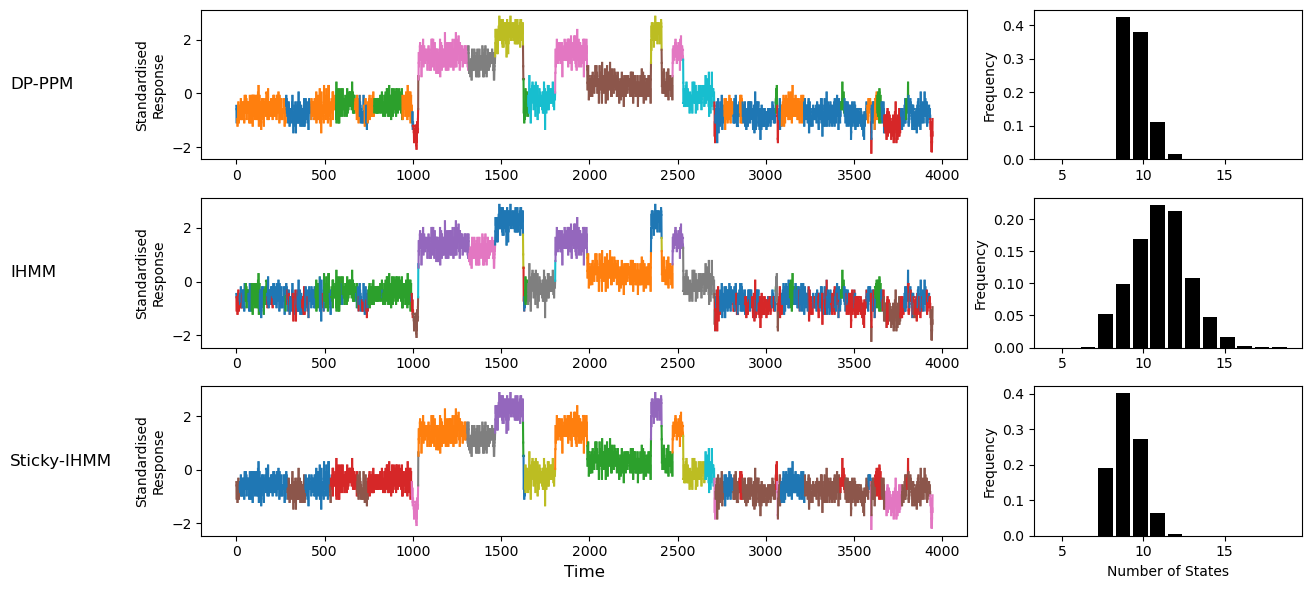

In [17]:
well_log_sticky_ihmm_states = np.loadtxt("C:/Users/k2259011/OneDrive - King's College London/Documents/univariate_models/well_log_results/sticky_ihmm_single_state_sample.csv", delimiter=',').flatten()
well_log_ihmm_states = np.loadtxt("C:/Users/k2259011/OneDrive - King's College London/Documents/univariate_models/well_log_results/ihmm_single_state_sample.csv", delimiter=',').flatten()
well_log_npcp_states = np.loadtxt("C:/Users/k2259011/OneDrive - King's College London/Documents/univariate_models/well_log_results/npcp_single_state_sample.csv", delimiter=',').flatten()

fig, ax = plt.subplots(3, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [10, 3.5]})

x = np.arange(len(well_log_npcp_states))
max_state = np.max(well_log_npcp_states)
for i in range(len(well_log_npcp_states) - 1):
    color = plt.cm.tab10(well_log_npcp_states[i] / max_state)  # Normalize the value for colormap
    ax[0, 0].plot(x[i:i+2], well_log[i:i+2],color=color)

ax[0, 0].set_ylabel('Standardised\nResponse')
ax[1, 0].set_ylabel('Standardised\nResponse')
ax[2, 0].set_ylabel('Standardised\nResponse')

ax[0, 0].text(
        -0.25, 0.5, 'DP-PPM',
        transform=ax[0, 0].transAxes,
        ha="left", va="center", fontsize=12
    )

ax[1, 0].text(
        -0.25, 0.5, 'IHMM',
        transform=ax[1, 0].transAxes,
        ha="left", va="center", fontsize=12
    )

ax[2, 0].text(
        -0.25, 0.5, 'Sticky-IHMM',
        transform=ax[2, 0].transAxes,
        ha="left", va="center", fontsize=12
    )

max_state = np.max(well_log_ihmm_states)
x = np.arange(len(well_log))
for i in range(len(well_log_ihmm_states) - 1):
    color = plt.cm.tab10(well_log_ihmm_states[i] / max_state)  # Normalize the value for colormap
    ax[1, 0].plot(x[i:i+2], well_log[i:i+2],color=color)

max_state = np.max(well_log_sticky_ihmm_states)
x = np.arange(len(well_log))
for i in range(len(well_log_sticky_ihmm_states) - 1):
    color = plt.cm.tab10(well_log_sticky_ihmm_states[i] / max_state)  # Normalize the value for colormap
    ax[2, 0].plot(x[i:i+2], well_log[i:i+2],color=color)

ax[2, 0].set_xlabel('Time', fontsize=12)

well_log_sticky_ihmm_nstates = np.loadtxt("well_log_results/sticky_ihmm_n_states.csv", delimiter=',').flatten()
well_log_ihmm_nstates = np.loadtxt("well_log_results_clean/ihmm_nstates.csv", delimiter=',').flatten()
well_log_npcp_nstates = np.loadtxt("well_log_results_clean/npcp_nstates.csv", delimiter=',').flatten()

min_ = int(min(well_log_ihmm_nstates.min(), well_log_npcp_nstates.min()))
max_ = int(max(well_log_ihmm_nstates.max(), well_log_npcp_nstates.max()))

bins = np.linspace(min_-1,
                   max_+1,
                   max_-min_ + 2)

ax[0, 1].hist(well_log_npcp_nstates, color='black', width=0.9, density=True, bins=bins)
ax[1, 1].hist(well_log_ihmm_nstates[4500:], color='black', width=0.9, density=True, bins=bins)
ax[2, 1].hist(well_log_sticky_ihmm_nstates[2000:], color='black', width=0.9, density=True, bins=bins)

ax[0, 1].set_ylabel('Frequency')
ax[1, 1].set_ylabel('Frequency')
ax[2, 1].set_ylabel('Frequency')
ax[2, 1].set_xlabel('Number of States')

ax[0, 1].sharex(ax[1, 1])
ax[1, 0].sharex(ax[0, 0])
ax[2, 1].sharex(ax[1, 1])

fig.tight_layout()

fig.savefig('Figs/well_log_states_compare.pdf', bbox_inches='tight', format='pdf')
plt.show()


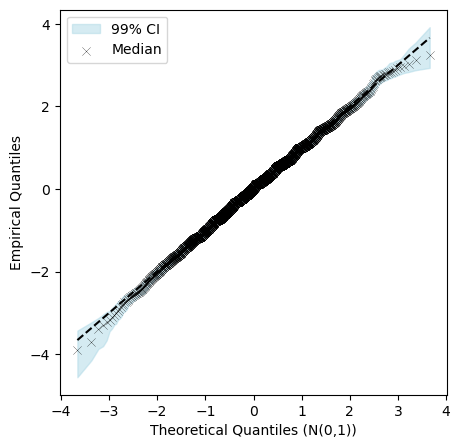

In [286]:
residuals = np.loadtxt("C:/Users/k2259011/OneDrive - King's College London/Documents/univariate_models/well_log_results/npcp_residuals.csv", delimiter=',')

def bayesian_qqplot(ax, residuals, alpha=0.05):
    """
    residuals: array of shape (n_draws, n_points)
    alpha: envelope level (e.g. 0.05 → 95% interval)
    """
    n_draws, n_points = residuals.shape

    # Sort each row (empirical quantiles)
    sorted_resid = np.sort(residuals, axis=1)
    
    # Theoretical quantiles (same for all rows)
    probs = (np.arange(1, n_points + 1) - 0.5) / n_points
    theo_q = norm.ppf(probs)

    # Compute envelope across draws
    lower = np.percentile(sorted_resid, 100 * (alpha / 2), axis=0)
    upper = np.percentile(sorted_resid, 100 * (1 - alpha / 2), axis=0)
    median = np.median(sorted_resid, axis=0)

    # Envelope
    ax.fill_between(theo_q, lower, upper, color='lightblue', alpha=0.5, label=f'{int((1-alpha)*100)}% CI')

    # Median line
    ax.scatter(theo_q, median, color='black', label='Median', linewidth=0.2, marker='x')
    
    # Reference line
    ax.plot(theo_q, theo_q, 'k--')
    
    ax.set_xlabel('Theoretical Quantiles (N(0,1))')
    ax.set_ylabel('Empirical Quantiles')
    ax.legend(loc='upper left')
    
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
bayesian_qqplot(ax, residuals, alpha=0.01)
plt.show()
fig.savefig('Figs/well_log_qq.pdf', bbox_inches='tight', format='pdf')

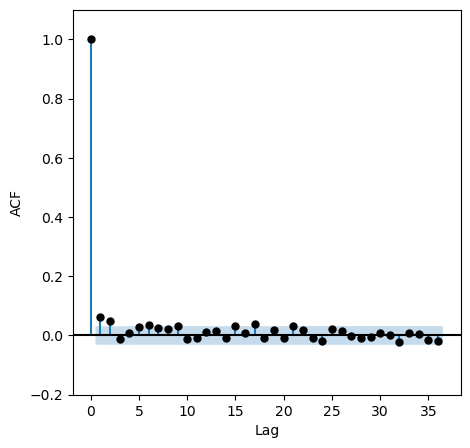

In [237]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
statsmodels.graphics.tsaplots.plot_acf(residuals[0, :], ax=ax, color='black')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('')
ax.set_ylim(-0.2, 1.1)
plt.show()
fig.savefig('Figs/well_log_acf.pdf', bbox_inches='tight', format='pdf')

t=1150 mean p-value: 0.536
t=1150 var p-value: 0.608
t=1700 mean p-value: 0.3831578947368421
t=1700 var p-value: 0.1231578947368421
t=2365 mean p-value: 0.844
t=2365 var p-value: 0.192
t=2500 mean p-value: 0.84
t=2500 var p-value: 0.27
t=2750 mean p-value: 0.7036842105263158
t=2750 var p-value: 0.4694736842105263


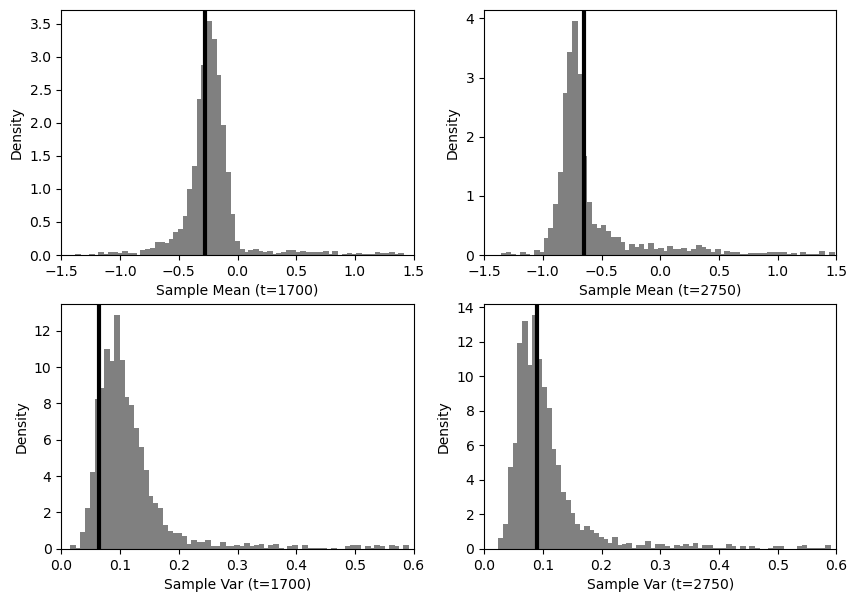

In [362]:
ts = [1150, 1700, 2365, 2500, 2750]
h = 25

for i, t in enumerate(ts):
    true_mean = np.mean(well_log[t:t+h])
    sim_mean = np.loadtxt(f'well_log_results/hppc/{t}_{h}_mean.csv', delimiter=',').flatten()
    
    true_var = np.var(well_log[t:t+h])
    sim_var = np.loadtxt(f'well_log_results/hppc/{t}_{h}_var.csv', delimiter=',').flatten()
    
    print(f't={t} mean p-value: {np.mean(sim_mean < true_mean)}')
    print(f't={t} var p-value: {np.mean(sim_var < true_var)}')

ts = [1700, 2750]
fig, ax = plt.subplots(2, len(ts), figsize=(10, 10.5*2/3))
for i, t in enumerate(ts):
    true_mean = np.mean(well_log[t:t+h])
    sim_mean = np.loadtxt(f'well_log_results/hppc/{t}_{h}_mean.csv', delimiter=',').flatten()
    
    true_var = np.var(well_log[t:t+h])
    sim_var = np.loadtxt(f'well_log_results/hppc/{t}_{h}_var.csv', delimiter=',').flatten()
    
    x_zoom = sim_mean[(sim_mean >= -1.5) & (sim_mean <= 1.5)]
    ax[0, i].hist(x_zoom, bins=70, color='grey', width=0.05, density=True)
    ax[0, i].axvline(x=true_mean, color='black', linewidth=3)
    ax[0, i].set_xlim(-1.5, 1.5)
    ax[0, i].set_ylabel('Density')
    ax[0, i].set_xlabel(f'Sample Mean (t={t})')
    
    x_zoom = sim_var[(sim_var >= 0) & (sim_var <= 0.6)]
    ax[1, i].hist(x_zoom, bins=70, color='grey', width=0.05/5, density=True)
    ax[1, i].axvline(x=true_var, color='black', linewidth=3)
    ax[1, i].set_xlim(0, 0.6)
    ax[1, i].set_ylabel('Density')
    ax[1, i].set_xlabel(f'Sample Var (t={t})')

fig.savefig('Figs/well_log_hppc.pdf', bbox_inches='tight', format='pdf')
plt.show()

## Real Data (3 Month Treasury Bills)

In [18]:
dat = pd.read_csv("WTB3MS.csv", header=None)
dat = dat.set_index(0)
dat.index = pd.to_datetime(dat.index)

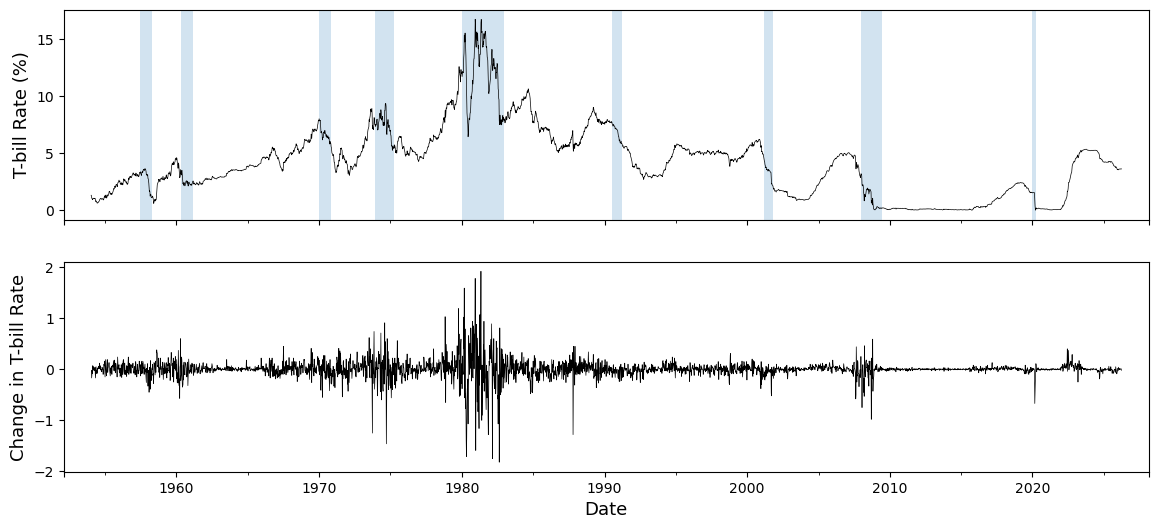

In [13]:
fs = 13
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
dat.plot(ax=ax[0], legend=False, linewidth=0.5, color='black')
dat.diff().plot(ax=ax[1], legend=False, linewidth=0.5, color='black')

ax[0].set_xlim(dat.index.min() -  pd.Timedelta(weeks=100), dat.index.max() +  pd.Timedelta(weeks=100))
ax[0].set_ylabel("T-bill Rate (%)", fontsize=fs)

start = pd.Timestamp("1957-06-01")
end = pd.Timestamp("1958-03-30")
ax[0].axvspan(start, end, alpha=0.2)
xshift = pd.Timedelta(weeks=45)
# ax[0].text(start - xshift, 9, "1958 Recession", ha="left", va="bottom",  fontsize=8.5, rotation=90)

start = pd.Timestamp("1960-04-30")
end = pd.Timestamp("1961-02-24")
ax[0].axvspan(start, end, alpha=0.2)
# ax[0].text(start - xshift, 9, "1960 Recession", ha="left", va="bottom",  fontsize=8.5, rotation=90)

start = pd.Timestamp("1969-12-20")
end = pd.Timestamp("1970-11-13")
ax[0].axvspan(start, end, alpha=0.2)
# ax[0].text(start - xshift, 9, "1969 Recession", ha="left", va="bottom",  fontsize=8.5, rotation=90)

start = pd.Timestamp("1973-11-30")
end = pd.Timestamp("1975-03-28")
ax[0].axvspan(start, end, alpha=0.2)
# ax[0].text(start - xshift, 9, "1973 Recession", ha="left", va="bottom",  fontsize=8.5, rotation=90)

start = pd.Timestamp("1980-01-01")
end = pd.Timestamp("1982-12-30")
ax[0].axvspan(start, end, alpha=0.2)
# ax[0].text(start - xshift, 9, "1980 Recession", ha="left", va="bottom",  fontsize=8.5, rotation=90)

start = pd.Timestamp("1990-07-13")
end = pd.Timestamp("1991-03-29")
ax[0].axvspan(start, end, alpha=0.2)
# ax[0].text(start - xshift, 9, "1990 Recession", ha="left", va="bottom",  fontsize=8.5, rotation=90)

start = pd.Timestamp("2001-03-15")
end = pd.Timestamp("2001-11-09")
ax[0].axvspan(start, end, alpha=0.2)
# ax[0].text(start - xshift, 10, "Dot-Com Bubble", ha="left", va="bottom",  fontsize=8.5, rotation=90)

start = pd.Timestamp("2007-12-21")
end = pd.Timestamp("2009-06-19")
ax[0].axvspan(start, end, alpha=0.2)
# ax[0].text(start - xshift, 9, "Global Financial Crisis", ha="left", va="bottom",  fontsize=8.5, rotation=90)

start = pd.Timestamp("2020-01-01")
end = pd.Timestamp("2020-03-30")
ax[0].axvspan(start, end, alpha=0.2)
# ax[0].text(start - xshift, 9, "Covid-19", ha="left", va="bottom",  fontsize=8.5, rotation=90)

ax[1].set_xlim(dat.index.min() -  pd.Timedelta(weeks=100), dat.index.max() +  pd.Timedelta(weeks=100))
ax[1].set_xlabel('Date', fontsize=fs)
ax[1].set_ylabel("Change in T-bill Rate", fontsize=fs)
fig.savefig('Figs/t_bill_data.pdf', bbox_inches='tight', format='pdf')
plt.show()


3762
3762
IHMM - DPCP: 36.63252178136827
PPM - DPCP: -212.12001575024897
Sticky-IHMM - DPCP: 21.104076309456104


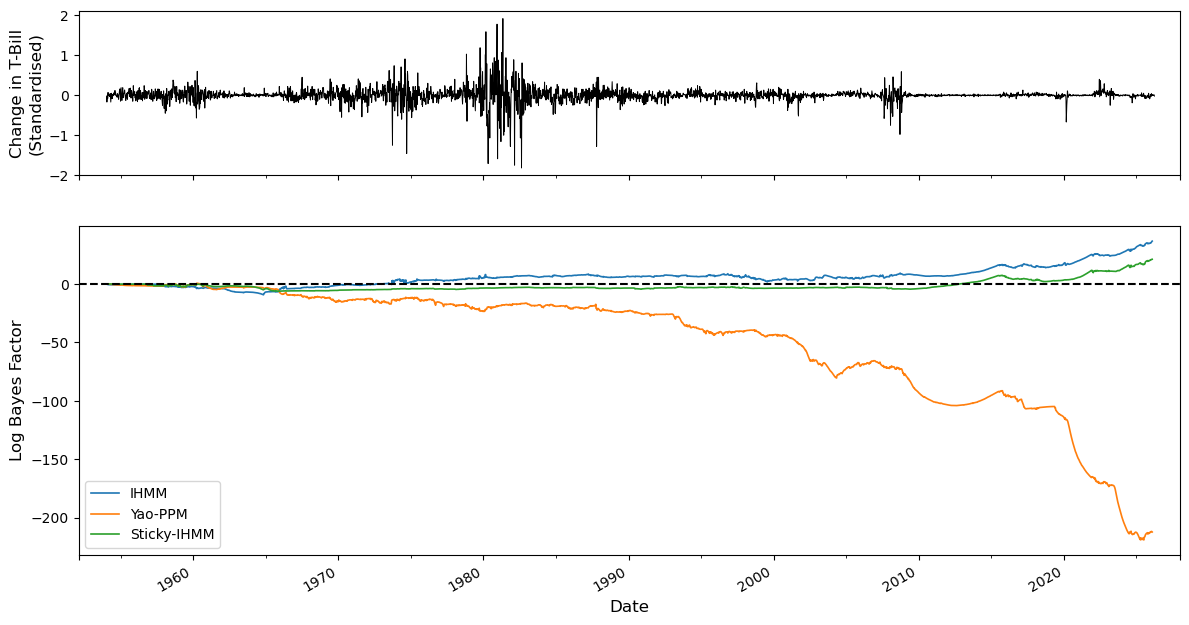

In [8]:
fs = 12

sihmm = [-1.393910534438134, -2.3270074891817103, -3.228961114997257, -4.2157182975368235, -4.879039389604484, -5.532125425459825, -6.049213116652562, -6.521980366319476, -6.932865154290334, -7.2894278445005245, -7.6578825346146875, -8.074821038414898, -8.557073955408555, -10.443760415338947, -10.947958877720813, -11.547259540943113, -11.856790063564695, -12.505644072244005, -12.766100373047612, -13.38085000385642, -13.725246370587476, -13.929593168738345, -14.172891959844703, -14.321199527084046, -14.71966244175113, -14.852650198073041, -15.057661668256682, -15.14826905225502, -16.447149949553697, -16.6316627715765, -17.11938135934245, -17.253855374375622, -17.357147093844972, -17.40259422246442, -17.525480733937023, -17.5516847983107, -17.822844488147993, -18.11199851417897, -18.12170294191113, -18.10780811011343, -18.078147537874468, -19.165802138568893, -19.190868341549113, -19.267547616806844, -20.191278484886844, -20.403682638713175, -22.488296747166306, -23.028694387891623, -25.151081400918514, -25.492244205458228, -28.66258593866674, -28.938512879732748, -29.756195266523502, -30.923177174192233, -31.125870915143114, -32.577943749378484, -34.72541436175549, -35.9241814203002, -36.29397555934131, -36.61552084260189, -36.84760430233993, -37.2666812633643, -38.40402441347638, -39.23953712192372, -39.42215590702131, -39.64737218190532, -40.07105819673577, -41.16942101569877, -41.383366913284384, -41.57248568923496, -42.20958459658286, -42.62347298043268, -42.91241060393353, -44.199600038357765, -44.946807849497624, -45.39554986435457, -45.62045585557909, -45.75740050829262, -46.5182495716768, -48.26867718643292, -48.73870953291531, -48.89987722140262, -49.39380231130205, -51.671664475952475, -51.93297350326165, -52.22020257177994, -52.61067660642543, -54.34173196450988, -54.81788198355403, -54.97242882718206, -55.13288700180204, -55.34925547900616, -57.044362918077226, -57.279274604206655, -61.91030235353909, -62.38928226272044, -62.68417336881942, -63.208983572959085, -63.472946147916886, -64.00602586115717, -64.63167661946471, -65.00602346839239, -65.27537852465116, -67.08388843337373, -67.59565208206067, -67.89494812143346, -68.116399568961, -69.0152570665166, -69.19308011480987, -71.70556213331693, -72.04237508042064, -73.27736760215936, -74.76734622247335, -74.99034161780105, -77.56375372311824, -78.88797685928635, -80.45375510046831, -81.22585300340866, -82.01064778688007, -82.2849919118912, -83.78418236004275, -84.20306563390025, -85.02400547858909, -85.23250448349744, -85.4353856660345, -86.25560970964868, -87.11801506724767, -89.06491349148627, -89.33042219821263, -89.8446466617328, -90.45717602550545, -90.79332736795195, -91.93904427713557, -95.16204436133177, -96.24693367113586, -97.98124438601482, -98.24208934963164, -99.22472401593859, -100.01781140242991, -100.25773378003022, -100.8878347379005, -101.88353111044418, -102.24345754691349, -102.83659987114082, -103.06341766283379, -103.4555688194651, -104.05726693626075, -104.35373865205759, -105.2133022530594, -105.47796677589972, -106.48709785167277, -106.69183699066402, -107.31258606235582, -107.53650878158028, -108.06080745443951, -108.31759763104175, -108.50037863482454, -108.9076626881051, -110.22922962811225, -110.44855523811782, -112.50304356654027, -112.95435242672566, -113.80842384705603, -114.00935547256887, -115.61533366024686, -115.8241421002858, -116.33089586759104, -117.00849353446954, -117.3539045287752, -118.04800672386122, -118.8801136848029, -119.36030006383245, -119.87111675484185, -121.56713782928044, -122.16517442991314, -122.35604599193672, -122.65787202072359, -123.51756203469873, -125.39147879958774, -125.59367805354862, -125.9518630568201, -126.52481701696185, -128.58463570863526, -129.82790215378188, -130.63262710415435, -131.86010712141774, -132.86326661605096, -134.98130025524594, -135.30077410211797, -135.51594486309043, -135.76834877418472, -136.75823185367727, -137.03856284664735, -137.38767912206197, -138.11147385777417, -138.6897254423614, -138.89257372254545, -139.53172487842525, -140.58566288899294, -144.2878256570359, -145.04120216467012, -145.63548076209784, -145.97368320482255, -147.2150629533148, -147.578193334587, -154.07234002071235, -154.88479190547838, -156.87835320824695, -158.55168635205433, -162.5949458084301, -163.98759953752827, -165.5755704961977, -166.71500426387533, -169.52316220272854, -172.0937065514351, -173.25865206315703, -174.36962413946884, -175.9852091738624, -177.09293388553064, -178.07948457126167, -179.03246140319357, -179.9162052670473, -180.97440100856295, -182.27570931065625, -183.2048628087317, -185.39534838511764, -186.43609938350812, -187.93819124285127, -188.94629760608018, -189.86242214255532, -190.7353101546412, -191.77814376913435, -193.38779291849983, -194.2774524334891, -195.12588641551565, -196.014671821011, -198.14484207214238, -200.67226311912063, -202.1517375261515, -203.55060987684834, -204.55444903056073, -205.3962763087099, -206.27820483500736, -207.08450168322358, -208.7801230197952, -210.16326691204574, -211.0367146912202, -211.82705097223027, -213.24503563266296, -214.05785341713963, -216.06210167284922, -216.99556940793713, -217.77672983802, -218.61786519710122, -219.36012768313168, -220.06458767353615, -221.0918071471529, -221.75027848365247, -222.5016132995508, -223.61590573639413, -224.39139915195625, -226.71769963175691, -227.43260901565776, -228.13455220859055, -229.06024355093314, -230.46259125491005, -231.1641060971462, -231.7519069683805, -232.55377621928906, -233.0956130044521, -233.86673691311753, -234.77844555772876, -235.67912241413353, -237.06787049349748, -238.38758190229802, -239.09397015167184, -239.82804856536978, -240.7935573911725, -241.3606563192665, -243.72358611813772, -244.4078611943792, -245.10861000507762, -245.60218376354732, -246.17369013694162, -247.44151138350358, -248.03972097410508, -250.9747575960895, -251.78012254535764, -252.3586821887735, -254.01256216583985, -256.8390063922685, -257.7941581541227, -258.86871514806404, -259.5683486462241, -260.39634962305297, -262.1649433484985, -263.7470743003719, -264.86311620334556, -267.2099061401212, -270.3484257979394, -271.5169588017978, -272.2474417045232, -272.93313563270266, -274.29147624127984, -275.06478391831763, -277.21250364792627, -278.214710175978, -278.91195943007517, -279.79143377339034, -281.5840601787728, -283.5906285756521, -284.55127638474255, -286.92470165071626, -288.66851006854625, -289.4351986404325, -291.6365153022888, -296.5325191717934, -297.5909565267349, -299.5445712415036, -301.8388957546545, -302.95535363992826, -308.08278729367976, -309.91642124780515, -311.0176238103873, -315.78362531108155, -318.1416260707059, -319.59859231477645, -320.9383275743363, -322.8157125217201, -324.26802121112325, -326.03662563606053, -328.2313858288428, -330.1273242073224, -331.82356594431076, -333.32504937317765, -335.04899963255815, -336.4460294827206, -337.7762431632935, -339.1212869279268, -340.26455001237645, -341.4520630302442, -342.55043130037615, -343.76422518081637, -344.838408066261, -345.7885007487648, -346.5463275807725, -347.18748353693195, -348.67518913758704, -349.3405702481984, -350.14274259494596, -351.2770348287702, -355.3473747469846, -356.36646297044973, -357.52316312618535, -359.0233048252502, -359.856572419371, -360.859515522651, -361.593578015191, -362.40250204159673, -363.0535566346216, -363.6457601720244, -364.27918185063066, -365.21150480105786, -365.54675704779015, -366.04298458754766, -366.72246017997253, -368.03216371409036, -368.5133644773907, -369.0086012572616, -369.7632952555036, -370.1609955669151, -371.44538374226875, -372.02854261181466, -372.50799104949857, -373.5858722732716, -374.03371938712365, -374.4798815543768, -374.91842285857695, -375.2031076470008, -375.4779037107374, -375.74632505743796, -376.20034710358993, -376.914963583478, -377.2006835845519, -377.4436732360955, -378.1255340135914, -378.3582891019815, -378.67353595278513, -379.04830994633863, -379.59014354531, -379.9507965904284, -380.2861005949385, -380.6786082483744, -381.3925519794008, -382.23739826340676, -383.1322300762216, -383.71904729808307, -383.9255224231516, -384.17034216066713, -384.39576441076144, -384.5691370955143, -384.81504241189356, -385.27370537477447, -385.89227560467737, -386.0644278951711, -386.2236788791954, -387.5353738005247, -388.46691040017953, -388.68376172038006, -388.8667851902877, -389.0238634278788, -389.14681759798367, -389.28668686807606, -389.56111949444994, -389.8465945674593, -390.11241647350175, -390.5911028500638, -390.87949372887067, -391.0616708216369, -391.1268232041083, -392.26315601374216, -393.2303769539194, -393.42742942419744, -393.85657381410385, -393.93351376023685, -394.14028945909956, -394.33044814722916, -394.3803503480869, -394.4468739089117, -394.5105669401781, -394.502956921541, -394.47945917740134, -395.04565294983206, -395.0315451620871, -395.01793095643, -394.97220546359284, -394.98853806094655, -395.16953004262405, -395.19462446773866, -396.35825289880745, -396.6333522884775, -396.6646179803751, -396.7165975094716, -397.1627734620146, -397.08999805175574, -397.00054242164924, -396.9242780094645, -396.87158679208073, -396.7742685391536, -396.7205011910657, -396.8694782204444, -396.7297726362131, -396.62512602673445, -396.4770594169752, -396.3319136102171, -396.2430060354148, -396.0799049423508, -395.9079312521435, -396.65797503468593, -396.51598177631485, -396.34725597002625, -396.20930518093104, -396.06148066115634, -395.88375941366877, -395.9628415737135, -395.7707061541288, -395.5734615990881, -395.3840301966819, -395.1789837786806, -395.10829484007576, -394.90636514823666, -394.75159499259235, -394.638130544154, -394.51905247445194, -394.3036815072187, -394.09004017166296, -393.8647206279266, -393.7090307779809, -393.472693094696, -393.2294965766461, -393.0009226608952, -392.7507889434752, -392.51524291587754, -392.2818163445294, -392.0296562012179, -391.79179618806677, -391.83824618883926, -391.72500449175425, -391.47054838459917, -391.31453268073943, -391.0403663972414, -390.7758889186932, -390.7409347100075, -395.3717315175908, -396.22112051245136, -396.3139716205176, -396.6009124054368, -396.5136930742941, -396.8149721998424, -396.7341637553707, -396.5850032053116, -396.5949673224482, -396.3600380359323, -396.5312665378591, -396.5938821287301, -396.5716591065771, -396.4940278618191, -396.2463026218146, -396.19769070930215, -396.16683726827466, -396.5869793300196, -396.33145362891514, -396.38528851175283, -396.1890412100587, -396.304008890127, -396.1883127940901, -396.12119711180026, -395.8927230796425, -395.6071707305943, -395.3311831526197, -395.04441888923367, -394.8417907755508, -394.5893210738858, -394.32332474037025, -394.0276672737935, -393.72666879868024, -393.55572934404734, -393.25287271898657, -393.0166304173592, -392.7004425812504, -392.37514274970135, -392.13099520280997, -392.0555515877705, -391.72667326408, -391.45991518456805, -391.1279257169855, -391.1064722638813, -390.95119137734434, -390.6136754849587, -390.2658289103441, -389.91419078455334, -389.5608942117916, -389.2852058824544, -389.05870775363076, -388.7359294674806, -388.3760045853959, -388.55607712475194, -388.55346136310084, -388.19860783232025, -387.91098010048523, -387.6742295581607, -387.35615025135775, -386.97167071280995, -386.57897207457347, -386.26961569861413, -385.9194165225172, -385.5293824676908, -385.15713001351224, -384.802126628611, -384.4232862037318, -384.0488391181748, -383.7047958944, -383.29750581916835, -382.8720968859377, -382.61742163032596, -387.7433445268117, -388.03567355917, -388.12784480034884, -388.43765944927696, -388.30694579481855, -388.2210348378864, -388.0176987946524, -387.7836816714634, -387.8882717672292, -387.72043509669015, -387.54748505595114, -387.13849931568836, -387.0598571693376, -387.03674704602895, -387.04034644466924, -386.67040982006915, -386.3164176823597, -385.89888507688613, -385.49285969428826, -385.07823643934347, -384.6400760016195, -384.14163397423596, -383.77584219982316, -383.3845217378098, -382.8949334575695, -382.40458438637364, -382.0519310822299, -381.749836896022, -381.6009187745987, -381.08703901878175, -380.625164389311, -380.42605206959104, -380.88431128226716, -380.48327231453817, -380.4191628479366, -379.8335463868409, -379.59410571159736, -379.07121676625644, -378.5558035312592, -378.5617628140406, -378.0127000808073, -377.4890285236871, -377.0512740883367, -377.9194436147351, -378.8898147013727, -378.6046606114184, -378.0668776320958, -377.78850808613544, -377.1767244061962, -376.69529363086787, -376.081909976369, -375.57107660100166, -375.00765016981126, -374.32557928476297, -380.21431881863856, -380.8800856884189, -381.4863679939272, -381.7921417693944, -382.3427014025112, -382.73453382903136, -382.8085322845484, -383.09695670680105, -383.8049097320642, -383.7658628966942, -383.7399274401941, -383.46046894470106, -383.4774755019, -383.0481361537261, -382.46122987196685, -386.14628569730917, -386.4666199008205, -386.5186516373213, -387.8430339105202, -388.03660598630466, -388.091590307348, -388.18103205388263, -388.8041361925884, -389.0059661219395, -388.8208461724239, -389.14950632833313, -388.8275172048733, -389.09050279633743, -391.3762359133444, -392.3844290020583, -395.4752544158587, -396.71512439787585, -397.0620194089279, -399.2214669619074, -400.5582272751162, -401.004521636314, -402.8185957433117, -403.61049041768234, -404.1579092223333, -405.2941647310526, -407.4669879602371, -408.1001771535555, -409.9718165690497, -410.4273757493949, -411.0231098769159, -411.914477724869, -413.0636575884602, -414.02850070130216, -414.8459509142805, -415.2967786464959, -416.52700009225913, -417.0563184182078, -417.3376262261211, -419.6976247877419, -420.6110833038678, -420.9523361561357, -421.2026290525863, -421.32711452435734, -422.5127123467668, -422.8014975771018, -424.61295831638336, -425.4330250998331, -425.91756990733154, -426.1832862200953, -427.8785425484315, -428.3378917731605, -428.90087055966103, -429.87581838636817, -430.1490856539518, -432.2550741127221, -432.72568101846065, -432.9852079298566, -433.97548276329155, -434.28581578016014, -434.7861253282419, -435.2467176198317, -435.8511168174288, -436.2392983160694, -436.4438902133912, -438.4640234135389, -439.978369737947, -444.7547271372364, -448.376876180224, -449.8348065140416, -450.7431154600719, -451.56050827785026, -452.8191909701838, -453.4404085188322, -453.9059167505265, -455.58720852451205, -456.0338355536737, -457.2694781223736, -458.1805195382934, -459.7643849517468, -460.8460018868731, -461.2974327913445, -461.9793802704289, -462.3321652421232, -462.9614952551786, -463.21829762723445, -463.80694084993036, -464.0275322685691, -467.60561663439444, -467.9824919817359, -468.2871350223639, -468.72775957657973, -468.8427760784804, -468.9401867183283, -468.7469478832748, -469.38441043023903, -470.02223637007523, -470.2233834831069, -471.83110936310226, -474.0920343854849, -474.6475197349611, -474.8813789902428, -475.3801209758745, -475.5336167461097, -478.8057183718205, -479.3508186474592, -480.35971131923446, -481.0830893437246, -482.47659407706817, -482.77408018339355, -483.54383750102426, -483.82413411201264, -484.09230192535284, -485.699657205642, -486.63731410904364, -488.3262808728697, -488.61858466570635, -488.95923741629645, -492.73553906230376, -493.6033168923938, -494.36626329474, -494.6692895227744, -494.8837069622613, -496.6763165408003, -497.62140525512814, -498.4668767858117, -500.79267590848053, -501.1286169470304, -501.4750727169129, -501.6553031971376, -502.2723045848113, -503.4559763008103, -503.824765396087, -504.6514496774902, -505.54785108629926, -505.82077271326847, -506.18912889837765, -506.76913241504593, -506.99453285222546, -507.6361795725387, -507.8745913730948, -508.13990987815725, -510.57675163241544, -511.90741794404335, -513.3952300662747, -514.7889890053905, -515.4213977718704, -515.7056532563067, -516.2821212311318, -516.5186707434423, -516.9258517044852, -517.0560088263503, -518.3042737021088, -518.5670337905111, -518.7414639177636, -518.7463296626154, -520.0138064436981, -520.1996533714683, -520.6865779855775, -522.0466624031723, -522.6341933562509, -522.9170977012577, -523.6294901247961, -525.937085066315, -526.843025575987, -527.5853526905789, -527.9794176114814, -528.3508673535671, -530.0200702586513, -535.896950324017, -537.9202445688392, -539.7397919544427, -542.7911584419097, -544.6900568582304, -545.7296541206825, -546.8614707871502, -547.7787421595255, -548.9146138440103, -549.6288095533057, -551.0051633820706, -553.3527226683464, -554.3961504521064, -555.3947711134059, -555.9964192547721, -556.480289456796, -556.8170332550494, -557.4452638660192, -557.7885022201368, -558.7305939058479, -559.4151193781486, -559.8908125659191, -560.4225964065363, -561.1168532688104, -564.3533473398297, -564.7912887027142, -567.1641694033631, -567.5531081158895, -568.0561573993618, -570.3727705307094, -572.0234866061551, -572.5631721588697, -572.8947517797611, -573.4215598954163, -577.9551224647857, -581.1011256317714, -583.1562394901944, -585.0516976939549, -585.9894075983366, -587.3197762297415, -588.1407562776449, -593.2604692347477, -595.7955075989103, -596.8220343356278, -597.7149114086214, -599.7658210353707, -601.4750979760537, -602.7014071262015, -603.5954584224387, -604.5466937912419, -607.1003022151413, -608.9691239170675, -609.9765227661106, -610.8745303184594, -612.6282582631081, -613.5013585342572, -615.0986416100493, -616.7915061832678, -617.8702532500837, -618.794399290409, -619.7645228835232, -620.494667041291, -621.7554302193803, -623.168339655653, -624.743488228902, -625.3374567292935, -627.3027570979499, -630.8431625298867, -632.1743347003057, -633.6658285785044, -634.8999266061559, -636.0315446066923, -636.904764932241, -639.317068963684, -640.2665441707501, -642.4192812353458, -643.672983431206, -644.607126222217, -645.4739790544684, -646.8319507625791, -647.8790028747591, -648.5863086590734, -649.2561071828999, -652.6215322156658, -654.3907410937658, -655.4578138880858, -656.755736673503, -659.344088849853, -660.3478963156092, -661.4317566677298, -662.3287170093421, -663.1488447714062, -664.4093900845094, -665.1554819637558, -667.5819553984284, -668.7289089462388, -669.8839090326898, -671.5813946158312, -673.0984914464553, -674.3563323016964, -675.6008158643268, -678.8456903517715, -679.9361677892755, -681.033728864272, -683.5531483903424, -685.7167181398746, -687.1744880019457, -689.8438045601395, -691.1580445246768, -692.2825612989603, -693.357233851415, -694.3737367941224, -695.4320100596777, -696.1757465559868, -701.7248592618073, -702.9138042423269, -704.4212894453512, -705.9348420719537, -707.1951514296474, -708.29157094853, -709.3934285493267, -710.4160689112521, -711.3175683467135, -712.0841389796727, -713.2515384904566, -714.7221671383899, -715.403081324562, -715.9582055894444, -718.3460778760133, -719.4276254481198, -720.9194249153696, -721.6069690190483, -722.0959720312152, -725.3655627454416, -726.2916543452105, -729.8513872522117, -731.8420238783391, -732.9737380067114, -734.2262207874866, -736.0558235098786, -736.9952849022545, -738.5805757119537, -740.0270505240983, -741.0292548212324, -743.1489327958768, -744.3674607857214, -745.2767769323367, -746.0565607384177, -746.5035818806318, -748.6131925009121, -749.4501373537358, -750.1708000656643, -750.6600242997812, -752.4360543722756, -752.9560190527518, -753.3796408815691, -753.7167412776262, -753.8061531126076, -754.9340363014453, -755.1831780201118, -756.1514689514346, -756.53428460411, -757.6576819323527, -758.0055547010461, -759.7255740681551, -760.6865895855532, -760.9914327527426, -764.0593178644899, -767.7016093598752, -769.0392782332214, -769.9508438546121, -770.691052095193, -771.3304969619846, -772.0940149253321, -773.1798604753573, -773.694974684272, -774.1739486228787, -774.4993362956964, -774.7824488308665, -775.2606508358454, -775.6597499098208, -776.0232970741317, -777.1148401751794, -777.3789779879971, -778.1404190531597, -778.5302465969752, -778.829682747368, -779.0380991616302, -781.9336965923764, -784.6192038472715, -785.1629526737983, -786.7077669616505, -787.5247956872341, -789.637408594917, -791.6068226942508, -792.189421596564, -794.1396438817981, -796.0633225800333, -797.09905661498, -798.6195837510212, -801.2061825964047, -802.1240473342602, -803.1361158733229, -803.8591721341052, -805.5069061011998, -807.1653978635273, -809.6092259183741, -811.6048554651228, -812.6179397328966, -813.5267973437491, -814.5032292842945, -815.2920871333847, -821.9891491469315, -824.5430109348165, -826.7172052178663, -827.7984038632511, -828.9042291121549, -831.8748776035759, -832.960259424389, -834.660217297627, -835.6534097905616, -837.29855360682, -838.4006477304033, -844.2431446840635, -852.6891070990208, -857.4695361276517, -859.7259131569966, -861.4984878954043, -863.1198271975824, -865.5269574728369, -869.0292974574728, -870.9837421833316, -873.2969999775069, -875.0860979941183, -876.4988144228612, -877.5839562763323, -879.5618746877495, -881.5129114795532, -882.5491220001571, -884.8549243717524, -886.1468038833874, -887.0674276595419, -891.1211274115044, -893.854687336613, -895.4760208877932, -896.6962589770703, -898.8958646053942, -900.9039254214518, -902.1848067669761, -903.9400589314872, -905.7046834762765, -906.9527485702898, -908.0523052222801, -911.4749302044041, -913.0115704439712, -917.7281805307088, -919.9515587344347, -923.0505918604969, -924.5758493331969, -926.2594496939919, -927.6186494256069, -929.3843534536855, -931.8749592553573, -934.105114543008, -935.7690806082336, -937.2713265239591, -939.2748487755158, -941.4250795072775, -944.0277051284924, -948.9757035803785, -950.7434872141432, -953.6672875952898, -955.1969311955223, -956.5829276285108, -958.6088043329612, -968.3426636452887, -971.1351865690111, -972.8342269461298, -976.1118347320537, -978.2045139421799, -980.1958099060209, -982.442795684345, -984.6860128057483, -986.7759491229018, -988.8287739460515, -990.4594709868824, -991.7616587788642, -993.821307056985, -995.8859228432527, -997.6184114168334, -999.072468704074, -1001.4764616024261, -1002.9409480938807, -1006.0900099086323, -1007.8143267596245, -1009.2923970375002, -1010.5518898057016, -1013.455782498009, -1015.5527879825098, -1017.0930042916838, -1018.7091554993299, -1019.9715699699216, -1021.4609113974709, -1022.4644178840086, -1023.4994099287678, -1026.7549188920839, -1028.862581927096, -1030.4786925538278, -1031.7255894615353, -1034.3114671867136, -1035.9644176781478, -1037.1306171000347, -1038.1369646590952, -1040.092431004309, -1042.22966880564, -1046.11173077552, -1047.4521683933654, -1048.5839776480152, -1049.5054248877345, -1051.5730818906065, -1052.6202597650154, -1053.9493551316864, -1054.8194361031963, -1055.5922399753563, -1056.1101308397806, -1057.3373059718936, -1058.1025270614555, -1058.4949635751186, -1059.1775438543095, -1060.068868093843, -1063.4978738114353, -1065.0743235346806, -1067.1919897775322, -1068.1439344172693, -1068.9147780001078, -1069.9648031375357, -1071.4588189375716, -1072.1133997704649, -1072.635195402797, -1073.0481235126392, -1074.923581074118, -1075.9893253247797, -1076.5338296478394, -1077.3765997163032, -1079.5423466215498, -1080.0348035827212, -1080.5307162683098, -1082.8068815882034, -1083.7811067161383, -1084.2684604443073, -1084.6550540730311, -1088.6698130976051, -1091.4657955933997, -1092.4223471172538, -1093.5350809429817, -1094.7309544921764, -1095.7108527610048, -1096.729400694474, -1097.4254900287738, -1098.4491940807375, -1099.01587391909, -1100.98006206621, -1102.5190264023677, -1103.3864911742717, -1104.0062183249377, -1105.0192514356193, -1105.5839084721827, -1106.0441380623447, -1106.4726354437798, -1106.7742236777258, -1109.013782108509, -1110.2930742945052, -1111.0406189258883, -1111.4235678257405, -1111.7550492689718, -1112.077400648977, -1112.409043936883, -1112.572105067167, -1112.6134260841732, -1112.403550869262, -1112.7143231781229, -1112.3543995184548, -1111.973818531874, -1116.1353788895744, -1116.5855474565672, -1117.1798241287697, -1117.9421975082842, -1118.9400065946215, -1120.4325754606868, -1122.2799388569865, -1123.4688510146407, -1123.9460129654813, -1124.6298570921379, -1125.0513560416935, -1125.798710763749, -1127.0547347669894, -1127.5130969423979, -1127.941823731285, -1128.3906707894905, -1128.7262794821124, -1129.495800937161, -1129.8441393939884, -1130.4962546902257, -1131.1031419011283, -1131.3785162645688, -1131.6841173046164, -1131.8463678106668, -1131.9077283321121, -1131.8484067530717, -1131.8158796715384, -1131.8019724240498, -1131.3409791602282, -1136.5631617002, -1137.9714140836377, -1138.539129654889, -1138.9548201683053, -1139.3439733243717, -1139.6807574170168, -1140.2016685192325, -1140.306358324822, -1140.5540676848555, -1142.8678719863888, -1143.1689671427202, -1143.5365102930814, -1143.9349924082169, -1144.458812759176, -1145.3202412221885, -1145.777506051956, -1146.2343180132532, -1146.5773264987297, -1147.2715393622482, -1149.5675503460438, -1149.8989380310509, -1150.1843548412696, -1152.8491985906126, -1154.7375482067455, -1157.3217383861895, -1157.945650521132, -1159.2215648455424, -1160.0166069359489, -1160.678757934613, -1161.0572104828248, -1161.3810694036888, -1161.7107525519282, -1162.098041474506, -1162.1351480948317, -1163.7833500181762, -1164.0710335570734, -1170.3562063591835, -1172.1716820593656, -1173.146141801049, -1173.9446196688416, -1174.5292715568748, -1174.911506913736, -1175.2240225664257, -1175.783837209469, -1177.2650300530006, -1177.2853159336116, -1177.770569556604, -1179.841852342527, -1180.1433295890126, -1180.9407924561115, -1181.3728455313403, -1181.8554424396568, -1182.8860526505746, -1183.263952199383, -1183.6534625094432, -1186.3887917560048, -1186.9234145428477, -1187.2766233913842, -1187.59147753992, -1188.9311750724512, -1189.818439396307, -1190.49116869965, -1191.1192973926134, -1192.5810501666047, -1194.826708616335, -1195.2507064296317, -1195.52553148575, -1200.7057749662815, -1201.5293617700556, -1203.5073675801755, -1204.3212738542043, -1205.6268823903902, -1207.4074635379175, -1208.671646100791, -1210.3506603600028, -1212.059768993503, -1212.9967519180418, -1214.4337695790903, -1224.6807909724157, -1226.956655512658, -1230.2831722180706, -1233.3023467062396, -1235.3090887998676, -1237.0641973994009, -1238.4436076495958, -1240.9074170395884, -1242.5553989263935, -1244.0893776438256, -1245.3540927461881, -1246.9267380774347, -1248.3475321082335, -1249.2064844748425, -1249.79396409699, -1250.3613927183287, -1251.5648988249518, -1251.9345196346987, -1252.2414117239512, -1252.8648409025773, -1253.099772341252, -1253.9288541378596, -1254.7281956667696, -1256.3504219646331, -1261.2013612609378, -1262.404997483544, -1265.7725255982389, -1266.832773311818, -1267.7462975854924, -1268.5420913369173, -1269.7447902029255, -1271.3365944086274, -1274.3570153376252, -1275.4559039756068, -1276.6905147919258, -1279.0743686795333, -1280.2557701486865, -1281.1528642731637, -1281.9548918313192, -1282.6709980471812, -1284.516211628441, -1285.4454305780355, -1286.0889027027295, -1287.9126054417102, -1291.819864116193, -1293.074778038581, -1295.073190576, -1296.110270595384, -1298.6602477752424, -1307.9221934153863, -1309.7888831375606, -1312.9249012070948, -1316.158307170967, -1318.2345413261141, -1320.5041492009886, -1322.1882305758174, -1324.8928647524365, -1327.746801702121, -1330.3098024134392, -1332.5969183812526, -1334.2308586278125, -1335.9558315502115, -1338.5147675091669, -1340.5076134106264, -1342.4211094062814, -1344.0292899551032, -1345.5293517852617, -1347.942747588753, -1352.937909861975, -1354.816797655922, -1362.9935556460605, -1365.392141302057, -1368.0516366796392, -1371.8637670630706, -1375.5878735863703, -1377.8724189752886, -1380.8029410790564, -1385.9513522208217, -1391.0980113122353, -1394.2634180309403, -1396.4775634587118, -1398.5965362217964, -1400.8951332611266, -1402.7879935849835, -1406.8380977600432, -1409.866620503255, -1412.4692296996147, -1414.6925731400722, -1416.616638928416, -1418.5467031265223, -1419.7276635940436, -1423.5242696881792, -1425.3189999821016, -1426.5577935472668, -1430.9730136412736, -1433.2083130794927, -1435.6461381976985, -1437.9757329626052, -1439.8935793844203, -1441.763842844189, -1445.5922407170622, -1448.0869528138985, -1450.0652027103235, -1452.9833786644913, -1455.8094685147273, -1458.255697970913, -1460.3967704336487, -1463.3791600023976, -1465.3738606212742, -1468.0404498204323, -1474.123980448067, -1478.7869735042646, -1483.885820039635, -1486.092335095548, -1487.8761057916438, -1491.6834150011869, -1493.8384514697227, -1496.994230499815, -1499.0216100839957, -1501.9563244142128, -1505.7180591444235, -1507.933880335487, -1510.3507649255203, -1513.321424972774, -1516.7696439147567, -1519.5991694541733, -1521.9928072061773, -1526.1320868622731, -1528.4717650321336, -1530.4866977155505, -1533.6613921533772, -1539.621227073092, -1541.9598835622764, -1544.202219714918, -1547.7193708792868, -1550.1379669800392, -1553.478583055434, -1555.7180421712821, -1557.9548349688384, -1559.8812467946686, -1562.7350239755392, -1565.161879741988, -1568.7957264102824, -1571.6841440585288, -1574.1948588526607, -1576.4705438892013, -1578.9239728416578, -1580.9230233048684, -1582.9222767071549, -1585.6773510350708, -1588.5986730222182, -1590.7418773857962, -1592.6886452571187, -1595.6134843841762, -1597.8291302464381, -1599.7821847571286, -1601.961282114186, -1605.5293415408391, -1609.1500648959477, -1611.3831114694237, -1613.4139196521319, -1615.5341787786583, -1617.0735673991271, -1620.2500141829432, -1622.1143093026778, -1623.9174897974044, -1625.7055723854428, -1628.6741053640412, -1631.3893203651726, -1633.1860691503002, -1637.0225562656758, -1639.135089904419, -1641.247392061386, -1648.0837862116146, -1650.6373091608837, -1652.8318799437545, -1655.1333943732611, -1657.321664028326, -1660.158298352482, -1662.5376993989375, -1664.765628891686, -1667.0084948279575, -1669.0512445657068, -1670.913258025892, -1672.8804655014749, -1675.71257176042, -1677.7903924879802, -1680.8734000627321, -1682.9612336564676, -1685.3744453383579, -1687.6107843483596, -1689.654101197526, -1692.4059274182594, -1694.711154434805, -1698.2556930985702, -1700.370250030709, -1703.2831128761338, -1705.3189080077054, -1712.4551357341818, -1714.597462565187, -1718.0859631282672, -1720.2609911625773, -1722.5606224166404, -1724.9639008510358, -1727.0440518837793, -1729.5083422091222, -1732.1620984960045, -1734.3011890730602, -1736.6624944196192, -1738.8554119492992, -1741.1361113011894, -1743.194228242847, -1745.6987619185395, -1747.8987292070785, -1749.9641910209516, -1751.8237529801463, -1753.556865042911, -1754.9165516430703, -1756.2325578994476, -1758.2963349605322, -1759.694116584921, -1761.8388192047732, -1762.9604185744333, -1763.9685878938838, -1765.0049362747104, -1766.999848708341, -1768.2052925469227, -1770.2682377281205, -1771.2666911330248, -1773.04720010274, -1774.041596979417, -1775.732032907745, -1777.6215326048505, -1778.6227245282696, -1779.5129947083108, -1780.5536115941848, -1781.2801357255396, -1782.491841335398, -1785.3343285251922, -1786.294127172623, -1787.7170301844722, -1788.8590095060867, -1791.1133136596627, -1792.4571246738553, -1794.0998836777308, -1795.051938146162, -1795.9142470581899, -1796.6886583554935, -1799.235355760732, -1800.20591650824, -1801.8096875397314, -1803.1777345790758, -1804.5323600131965, -1805.8774343461685, -1806.8092378458732, -1808.0273259950648, -1809.3882121843983, -1810.4015876561298, -1812.0838788606206, -1814.459041718104, -1815.9726641173852, -1817.117894166311, -1818.744290503292, -1819.6796060437036, -1820.5671343449665, -1821.6460152008374, -1822.5725168882407, -1823.6052823477053, -1824.7714983785804, -1825.4716510835635, -1826.0029781033043, -1826.701215783265, -1827.0792318302497, -1827.5498122938363, -1827.8776612882027, -1829.7243087488316, -1830.0701559970403, -1830.77238733937, -1831.0903093694178, -1832.1094861690542, -1833.1177209168814, -1837.5123173896548, -1838.7909542515663, -1839.4514273452994, -1840.3782984804925, -1841.651587681105, -1843.0925953349788, -1844.2239591462771, -1846.4128972929996, -1847.7633289855883, -1848.656130907896, -1849.3223955930841, -1850.0268256332024, -1851.2373874939008, -1852.0071428065655, -1852.8547957479564, -1854.1364757975932, -1854.992193061777, -1855.5022218516194, -1856.629423397952, -1857.890390815545, -1858.303569710529, -1860.4060961759571, -1862.1771396448846, -1863.914641550543, -1864.8361495277568, -1867.0680474529324, -1867.811241811399, -1868.4409549337372, -1869.015248969568, -1870.6951984848697, -1872.1384750400564, -1876.8675045274395, -1878.053420307103, -1881.3377864057634, -1882.7456123177942, -1884.0271216230644, -1885.1602626137565, -1886.1451553381519, -1887.6446436772962, -1891.2815782992323, -1892.286099564407, -1893.8687850196852, -1895.0592434499763, -1895.9650037473193, -1896.9582605317246, -1899.363798817859, -1900.8436370138897, -1901.7837729884216, -1902.8406478244428, -1904.077431881304, -1905.5606703289643, -1907.1733184281168, -1908.0838205010944, -1909.7929755196649, -1910.7732004999389, -1911.7044471505128, -1913.3379338309185, -1914.2284616040615, -1915.0377265055063, -1915.7423405764368, -1918.1420508416131, -1919.6296686121234, -1920.4964453602972, -1921.9144300904009, -1922.8596668651035, -1924.735715038108, -1926.4940712415066, -1927.625088646477, -1928.7271272904406, -1929.6505960520196, -1930.8464472847643, -1931.661525308752, -1932.6182173851757, -1933.434637599132, -1934.108274978514, -1934.6027375473075, -1935.2963431656553, -1935.9673041632802, -1937.3235893821538, -1939.5487596864286, -1941.312356160613, -1942.5000697020437, -1943.1413071473073, -1943.6736366256548, -1944.1313740279754, -1944.6835957523638, -1945.0466359799764, -1945.7119158986325, -1946.062611398648, -1946.7353117016637, -1948.5341840006697, -1948.8795771418893, -1949.2482988257345, -1949.5810701194614, -1950.327161069397, -1950.6194394883876, -1952.9569819830383, -1953.3736439634856, -1954.0758053676575, -1954.433231100818, -1955.0503251013126, -1955.3394589831692, -1958.9654640317494, -1960.2636007306678, -1960.7933027111833, -1961.4499027657014, -1961.952962248787, -1964.6757437692092, -1966.2995237994905, -1969.076640539448, -1969.843662580473, -1970.7410409830425, -1971.7649465981392, -1972.3826097684175, -1972.895765065975, -1974.6218126161689, -1976.409996086553, -1977.858183315019, -1978.4984368424475, -1979.3771291106787, -1980.185311240215, -1980.9494704213378, -1981.5603575176358, -1982.0511128028454, -1983.3497348666815, -1984.043945538785, -1984.830891961891, -1986.7236067863223, -1987.143698723759, -1987.5186980214503, -1987.877708387293, -1988.4519452384636, -1989.0372181856271, -1990.2676960720712, -1992.4393494177104, -1992.9463583309719, -1994.1143725112138, -1994.9600756243158, -1996.1837197504024, -1996.98330835161, -1997.445619455449, -1997.80732318719, -1998.3509166025508, -1998.8892212212006, -1999.260098793929, -2000.0757241327824, -2002.8133527829857, -2003.3814896148522, -2003.7887204539745, -2005.444589620569, -2006.0452847432014, -2006.9154649881764, -2009.9477788480042, -2010.5192321005106, -2011.5781919060112, -2012.4253495599942, -2013.794068847979, -2014.506656795027, -2015.0459534123593, -2015.6690340899167, -2017.372806904021, -2021.4605892344975, -2023.2937103745949, -2024.3934785533415, -2025.3870613637582, -2026.1229820297106, -2026.738299480008, -2027.2954331031779, -2028.807921679402, -2029.8492791957706, -2030.9433718686328, -2031.888694267185, -2032.607110611883, -2033.1124654197067, -2033.8732902591603, -2037.187673419034, -2038.3387168901788, -2039.1607712221573, -2040.10511351956, -2041.7315022651335, -2042.5006131595608, -2044.2620782584572, -2045.0194080144117, -2046.140847730113, -2047.2507222181466, -2047.809284018509, -2051.6587519474406, -2060.5507976177787, -2063.090954584372, -2065.820163844078, -2067.8308318598865, -2069.542421918282, -2070.693533070288, -2073.852922575541, -2076.850097917326, -2078.7589644884624, -2080.4659952655775, -2081.8725082935653, -2083.463840879763, -2084.4857642246634, -2085.2426632466086, -2086.3771194715423, -2086.9927390779094, -2087.444859697989, -2088.1309762012384, -2089.113921275785, -2089.5058957285473, -2090.394694603304, -2091.4258871076513, -2092.9096544707327, -2093.472769075905, -2096.8178981042856, -2098.1711773627953, -2098.8392311547063, -2099.6701928217576, -2102.308813374984, -2103.072050126371, -2103.782080364307, -2105.0527692566548, -2105.8051482661103, -2106.367974469616, -2107.0197750058915, -2108.515376052612, -2109.059180527117, -2109.4796479852603, -2110.543722614969, -2110.952538267309, -2113.306439342737, -2114.0932812042897, -2114.9597331437963, -2115.428949961252, -2117.0061808821583, -2117.529163377179, -2117.926188783712, -2119.077916911561, -2119.537716904838, -2120.4866602162124, -2121.1495072936546, -2121.7749169343547, -2122.4427985596635, -2122.8133348708257, -2123.272910025063, -2125.580204415806, -2129.5478263103837, -2130.242285973559, -2131.1467645614616, -2131.7174544289155, -2132.861752783871, -2133.3245594658197, -2133.840148314942, -2134.4706608625715, -2134.8463096975242, -2135.2039230653218, -2135.7055529129375, -2136.411064306089, -2137.5135518936777, -2137.9299874557355, -2138.3980951985513, -2139.1561912716465, -2139.6638511431333, -2140.6213757762134, -2144.310003208134, -2145.251140257029, -2147.0000910675326, -2147.8225393459215, -2148.80313546263, -2149.2674224464804, -2149.688506355321, -2150.705316269949, -2151.6100442135426, -2152.9611057952943, -2153.863412920092, -2159.3541644648913, -2160.3614298166203, -2161.160656230134, -2162.2141549745584, -2164.0042661909692, -2164.7696731446686, -2166.6440272477184, -2167.44014735916, -2169.894025416125, -2172.0760901539497, -2172.995956100058, -2173.840786637067, -2174.8419054009414, -2175.7180421344583, -2177.517201182249, -2179.018716481112, -2179.997866885591, -2181.047909898312, -2181.996203121496, -2183.250897737223, -2184.4638869816768, -2185.7921829409584, -2186.651898671138, -2187.458494008526, -2188.1850008685706, -2188.8306042329955, -2189.358821685563, -2189.872078239757, -2190.4624375034255, -2191.3152364865314, -2192.308837806565, -2192.7981693118186, -2195.087302642061, -2195.7812821957336, -2196.482654708174, -2196.9323856486712, -2198.3651605148893, -2199.3112349160447, -2199.7487944765808, -2201.1326206406584, -2201.587976307405, -2202.0701818545413, -2202.7347703363644, -2203.321633105162, -2203.736136850469, -2204.0919449020453, -2204.4454384753335, -2205.0324835058113, -2206.277407875395, -2206.7517464008097, -2207.2606622855865, -2207.6121514573965, -2208.0376090035006, -2208.3163576790735, -2208.652516025389, -2208.8381152909824, -2209.991949104505, -2210.141729404964, -2212.4868224719166, -2212.829145618818, -2213.63288121015, -2214.0402974823405, -2214.8599462700863, -2215.461854652446, -2216.366834256427, -2216.912910359986, -2217.256340285198, -2217.5256956857293, -2218.3234528798, -2219.7646175995083, -2220.350607370074, -2220.735451779547, -2221.0194013088635, -2221.6843548925503, -2221.960499249156, -2222.2107989600136, -2222.3749425500014, -2222.5077188739233, -2222.830736851729, -2224.6875523098474, -2226.05178173168, -2227.4449724982337, -2227.8575004226827, -2229.537725402425, -2231.869403663055, -2232.900928945457, -2233.388752711285, -2236.4247164672897, -2236.993451189565, -2237.812813879094, -2238.580793146687, -2239.0290960894645, -2241.6234524118113, -2242.498617554635, -2243.136532857661, -2243.7442781883024, -2245.124687883096, -2245.842076591603, -2246.266777517074, -2247.849627308719, -2248.2644615651266, -2248.701315323174, -2249.052612478537, -2249.3786016983418, -2250.4817145735833, -2250.872021639636, -2251.1937167174324, -2251.494750304796, -2251.7762052933526, -2251.8989183028984, -2251.878395704412, -2251.6211054899773, -2251.9138432094974, -2254.0768148453485, -2254.800201969532, -2255.0535456769753, -2256.2325474792974, -2256.6479507100116, -2257.401276621159, -2257.6905221933916, -2257.9497472467033, -2258.6919398916384, -2258.998288207983, -2259.1456545233623, -2259.208833125209, -2261.508066991694, -2262.776853991754, -2263.127283029867, -2264.2300834785983, -2264.798146735295, -2265.199241570671, -2266.710619353443, -2267.457427506241, -2269.621622954695, -2270.7494747994933, -2271.810870643066, -2272.404238215274, -2272.897744999856, -2273.5878580676385, -2274.0484664626038, -2274.4739771487434, -2275.622459384876, -2276.038498512083, -2276.7267764365797, -2277.1641280250333, -2277.5782137895, -2277.9636294957922, -2278.2294689856135, -2280.9029321958947, -2281.9673063708833, -2282.795982215816, -2283.1354388525747, -2283.684770959149, -2284.0089694512108, -2284.3171322001813, -2285.1905182169135, -2285.5226753214965, -2285.9045418817227, -2286.213989303634, -2286.464526076799, -2288.4823010623722, -2291.3338871206897, -2291.823066425876, -2292.1866968341683, -2292.509741721167, -2292.806156578022, -2293.2088771482445, -2293.4622281227457, -2294.500251476224, -2295.2240275106496, -2297.2346680421138, -2297.6237429384496, -2297.9336736284067, -2300.412456420367, -2301.5471612351625, -2302.674633362064, -2303.0534251385907, -2303.421487945988, -2304.218610339873, -2304.5809349491656, -2305.1493140489033, -2305.658982647002, -2306.0455706164475, -2306.687257821478, -2306.9977301546733, -2307.2986690548173, -2307.5616929007215, -2308.0005936506227, -2308.653505090608, -2308.876315428887, -2309.4566619505285, -2309.6317946648314, -2309.699596763941, -2309.6394219058147, -2309.65339609993, -2309.3462575300173, -2309.196172770516, -2308.8397620452674, -2309.024949363203, -2308.5505712847134, -2308.0896043351645, -2308.7126391240904, -2308.4499912850483, -2310.997614685527, -2311.5966687268287, -2311.8366256378386, -2312.5933075792723, -2312.8909026052534, -2312.6536499117587, -2312.6760171854307, -2313.135131873972, -2313.3739935497197, -2314.7898739923808, -2314.6907213680765, -2314.3874665115914, -2314.588689127457, -2314.307900976845, -2313.907704924711, -2313.8907190321593, -2313.508965861393, -2313.08240795172, -2312.6513927911574, -2312.4112034817076, -2311.973994220946, -2311.766188157679, -2311.339417980549, -2311.579511105292, -2311.55154476258, -2311.125482409835, -2310.742580277313, -2310.31982670226, -2309.921206773524, -2309.4445076704333, -2308.909705082035, -2308.43867568875, -2308.6673872471606, -2308.3146534381954, -2307.9676481766933, -2308.040687497463, -2307.9559228128824, -2309.5024420761983, -2309.091487615404, -2308.852832065057, -2312.981474998462, -2314.3997835249334, -2314.894865302554, -2315.5926210288935, -2316.493444392605, -2316.8760072959294, -2317.1946169968046, -2317.518451666968, -2317.735257466718, -2318.7212549997002, -2319.1997246123897, -2321.145032429017, -2321.815440497345, -2323.47662526168, -2324.344136980664, -2324.9602961535097, -2325.3274606657374, -2325.706748418901, -2326.0396336653334, -2326.292013612384, -2326.57073678966, -2326.681738208768, -2328.1986782873787, -2328.693306625788, -2329.5261129223586, -2330.5118605989155, -2331.1333318981888, -2331.7403552480296, -2333.223938536973, -2333.7035390193764, -2334.0030248136427, -2334.271712695789, -2334.537731528738, -2335.6412658690456, -2336.334108746453, -2340.05616495709, -2340.6146049592767, -2341.0166386416786, -2341.573195440682, -2342.195239566976, -2343.037138167504, -2343.7925083706004, -2344.326058380125, -2347.3821074285524, -2348.4292384379387, -2349.1876797153304, -2350.8431699448724, -2351.5129072035356, -2352.8955519257797, -2353.409685185201, -2353.863790490845, -2354.396741804209, -2354.7788705712937, -2355.189112921733, -2355.5274082159403, -2355.7710803599443, -2355.9522543859566, -2355.974915038512, -2355.8551793905185, -2355.7002362086187, -2355.472582622943, -2355.0164588434272, -2356.0931333814874, -2355.6547690803513, -2356.350464446651, -2356.1592259645163, -2355.6616279770674, -2355.943173507507, -2355.468864560738, -2359.388968089168, -2359.7873636678605, -2360.7023247013035, -2361.0753569432936, -2361.152091240562, -2361.0601306053486, -2361.186161750161, -2361.385909617384, -2361.0565455772257, -2360.7647742141644, -2360.3899359716206, -2360.4389321432795, -2360.3641862429326, -2362.2752229705843, -2362.2942946057083, -2362.0588148045035, -2363.4787644711296, -2363.8927764644714, -2363.792412485804, -2363.407534127598, -2363.2151042474784, -2362.9347171770028, -2363.9425814961946, -2364.305268920295, -2363.9415706126565, -2363.7607162255877, -2363.3819906980716, -2362.930455876539, -2363.370718100897, -2368.6553720005254, -2369.5161591978876, -2371.072755833345, -2371.687774509865, -2372.3231239634006, -2372.7454929353485, -2373.1817759170053, -2374.2733736268456, -2374.6270374627197, -2375.002453820177, -2375.391107462117, -2375.5911952028437, -2376.289443660013, -2376.453522051432, -2376.483488943973, -2376.358396089929, -2376.4835215779885, -2378.3897947929936, -2380.040284866265, -2380.369878283896, -2380.638459177328, -2380.819071307196, -2380.9918648841326, -2380.944777600556, -2381.235649745436, -2381.0543343381846, -2380.8696162170268, -2380.4877556591077, -2380.4702923448203, -2380.0697464758837, -2379.7663575788706, -2379.5904301881806, -2379.165984310351, -2382.1823340560336, -2382.045705346242, -2381.7321670746137, -2382.578441770299, -2383.8730782667617, -2384.883644597805, -2384.698869022882, -2387.28325429118, -2387.633205538646, -2388.4576762437114, -2388.633483890014, -2388.723592637031, -2388.8168567190633, -2388.683830611116, -2388.4258255281507, -2388.099176418288, -2387.734511156738, -2389.534499085888, -2390.2803095727027, -2390.926370098595, -2391.8718197485364, -2392.354298601292, -2392.4514902229953, -2392.2381660738442, -2391.9425275216445, -2391.597940450285, -2391.8040246571177, -2391.515933567055, -2391.36464768785, -2392.661232805617, -2392.423371599705, -2392.1168315215973, -2393.6059565675296, -2394.0956687565017, -2395.689430763858, -2395.5488079189286, -2395.421022054556, -2395.2589243290968, -2395.3770791081265, -2396.422053059711, -2396.136149338315, -2396.3664917781093, -2400.3847186166686, -2400.655337050868, -2400.8533917314066, -2401.027870278173, -2401.6809034929197, -2401.7804327658832, -2402.2210459639027, -2402.835602309339, -2402.7668465171173, -2402.663722912794, -2402.6190585816935, -2402.3980263066087, -2402.6904121535567, -2402.4272813056978, -2404.223065435933, -2403.9683933260094, -2403.875616568435, -2405.9167449034294, -2407.171725071812, -2407.133349312734, -2407.004645758958, -2406.970545201615, -2407.4296377921064, -2408.3294367171, -2408.1529458772957, -2407.9859740505553, -2407.753960788109, -2407.398842390774, -2407.2324706343707, -2407.016047598604, -2409.89922654149, -2410.3977579309253, -2413.7289680948493, -2414.189561145419, -2414.6243032622215, -2414.97531896144, -2415.1990738111103, -2415.399166798483, -2415.2394226100055, -2416.529890145638, -2417.660387897073, -2418.5993552832388, -2419.21671159223, -2419.363682654749, -2419.7478776597277, -2420.019623984048, -2420.111665339387, -2420.23958723873, -2420.2165546464535, -2420.7304324202123, -2420.7353058308863, -2421.1642210321074, -2423.600201676796, -2423.767983701059, -2424.0502831819535, -2424.127533303239, -2425.7441964980094, -2425.846603796493, -2425.7845554358005, -2426.3301474211066, -2426.7555892376245, -2426.667885304847, -2426.5961256126507, -2426.655977500937, -2426.692580895363, -2426.718624847501, -2428.8023862798814, -2428.7450611055306, -2430.0667048395944, -2430.635186821839, -2435.0513983203523, -2437.3305919332906, -2438.1563338108467, -2438.8526562477755, -2441.611392848173, -2443.55813008896, -2444.655495801475, -2445.591304492401, -2446.859390455691, -2448.0157999688995, -2448.7663228620945, -2449.3922241548394, -2450.173241896311, -2450.5933444483494, -2451.440111570754, -2451.7042285408106, -2452.6221825697726, -2453.741559211157, -2454.0769959848126, -2454.2582148858223, -2454.3706197319925, -2455.57663992186, -2455.782892858501, -2455.9939803313364, -2456.338998375069, -2456.3653354134753, -2456.4675234795886, -2456.7803574635504, -2457.539628841528, -2458.1939674330297, -2459.7671461841874, -2460.414074950042, -2460.559505177593, -2460.666267107826, -2460.6104515629654, -2460.512871095605, -2460.5286374723787, -2461.0278168206414, -2461.1213485485177, -2460.9833928854855, -2461.903780701989, -2461.9400982951593, -2462.579995130076, -2463.827607616856, -2464.0116087894785, -2464.3804106480743, -2465.1700753336104, -2468.301078703699, -2468.5051502708507, -2470.542221352631, -2470.9142286235865, -2471.34603402747, -2471.7449932248333, -2471.9446219820384, -2474.0299771800064, -2474.94265280034, -2475.3215080788273, -2475.576582521112, -2476.1174601520843, -2476.3903569728063, -2476.498828528524, -2476.513880262097, -2476.718912862602, -2478.955870211887, -2480.2328880984232, -2483.6512524882532, -2484.960471227624, -2485.4967388997957, -2486.0515401260914, -2486.8683140231187, -2487.492011269364, -2487.892216531307, -2488.440602560654, -2488.9419612734137, -2489.2211285753538, -2489.634647267005, -2489.885455335977, -2490.0159477582597, -2490.198119356286, -2490.08781872767, -2490.022205283451, -2489.7320305250228, -2489.514239881418, -2492.2057692187914, -2494.6984215129405, -2495.9660536936153, -2497.021159508929, -2498.0316749126273, -2500.278197157643, -2501.396586135264, -2501.917746976072, -2502.3381367822085, -2503.8476500459565, -2504.8019581176995, -2505.221657992601, -2505.6134540183393, -2505.9861398654552, -2506.2398001116153, -2506.3363029576594, -2506.2499325062063, -2506.04163805848, -2508.238405331945, -2508.637782591496, -2508.961462670293, -2509.261083422038, -2509.3422324474855, -2509.4677650001017, -2510.4063034570645, -2510.7734889860317, -2510.7435644737266, -2510.747258846582, -2510.939490351943, -2510.7403457341884, -2512.18139327115, -2513.837109554764, -2513.944977639604, -2520.1592215419914, -2522.1672255303138, -2524.7794992668437, -2526.28668573309, -2527.4469674956986, -2528.4631675049027, -2530.0587629528463, -2531.067171774545, -2531.8604652495937, -2532.6915243389203, -2534.0461649372246, -2534.871284542826, -2536.070681504516, -2537.5851163147186, -2538.2416198485967, -2540.1456094031787, -2540.9415536965607, -2541.529656279741, -2542.896559339268, -2543.8389051209483, -2545.2077159658083, -2546.008177497903, -2546.7137052086146, -2547.144966111448, -2547.5509164375194, -2548.245342371208, -2548.6688975116663, -2549.218672510051, -2550.023107926288, -2550.482894515407, -2550.8566050097074, -2551.026467092412, -2551.1516672033254, -2551.4447916754934, -2551.9216820414554, -2551.891097501316, -2551.7557919262563, -2551.875498350169, -2559.483745291012, -2562.2511736210654, -2564.096761608491, -2565.7055502272146, -2566.821876321253, -2567.6392306849316, -2568.2126563174243, -2569.543077732387, -2571.092811407251, -2571.902769656466, -2572.502043337542, -2573.299254908332, -2574.294059297252, -2574.7445632343065, -2575.1407029900693, -2575.396959770498, -2575.510620501357, -2576.183585601966, -2576.4193764697998, -2577.680343515072, -2577.8426483528424, -2577.9062337017062, -2577.896116400971, -2577.7980484778673, -2577.6061633068593, -2577.3637709693485, -2577.5600469954466, -2577.19800372958, -2577.0240895479387, -2576.7465475659524, -2577.29034477537, -2576.927790818162, -2576.3620802496152, -2576.3671826603318, -2575.871859330869, -2575.2114903426545, -2574.701725872033, -2574.066193859049, -2573.3399485534514, -2572.800428519665, -2572.0811529325306, -2571.3717020547424, -2570.6819379312005, -2569.926459524501, -2569.158680636268, -2568.6013281418295, -2567.8573206937563, -2569.3666105648517, -2569.1537895775914, -2568.4475032220803, -2568.4586814305494, -2568.7682981303765, -2569.455213173676, -2568.9267287680304, -2568.61324428834, -2569.8356915022023, -2569.395213679395, -2571.102372650652, -2570.7079606597576, -2574.3537276572956, -2575.9153639181145, -2576.4403104344265, -2576.835177860099, -2577.1188156112453, -2577.262311439731, -2577.2235342945364, -2576.9555106998555, -2577.1254245248087, -2577.3905265474696, -2577.144668366495, -2576.5621785232215, -2576.056424577204, -2575.419084896852, -2574.7491278223347, -2574.0610073239654, -2573.331020817505, -2572.733027640672, -2572.9000827011523, -2573.5832384638115, -2574.4154414886657, -2573.782079452226, -2574.300191909247, -2574.2123074112283, -2573.8273862035053, -2573.393082459085, -2573.0372967237995, -2572.4365947542396, -2572.383535794326, -2571.662571308615, -2572.151476111691, -2572.4596468965456, -2575.796447200415, -2576.3170909373885, -2576.6321758499303, -2576.7036967484314, -2576.6316253644395, -2576.39701518457, -2576.13339109981, -2576.103853949412, -2575.6959338341635, -2575.1003560436566, -2574.4886344956776, -2574.1482911734797, -2574.0058759190847, -2573.3189649236806, -2572.6350943337084, -2571.8980115448653, -2571.150359747967, -2570.8512731059163, -2570.1994012260843, -2569.601859862555, -2568.865785095892, -2568.1112780796702, -2567.4048072154696, -2566.640387635705, -2565.8673414023006, -2565.140517366246, -2564.5496930846875, -2563.930668993193, -2563.146986375769, -2562.8117580170438, -2562.6532577598714, -2561.9013508496673, -2561.1153696633223, -2560.7784630311785, -2560.1164139455846, -2559.331508790169, -2558.5298966823734, -2557.930930287788, -2557.134277648448, -2556.3256899207113, -2555.575306924763, -2554.763050288659, -2553.9503878676055, -2553.128069001573, -2552.305348412211, -2551.9657786676353, -2551.155161695897, -2551.1972390820497, -2550.5010117207107, -2549.7069107777647, -2549.3255849142824, -2552.5651535809957, -2553.478912234396, -2553.701390591753, -2553.6816779840506, -2553.426070934889, -2553.121659135943, -2553.309048022698, -2552.7748301966762, -2554.71931023555, -2554.448588803632, -2554.1066110543143, -2553.737762801382, -2554.338491607628, -2554.6207301539384, -2554.592663891472, -2554.0946195248357, -2553.995960973854, -2553.3818712973202, -2552.7316923748676, -2552.2255594376866, -2555.01837068076, -2555.3350528153146, -2555.98944660395, -2556.7251813822068, -2556.764119936858, -2557.008013068627, -2556.839064805594, -2556.6527899870307, -2556.681045947782, -2556.242994808826, -2556.088660846725, -2557.46327904357, -2557.1848059697845, -2556.841540804791, -2556.9971239463707, -2557.807031123821, -2557.4645220910975, -2557.8559200708187, -2559.317066508161, -2559.2570673755818, -2559.0651029889214, -2559.1246851778233, -2559.359260351913, -2559.700431782449, -2559.5273886278505, -2559.2174294538886, -2561.4185582521254, -2561.3791434466402, -2561.393297288411, -2561.219780036896, -2560.9965225471897, -2561.6345401442472, -2561.475518838363, -2561.347187651521, -2561.133510675646, -2561.2185943439154, -2562.448276460635, -2562.291081428338, -2562.2663296081582, -2563.3535122232624, -2564.0492827352564, -2564.096231349133, -2563.9720943775433, -2563.781103264508, -2563.55770272633, -2563.512533031267, -2563.2260298762617, -2562.9507846195315, -2563.0877347561686, -2562.6889180696435, -2564.2144109108704, -2565.7626098858786, -2566.486292314114, -2566.4746287253593, -2566.5403918747243, -2566.3749519339112, -2566.3916454314603, -2566.8004017489006, -2566.6831677011623, -2566.589752658705, -2567.6612839236395, -2568.4477044088208, -2568.3325677388334, -2571.8368077360533, -2572.3129479094127, -2572.540816628515, -2572.7892979381572, -2572.9006111659332, -2572.834275104421, -2572.8420250149757, -2572.7181133099216, -2572.5844787590504, -2572.373306730371, -2572.0551727235015, -2572.535549449596, -2573.1235020992253, -2573.587929343659, -2573.3801740813456, -2573.2439028981908, -2573.3498386787237, -2573.142131939186, -2573.2466195489246, -2573.3369293690866, -2573.000327770117, -2572.6004292982025, -2572.2020993343317, -2571.720685070542, -2571.9762154323776, -2573.007995023143, -2572.6657803473445, -2572.4392433235216, -2572.301062477488, -2571.799575037134, -2571.1648664921026, -2570.6646984990207, -2570.213662652466, -2569.4796948064063, -2569.540250859629, -2571.649029623588, -2571.2348781424403, -2570.6507082342005, -2571.0828767130356, -2571.1736000798896, -2573.5407101583523, -2573.592519388096, -2573.3991070378634, -2573.6416585262577, -2573.431735866432, -2573.0345128322997, -2572.851161559811, -2572.4144437508407, -2572.587679570516, -2572.533890790463, -2572.6693327773482, -2572.2766457958846, -2572.3341061872384, -2572.010719242787, -2571.53310728664, -2570.8715098541834, -2570.1887210948003, -2569.65359329142, -2568.944198184534, -2568.3407215298716, -2568.5912278529454, -2568.2708709979174, -2567.9427315492135, -2567.2197264970796, -2566.4816067083375, -2565.788941851619, -2565.1870964631526, -2564.730707249112, -2564.208669332539, -2564.712971536776, -2564.0010643724536, -2564.6398493821334, -2567.397461657577, -2568.9344877744925, -2569.1877683552275, -2570.814244230418, -2571.387108016184, -2572.358121186933, -2573.4387119274083, -2573.8079061311455, -2574.070694286391, -2574.2559262922045, -2574.6263879533317, -2575.257103448194, -2583.440520566754, -2585.8167831468472, -2588.772967117626, -2590.5104558837984, -2592.7750505598815, -2594.3840361113143, -2595.95186897632, -2597.863229165943, -2599.206176480002, -2600.448106950087, -2601.37348661729, -2602.1442169215366, -2605.5523179229576, -2606.4990054814334, -2608.5130063290917, -2609.6511576697358, -2610.414406244478, -2611.8941274846957, -2612.976396605948, -2615.09280263833, -2615.950448935613, -2616.7644617011133, -2617.916521458115, -2625.7634900502435, -2627.356262436924, -2628.5202197408053, -2629.6942033961263, -2630.6008446430383, -2632.6363994804283, -2636.032445048029, -2637.1877836290055, -2641.0298863150356, -2644.7801832676937, -2646.247797416225, -2647.6600690530245, -2649.2069154389433, -2650.7506414293334, -2652.1020663361433, -2653.5440204921506, -2654.9004296597786, -2655.698007440049, -2656.3255917153774, -2656.9092185947206, -2658.16970377305, -2658.646583592025, -2660.4731613920567, -2661.6068307162786, -2662.6135256552416, -2666.4963212081198, -2668.571882388935, -2669.531496350975, -2670.312479185136, -2671.811552870609, -2673.133621252593, -2673.872379092459, -2674.443451910184, -2675.217571030989, -2684.608987564158, -2687.144807421476, -2689.1418911629585, -2691.1419751713215, -2692.746387898197, -2696.1549757522334, -2698.8479988753534, -2700.7798297513673, -2702.6136910244286, -2704.170709701607, -2705.1529495861405, -2705.7084093141084, -2705.9213674638613, -2705.9117938169297, -2705.680436315326, -2706.678996940815, -2706.4494938137727, -2706.07022161941, -2705.6291687276444, -2707.23237032079, -2708.15412218106, -2708.0786960468386, -2707.8312814911224, -2707.5113814561637, -2707.7328335298525, -2707.334947544792, -2706.8369424487564, -2706.8707686990115, -2706.970127406205, -2706.7415863154174, -2706.595837518787, -2706.0130798402915, -2705.3700597146335, -2706.1785107038845, -2705.931235063823, -2705.2857201155302, -2704.781959878305, -2704.090468660817, -2704.1962278963733, -2703.972989984618, -2703.558702166375, -2702.96367735721, -2702.3129306452443, -2701.6692667416232, -2701.0062753054303, -2700.2692179135515, -2699.577972875502, -2698.821302086642, -2698.1190728814513, -2697.3869317233048, -2696.778619237103, -2696.027620044466, -2695.721160800396, -2694.9908818096824, -2694.2701609939822, -2694.432059462449, -2693.67855877444, -2692.9123042835113, -2692.1450282160513, -2691.578824209438, -2691.110142483112, -2690.981044804321, -2690.3507549729757, -2689.595908902473, -2689.368808067346, -2688.729459822224, -2688.3267786894194, -2687.54148923339, -2687.0177188723455, -2686.2351061347276, -2685.5051837015017, -2684.7207080948324, -2684.3130006318843, -2683.5126557133667, -2682.7781191471468, -2682.2240741055903, -2681.5330252813355, -2680.838660873379, -2680.0327265609603, -2679.440908397228, -2678.9387099942664, -2678.126579760016, -2677.3811523669096, -2676.546974809256, -2675.70222518968, -2675.1017789431503, -2674.577142766403, -2673.754166301524, -2672.9165432967206, -2672.3118636305467, -2672.689837387061, -2671.8734393112277, -2672.0360576489093, -2671.772883611933, -2671.14948450017, -2670.3521396738124, -2669.5842956317047, -2668.8241565697545, -2668.0490514762287, -2667.2765220288434, -2666.4934895286456, -2665.630918745132, -2665.0171507225477, -2664.1565719485284, -2663.339243167959, -2662.492986989236, -2661.6176685484966, -2661.317575453696, -2660.5766458755757, -2659.698898763124, -2658.880444507505, -2657.989721295407, -2657.093578394431, -2656.2528050958754, -2655.5578487157395, -2654.672442792, -2654.0438018450973, -2653.1517823999934, -2652.2439021108, -2651.338334162968, -2650.4285256928724, -2649.576021981303, -2648.6981426112966, -2647.7844532970653, -2646.9390069233023, -2646.071951467774, -2645.7109770157995, -2645.203211526951, -2644.2931116020795, -2644.000550024345, -2643.1087619096306, -2642.1840949350058, -2641.2575357175638, -2641.445681878821, -2640.702634618958, -2639.7796518589803, -2638.850551687505, -2638.5619521514527, -2637.6471547883957, -2636.9752151680873, -2636.0668340475518, -2635.2302121874327, -2634.28840185699, -2633.343657352606, -2633.056885637231, -2632.133326282468, -2631.186518671877, -2630.240777482206, -2629.3562677282603, -2629.4260470222466, -2629.433548277699, -2628.535468638838, -2627.6508078049496, -2626.761604772289, -2625.89457144833, -2624.9401686342203, -2624.0644653082186, -2623.1058580685794, -2622.2092487393684, -2621.351943179175, -2620.475527532819, -2619.5575397645675, -2618.695236110239, -2617.788680182679, -2616.816982652381, -2615.844261470726, -2614.938867240061, -2613.966979467359, -2613.0756880020344, -2612.0988345175033, -2611.1169182196677, -2610.203079150615, -2609.2231209682495, -2608.238771037412, -2607.5431910533725, -2606.5899214610586, -2605.8532816198895, -2605.078748396632, -2604.3022224554065, -2603.7378784613215, -2602.7551050008988, -2601.847083499926, -2600.94716444604, -2599.95232544973, -2599.040676699331, -2598.043188893976, -2597.113384433076, -2596.2263858468846, -2595.3158015485483, -2594.3134027626616, -2593.3789372708616, -2592.4846023792506, -2591.477425542903, -2590.554837401453, -2589.637446009082, -2588.6762269808974, -2587.7790191672616, -2586.765554953935, -2585.7485259826, -2584.8013024420966, -2583.8979651961304, -2582.9728535624495, -2581.9537431535045, -2581.003194022178, -2580.0965559190186, -2579.168964096859, -2578.260757767194, -2577.3304463539253, -2576.4191895254207, -2575.4862148219286, -2574.574745067544, -2573.539424412217, -2572.502468650676, -2571.465493182827, -2570.504010047671, -2569.4659416017703, -2568.5174083277448, -2567.547584238975, -2566.5056498060103, -2565.4583200549578, -2564.4864734491107, -2564.317169798153, -2563.3191302310242, -2562.274292537135, -2561.3035453340935, -2560.253918566039, -2559.2776897401095, -2558.2245854597945, -2557.267043116524, -2556.2098430668284, -2555.916014465243, -2555.436501206851, -2554.5744187673595, -2553.8445483596356, -2552.796853671956, -2552.5631752503127, -2551.676064135501, -2550.743359100339, -2549.6832161808134, -2548.718023002057, -2547.7287326456253, -2546.661877209082, -2545.693068720083, -2544.622847229065, -2543.5493706265083, -2542.557218360415, -2541.4850121737913, -2540.4065416438516, -2539.3300290194024, -2538.333677501304, -2537.694537002796, -2536.6221399419906, -2535.6424544001443, -2534.5627736130396, -2533.5652371951096, -2532.54159040603, -2531.458449063109, -2530.4747546497847, -2529.4674128628085, -2528.4565985855093, -2527.3656297431053, -2526.375418444438, -2525.390649196525, -2524.2984961333395, -2524.027752556253, -2523.561830257579, -2524.3042796093637, -2523.2842976011398, -2522.288372940393, -2521.9497695638297, -2520.885269197058, -2519.8975821669687, -2518.883681850275, -2517.8954559960125, -2516.7992709614896, -2515.6966282029584, -2514.591563970696, -2513.8943435375277, -2512.8551032399087, -2511.7506155142282, -2510.644303704716, -2510.378723718757, -2510.407197166333, -2509.4881975831536, -2508.389266640799, -2507.2822427500414, -2506.1707701794003, -2505.1476234939873, -2504.1682788472235, -2503.4241862418585, -2502.448760809689, -2501.3332125620504, -2500.327015753106, -2499.208461699944, -2498.085349513099, -2496.9646247093647, -2495.8392571803406, -2494.802907603616, -2493.6781478897165, -2492.5508261565237, -2491.533004847882, -2490.402396950453, -2489.3838092796195, -2488.3672320255478, -2487.3743741067447, -2486.355236251672, -2485.222589396399, -2484.084691163476, -2483.036227286011, -2482.0373800366915, -2480.898572609057, -2479.756270548001, -2478.726752172204, -2477.5813200368543, -2476.55119845124, -2475.5216054859434, -2474.5140087572304, -2473.477616901886, -2472.3266636235867, -2471.174763199188, -2470.115210945727, -2469.1034925273616, -2467.9461811343895, -2466.7851439815845, -2465.62105801172, -2464.553866636926, -2463.4678481464075, -2462.448202669408, -2461.2833497756897, -2460.11424698796, -2458.940995257467, -2457.7686339342968, -2456.7199918549054, -2455.548924844152, -2454.4976828561316, -2453.4423540239723, -2452.265943355061, -2451.086158897189, -2450.0030216647356, -2448.823761440793, -2447.6392075255403, -2446.452261020865, -2445.2641443206394, -2444.203759787066, -2443.134870135877, -2442.4718308251972, -2441.2862652177355, -2440.1969276537184, -2439.004834412019, -2437.939498567787, -2436.8629876275877, -2435.6667066013606, -2434.5964447507217, -2433.395672423129, -2432.1914401438794, -2431.087220821189, -2429.8818001311242, -2429.122453235732, -2428.302857751194, -2427.17255291263, -2426.9338250519972, -2428.8553469169174, -2428.013391141558, -2427.3847025553227, -2426.211838250322, -2425.0179029536052, -2425.7136118955204, -2424.5643038786807, -2423.365808998443, -2422.2648267373884, -2421.056432816448, -2421.6658669983526, -2420.547819019842, -2424.2217790785867, -2424.3136493885077, -2424.599401174612, -2424.6441916810672, -2424.7975486918153, -2424.775925932542, -2424.634959804938, -2424.2781368017922, -2423.728366826827, -2423.0441797179014, -2424.090453851793, -2423.928307242899, -2423.5352873009824, -2423.1979348461578, -2422.519022759251, -2421.97494999535, -2421.181574419623, -2420.11348987096, -2419.0025652089603, -2417.96767703813, -2421.04884612853, -2420.5529770344115, -2419.804865551381, -2418.786761346645, -2417.7726791568357, -2417.6909602847118, -2420.0425615799863, -2420.03455608867, -2419.750486311455, -2419.793600122931, -2419.8723991888237, -2419.3325066207703, -2418.5605331629486, -2417.9949355354215, -2417.4152951156343, -2417.072513013957, -2416.026111278794, -2415.9319281822645, -2414.873655487718, -2413.8563670762487, -2412.7117590473526, -2411.961677331068, -2411.1281009940053, -2410.031956056884, -2409.0227149665366, -2413.144646696, -2413.504379646857, -2413.9663458656605, -2413.932045572699, -2413.734503564019, -2413.5443495929744, -2413.778299978862, -2414.516679692255, -2414.3066360410376, -2414.0414068117097, -2413.7093619082266, -2413.423248775094, -2413.0305640704623, -2412.528212738919, -2411.7772462446433, -2411.2110328763138, -2410.3537754728163, -2409.3986851949867, -2408.768544708202, -2407.7716029294406, -2406.982716102313, -2405.83209964503, -2404.793544047053, -2408.673397899421, -2410.036844716274, -2410.309647132927, -2410.4058552148404, -2410.2648493577212, -2410.0371328899205, -2409.6064853097687, -2408.9537358362654, -2408.011659461144, -2408.4395084740986, -2408.5215658739485, -2407.773465226101, -2407.0212771506945, -2406.668122194406, -2405.8502683728584, -2405.0458454061027, -2404.4742103318545, -2404.408164552954, -2403.97687932291, -2402.8628490679466, -2405.1121583726963, -2404.3563786831673, -2405.706901169306, -2405.351287654606, -2405.0414208938346, -2404.1918357490395, -2403.2591972151495, -2402.9494837018874, -2401.8701527695257, -2400.8542185219417, -2400.1676977279867, -2399.0449363850425, -2398.8046724838346, -2397.700746281308, -2396.62268071551, -2397.853358997203, -2399.234020940435, -2399.1094484649975, -2398.661017339238, -2397.881304912666, -2396.9425894044352, -2396.611294721401, -2396.693518221896, -2397.6969650339165, -2397.1765411596016, -2396.5946991951027, -2395.8085329150626, -2395.281412783686, -2395.230679968956, -2397.881882853072, -2398.0180933280853, -2397.7761399461915, -2397.4108472758794, -2397.0415115952596, -2397.8459284861083, -2397.421747319128, -2397.0437870087553, -2396.708343903322, -2396.182768404672, -2396.9032001000382, -2396.4322106601994, -2395.9371648952065, -2396.056603317681, -2395.6168410827595, -2395.0702498167525, -2394.362079807588, -2393.6281017929755, -2392.607446815893, -2391.608154634822, -2390.687660114149, -2392.0125821295724, -2391.2541747831033, -2391.005163536865, -2390.291601214012, -2390.1387535557374, -2389.6566464045563, -2388.622134947575, -2387.5818436546488, -2387.8336038515718, -2387.0786834319215, -2386.0082694189064, -2385.2117081311876, -2384.7532452095443, -2384.210643438338, -2383.6738682922046, -2384.2550088214466, -2383.2880714792686, -2382.2150380660187, -2381.4786005604883, -2380.61066987432, -2379.7386325831385, -2378.8345484831416, -2378.173157591275, -2377.3039191106072, -2377.335711743041, -2377.4255594076235, -2376.3792277014004, -2375.646386192377, -2375.111671386151, -2374.70702753216, -2373.8235578869107, -2372.7714200937835, -2371.963797944256, -2371.098309335517, -2370.1838516818975, -2369.197254722781, -2368.2340429053406, -2367.2367925462095, -2366.6112970346153, -2365.5408672229128, -2364.4214130880796, -2363.2879486469287, -2362.254642321143, -2361.1324908441065, -2360.109730547786, -2359.333042718738, -2358.9242677021134, -2357.829340334671, -2358.1961994879553, -2361.594352237169, -2361.8210350453437, -2361.927691063681, -2363.153601453604, -2363.175987373347, -2364.2299653624136, -2364.1631291187437, -2363.9963962998713, -2364.214417501171, -2364.740403835557, -2364.729851172328, -2364.6220246791418, -2364.5246828518057, -2364.221768251066, -2363.8344392328204, -2364.634215649437, -2365.486023293125, -2365.53215487437, -2365.3529472958185, -2365.080813439179, -2365.732971271039, -2365.543210776887, -2365.6024388724923, -2365.3700601861046, -2365.449081527927, -2365.9043877852787, -2365.6663742547235, -2365.3776570066925, -2365.020289978865, -2364.9467964328737, -2364.471277017619, -2364.080831997916, -2363.458009078807, -2362.6758164680355, -2361.7293182578537, -2360.7200661524125, -2359.622415806859, -2364.0939227702384, -2370.250888974639, -2372.3810962926264, -2374.1584539383466, -2375.571856922529, -2377.200653729703, -2378.319694490803, -2379.1681478553605, -2379.8185973874483, -2380.0960270663154, -2380.100426841728, -2379.720188082186, -2379.043407035554, -2378.8518666229934, -2377.9105707635804, -2377.2169339756615, -2376.151778803687, -2375.465420349734, -2374.3565482658514, -2373.333975290999, -2372.27558856058, -2371.215256281503, -2370.445008775462, -2369.3110104798566, -2368.257276602845, -2367.2695764797595, -2366.465712279666, -2365.313867621612, -2364.255558474999, -2363.2559577890584, -2362.1862678295256, -2361.027212618911, -2359.8661286748174, -2358.8030060376536, -2357.7854844726476, -2356.6156602602036, -2355.425749309781, -2354.26337213393, -2353.557339790268, -2352.542849486277, -2351.365352909671, -2350.3062257962506, -2349.123193947647, -2348.0254905896013, -2346.904217464033, -2345.89539429624, -2344.691052685441, -2343.5073641888052, -2342.8009357243745, -2341.9943784108186, -2340.8383954495644, -2339.7805869412346, -2338.5769293056055, -2337.3924558738977, -2336.185714739917, -2335.4804322123514, -2334.2380276767217, -2332.9960540131983, -2331.753877733047, -2330.554379919437, -2329.4322254377626, -2328.781487467557, -2327.7492706582943, -2326.4952896188406, -2325.384360529382, -2324.244243154669, -2322.9903273683503, -2321.854523306477, -2320.698910793574, -2319.546464601728, -2318.3051792116967, -2317.1543196718585, -2316.0722186995167, -2314.8212448451336, -2313.554339007944, -2312.2754532457125, -2311.1148769314473, -2309.822019525911, -2308.6998663952954, -2307.3988911539177, -2306.1191601596574, -2304.991755270142, -2303.850220004977, -2302.6985940419345, -2301.400857952372, -2300.230507190972, -2299.0496330270944, -2297.745916465474, -2296.597321930838, -2295.2853758894357, -2293.985130987675, -2292.804004405937, -2291.4933608492634, -2290.1767380708698, -2289.0342141707297, -2288.9960539101, -2288.3498336906255, -2288.3134222740678, -2288.1939472413014, -2289.880478379575, -2289.571499152267, -2288.878928730313, -2291.8404178498386, -2291.8246530595547, -2292.612300073048, -2292.3008254664223, -2292.412686691748, -2292.313306327284, -2293.188853046295, -2292.7931427388307, -2295.206581082507, -2295.438511900707, -2295.2802250115387, -2294.8900804435634, -2294.4250127966843, -2294.7108943458215, -2296.1364004968677, -2295.927060711362, -2296.6900131066304, -2298.112756857436, -2304.3152296973713, -2305.7730770122516, -2306.9398871738476, -2308.294244470882, -2311.014567962622, -2312.1204332785214, -2313.10642076687, -2313.9754353206563, -2314.967339967067, -2315.652838046814, -2316.8800428852887, -2317.786447480891, -2318.5136440623737, -2319.912854066356, -2320.478550082969, -2320.928321345865, -2321.185911456701, -2324.913159197319, -2326.773283322571, -2327.569476601415, -2328.335945741297, -2328.939851888157, -2329.298185060141, -2330.04274534807, -2330.128252530395, -2330.61504277171, -2330.7015448410534, -2330.4502430896046, -2332.255647937433, -2333.2524471199376, -2333.421482732344, -2333.2891558637566, -2332.9641387365864, -2332.5853010456935, -2332.998797844382, -2333.214655637457, -2332.8257980036183, -2332.3768880295156, -2334.9338140708855, -2339.7684312838082, -2340.7903047381647, -2341.7467655272103, -2342.3979065704802, -2343.920133225591, -2344.5577625075916, -2345.076715368463, -2345.98519296845, -2346.3866664738375, -2346.57134750498, -2347.702044816637, -2348.019078692487, -2349.170765629128, -2349.5111023979075, -2350.0533801425645, -2350.380977820352, -2350.5117462864478, -2350.622865263898, -2350.495882960326, -2350.285155303881, -2349.8437334090563, -2349.409746530628, -2348.4996062195214, -2347.8268756428206, -2346.767223453112, -2345.7320843356483, -2344.607945332442, -2343.3744405361263, -2342.214129804623, -2341.4045611040606, -2340.117329616408, -2339.4225607058384, -2338.2646818117587, -2337.546799991716, -2336.7954454145497, -2336.052502655687, -2334.9372099820853, -2333.8281290848267, -2332.6713806087755, -2331.373349305645, -2330.2226634015638, -2328.9424630614126, -2327.637725857964, -2326.4917155671305, -2325.182870514175, -2324.489784268305, -2323.3432177567893, -2322.1489641454477, -2320.9538073284157, -2319.7565117665426, -2318.4384965390736, -2317.2828390617883, -2316.122611563757, -2314.9818897376313, -2313.817160431487, -2312.6609586108298, -2311.9256570036464, -2310.7198242004756, -2309.3967789823882, -2308.0835443494784, -2306.759688472694, -2305.423011529904, -2304.086688804824, -2302.8889137984006, -2301.768030676256, -2300.4356822117466, -2299.2715543939194, -2298.0969431343747, -2296.9012564893037, -2296.236832544335, -2295.5087050413713, -2294.778901557778, -2297.7550457896814, -2297.521627770951, -2297.000983560794, -2297.168078037893, -2297.171592871254, -2296.6960153561063, -2298.4389367130198, -2302.0923021581225, -2303.0363707667243, -2303.4815595116543, -2303.8851759549448, -2304.0090787975682, -2303.9137184282954, -2304.1974485552887, -2303.9474339419826, -2303.575352218308, -2303.174925150781, -2302.8548326826694, -2303.0181521054665, -2303.833247624377, -2303.489169587415, -2302.9957031730437, -2302.590372508285, -2302.0117814986806, -2301.3428946195636, -2300.614891573834, -2300.127856489104, -2299.605995483103, -2298.602833989077, -2297.605514102274, -2296.920085718908, -2295.6569614047103, -2294.3513148487436, -2293.0342196739734, -2291.705433067178, -2290.366168678151, -2289.1639149736443, -2287.952195775253, -2286.6299267015333, -2285.945068193547, -2285.243159791305, -2288.0746864162816, -2288.4877796285055, -2287.7261058240497, -2286.625705343222, -2285.5169974169007, -2285.607272658453, -2285.53208841553, -2287.3278029755493, -2286.567623951338, -2285.6699527715427, -2284.496610264002, -2283.8392399690943, -2286.7360897226945, -2286.465447325353, -2285.9981821078395, -2285.926393408409, -2286.577992566437, -2286.276726964901, -2285.928709631713, -2285.411353704071, -2284.860020021991, -2284.2846944349913, -2283.642869796941, -2284.4117462119375, -2284.231794907179, -2285.514350092712, -2285.0694103194473, -2284.7333472155688, -2284.366482720475, -2285.602205515294, -2285.228307207962, -2284.9166044719204, -2284.9483445729284, -2284.5193385564066, -2284.246711642022, -2284.6149888895607, -2284.0840061361173, -2283.5297333301646, -2282.9323461493177, -2282.1911112861503, -2281.400689612183, -2280.5216683969356]

upto = len(sihmm)
print(upto)
ihmm_np = np.loadtxt('t_bill_results_clean/ihmm.csv').flatten() 
print(len(ihmm_np))
ihmm = pd.Series(
    ihmm_np[:upto],
    index=dat.index[:upto]
)

npcp = pd.Series(
    np.loadtxt('t_bill_results_clean/npcp.csv').flatten()[:upto],
    index=dat.index[:upto]
)

ar1 = pd.Series(
    np.loadtxt('t_bill_results_clean/ar1.csv').flatten()[:upto],
    index=dat.index[:upto]
)

ppm = pd.Series(
    np.loadtxt('t_bill_results_clean/ppm.csv').flatten()[:upto],
    index=dat.index[:upto]
)

sticky_ihmm = pd.Series(
    sihmm[:upto],
    index=dat.index[:upto]
)

# print(ihmm.tail())
# print(npcp.tail())
# print(ppm.tail())


print(f'IHMM - DPCP: {ihmm.iloc[-1] - npcp.iloc[-1]}')
print(f'PPM - DPCP: {ppm.iloc[-1] - npcp.iloc[-1]}')
print(f'Sticky-IHMM - DPCP: {sticky_ihmm.iloc[-1] - npcp.iloc[-1]}')

fig, axs = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [1.5, 3]})

dat.diff().plot(ax=axs[0], legend=False, color='black', linewidth=0.7)
axs[0].set_ylabel('Change in T-Bill\n(Standardised)', fontsize=fs)

(ihmm-npcp).plot(ax=axs[1], label='IHMM', linewidth=1.2)
# ar1.plot(ax=axs[1], label='AR(1)', linewidth=1)
#(npcp-npcp).plot(ax=axs[1], label='DP-PPM', linewidth=1)
(ppm-npcp).plot(ax=axs[1], label='Yao-PPM', linewidth=1.2)
(sticky_ihmm-npcp).plot(ax=axs[1], label='Sticky-IHMM', linewidth=1.2)
axs[1].axhline(y=0, linestyle='--', linewidth=1.5, color='black')
axs[1].set_ylabel('Log Bayes Factor', fontsize=fs)
axs[1].set_xlabel('Date', fontsize=fs)
axs[1].legend()

axs[0].set_xlim(dat.iloc[:len(ihmm)].index.min() -  pd.Timedelta(weeks=100), dat.iloc[:len(ihmm)].index.max() +  pd.Timedelta(weeks=100))
axs[1].set_xlim(dat.iloc[:len(ihmm)].index.min() -  pd.Timedelta(weeks=100), dat.iloc[:len(ihmm)].index.max() +  pd.Timedelta(weeks=100))

fig.tight_layout()
fig.autofmt_xdate()
fig.savefig('Figs/t_bill_compare.pdf', bbox_inches='tight', format='pdf')
plt.show()

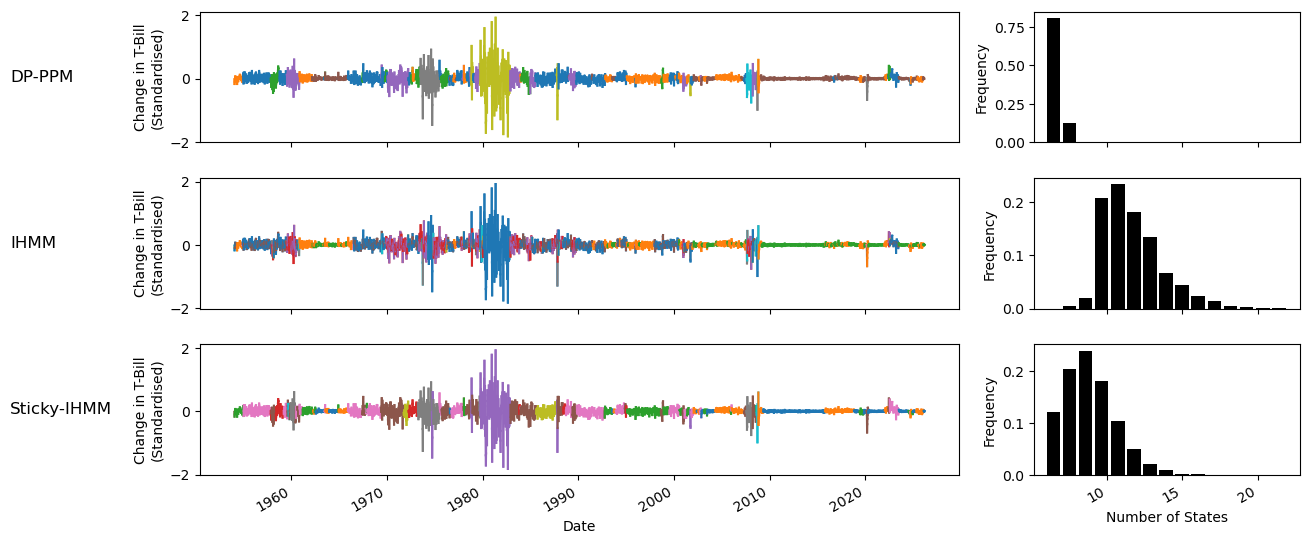

In [19]:
import matplotlib.dates as mdates

sticky_ihmm_states = np.loadtxt("t_bill_results/sticky_ihmm_single_state_sample.csv", delimiter=',').flatten()
ihmm_states = np.loadtxt("t_bill_results/ihmm_single_state_sample.csv", delimiter=',').flatten()
npcp_states = np.loadtxt("t_bill_results/npcp_single_state_sample.csv", delimiter=',').flatten()

sticky_ihmm_nstates = np.loadtxt("t_bill_results_clean/sticky_ihmm_n_states.csv", delimiter=',').flatten()
ihmm_nstates = np.loadtxt("t_bill_results_clean/ihmm_n_states.csv", delimiter=',').flatten()
npcp_nstates = np.loadtxt("t_bill_results_clean/npcp_n_states.csv", delimiter=',').flatten()

fig, ax = plt.subplots(3, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [10, 3.5]})
dat_ = dat.diff()

max_state = np.max(npcp_states)
for i in range(len(npcp_states) - 2):
# for i in range(500):
    color = plt.cm.tab10(npcp_states[i] / max_state)  # Normalize the value for colormap
    ax[0, 0].plot(
        dat_.index[i:i+2],
        dat_.iloc[i:i+2],
        color=color
    )

max_state = np.max(ihmm_states)
for i in range(len(ihmm_states) - 2):
# for i in range(500):
    color = plt.cm.tab10(ihmm_states[i] / max_state)  # Normalize the value for colormap
    ax[1, 0].plot(
        dat_.index[i:i+2],
        dat_.iloc[i:i+2],
        color=color
    )

max_state = np.max(sticky_ihmm_states)
for i in range(len(sticky_ihmm_states) - 2):
# for i in range(500):
    color = plt.cm.tab10(sticky_ihmm_states[i] / max_state)  # Normalize the value for colormap
    ax[2, 0].plot(
        dat_.index[i:i+2],
        dat_.iloc[i:i+2],
        color=color
    )

locator = mdates.AutoDateLocator()
ax[2, 0].xaxis.set_major_locator(locator)
ax[2, 0].xaxis.set_major_formatter(mdates.AutoDateFormatter(locator))
ax[2, 0].set_xlabel('Date')

ax[0, 0].set_ylabel('Change in T-Bill\n(Standardised)', fontsize=10)
ax[1, 0].set_ylabel('Change in T-Bill\n(Standardised)', fontsize=10)
ax[2, 0].set_ylabel('Change in T-Bill\n(Standardised)', fontsize=10)

ax[0, 0].text(
        -0.25, 0.5, 'DP-PPM',
        transform=ax[0, 0].transAxes,
        ha="left", va="center", fontsize=12
    )

ax[1, 0].text(
        -0.25, 0.5, 'IHMM',
        transform=ax[1, 0].transAxes,
        ha="left", va="center", fontsize=12
    )

ax[2, 0].text(
        -0.25, 0.5, 'Sticky-IHMM',
        transform=ax[2, 0].transAxes,
        ha="left", va="center", fontsize=12
    )

min_ = int(min(ihmm_nstates.min(), npcp_nstates.min()))
max_ = int(max(ihmm_nstates.max(), npcp_nstates.max()))

bins = np.linspace(min_-1,
                   max_+1,
                   max_-min_ + 2)

ax[0, 1].hist(npcp_nstates, color='black', width=0.9, density=True, bins=bins)
ax[1, 1].hist(ihmm_nstates, color='black', width=0.9, density=True, bins=bins)
ax[2, 1].hist(sticky_ihmm_nstates, color='black', width=0.9, density=True, bins=bins)

ax[0, 1].set_ylabel('Frequency')
ax[1, 1].set_ylabel('Frequency')
ax[2, 1].set_ylabel('Frequency')
ax[2, 1].set_xlabel('Number of States')

ax[1, 0].sharex(ax[0, 0])
ax[0, 1].sharex(ax[1, 1])
ax[2, 1].sharex(ax[1, 1])

fig.tight_layout()

fig.autofmt_xdate()
fig.savefig('Figs/t_bill_state_compare.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [216]:
def acf_lag(x, lag):
    n = len(x)
    
    # Compute mean
    mean = 0.0
    for i in range(n):
        mean += x[i]
    mean /= n

    # Compute variance (denominator)
    var = 0.0
    for i in range(n):
        diff = x[i] - mean
        var += diff * diff

    # Compute covariance at lag
    cov = 0.0
    for i in range(n - lag):
        cov += (x[i] - mean) * (x[i + lag] - mean)

    # Normalize
    if var == 0.0:
        return 0.0
    
    return cov / var

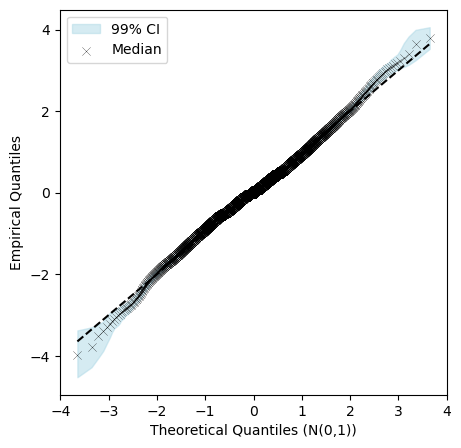

In [242]:
residuals = np.loadtxt("C:/Users/k2259011/OneDrive - King's College London/Documents/univariate_models/t_bill_results/npcp_residuals.csv", delimiter=',')
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
bayesian_qqplot(ax, residuals, alpha=0.01)
plt.show()
fig.savefig('Figs/t_bill_qq.pdf', bbox_inches='tight', format='pdf')

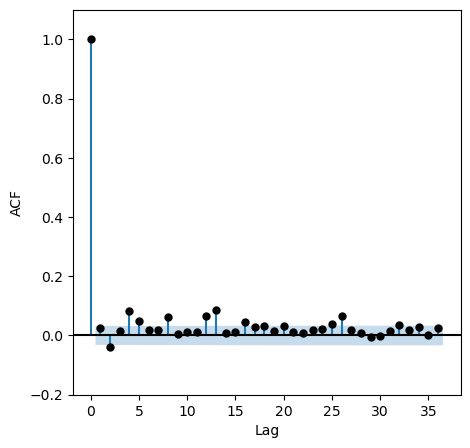

In [241]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
statsmodels.graphics.tsaplots.plot_acf(residuals[0, :], ax=ax, color='black')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('')
ax.set_ylim(-0.2, 1.1)
plt.show()
fig.savefig('Figs/t_bill_acf.pdf', bbox_inches='tight', format='pdf')

t=600 acf1 p-value: 0.4928571428571429
t=600 acf2 p-value: 0.6135714285714285
t=600 var p-value: 0.5785714285714286
t=1200 acf1 p-value: 0.8164285714285714
t=1200 acf2 p-value: 0.4207142857142857
t=1200 var p-value: 0.22
t=1800 acf1 p-value: 0.35428571428571426
t=1800 acf2 p-value: 0.045714285714285714
t=1800 var p-value: 0.34214285714285714
t=2400 acf1 p-value: 0.32071428571428573
t=2400 acf2 p-value: 0.12285714285714286
t=2400 var p-value: 0.13428571428571429
t=3000 acf1 p-value: 0.105
t=3000 acf2 p-value: 0.13357142857142856
t=3000 var p-value: 0.0


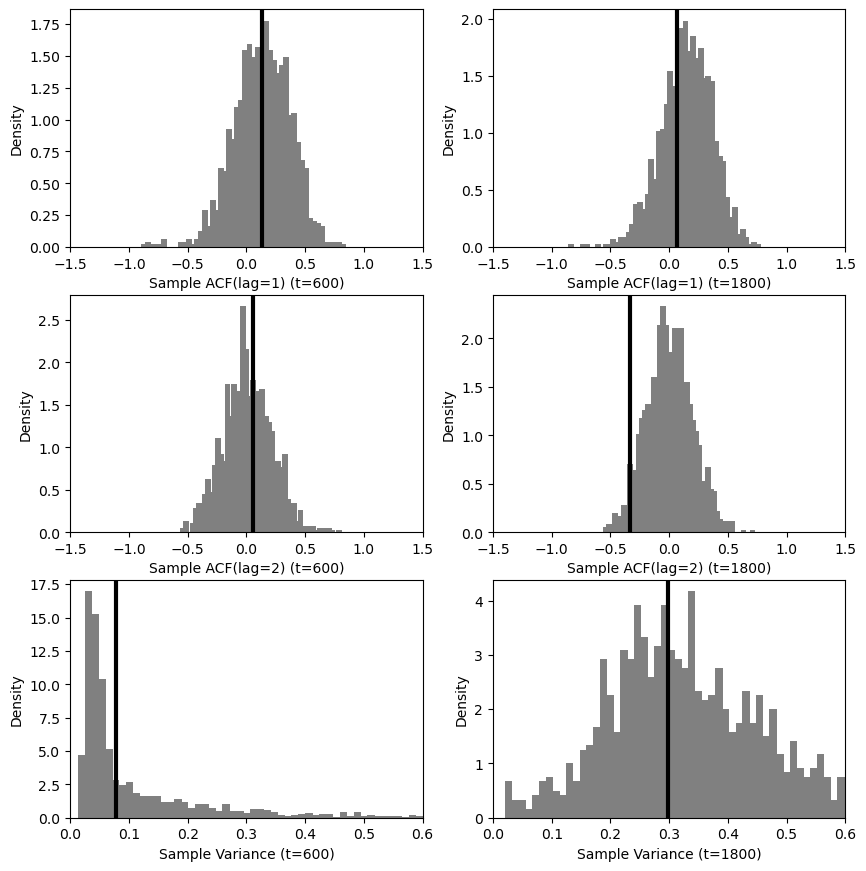

In [365]:
ts = [600, 1200, 1800, 2400, 3000]
h = 25
t_bill = dat.diff().to_numpy()[1:]
t_bill = (t_bill - np.mean(t_bill)) / np.sqrt(np.var(t_bill))
for i, t in enumerate(ts):
    true_acf1 = acf_lag(t_bill[t+1:t+h+1], 1)
    sim_acf1 = np.loadtxt(f't_bill_results/hppc/{t}_{h}_acf1.csv', delimiter=',').flatten()
    
    true_acf2 = acf_lag(t_bill[t+1:t+h+1], 2)
    sim_acf2 = np.loadtxt(f't_bill_results/hppc/{t}_{h}_acf2.csv', delimiter=',').flatten()
    
    true_var = np.var(t_bill[t+1:t+h+1])
    sim_var = np.loadtxt(f't_bill_results/hppc/{t}_{h}_var.csv', delimiter=',').flatten()
    
    print(f't={t} acf1 p-value: {np.mean(sim_acf1 < true_acf1)}')
    print(f't={t} acf2 p-value: {np.mean(sim_acf2 < true_acf2)}')
    print(f't={t} var p-value: {np.mean(sim_var < true_var)}')

bins = 50
ts = [600, 1800]
fig, ax = plt.subplots(3, len(ts), figsize=(10, 10.5))
for i, t in enumerate(ts):
    true_acf1 = acf_lag(t_bill[t+1:t+h+1], 1)
    sim_acf1 = np.loadtxt(f't_bill_results/hppc/{t}_{h}_acf1.csv', delimiter=',').flatten()
    
    true_acf2 = acf_lag(t_bill[t+1:t+h+1], 2)
    sim_acf2 = np.loadtxt(f't_bill_results/hppc/{t}_{h}_acf2.csv', delimiter=',').flatten()
    
    true_var = np.var(t_bill[t+1:t+h+1])
    sim_var = np.loadtxt(f't_bill_results/hppc/{t}_{h}_var.csv', delimiter=',').flatten()

    x_zoom = sim_acf1[(sim_acf1 >= -1.5) & (sim_acf1 <= 1.5)]
    ax[0, i].hist(x_zoom, bins=bins, color='grey', width=0.05, density=True)
    ax[0, i].axvline(x=true_acf1, color='black', linewidth=3)
    ax[0, i].set_xlim(-1.5, 1.5)
    ax[0, i].set_ylabel('Density')
    ax[0, i].set_xlabel(f'Sample ACF(lag=1) (t={t})')

    x_zoom = sim_acf2[(sim_acf2 >= -1.5) & (sim_acf2 <= 1.5)]
    ax[1, i].hist(sim_acf2, bins=bins, color='grey', width=0.05, density=True)
    ax[1, i].axvline(x=true_acf2, color='black', linewidth=3)
    ax[1, i].set_xlim(-1.5, 1.5)
    ax[1, i].set_ylabel('Density')
    ax[1, i].set_xlabel(f'Sample ACF(lag=2) (t={t})')
    
    x_zoom = sim_var[(sim_var >= 0) & (sim_var <= 0.6)]
    ax[2, i].hist(x_zoom, bins=bins, color='grey', width=0.05/4, density=True)
    ax[2, i].axvline(x=true_var, color='black', linewidth=3)
    ax[2, i].set_xlim(0, 0.6)
    ax[2, i].set_ylabel('Density')
    ax[2, i].set_xlabel(f'Sample Variance (t={t})')

fig.savefig('Figs/t_bill_hppc.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [100]:
len(well_log)

3947